# Frame-to-Trial Alignment

This notebook aligns video frames with behavioral trials, accounting for extra trigger frames.

## Problem
- Video captured at 40 FPS (0.025s per frame) with trial-based triggers
- If a trial length is NOT an exact multiple of 0.025s (±0.0001s tolerance), an extra trigger is sent
- This creates ~N extra frames for N trials (where not exact multiples)
- These extra frames are unreliable and should be skipped

## Solution
For each trial:
1. Read trial length from `SessionData.RawEvents.Trial{1,t}.States.TrialEnd[1]`
2. Calculate expected frames: `M = floor(trial_length * 40)`
3. Check if `trial_length % 0.025` is within tolerance
4. If NOT exact multiple: use M frames, skip the (M+1)th frame
5. If exact multiple: use all frames

## Output
- `aligned_data`: DataFrame with tracking data + metadata
  - `trial_idx`: Trial number (0-indexed)
  - `frame_idx_global`: Original frame index in video
  - `frame_idx_in_trial`: Frame index within trial
  - `frame_time_in_trial`: Time relative to trial start (seconds)
  - `frame_time_absolute`: Absolute session time (seconds)
  - All DLC tracking columns

## Usage with Spike Times
Since spike times are trial-relative, use `trial_idx` and `frame_time_in_trial` to match spikes with frames.

In [477]:
import scipy.io
import pandas as pd
# import mat73
import h5py
import numpy as np
import pickle
from pathlib import Path

# Load the .mat file
# spike_clusters = scipy.io.loadmat(r'F:\NPC2\kilosort_output\NPC2_27_11_2025_1\catgt\catgt_NPC2_27_11_2025_g0\NPC2_27_11_2025_g0_imec0\imec0_ks4_orig\aligned_spike_clusters.mat')
# spike_times = mat73.loadmat(r'F:\NPC2\kilosort_output\NPC2_27_11_2025_1\catgt\catgt_NPC2_27_11_2025_g0\NPC2_27_11_2025_g0_imec0\imec0_ks4_orig\aligned_spike_times.mat')
# cluster_info = pd.read_csv(r'F:\NPC2\kilosort_output\NPC2_27_11_2025_1\catgt\catgt_NPC2_27_11_2025_g0\NPC2_27_11_2025_g0_imec0\imec0_ks4\cluster_info.tsv', sep='\t')
# file_data = pd.read_csv(r"F:\NPC2\kilosort_output\NPC2_27_11_2025_1\catgt\catgt_NPC2_27_11_2025_g0\NPC2_27_11_2025_g0_ct_offsets.txt", sep='\t')

# Extract the specific array by row index (sec_imap0 is in row 1)
# start_times = file_data.iloc[1].values

# start_times = start_times[1:]

# start_times = start_times + 1

# Update the session variable to match the date in your file names
session = '12/08/2025'
bpod_file = 'NPC1_maze_pairs_fix_20250812_120148.mat' # .mat file

YY = session[-2:]
YYYY = session[-4:]
MM = session[3:5]
DD = session[:2]

DD_MM_YYYY = f"{DD}_{MM}_{YYYY}"

# Load the .h5 file
h5_file_path = rf"/var/home/almogmeir/Documents/GitHub/NaviGraph/examples/dual_root_tree/resources/maze_trackings/NPC1_{YYYY}_{MM}_{DD}_corrected.h5"

h5_file = pd.read_hdf(h5_file_path)

maze_video_path = rf"/var/home/almogmeir/Documents/GitHub/NaviGraph/examples/dual_root_tree/resources/maze_videos/NPC1_{YYYY}_{MM}_{DD}.mp4"
bpod_data = scipy.io.loadmat(rf"/var/home/almogmeir/Documents/M.Sc/Project/BPODData/NPC1/maze_pairs_fix/Session Data/{bpod_file}")
session_data = bpod_data['SessionData']

# Access a specific variable (replace 'variable_name' with actual variable name)
# data = mat_data['variable_name']

In [478]:

# Update after running NaviGraph

results_file = Path('/var/home/almogmeir/Documents/GitHub/NaviGraph/output/experiment_2026-02-26_13-32-39/analysis/session_metrics_20260226_133508.pkl') # 12/08
# results_file = Path('/var/home/almogmeir/Documents/GitHub/NaviGraph/output/experiment_2026-02-26_12-33-59/analysis/session_metrics_20260226_123603.pkl') # 13/08
# results_file = Path('/var/home/almogmeir/Documents/GitHub/NaviGraph/output/experiment_2026-02-26_12-00-49/analysis/session_metrics_20260226_120401.pkl') # 14/08
# results_file = Path('/var/home/almogmeir/Documents/GitHub/NaviGraph/output/experiment_2026-02-22_15-21-34/analysis/session_metrics_20260222_152350.pkl') # 18/08
# results_file = Path('/var/home/almogmeir/Documents/GitHub/NaviGraph/output/experiment_2026-02-08_18-45-29/analysis/session_metrics_20260208_184721.pkl') # 19/08
# results_file = Path('/var/home/almogmeir/Documents/GitHub/NaviGraph/output/experiment_2026-02-08_18-08-24/analysis/session_metrics_20260208_181023.pkl') # 20/08
# results_file = Path('/var/home/almogmeir/Documents/GitHub/NaviGraph/output/experiment_2026-01-15_11-44-58/analysis/session_metrics_20260115_114647.pkl') # 21/08
# results_file = Path('/var/home/almogmeir/Documents/GitHub/NaviGraph/output/experiment_2026-02-03_17-53-07/analysis/session_metrics_20260203_175436.pkl') # 24/08
# results_file = Path('/var/home/almogmeir/Documents/GitHub/NaviGraph/output/experiment_2026-02-04_12-00-35/analysis/session_metrics_20260204_120222.pkl') # 27/08


with open(results_file, 'rb') as f:
    results = pickle.load(f)

# Extract jump detection results
# jumps = results['session_results'][0]['metrics']['tracking_jumps']

# Extract individual metrics
metrics = results['session_results'][0]['metrics']
jumps = metrics.get('tracking_jumps', {}) or {}
flow = metrics.get('transition_flow', {}) or {}

traversal_data = metrics.get('traversal_sequence', {}) or {}

In [479]:
# Load NaviGraph output with graph locations
import pickle


# 12/08
navigraph_pkl_path = "/var/home/almogmeir/Documents/GitHub/NaviGraph/output/experiment_2026-02-26_13-32-39/analysis/raw_session_data_20260226_133508.pkl"
# 13/08
# navigraph_pkl_path = "/var/home/almogmeir/Documents/GitHub/NaviGraph/output/experiment_2026-02-26_12-33-59/analysis/raw_session_data_20260226_123603.pkl"
# 14/08
# navigraph_pkl_path = "/var/home/almogmeir/Documents/GitHub/NaviGraph/output/experiment_2026-02-26_12-00-49/analysis/raw_session_data_20260226_120401.pkl"
# 18/08
# navigraph_pkl_path = "/var/home/almogmeir/Documents/GitHub/NaviGraph/output/experiment_2026-02-22_15-21-34/analysis/raw_session_data_20260222_152350.pkl"
# 19/08
# navigraph_pkl_path = "/var/home/almogmeir/Documents/GitHub/NaviGraph/output/experiment_2026-02-08_18-45-29/analysis/raw_session_data_20260208_184721.pkl"
# 20/08
# navigraph_pkl_path = "/var/home/almogmeir/Documents/GitHub/NaviGraph/output/experiment_2026-02-08_18-08-24/analysis/raw_session_data_20260208_181023.pkl"
# 21/08
# navigraph_pkl_path = "/var/home/almogmeir/Documents/GitHub/NaviGraph/output/experiment_2026-01-18_15-06-57/analysis/raw_session_data_20260118_150848.pkl"
# 24/08
# navigraph_pkl_path = "/var/home/almogmeir/Documents/GitHub/NaviGraph/output/experiment_2026-02-03_17-53-07/analysis/raw_session_data_20260203_175436.pkl"
# 27/08
# navigraph_pkl_path = "/var/home/almogmeir/Documents/GitHub/NaviGraph/output/experiment_2026-02-04_12-00-35/analysis/raw_session_data_20260204_120222.pkl"

with open(navigraph_pkl_path, 'rb') as f:
    navigraph_data = pickle.load(f)

print("NaviGraph data structure:")
print(f"Type: {type(navigraph_data)}")
if isinstance(navigraph_data, dict):
    print(f"Keys: {navigraph_data.keys()}")
elif isinstance(navigraph_data, pd.DataFrame):
    print(f"Shape: {navigraph_data.shape}")
    print(f"Columns: {navigraph_data.columns.tolist()[:10]}")
    print(f"\nFirst few rows:")
    print(navigraph_data.head())

NaviGraph data structure:
Type: <class 'dict'>
Keys: dict_keys(['session_NPC1_12_08_2025', 'timestamp', 'experiment_path'])


In [480]:
session_data['nTrials']

array([[array([[814]], dtype=uint16)]], dtype=object)

In [481]:
h5_file

headstage                              ear_L                         \
                  x           y likelihood           x           y likelihood   
0         10.770271  934.933655   0.522752   13.629339  930.184021   0.290087   
1       1114.822998  324.662933   0.074316  168.632874  626.190918   0.095927   
2       1115.947388  324.619354   0.068727  168.932236  626.430542   0.095474   
3       1115.699341  324.704254   0.071213  169.136032  625.691467   0.082031   
4       1115.497681  324.718414   0.075311  164.298492  628.780151   0.102780   
...             ...         ...        ...         ...         ...        ...   
185531   141.620300  805.422180   0.890177  152.074112  796.915894   0.864709   
185532   141.604874  805.471436   0.833262  152.076279  797.511963   0.828260   
185533   141.140625  806.452393   0.842503  152.038055  797.478943   0.864988   
185534   140.965942  806.745361   0.841280  151.683289  797.794983   0.864512   
185535   141.189499  805.389282   0.847454  151.548401  798.540039   0.857158   

              ear_R                            midbody                         \
                  x           y likelihood           x           y likelihood   
0       1234.672607  946.750427   0.205353    2.739528  910.111938   0.316890   
1       1122.525391  171.019730   0.080942  156.668869  639.942322   0.090414   
2       1122.234131  171.398148   0.069630  156.807220  640.161682   0.091229   
3       1122.144775  171.621231   0.068325  157.088394  636.363342   0.071172   
4        164.937668  636.631226   0.075996  157.195847  636.535645   0.105207   
...             ...         ...        ...         ...         ...        ...   
185531   133.271194  793.217834   0.827087  146.168640  775.524231   0.922070   
185532   132.972549  793.578430   0.814805  145.989594  775.616760   0.910754   
185533   132.996307  793.616882   0.847039  146.035995  775.207886   0.897358   
185534   132.924438  794.107483   0.845602  145.780319  775.428650   0.892647   
185535   132.638138  794.350525   0.864077  145.843750  775.798706   0.893792   

           tailbase                        weighted                 
                  x           y likelihood        x   y likelihood  
0         10.872551  891.707092   0.187583      NaN NaN        NaN  
1       1119.748169  177.653610   0.173293      NaN NaN        NaN  
2       1120.064697  177.979889   0.138464      NaN NaN        NaN  
3       1120.197144  177.942703   0.141691      NaN NaN        NaN  
4       1120.214722  177.979630   0.129496      NaN NaN        NaN  
...             ...         ...        ...      ...  ..        ...  
185531   149.976822  751.477600   0.844927      NaN NaN        NaN  
185532   149.232452  751.060608   0.841517      NaN NaN        NaN  
185533   149.460953  750.371033   0.840907      NaN NaN        NaN  
185534   149.547165  750.581787   0.847172      NaN NaN        NaN  
185535   149.185776  750.299133   0.837753      NaN NaN        NaN  

[185536 rows x 18 columns]

In [482]:
# Update to be the actual file name according to the first index column value of the h5 table
# table_name = 'DLC_Resnet101_Neuropixel_2Cams_GammaJul22shuffle6_snapshot_100'

# Load the DataFrame from the HDF5 file
# dlc_raw_h5 = h5_file[table_name]
dlc_raw_h5 = h5_file

# Extract the MultiIndex from the first two rows
multi_index = pd.MultiIndex.from_arrays([dlc_raw_h5.iloc[0], dlc_raw_h5.iloc[1]])

# Convert the data to numeric, errors='coerce' will turn non-numeric values into NaN
dlc_raw_h5 = dlc_raw_h5.apply(pd.to_numeric, errors='coerce')

new_index = pd.MultiIndex.from_tuples([
        ('weighted', 'x'),
        ('weighted', 'y'),
        ('weighted', 'likelihood')
    ])

new_index_df = pd.DataFrame(np.nan, index=range(len(dlc_raw_h5)), columns=new_index)


# Concatenate the original DataFrame with the new columns DataFrame
# dlc_raw_h5 = pd.concat([dlc_raw_h5, new_columns], axis=1)

dlc_raw_h5 = pd.concat([dlc_raw_h5, new_index_df], axis=1)
dlc_raw_h5

headstage                              ear_L                         \
                  x           y likelihood           x           y likelihood   
0         10.770271  934.933655   0.522752   13.629339  930.184021   0.290087   
1       1114.822998  324.662933   0.074316  168.632874  626.190918   0.095927   
2       1115.947388  324.619354   0.068727  168.932236  626.430542   0.095474   
3       1115.699341  324.704254   0.071213  169.136032  625.691467   0.082031   
4       1115.497681  324.718414   0.075311  164.298492  628.780151   0.102780   
...             ...         ...        ...         ...         ...        ...   
185531   141.620300  805.422180   0.890177  152.074112  796.915894   0.864709   
185532   141.604874  805.471436   0.833262  152.076279  797.511963   0.828260   
185533   141.140625  806.452393   0.842503  152.038055  797.478943   0.864988   
185534   140.965942  806.745361   0.841280  151.683289  797.794983   0.864512   
185535   141.189499  805.389282   0.847454  151.548401  798.540039   0.857158   

              ear_R                            midbody  ...             \
                  x           y likelihood           x  ... likelihood   
0       1234.672607  946.750427   0.205353    2.739528  ...   0.316890   
1       1122.525391  171.019730   0.080942  156.668869  ...   0.090414   
2       1122.234131  171.398148   0.069630  156.807220  ...   0.091229   
3       1122.144775  171.621231   0.068325  157.088394  ...   0.071172   
4        164.937668  636.631226   0.075996  157.195847  ...   0.105207   
...             ...         ...        ...         ...  ...        ...   
185531   133.271194  793.217834   0.827087  146.168640  ...   0.922070   
185532   132.972549  793.578430   0.814805  145.989594  ...   0.910754   
185533   132.996307  793.616882   0.847039  146.035995  ...   0.897358   
185534   132.924438  794.107483   0.845602  145.780319  ...   0.892647   
185535   132.638138  794.350525   0.864077  145.843750  ...   0.893792   

           tailbase                        weighted                         \
                  x           y likelihood        x   y likelihood   x   y   
0         10.872551  891.707092   0.187583      NaN NaN        NaN NaN NaN   
1       1119.748169  177.653610   0.173293      NaN NaN        NaN NaN NaN   
2       1120.064697  177.979889   0.138464      NaN NaN        NaN NaN NaN   
3       1120.197144  177.942703   0.141691      NaN NaN        NaN NaN NaN   
4       1120.214722  177.979630   0.129496      NaN NaN        NaN NaN NaN   
...             ...         ...        ...      ...  ..        ...  ..  ..   
185531   149.976822  751.477600   0.844927      NaN NaN        NaN NaN NaN   
185532   149.232452  751.060608   0.841517      NaN NaN        NaN NaN NaN   
185533   149.460953  750.371033   0.840907      NaN NaN        NaN NaN NaN   
185534   149.547165  750.581787   0.847172      NaN NaN        NaN NaN NaN   
185535   149.185776  750.299133   0.837753      NaN NaN        NaN NaN NaN   

                   
       likelihood  
0             NaN  
1             NaN  
2             NaN  
3             NaN  
4             NaN  
...           ...  
185531        NaN  
185532        NaN  
185533        NaN  
185534        NaN  
185535        NaN  

[185536 rows x 21 columns]

In [483]:
dlc_raw_h5 = h5_file

In [484]:
# maze_start_times = start_times[26:-20]
# maze_start_times

In [485]:
# Explore the structure of the bpod_data and session_data
print("Keys in bpod_data:", bpod_data.keys())
print("\nType of SessionData:", type(session_data))
print("Shape of SessionData:", session_data.shape)
print("Dtype of SessionData:", session_data.dtype)

# If it's a structured array, check the field names
if hasattr(session_data, 'dtype') and session_data.dtype.names:
    print("\nField names in SessionData:", session_data.dtype.names)
    
# Check nTrials
print("\nnTrials:", session_data['nTrials'])
print("Type of nTrials:", type(session_data['nTrials']))

# Explore RawEvents structure
print("\nRawEvents type:", type(session_data['RawEvents']))
print("RawEvents shape:", session_data['RawEvents'].shape)
print("RawEvents dtype:", session_data['RawEvents'].dtype)

# Try to access the first element
raw_events = session_data['RawEvents'][0, 0]
print("\nType of RawEvents[0,0]:", type(raw_events))
if hasattr(raw_events, 'dtype') and raw_events.dtype.names:
    print("Field names in RawEvents[0,0]:", raw_events.dtype.names)
    
# Try to access Trial
if 'Trial' in raw_events.dtype.names:
    trial = raw_events['Trial']
    print("\nTrial type:", type(trial))
    print("Trial shape:", trial.shape)
    print("Trial dtype:", trial.dtype)
    
    # Access first trial
    if trial.shape[0] > 0:
        first_trial = trial[0, 0]
        print("\nFirst trial type:", type(first_trial))
        if hasattr(first_trial, 'dtype') and first_trial.dtype.names:
            print("Field names in first trial:", first_trial.dtype.names)
            
            # Try to access TrialEnd
            if 'TrialEnd' in first_trial.dtype.names:
                trial_end = first_trial['TrialEnd']
                print("\nTrialEnd:", trial_end)
                print("TrialEnd type:", type(trial_end))
                print("TrialEnd shape:", trial_end.shape if hasattr(trial_end, 'shape') else 'N/A')

Keys in bpod_data: dict_keys(['__header__', '__version__', '__globals__', 'SessionData', '__function_workspace__'])

Type of SessionData: <class 'numpy.ndarray'>
Shape of SessionData: (1, 1)
Dtype of SessionData: [('nTrials', 'O'), ('TrialTypes', 'O'), ('MATLABStartTimes', 'O'), ('Blocks', 'O'), ('DepletionSteps', 'O'), ('AllRewardSizes', 'O'), ('bitcode', 'O'), ('TrialRewardFlag', 'O'), ('DepletionRewardSize', 'O'), ('DepletionStep', 'O'), ('DepletionDivideStepIndex', 'O'), ('BehaviorORSpontaneous', 'O'), ('RewardMatrix', 'O'), ('Info', 'O'), ('SettingsFile', 'O'), ('RawEvents', 'O'), ('RawData', 'O'), ('TrialStartTimestamp', 'O'), ('TrialEndTimestamp', 'O'), ('TrialRewardSize', 'O')]

Field names in SessionData: ('nTrials', 'TrialTypes', 'MATLABStartTimes', 'Blocks', 'DepletionSteps', 'AllRewardSizes', 'bitcode', 'TrialRewardFlag', 'DepletionRewardSize', 'DepletionStep', 'DepletionDivideStepIndex', 'BehaviorORSpontaneous', 'RewardMatrix', 'Info', 'SettingsFile', 'RawEvents', 'RawData

In [486]:
# Deeper exploration of trial structure
raw_events = session_data['RawEvents'][0, 0]
trial = raw_events['Trial'][0, 0]

print("Trial is a list/array with length:", len(trial) if hasattr(trial, '__len__') else 'N/A')
print("Type of trial[0]:", type(trial[0]) if hasattr(trial, '__getitem__') and len(trial) > 0 else 'N/A')

# Try to look at first few trials
if hasattr(trial, '__len__'):
    for i in range(min(3, len(trial))):
        print(f"\n--- Trial {i+1} ---")
        t = trial[i]
        print(f"Type: {type(t)}")
        if hasattr(t, 'dtype') and t.dtype.names:
            print(f"Fields: {t.dtype.names}")
            if 'TrialEnd' in t.dtype.names:
                trial_end = t['TrialEnd']
                print(f"TrialEnd: {trial_end}")
                print(f"TrialEnd shape: {trial_end.shape if hasattr(trial_end, 'shape') else 'N/A'}")
                print(f"TrialEnd value: {trial_end[0] if hasattr(trial_end, '__getitem__') and len(trial_end) > 0 else trial_end}")
        elif hasattr(t, '__len__') and len(t) > 0:
            print(f"Length: {len(t)}")
            print(f"First element type: {type(t[0])}")
            if hasattr(t[0], 'dtype') and hasattr(t[0].dtype, 'names') and t[0].dtype.names:
                print(f"First element fields: {t[0].dtype.names}")
                if 'TrialEnd' in t[0].dtype.names:
                    print(f"TrialEnd from [0]: {t[0]['TrialEnd']}")


Trial is a list/array with length: 1
Type of trial[0]: <class 'numpy.ndarray'>

--- Trial 1 ---
Type: <class 'numpy.ndarray'>
Length: 814
First element type: <class 'numpy.ndarray'>
First element fields: ('States', 'Events')


In [487]:
# Access the actual trial array
raw_events = session_data['RawEvents'][0, 0]
trial_array = raw_events['Trial'][0, 0][0]  # This is the array of 491 trials

print(f"Number of trials: {len(trial_array)}")
print(f"Type of first trial: {type(trial_array[0])}")
print(f"First trial fields: {trial_array[0].dtype.names if hasattr(trial_array[0], 'dtype') else 'N/A'}")

# Check first trial structure
first_trial = trial_array[0]
print(f"\nFirst trial structure - type: {type(first_trial)}")
print(f"First trial shape: {first_trial.shape}")
if hasattr(first_trial, 'dtype') and first_trial.dtype.names:
    print(f"Fields: {first_trial.dtype.names}")
    
    # Check States
    if 'States' in first_trial.dtype.names:
        states = first_trial['States']
        print(f"\nStates type: {type(states)}")
        print(f"States shape: {states.shape if hasattr(states, 'shape') else 'N/A'}")
        
        # Access the actual states object
        if hasattr(states, '__len__') and len(states) > 0:
            states_obj = states[0] if states.shape == (1,) else states
            if hasattr(states_obj, 'dtype') and states_obj.dtype.names:
                print(f"States fields: {states_obj.dtype.names}")
                if 'TrialEnd' in states_obj.dtype.names:
                    print(f"TrialEnd found in States!")
                    trial_end = states_obj['TrialEnd']
                    print(f"TrialEnd: {trial_end}")
                    print(f"TrialEnd value: {trial_end[0] if hasattr(trial_end, '__getitem__') and len(trial_end) > 0 else trial_end}")


Number of trials: 814
Type of first trial: <class 'numpy.ndarray'>
First trial fields: ('States', 'Events')

First trial structure - type: <class 'numpy.ndarray'>
First trial shape: (1, 1)
Fields: ('States', 'Events')

States type: <class 'numpy.ndarray'>
States shape: (1, 1)


In [488]:
# Continue deeper exploration
raw_events = session_data['RawEvents'][0, 0]
trial_array = raw_events['Trial'][0, 0][0]

first_trial = trial_array[0]
states = first_trial['States'][0, 0]

print(f"States type after [0,0]: {type(states)}")
if hasattr(states, 'dtype') and states.dtype.names:
    print(f"States fields: {states.dtype.names}")
    
    # Try to access TrialEnd
    if 'TrialEnd' in states.dtype.names:
        trial_end = states['TrialEnd']
        print(f"\nTrialEnd type: {type(trial_end)}")
        print(f"TrialEnd shape: {trial_end.shape if hasattr(trial_end, 'shape') else 'N/A'}")
        print(f"TrialEnd: {trial_end}")
        if hasattr(trial_end, '__len__') and len(trial_end) > 0:
            print(f"TrialEnd[0]: {trial_end[0]}")
            if hasattr(trial_end[0], '__len__') and len(trial_end[0]) > 0:
                print(f"TrialEnd[0][0]: {trial_end[0][0]}")

# Try multiple trials
print("\n\n=== First 5 Trials ===")
for i in range(min(5, len(trial_array))):
    trial = trial_array[i]
    states = trial['States'][0, 0]
    trial_end = states['TrialEnd']
    if hasattr(trial_end, '__len__') and len(trial_end) > 0:
        if hasattr(trial_end[0], '__len__'):
            value = trial_end[0][0] if len(trial_end[0]) > 0 else trial_end[0]
        else:
            value = trial_end[0]
    else:
        value = trial_end
    print(f"Trial {i+1}: TrialEnd = {value}")


States type after [0,0]: <class 'numpy.ndarray'>
States fields: ('TimerTrig1', 'TrialStart', 'MazeIntroduction', 'Reward6', 'CloseValve2', 'RewardConsumption', 'InterTrialInterval', 'TrialEnd', 'RepeatIntroduction', 'Reward1', 'Reward2', 'Reward3', 'Reward4', 'Reward5', 'Reward7', 'Reward8', 'CloseValve1', 'CloseValve3', 'CloseValve4')

TrialEnd type: <class 'numpy.ndarray'>
TrialEnd shape: (1, 1)
TrialEnd: [[array([[23.7414, 23.7914]])]]
TrialEnd[0]: [array([[23.7414, 23.7914]])]
TrialEnd[0][0]: [[23.7414 23.7914]]


=== First 5 Trials ===
Trial 1: TrialEnd = [[23.7414 23.7914]]
Trial 2: TrialEnd = [[34.5054 34.5554]]
Trial 3: TrialEnd = [[4.1823 4.2323]]
Trial 4: TrialEnd = [[5.926 5.976]]
Trial 5: TrialEnd = [[14.9018 14.9518]]


In [489]:
# Extract trial end times for all trials
raw_events = session_data['RawEvents'][0, 0]
trial_array = raw_events['Trial'][0, 0][0]

n_trials = len(trial_array)
trial_end_times = []

for i in range(n_trials):
    trial = trial_array[i]
    states = trial['States'][0, 0]
    trial_end = states['TrialEnd']
    # Get the second value (end of TrialEnd state) as the trial length
    trial_length = trial_end[0][0][0][0]  # [0][0] to unwrap, [0] for first pair, [1] for end time
    trial_end_times.append(trial_length)

trial_end_times = np.array(trial_end_times)
print(f"Number of trials: {len(trial_end_times)}")
print(f"First 10 trial end times: {trial_end_times[:10]}")


Number of trials: 814
First 10 trial end times: [23.7414 34.5054  4.1823  5.926  14.9018  9.6458  9.3804  7.9649  4.1903
  4.297 ]


In [490]:
# Now create the frame-to-trial alignment
FPS = 40
FRAME_INTERVAL = 0.025  # 1/40
TOLERANCE = 0.0001

# Calculate expected frames per trial and detect extra frames
frame_data = []
current_frame_idx = 0

for trial_idx in range(len(trial_end_times)):
    trial_length = trial_end_times[trial_idx]
    
    # Calculate expected number of frames
    expected_frames = trial_length * FPS
    
    # Check if trial length is exact multiple of frame interval
    remainder = trial_length % FRAME_INTERVAL
    is_exact_multiple = remainder < TOLERANCE or (FRAME_INTERVAL - remainder) < TOLERANCE
    
    # Determine number of frames for this trial
    if is_exact_multiple:
        n_frames = int(np.round(expected_frames))
        has_extra_frame = False
    else:
        # Not exact multiple, so we have M+1 frames but should skip the M+1 frame
        n_frames = int(np.floor(expected_frames))  # Only take M frames
        has_extra_frame = True
    
    # Create frame entries for this trial
    for frame_in_trial in range(n_frames):
        frame_data.append({
            'trial_idx': trial_idx,
            'frame_idx_global': current_frame_idx,
            'frame_idx_in_trial': frame_in_trial,
            'frame_time_in_trial': frame_in_trial * FRAME_INTERVAL,
            'trial_length': trial_length,
            'is_exact_multiple': is_exact_multiple,
            'has_extra_frame': has_extra_frame
        })
        current_frame_idx += 1
    
    # Skip the extra frame if present
    if has_extra_frame:
        current_frame_idx += 1  # Skip the unreliable M+1 frame
        print(f"Trial {trial_idx}: Skipping extra frame at global index {current_frame_idx-1}")

# Create DataFrame
frames_df = pd.DataFrame(frame_data)

print(f"\nTotal frames in DataFrame: {len(frames_df)}")
print(f"Total frames in video (including skipped): {current_frame_idx}")
print(f"Number of extra frames skipped: {current_frame_idx - len(frames_df)}")
print(f"\nFirst few rows:")
print(frames_df.head(10))
print(f"\nLast few rows:")
print(frames_df.tail(10))


Trial 0: Skipping extra frame at global index 949
Trial 1: Skipping extra frame at global index 2330
Trial 2: Skipping extra frame at global index 2498
Trial 3: Skipping extra frame at global index 2736
Trial 4: Skipping extra frame at global index 3333
Trial 5: Skipping extra frame at global index 3719
Trial 6: Skipping extra frame at global index 4095
Trial 7: Skipping extra frame at global index 4414
Trial 8: Skipping extra frame at global index 4582
Trial 9: Skipping extra frame at global index 4754
Trial 10: Skipping extra frame at global index 5742
Trial 11: Skipping extra frame at global index 6134
Trial 12: Skipping extra frame at global index 6360
Trial 13: Skipping extra frame at global index 6461
Trial 14: Skipping extra frame at global index 6751
Trial 15: Skipping extra frame at global index 7097
Trial 16: Skipping extra frame at global index 7321
Trial 17: Skipping extra frame at global index 7494
Trial 18: Skipping extra frame at global index 7663
Trial 19: Skipping extr

In [491]:
# Check the alignment results
print(f"Total frames in DataFrame: {len(frames_df)}")
print(f"\nDataFrame columns: {frames_df.columns.tolist()}")
print(f"\nFirst 5 rows:")
print(frames_df.head())
print(f"\nLast 5 rows:")
print(frames_df.tail())

# Check trials with extra frames
extra_frame_trials = frames_df[frames_df['has_extra_frame'] == True]['trial_idx'].unique()
print(f"\n\nNumber of trials with extra frames: {len(extra_frame_trials)}")
print(f"First 10 trials with extra frames: {extra_frame_trials[:10]}")


Total frames in DataFrame: 184726

DataFrame columns: ['trial_idx', 'frame_idx_global', 'frame_idx_in_trial', 'frame_time_in_trial', 'trial_length', 'is_exact_multiple', 'has_extra_frame']

First 5 rows:
   trial_idx  frame_idx_global  frame_idx_in_trial  frame_time_in_trial  \
0          0                 0                   0                0.000   
1          0                 1                   1                0.025   
2          0                 2                   2                0.050   
3          0                 3                   3                0.075   
4          0                 4                   4                0.100   

   trial_length  is_exact_multiple  has_extra_frame  
0       23.7414              False             True  
1       23.7414              False             True  
2       23.7414              False             True  
3       23.7414              False             True  
4       23.7414              False             True  

Last 5 rows:
       

In [492]:
# Add the DLC tracking data to the DataFrame
# The frame_idx_global in frames_df corresponds to the row index in dlc_raw_h5

# First, let's check if the number of frames matches
print(f"Number of frames in frames_df: {len(frames_df)}")
print(f"Number of rows in dlc_raw_h5: {len(dlc_raw_h5)}")

# Filter out any frame indices that are out of bounds (can happen when trial-based
# frame calculation slightly overshoots the actual recording length)
max_valid_idx = len(dlc_raw_h5) - 1
out_of_bounds_mask = frames_df['frame_idx_global'] > max_valid_idx
if out_of_bounds_mask.any():
    print(f"Warning: {out_of_bounds_mask.sum()} frames have out-of-bounds indices "
          f"(max valid: {max_valid_idx}). These will be dropped.")
    frames_df = frames_df[~out_of_bounds_mask].copy()
    print(f"Remaining frames after filtering: {len(frames_df)}")

# Create a copy of the DLC data with only the frames we need
aligned_data = dlc_raw_h5.iloc[frames_df['frame_idx_global'].values].copy()

# Reset index to align with frames_df
aligned_data.reset_index(drop=True, inplace=True)
frames_df = frames_df.reset_index(drop=True)

# Combine the metadata from frames_df with the tracking data
# Need to ensure we're setting scalar values, not arrays
for col in frames_df.columns:
    # Create a Series with the metadata values
    aligned_data[(col, '')] = pd.Series(frames_df[col].values, index=aligned_data.index)

print(f"\nAligned data shape: {aligned_data.shape}")
print(f"\nFirst few rows of aligned data:")
print(aligned_data.head())


Number of frames in frames_df: 184726
Number of rows in dlc_raw_h5: 185536

Aligned data shape: (184726, 25)

First few rows of aligned data:
     headstage                              ear_L                         \
             x           y likelihood           x           y likelihood   
0    10.770271  934.933655   0.522752   13.629339  930.184021   0.290087   
1  1114.822998  324.662933   0.074316  168.632874  626.190918   0.095927   
2  1115.947388  324.619354   0.068727  168.932236  626.430542   0.095474   
3  1115.699341  324.704254   0.071213  169.136032  625.691467   0.082031   
4  1115.497681  324.718414   0.075311  164.298492  628.780151   0.102780   

         ear_R                            midbody  ... weighted      \
             x           y likelihood           x  ...        x   y   
0  1234.672607  946.750427   0.205353    2.739528  ...      NaN NaN   
1  1122.525391  171.019730   0.080942  156.668869  ...      NaN NaN   
2  1122.234131  171.398148   0.069630  15

In [493]:
# # Add absolute session times using maze_start_times
# # maze_start_times should have the same number of trials as we have

# print(f"Number of trials in frames_df: {frames_df['trial_idx'].max() + 1}")
# print(f"Number of start times in maze_start_times: {len(maze_start_times)}")

# # Add absolute session time for each frame
# aligned_data[('frame_time_absolute', '')] = (
#     aligned_data[('frame_time_in_trial', '')].values + 
#     maze_start_times[aligned_data[('trial_idx', '')].values]
# )

# # Show some statistics
# print(f"\nFirst trial frames:")
# first_trial_data = aligned_data[aligned_data[('trial_idx', '')] == 0][[
#     ('trial_idx', ''), 
#     ('frame_idx_in_trial', ''), 
#     ('frame_time_in_trial', ''), 
#     ('frame_time_absolute', '')
# ]]
# print(first_trial_data.head(10))

# print(f"\nSecond trial frames:")
# second_trial_data = aligned_data[aligned_data[('trial_idx', '')] == 1][[
#     ('trial_idx', ''), 
#     ('frame_idx_in_trial', ''), 
#     ('frame_time_in_trial', ''), 
#     ('frame_time_absolute', '')
# ]]
# print(second_trial_data.head(10))


In [494]:
# Summary of the alignment
print("="*60)
print("FRAME-TO-TRIAL ALIGNMENT SUMMARY")
print("="*60)
print(f"\nTotal trials: {len(trial_end_times)}")
print(f"Total frames in video: {len(dlc_raw_h5)}")
print(f"Total aligned frames (after removing extra): {len(aligned_data)}")
print(f"Number of extra frames skipped: {len(dlc_raw_h5) - len(aligned_data)}")
print(f"Number of trials with extra frames: {len(extra_frame_trials)}")
print(f"Number of trials with exact frame timing: {len(trial_end_times) - len(extra_frame_trials)}")

# Show examples of extra frame trials
print("\n" + "="*60)
print("EXAMPLES OF EXTRA FRAME DETECTION")
print("="*60)
for i in range(min(5, len(extra_frame_trials))):
    trial_idx = extra_frame_trials[i]
    trial_length = trial_end_times[trial_idx]
    expected_frames = trial_length * FPS
    remainder = trial_length % FRAME_INTERVAL
    
    print(f"\nTrial {trial_idx}:")
    print(f"  Length: {trial_length:.4f} seconds")
    print(f"  Expected frames (M): {int(np.floor(expected_frames))}")
    print(f"  Remainder: {remainder:.6f} (tolerance: {TOLERANCE})")
    print(f"  Extra frame at global index: {frames_df[frames_df['trial_idx'] == trial_idx]['frame_idx_global'].max() + 1}")

print("\n" + "="*60)
print("DATA STRUCTURE")
print("="*60)
print(f"\nColumns in aligned_data:")
for col in aligned_data.columns[:10]:
    print(f"  {col}")
print("  ...")
print(f"\nMetadata columns added:")
print(f"  - trial_idx: Trial number (0-indexed)")
print(f"  - frame_idx_global: Original frame index in video")
print(f"  - frame_idx_in_trial: Frame index within trial (0-indexed)")
print(f"  - frame_time_in_trial: Time relative to trial start (seconds)")
print(f"  - frame_time_absolute: Absolute session time (seconds)")
print(f"  - trial_length: Total length of the trial (seconds)")
print(f"  - is_exact_multiple: Whether trial length is exact multiple of 0.025s")
print(f"  - has_extra_frame: Whether an extra frame was skipped after this trial")


FRAME-TO-TRIAL ALIGNMENT SUMMARY

Total trials: 814
Total frames in video: 185536
Total aligned frames (after removing extra): 184726
Number of extra frames skipped: 810
Number of trials with extra frames: 811
Number of trials with exact frame timing: 3

EXAMPLES OF EXTRA FRAME DETECTION

Trial 0:
  Length: 23.7414 seconds
  Expected frames (M): 949
  Remainder: 0.016400 (tolerance: 0.0001)
  Extra frame at global index: 949

Trial 1:
  Length: 34.5054 seconds
  Expected frames (M): 1380
  Remainder: 0.005400 (tolerance: 0.0001)
  Extra frame at global index: 2330

Trial 2:
  Length: 4.1823 seconds
  Expected frames (M): 167
  Remainder: 0.007300 (tolerance: 0.0001)
  Extra frame at global index: 2498

Trial 3:
  Length: 5.9260 seconds
  Expected frames (M): 237
  Remainder: 0.001000 (tolerance: 0.0001)
  Extra frame at global index: 2736

Trial 4:
  Length: 14.9018 seconds
  Expected frames (M): 596
  Remainder: 0.001800 (tolerance: 0.0001)
  Extra frame at global index: 3333

DATA ST

In [495]:
# Save the aligned data
output_h5_path = "/var/home/almogmeir/Documents/GitHub/NaviGraph/examples/dual_root_tree/resources/maze_trackings/NPC1_2025_08_24_corrected_aligned.h5"

# Debug: Check the current column structure
print("Column structure before flattening:")
print(f"Type: {type(aligned_data.columns)}")
print(f"First 5 columns: {aligned_data.columns[:5].tolist()}")
print(f"Number of columns: {len(aligned_data.columns)}")

# Flatten the MultiIndex columns properly
aligned_data_flat = aligned_data.copy()

# Check if columns is MultiIndex
if isinstance(aligned_data_flat.columns, pd.MultiIndex):
    # Flatten MultiIndex by joining with underscore
    aligned_data_flat.columns = ['_'.join(str(c) for c in col if str(c) != '').strip('_') 
                                  for col in aligned_data_flat.columns.values]
else:
    # Already flat, just ensure string type
    aligned_data_flat.columns = [str(col) for col in aligned_data_flat.columns]

# Check for duplicate column names after flattening
duplicate_cols = aligned_data_flat.columns[aligned_data_flat.columns.duplicated()].tolist()
if duplicate_cols:
    print(f"\nWarning: Found {len(duplicate_cols)} duplicate column names after flattening:")
    print(duplicate_cols[:10])
    # Make column names unique by adding suffix
    aligned_data_flat.columns = pd.io.common.dedup_names(aligned_data_flat.columns, is_potential_multiindex=False)

print(f"\nColumn structure after flattening:")
print(f"Type: {type(aligned_data_flat.columns)}")
print(f"First 5 columns: {aligned_data_flat.columns[:5].tolist()}")
print(f"Number of unique columns: {aligned_data_flat.columns.nunique()}")

# Save with flattened columns
try:
    aligned_data_flat.to_hdf(output_h5_path, key='aligned_data', mode='w', format='fixed')
    print(f"\n✓ Successfully saved aligned tracking data to: {output_h5_path}")
except Exception as e:
    print(f"\n✗ Error saving with fixed format: {e}")
    print("\nTrying with table format instead...")
    try:
        aligned_data_flat.to_hdf(output_h5_path, key='aligned_data', mode='w', format='table')
        print(f"✓ Successfully saved with table format to: {output_h5_path}")
    except Exception as e2:
        print(f"✗ Error with table format too: {e2}")
        print("\nTrying to save as CSV as fallback...")
        csv_path = output_h5_path.replace('.h5', '.csv')
        aligned_data_flat.to_csv(csv_path)
        print(f"✓ Saved as CSV to: {csv_path}")

print("\nAlignment complete!")

Column structure before flattening:
Type: <class 'pandas.MultiIndex'>
First 5 columns: [('headstage', 'x'), ('headstage', 'y'), ('headstage', 'likelihood'), ('ear_L', 'x'), ('ear_L', 'y')]
Number of columns: 25

Column structure after flattening:
Type: <class 'pandas.Index'>
First 5 columns: ['headstage_x', 'headstage_y', 'headstage_likelihood', 'ear_L_x', 'ear_L_y']
Number of unique columns: 25

✓ Successfully saved aligned tracking data to: /var/home/almogmeir/Documents/GitHub/NaviGraph/examples/dual_root_tree/resources/maze_trackings/NPC1_2025_08_24_corrected_aligned.h5

Alignment complete!


## Reward Time Analysis

Extract reward times from BPOD data and compare with graph locations from NaviGraph.

In [496]:
# Load reward data from CSV file instead of extracting from raw BPOD .mat file
# CSV contains: trial, relative_time, and other reward information

def load_reward_data_from_csv(csv_path):
    """
    Load reward data from CSV file.
    
    Parameters:
    -----------
    csv_path : str
        Path to the reward CSV file
    
    Returns:
    --------
    pd.DataFrame with columns:
        - trial_idx: Trial number (0-indexed, matching our frame alignment)
        - reward_time: Time of reward relative to trial start (seconds)
        - reward_port: Which reward port was used (1-8)
        - Additional columns from CSV for later use
    """
    # Load the CSV
    reward_csv = pd.read_csv(csv_path)
    
    print(f"Loaded reward CSV from: {csv_path}")
    print(f"Shape: {reward_csv.shape}")
    print(f"Columns: {reward_csv.columns.tolist()}")
    print(f"\nFirst few rows:")
    print(reward_csv.head())
    
    # Create DataFrame with required columns
    # Note: CSV uses 1-indexed trials, we need 0-indexed
    reward_data = []
    for _, row in reward_csv.iterrows():
        reward_data.append({
            'trial_idx': int(row['trial']) - 1,  # Convert to 0-indexed
            'reward_time': float(row['relative_time']),  # Time relative to trial start
            'reward_port': int(row['port_number']),  # Port number from CSV
            # Store other columns for later use
            **{col: row[col] for col in reward_csv.columns if col not in ['trial', 'relative_time', 'port_number']}
        })
    
    return pd.DataFrame(reward_data)

# Load reward data from CSV
reward_csv_path = f"/var/home/almogmeir/Documents/M.Sc/Project/BPODData/NPC1/maze_pairs_fix/Session Data/output/{YYYY}{MM}{DD}/reward.csv"
reward_df = load_reward_data_from_csv(reward_csv_path)

# Filter to trials with rewards
reward_df_valid = reward_df[reward_df['reward_time'].notna()].copy()

print(f"Total trials: {len(reward_df)}")
print(f"Trials with rewards: {len(reward_df_valid)}")
print(f"\nReward distribution by port:")
print(reward_df_valid['reward_port'].value_counts().sort_index())
print(f"\nFirst 20 trials with rewards:")
print(reward_df_valid.head(20))


Loaded reward CSV from: /var/home/almogmeir/Documents/M.Sc/Project/BPODData/NPC1/maze_pairs_fix/Session Data/output/20250812/reward.csv
Shape: (814, 9)
Columns: ['subject_id', 'session', 'trial', 'port_number', 'reward_size', 'relative_time', 'abs_time', 'depletion_step', 'depletion_size']

First few rows:
   subject_id  session  trial  port_number  reward_size  relative_time  \
0      105101        1      1            6         0.03        21.6113   
1      105101        1      2            2         0.00        32.4052   
2      105101        1      3            2         0.00         2.0821   
3      105101        1      4            7         0.00         3.8258   
4      105101        1      5            1         0.00        12.8016   

   abs_time  depletion_step  depletion_size  
0   94.1815               0             1.0  
1  128.8439               1             0.0  
2  133.1463               1             0.0  
3  139.1889               2             0.0  
4  154.2114      

In [497]:
# Load lick events data from CSV
def load_lick_events_from_csv(csv_path):
    """
    Load lick events data from CSV file.
    
    Parameters:
    -----------
    csv_path : str
        Path to the lick_events CSV file
    
    Returns:
    --------
    pd.DataFrame with columns:
        - trial_idx: Trial number (0-indexed)
        - lick_time: Time of lick relative to trial start (seconds)
        - lick_duration: Duration of the lick (seconds)
        - lick_port: Which port the lick occurred at (1-8)
        - Additional columns from CSV for later use
    """
    # Load the CSV
    lick_csv = pd.read_csv(csv_path)
    
    print(f"Loaded lick events CSV from: {csv_path}")
    print(f"Shape: {lick_csv.shape}")
    print(f"Columns: {lick_csv.columns.tolist()}")
    print(f"\nFirst few rows:")
    print(lick_csv.head())
    
    # Create DataFrame with required columns
    # Note: CSV uses 1-indexed trials, we need 0-indexed
    lick_data = []
    for _, row in lick_csv.iterrows():
        lick_data.append({
            'trial_idx': int(row['trial']) - 1,  # Convert to 0-indexed
            'lick_time': float(row['lick_time']),  # Time relative to trial start
            'lick_duration': float(row['lick_duration']) if 'lick_duration' in row else 0.0,
            'lick_port': int(row['port_number']),  # Port number from CSV
            # Store other columns for later use
            **{col: row[col] for col in lick_csv.columns if col not in ['trial', 'lick_time', 'lick_duration', 'port_number']}
        })
    
    return pd.DataFrame(lick_data)

# Load lick events data from CSV
lick_csv_path = f"/var/home/almogmeir/Documents/M.Sc/Project/BPODData/NPC1/maze_pairs_fix/Session Data/output/{YYYY}{MM}{DD}/lick_events.csv"
lick_df = load_lick_events_from_csv(lick_csv_path)

print(f"\n\nLick events summary:")
print(f"Total lick events: {len(lick_df)}")
print(f"Lick events per trial (mean ± std): {lick_df.groupby('trial_idx').size().mean():.1f} ± {lick_df.groupby('trial_idx').size().std():.1f}")
print(f"\nLick distribution by port:")
print(lick_df['lick_port'].value_counts().sort_index())
print(f"\nLick duration statistics (seconds):")
print(lick_df['lick_duration'].describe())

Loaded lick events CSV from: /var/home/almogmeir/Documents/M.Sc/Project/BPODData/NPC1/maze_pairs_fix/Session Data/output/20250812/lick_events.csv
Shape: (17033, 10)
Columns: ['subject_id', 'session', 'trial', 'lick_id', 'port_number', 'lick_time', 'lick_duration', 'lick_start_absolute', 'lick_end_absolute', 'is_early']

First few rows:
   subject_id  session  trial  lick_id  port_number  lick_time  lick_duration  \
0      105101        1      1        0            6    21.6113         0.0655   
1      105101        1      1        1            6    21.7025         0.0295   
2      105101        1      1        2            6    21.7594         0.0149   
3      105101        1      1        3            6    21.7958         0.0364   
4      105101        1      1        4            6    21.8611         0.0025   

   lick_start_absolute  lick_end_absolute  is_early  
0              94.1815            94.2470     False  
1              94.2727            94.3022     False  
2            

In [498]:
# Match reward times with aligned tracking frames
def find_reward_frames(reward_df_valid, aligned_data):
    """
    For each reward time, find the corresponding frame in aligned tracking data
    and get its graph location from NaviGraph.
    """
    reward_frame_data = []
    skipped = 0
    
    # Extract trial_idx values once to avoid repeated MultiIndex access warnings
    trial_idx_values = aligned_data[('trial_idx', '')].values.flatten()
    
    for idx, row in reward_df_valid.iterrows():
        trial_idx = row['trial_idx']
        reward_time = row['reward_time']
        reward_port = row['reward_port']
        reward_size = row['reward_size']
        
        # Get frames for this trial using pre-extracted values
        mask = trial_idx_values == trial_idx
        
        trial_frames = aligned_data[mask]
        
        if len(trial_frames) == 0:
            skipped += 1
            if skipped <= 5:  # Only print first 5 warnings
                print(f"Warning: No frames found for trial {trial_idx}")
            continue
        
        # Find closest frame to reward time
        time_diffs = np.abs(trial_frames[('frame_time_in_trial', '')].values - reward_time)
        closest_idx = time_diffs.argmin()
        reward_frame = trial_frames.iloc[closest_idx]
        
        # Extract scalar values properly from the MultiIndex DataFrame
        frame_idx_val = reward_frame[('frame_idx_global', '')]
        frame_time_val = reward_frame[('frame_time_in_trial', '')]
        
        # Handle Series or scalar values
        if isinstance(frame_idx_val, pd.Series):
            frame_idx_val = frame_idx_val.iloc[0]
        if isinstance(frame_time_val, pd.Series):
            frame_time_val = frame_time_val.iloc[0]
        
        # Check if values are NaN
        if pd.isna(frame_idx_val) or pd.isna(frame_time_val):
            skipped += 1
            if skipped <= 5:
                print(f"Warning: NaN frame data for trial {trial_idx}")
            continue
        
        reward_frame_data.append({
            'trial_idx': trial_idx,
            'reward_time': reward_time,
            'reward_port': reward_port,
            'reward_size': reward_size,
            'frame_idx_global': int(frame_idx_val),
            'frame_time_in_trial': float(frame_time_val),
            'time_diff_ms': float(time_diffs[closest_idx] * 1000),  # Convert to ms
        })
    
    if skipped > 5:
        print(f"... and {skipped - 5} more trials skipped")
    
    return pd.DataFrame(reward_frame_data)

reward_frames = find_reward_frames(reward_df_valid, aligned_data)

print(f"\nReward frame matching results:")
print(f"Successfully matched {len(reward_frames)} reward events to frames")

if len(reward_frames) > 0:
    print(f"\nTime difference statistics (ms):")
    print(reward_frames['time_diff_ms'].describe())
    print(f"\nReward distribution by port:")
    print(reward_frames['reward_port'].value_counts().sort_index())
    print(f"\nFirst 10 reward frames:")
    print(reward_frames.head(10))
else:
    print("\nWARNING: No reward frames were matched!")
    print(f"reward_df_valid has {len(reward_df_valid)} entries")
    print(f"aligned_data has {len(aligned_data)} frames")
    print(f"\nFirst few reward_df_valid entries:")
    print(reward_df_valid[['trial_idx', 'reward_time', 'reward_port']].head())
    print(f"\nChecking aligned_data structure:")
    print(f"aligned_data columns: {aligned_data.columns.tolist()[:10]}")  # First 10 columns
    if len(aligned_data) > 0:
        trial_col_values = aligned_data[('trial_idx', '')].values
        print(f"\nFirst trial_idx in aligned_data: {trial_col_values[0]}")
        print(f"Last trial_idx in aligned_data: {trial_col_values[-1]}")
        unique_trials = sorted(set(trial_col_values.flatten()))
        print(f"Unique trial indices in aligned_data (first 20): {unique_trials[:20]}")



Reward frame matching results:
Successfully matched 814 reward events to frames

Time difference statistics (ms):
count    814.000000
mean       6.050491
std        3.614219
min        0.000000
25%        2.800000
50%        5.900000
75%        9.200000
max       12.500000
Name: time_diff_ms, dtype: float64

Reward distribution by port:
reward_port
1.0    108
2.0    201
3.0     80
4.0    107
5.0    190
6.0     83
7.0     26
8.0     19
Name: count, dtype: int64

First 10 reward frames:
   trial_idx  reward_time  reward_port  reward_size  frame_idx_global  \
0        0.0      21.6113          6.0         0.03               864   
1        1.0      32.4052          2.0         0.00              2246   
2        2.0       2.0821          2.0         0.00              2414   
3        3.0       3.8258          7.0         0.00              2652   
4        4.0      12.8016          1.0         0.00              3249   
5        5.0       7.5456          4.0         0.00              3636  

In [499]:
# Analyze short-duration licks (potential noise)
print("\n" + "="*60)
print("ANALYZING SHORT-DURATION LICKS")
print("="*60)

threshold = 0.09  # 90 milliseconds

# Count licks below threshold
short_licks = lick_df[lick_df['lick_duration'] < threshold]
filtered_licks = lick_df[lick_df['lick_duration'] >= threshold]

print(f"\nLicks with duration < {threshold}s ({threshold*1000:.0f}ms):")
print(f"  Count: {len(short_licks)} / {len(lick_df)} ({len(short_licks)/len(lick_df)*100:.1f}%)")
print(f"  Remaining after filter: {len(filtered_licks)} ({len(filtered_licks)/len(lick_df)*100:.1f}%)")

# Breakdown by port
print(f"\nShort-duration licks by port:")
for port in sorted(short_licks['lick_port'].unique()):
    port_count = len(short_licks[short_licks['lick_port'] == port])
    port_total = len(lick_df[lick_df['lick_port'] == port])
    print(f"  Port {port}: {port_count} / {port_total} ({port_count/port_total*100:.1f}%)")

# Duration distribution
print(f"\nDuration statistics for short licks:")
print(f"  Mean: {short_licks['lick_duration'].mean()*1000:.2f}ms")
print(f"  Median: {short_licks['lick_duration'].median()*1000:.2f}ms")
print(f"  Max: {short_licks['lick_duration'].max()*1000:.2f}ms")
print(f"  Min: {short_licks['lick_duration'].min()*1000:.2f}ms")

# Compare to all licks
print(f"\nDuration statistics for ALL licks:")
print(f"  Mean: {lick_df['lick_duration'].mean()*1000:.2f}ms")
print(f"  Median: {lick_df['lick_duration'].median()*1000:.2f}ms")
print(f"  Max: {lick_df['lick_duration'].max()*1000:.2f}ms")

# Licks per trial analysis
print(f"\n" + "="*60)
print("LICKS PER TRIAL COMPARISON")
print("="*60)

# Before filtering
licks_per_trial_before = lick_df.groupby('trial_idx').size()
print(f"\nBEFORE filtering (all {len(lick_df)} licks):")
print(f"  Total trials: {len(licks_per_trial_before)}")
print(f"  Licks per trial - Mean: {licks_per_trial_before.mean():.2f}")
print(f"  Licks per trial - Median: {licks_per_trial_before.median():.2f}")
print(f"  Licks per trial - Min: {licks_per_trial_before.min()}")
print(f"  Licks per trial - Max: {licks_per_trial_before.max()}")
print(f"  Licks per trial - Std: {licks_per_trial_before.std():.2f}")

# After filtering
licks_per_trial_after = filtered_licks.groupby('trial_idx').size()
print(f"\nAFTER filtering (duration >= {threshold}s, {len(filtered_licks)} licks):")
print(f"  Total trials with licks: {len(licks_per_trial_after)}")
print(f"  Licks per trial - Mean: {licks_per_trial_after.mean():.2f}")
print(f"  Licks per trial - Median: {licks_per_trial_after.median():.2f}")
print(f"  Licks per trial - Min: {licks_per_trial_after.min()}")
print(f"  Licks per trial - Max: {licks_per_trial_after.max()}")
print(f"  Licks per trial - Std: {licks_per_trial_after.std():.2f}")

# Trials with low lick counts after filtering
all_trials_before = set(licks_per_trial_before.index)
all_trials_after = set(licks_per_trial_after.index)

trials_with_zero = all_trials_before - all_trials_after
trials_with_below_3 = set(licks_per_trial_after[licks_per_trial_after < 3].index)
trials_with_below_5 = set(licks_per_trial_after[licks_per_trial_after < 5].index)

print(f"\n" + "="*60)
print("TRIALS WITH LOW LICK COUNTS AFTER FILTERING")
print("="*60)
print(f"\nTrials with 0 licks after filtering: {len(trials_with_zero)}")
if len(trials_with_zero) > 0 and len(trials_with_zero) <= 20:
    print(f"  Trial indices: {sorted(list(trials_with_zero))}")
elif len(trials_with_zero) > 20:
    print(f"  Trial indices (first 20): {sorted(list(trials_with_zero))[:20]}")
    print(f"  ... and {len(trials_with_zero) - 20} more")

print(f"\nTrials with < 3 licks after filtering: {len(trials_with_below_3)}")
if len(trials_with_below_3) > 0 and len(trials_with_below_3) <= 20:
    print(f"  Trial indices: {sorted(list(trials_with_below_3))}")
    for t in sorted(list(trials_with_below_3)):
        print(f"    Trial {t}: {licks_per_trial_after[t]} licks")
elif len(trials_with_below_3) > 20:
    print(f"  Trial indices (first 20): {sorted(list(trials_with_below_3))[:20]}")
    print(f"  ... and {len(trials_with_below_3) - 20} more")

print(f"\nTrials with < 5 licks after filtering: {len(trials_with_below_5)}")
if len(trials_with_below_5) > 0 and len(trials_with_below_5) <= 20:
    print(f"  Trial indices: {sorted(list(trials_with_below_5))}")
    for t in sorted(list(trials_with_below_5)):
        print(f"    Trial {t}: {licks_per_trial_after[t]} licks")
elif len(trials_with_below_5) > 20:
    print(f"  Trial indices (first 20): {sorted(list(trials_with_below_5))[:20]}")
    print(f"  ... and {len(trials_with_below_5) - 20} more")

# Sample of short licks
print(f"\n" + "="*60)
print(f"SAMPLE SHORT-DURATION LICKS")
print("="*60)
print(short_licks[['trial_idx', 'lick_port', 'lick_time', 'lick_duration']].head(10))


ANALYZING SHORT-DURATION LICKS

Licks with duration < 0.09s (90ms):
  Count: 13382 / 17033 (78.6%)
  Remaining after filter: 3651 (21.4%)

Short-duration licks by port:
  Port 1: 1834 / 2256 (81.3%)
  Port 2: 3620 / 4634 (78.1%)
  Port 3: 1094 / 1403 (78.0%)
  Port 4: 2149 / 2621 (82.0%)
  Port 5: 3735 / 5001 (74.7%)
  Port 6: 845 / 1007 (83.9%)
  Port 7: 85 / 91 (93.4%)
  Port 8: 20 / 20 (100.0%)

Duration statistics for short licks:
  Mean: 39.25ms
  Median: 41.20ms
  Max: 89.90ms
  Min: 0.00ms

Duration statistics for ALL licks:
  Mean: 78.74ms
  Median: 50.20ms
  Max: 3713.20ms

LICKS PER TRIAL COMPARISON

BEFORE filtering (all 17033 licks):
  Total trials: 814
  Licks per trial - Mean: 20.93
  Licks per trial - Median: 21.00
  Licks per trial - Min: 1
  Licks per trial - Max: 54
  Licks per trial - Std: 12.15

AFTER filtering (duration >= 0.09s, 3651 licks):
  Total trials with licks: 643
  Licks per trial - Mean: 5.68
  Licks per trial - Median: 5.00
  Licks per trial - Min: 1
 

In [500]:
# Add graph locations from NaviGraph to reward frames
# First check if navigraph_data is a DataFrame or needs to be extracted
if isinstance(navigraph_data, dict):
    print(f"NaviGraph data keys: {navigraph_data.keys()}")
    
    # Try to find the session data
    session_key = None
    for key in navigraph_data.keys():
        if 'session' in key.lower() or 'npc' in key.lower():
            session_key = key
            break
    
    if session_key:
        session_data_ng = navigraph_data[session_key]
        print(f"\nSession data type: {type(session_data_ng)}")
        
        if isinstance(session_data_ng, dict):
            print(f"Session data keys: {session_data_ng.keys()}")
            
            # Try to find raw_data or results
            if 'dataframe' in session_data_ng:
                nav_df = session_data_ng['dataframe']
            elif 'raw_data' in session_data_ng:
                nav_df = session_data_ng['raw_data']
            elif 'results' in session_data_ng:
                nav_df = session_data_ng['results']
            else:
                # Try the first key that might contain data
                for key in session_data_ng.keys():
                    if isinstance(session_data_ng[key], pd.DataFrame):
                        nav_df = session_data_ng[key]
                        print(f"Using DataFrame from key: {key}")
                        break
                else:
                    nav_df = None
        elif isinstance(session_data_ng, pd.DataFrame):
            nav_df = session_data_ng
        else:
            nav_df = None
    else:
        nav_df = None
else:
    nav_df = navigraph_data

if nav_df is not None and isinstance(nav_df, pd.DataFrame):
    print(f"\n{'='*60}")
    print(f"NaviGraph DataFrame shape: {nav_df.shape}")
    
    # Look for graph location columns
    graph_cols = [col for col in nav_df.columns if any(keyword in str(col).lower() 
                  for keyword in ['graph', 'node', 'edge', 'location'])]
    
    print(f"\nGraph-related columns found ({len(graph_cols)} total):")
    for col in graph_cols[:20]:
        print(f"  {col}")
    
    # Choose the best body part for graph location
    # Priority: headstage > midbody > ear_L/ear_R
    node_col = None
    edge_col = None
    bodypart = None
    
    for bp in ['headstage', 'midbody', 'ear_L', 'ear_R', 'tailbase']:
        node_candidate = f'{bp}_graph_node'
        edge_candidate = f'{bp}_graph_edge'
        if node_candidate in nav_df.columns:
            # Check if this column has non-null values
            if nav_df[node_candidate].notna().sum() > 0:
                node_col = node_candidate
                edge_col = edge_candidate if edge_candidate in nav_df.columns else None
                bodypart = bp
                break
    
    if node_col is None:
        print("\nWarning: No bodypart graph_node column with non-null values found!")
        print("Available columns:", graph_cols)
    else:
        print(f"\nUsing columns from bodypart '{bodypart}':")
        print(f"  Node: {node_col} ({nav_df[node_col].notna().sum()} non-null values)")
        print(f"  Edge: {edge_col} ({nav_df[edge_col].notna().sum() if edge_col else 0} non-null values)")
        
        # Add graph locations to reward frames
        reward_frames['graph_node'] = None
        reward_frames['graph_edge'] = None
        reward_frames['graph_location_bodypart'] = bodypart
        
        for idx, row in reward_frames.iterrows():
            # Skip if frame_idx_global is NaN
            if pd.isna(row['frame_idx_global']):
                continue
                
            frame_idx = int(row['frame_idx_global'])
            
            if frame_idx < len(nav_df):
                # Extract graph location info - use .at for single value access
                # This avoids issues with duplicate columns or MultiIndex
                try:
                    node_value = nav_df.at[frame_idx, node_col] if node_col else None
                except (KeyError, ValueError):
                    # Fallback if .at fails (e.g., duplicate columns)
                    node_value = nav_df.loc[frame_idx, node_col]
                    # Ensure scalar value
                    if hasattr(node_value, '__iter__') and not isinstance(node_value, str):
                        node_value = node_value.iloc[0] if hasattr(node_value, 'iloc') else node_value[0]
                
                reward_frames.at[idx, 'graph_node'] = node_value
                
                try:
                    edge_value = nav_df.at[frame_idx, edge_col] if edge_col else None
                except (KeyError, ValueError):
                    # Fallback if .at fails (e.g., duplicate columns)
                    edge_value = nav_df.loc[frame_idx, edge_col]
                    # Ensure scalar value
                    if hasattr(edge_value, '__iter__') and not isinstance(edge_value, str):
                        edge_value = edge_value.iloc[0] if hasattr(edge_value, 'iloc') else edge_value[0]
                
                reward_frames.at[idx, 'graph_edge'] = edge_value
        
        print(f"\n{'='*60}")
        print(f"Reward frames with graph locations:")
        print(reward_frames[['trial_idx', 'reward_port', 'reward_time', 'graph_node', 'graph_edge']].head(20))
        
        # Summary by port
        print(f"\n\n{'='*60}")
        print(f"Graph locations by reward port:")
        print(f"{'='*60}")
        for port in sorted(reward_frames['reward_port'].unique()):
            port_data = reward_frames[reward_frames['reward_port'] == port]
            print(f"\nPort {port} ({len(port_data)} trials):")
            
            # Check if we have valid graph_node data
            valid_nodes = port_data[port_data['graph_node'].notna()]
            if len(valid_nodes) > 0:
                mode_nodes = valid_nodes['graph_node'].mode()
                print(f"  Most common node: {mode_nodes.values[0] if len(mode_nodes) > 0 else 'N/A'}")
                print(f"  Unique nodes: {valid_nodes['graph_node'].nunique()}")
                print(f"  Node distribution:")
                node_counts = valid_nodes['graph_node'].value_counts().head(5)
                for node, count in node_counts.items():
                    print(f"    {node}: {count} ({count/len(valid_nodes)*100:.1f}%)")
            else:
                print(f"  No graph node data available")
else:
    print("Could not extract DataFrame from NaviGraph data")
    print("Please check the structure of the pickle file")
    if isinstance(navigraph_data, dict):
        print(f"\nAvailable keys: {navigraph_data.keys()}")
        for key in list(navigraph_data.keys())[:3]:
            print(f"\n{key} type: {type(navigraph_data[key])}")
            if isinstance(navigraph_data[key], dict):
                print(f"  Sub-keys: {list(navigraph_data[key].keys())[:10]}")


NaviGraph data keys: dict_keys(['session_NPC1_12_08_2025', 'timestamp', 'experiment_path'])

Session data type: <class 'dict'>
Session data keys: dict_keys(['dataframe', 'session_path'])

NaviGraph DataFrame shape: (185536, 30)

Graph-related columns found (12 total):
  ear_L_graph_node
  ear_L_graph_edge
  ear_R_graph_node
  ear_R_graph_edge
  headstage_graph_node
  headstage_graph_edge
  midbody_graph_node
  midbody_graph_edge
  tailbase_graph_node
  tailbase_graph_edge
  weighted_graph_node
  weighted_graph_edge

Using columns from bodypart 'headstage':
  Node: headstage_graph_node (122155 non-null values)
  Edge: headstage_graph_edge (39312 non-null values)

Reward frames with graph locations:
    trial_idx  reward_port  reward_time graph_node graph_edge
0         0.0          6.0      21.6113       L412       None
1         1.0          2.0      32.4052       R526       None
2         2.0          2.0       2.0821       R526       None
3         3.0          7.0       3.8258      

In [501]:
# Debug: Check the structure of nav_df and data types
print("NaviGraph DataFrame diagnostics:")
print(f"  Type: {type(nav_df)}")
print(f"  Shape: {nav_df.shape}")
print(f"  Index type: {type(nav_df.index)}")
print(f"  Column type: {type(nav_df.columns)}")
print(f"  Has MultiIndex columns: {isinstance(nav_df.columns, pd.MultiIndex)}")

# Check what we get when accessing a single row
test_idx = 0 if len(nav_df) > 0 else None
if test_idx is not None:
    print(f"\nTesting row access at index {test_idx}:")
    row_data = nav_df.iloc[test_idx]
    print(f"  .iloc[{test_idx}] returns type: {type(row_data)}")
    
    if isinstance(row_data, pd.Series):
        print(f"  Series shape: {row_data.shape}")
        if edge_col:
            print(f"  Value at '{edge_col}': {row_data[edge_col]}")
    elif isinstance(row_data, list):
        print(f"  List length: {len(row_data)}")
        print(f"  List contents (first 5): {row_data[:5]}")
    
    # Try .at accessor
    if edge_col and edge_col in nav_df.columns:
        try:
            at_value = nav_df.at[test_idx, edge_col]
            print(f"  .at[{test_idx}, '{edge_col}'] returns: {at_value} (type: {type(at_value)})")
        except Exception as e:
            print(f"  .at accessor error: {e}")

print("\nReward frames preview:")
print(reward_frames[['trial_idx', 'reward_port', 'graph_node', 'graph_edge']].head(10))

NaviGraph DataFrame diagnostics:
  Type: <class 'pandas.DataFrame'>
  Shape: (185536, 30)
  Index type: <class 'pandas.Index'>
  Column type: <class 'pandas.Index'>
  Has MultiIndex columns: False

Testing row access at index 0:
  .iloc[0] returns type: <class 'pandas.Series'>
  Series shape: (30,)
  Value at 'headstage_graph_edge': None
  .at[0, 'headstage_graph_edge'] returns: None (type: <class 'NoneType'>)

Reward frames preview:
   trial_idx  reward_port graph_node graph_edge
0        0.0          6.0       L412       None
1        1.0          2.0       R526       None
2        2.0          2.0       R526       None
3        3.0          7.0        R42       None
4        4.0          1.0       None       None
5        5.0          4.0       L510       None
6        6.0          2.0       R526       None
7        7.0          5.0       L410       None
8        8.0          5.0       L410       None
9        9.0          5.0       L410       None


In [502]:
# Match lick events to frames and analyze graph node locations
def find_lick_frames(lick_df, aligned_data, nav_df, fps=40):
    """
    For each lick event, find the corresponding frames during the lick duration
    and record which graph nodes the mouse was actually at.
    
    Uses proximity-based matching with tolerance = half frame interval.
    - Short licks match to closest frame(s) even if they don't strictly overlap
    - Multiple short licks can match to the same frame if they're nearby
    - Long licks match to all frames within their duration
    
    Parameters:
    -----------
    lick_df : pd.DataFrame
        Lick events with trial_idx, lick_time, lick_duration, lick_port
    aligned_data : pd.DataFrame
        Aligned tracking data with trial information
    nav_df : pd.DataFrame
        Navigation data with graph node locations per frame
    fps : int
        Frames per second (default 40)
    
    Returns:
    --------
    pd.DataFrame with lick event analysis including:
        - trial_idx, lick_port, lick_time, lick_duration
        - frame_idx_start: First frame of lick
        - frame_idx_end: Last frame of lick
        - num_frames: Number of frames during lick
        - nodes_during_lick: List of nodes during lick period
        - most_common_node: Most frequent node during lick
        - unique_nodes: Unique nodes visited during lick
    """
    lick_frame_data = []
    skipped = 0
    debug_cases = []  # Track some debug info
    
    # Extract column values once to avoid repeated MultiIndex access warnings
    trial_idx_values = aligned_data[('trial_idx', '')].values.flatten()
    frame_time_values = aligned_data[('frame_time_in_trial', '')].values.flatten()
    frame_idx_global_values = aligned_data[('frame_idx_global', '')].values.flatten().astype(int)
    
    for idx, row in lick_df.iterrows():
        trial_idx = row['trial_idx']
        lick_time = row['lick_time']
        lick_duration = row['lick_duration']
        lick_port = row['lick_port']
        
        # Get frames for this trial using pre-extracted values
        trial_mask = trial_idx_values == trial_idx
        
        if trial_mask.sum() == 0:
            skipped += 1
            if skipped <= 5:
                print(f"Warning: No frames found for trial {trial_idx}")
            continue
        
        # Find frames during lick using proximity-based matching
        trial_frame_times = frame_time_values[trial_mask]
        trial_frame_indices = frame_idx_global_values[trial_mask]
        lick_end_time = lick_time + lick_duration
        
        # Use proximity-based matching with tolerance
        # Tolerance = half frame interval (0.0125s for 40 FPS)
        frame_interval = 1.0 / fps
        tolerance = frame_interval / 2.0
        
        # Find frames whose timestamps are within the expanded lick window
        lick_mask = (trial_frame_times >= lick_time - tolerance) & (trial_frame_times <= lick_end_time + tolerance)
        
        # If still no frames match (shouldn't happen unless trial has very sparse frames),
        # find the single closest frame
        if lick_mask.sum() == 0:
            # Find closest frame to lick midpoint
            lick_midpoint = lick_time + lick_duration / 2.0
            distances = np.abs(trial_frame_times - lick_midpoint)
            closest_idx = np.argmin(distances)
            lick_mask = np.zeros(len(trial_frame_times), dtype=bool)
            lick_mask[closest_idx] = True
        
        # Debug for specific case
        if trial_idx == 576 and abs(lick_time - 2.2082) < 0.01:
            debug_cases.append({
                'idx': idx,
                'trial_idx': trial_idx,
                'lick_time': lick_time,
                'lick_end_time': lick_end_time,
                'lick_duration': lick_duration,
                'tolerance': tolerance,
                'trial_frame_times_sample': trial_frame_times[(trial_frame_times >= 2.1) & (trial_frame_times <= 2.3)].tolist(),
                'lick_mask_sum': lick_mask.sum(),
                'lick_time_dtype': type(lick_time).__name__,
                'frame_time_dtype': trial_frame_times.dtype.name
            })
        
        # Get global frame indices for frames during the lick
        frame_indices = trial_frame_indices[lick_mask]
        frame_idx_start = frame_indices[0]
        frame_idx_end = frame_indices[-1]
        
        # Debug for specific case - track if it gets past all checks
        if trial_idx == 576 and abs(lick_time - 2.2082) < 0.01:
            debug_cases[-1]['passed_mask_check'] = True
            debug_cases[-1]['frame_indices'] = frame_indices.tolist()
            debug_cases[-1]['frame_idx_start'] = int(frame_idx_start)
            debug_cases[-1]['frame_idx_end'] = int(frame_idx_end)
        
        # Get graph nodes for these frames
        try:
            nodes_during_lick = nav_df.loc[frame_indices, 'headstage_graph_node'].tolist()
            
            if trial_idx == 576 and abs(lick_time - 2.2082) < 0.01:
                debug_cases[-1]['nodes_retrieved'] = True
                debug_cases[-1]['nodes_during_lick'] = nodes_during_lick
        except Exception as e:
            if trial_idx == 576 and abs(lick_time - 2.2082) < 0.01:
                debug_cases[-1]['error_getting_nodes'] = str(e)
            skipped += 1
            continue
        
        # Calculate statistics
        from collections import Counter
        node_counts = Counter(nodes_during_lick)
        most_common_node = node_counts.most_common(1)[0][0] if node_counts else 'NONE'
        
        # Convert nodes to strings, handling None values
        nodes_str = [str(n) if n is not None else 'None' for n in nodes_during_lick]
        unique_nodes_str = sorted(set(nodes_str))
        
        lick_frame_data.append({
            'original_index': idx,  # Preserve original index from lick_df
            'trial_idx': trial_idx,
            'lick_port': lick_port,
            'lick_time': lick_time,
            'lick_duration': lick_duration,
            'frame_idx_start': frame_idx_start,
            'frame_idx_end': frame_idx_end,
            'num_frames': len(frame_indices),
            'most_common_node': most_common_node,
            'all_nodes': ','.join(nodes_str),
            'unique_nodes': ','.join(unique_nodes_str),
            'node_counts': dict(node_counts)
        })
        
        if trial_idx == 576 and abs(lick_time - 2.2082) < 0.01:
            debug_cases[-1]['successfully_appended'] = True
    
    if skipped > 5:
        print(f"... and {skipped - 5} more licks skipped")
    
    # Print debug info if we captured any
    if debug_cases:
        print("\n" + "="*60)
        print("DEBUG INFO for trial 576, lick at ~2.2082s:")
        print("="*60)
        for case in debug_cases:
            print(f"Row index: {case['idx']}")
            print(f"Lick time: {case['lick_time']:.6f}s to {case['lick_end_time']:.6f}s")
            print(f"Lick duration: {case['lick_duration']:.6f}s")
            print(f"Lick mask sum (matching frames): {case['lick_mask_sum']}")
            print(f"Data types: lick_time={case['lick_time_dtype']}, frame_times={case['frame_time_dtype']}")
            print(f"Sample frame times around lick: {case['trial_frame_times_sample']}")
            
            # Additional debug info added during execution
            if 'passed_mask_check' in case:
                print(f"\n✓ Passed mask check (lick_mask.sum() > 0)")
                print(f"  Frame indices found: {case.get('frame_indices', 'N/A')}")
                print(f"  Frame idx start: {case.get('frame_idx_start', 'N/A')}")
                print(f"  Frame idx end: {case.get('frame_idx_end', 'N/A')}")
            else:
                print(f"\n✗ DID NOT pass mask check - skipped before getting frame indices")
            
            if 'nodes_retrieved' in case:
                print(f"\n✓ Successfully retrieved nodes from nav_df")
                print(f"  Nodes during lick: {case.get('nodes_during_lick', 'N/A')}")
            elif 'error_getting_nodes' in case:
                print(f"\n✗ ERROR retrieving nodes: {case['error_getting_nodes']}")
            else:
                print(f"\n✗ Did not reach node retrieval step")
            
            if 'successfully_appended' in case:
                print(f"\n✓ Successfully appended to lick_frame_data")
            else:
                print(f"\n✗ Was NOT appended to lick_frame_data (this lick was SKIPPED)")
    
    return pd.DataFrame(lick_frame_data)

# Analyze lick events
print("\n" + "="*60)
print("ANALYZING LICK EVENTS")
print("="*60)
lick_frames = find_lick_frames(lick_df, aligned_data, nav_df)

print(f"\nLick frame matching results:")
print(f"Successfully matched {len(lick_frames)} lick events to frames")
print(f"Skipped: {len(lick_df) - len(lick_frames)} lick events")

if len(lick_frames) > 0:
    print(f"\n\nSummary of nodes visited during licks by port:")
    from collections import Counter
    
    for port in sorted(lick_frames['lick_port'].unique()):
        port_licks = lick_frames[lick_frames['lick_port'] == port]
        print(f"\n  Port {port}: {len(port_licks)} lick events")
        
        # Aggregate all nodes across all licks for this port
        all_nodes_for_port = []
        for nodes_str in port_licks['all_nodes']:
            all_nodes_for_port.extend(nodes_str.split(','))
        
        node_counts = Counter(all_nodes_for_port)
        total_frames = len(all_nodes_for_port)
        
        print(f"    Total frames during licks: {total_frames}")
        print(f"    Nodes visited (% of frames):")
        for node, count in node_counts.most_common():
            pct = count / total_frames * 100
            print(f"      {node}: {count} frames ({pct:.1f}%)")
    
    print(f"\n\nFirst 10 lick events:")
    print(lick_frames[['trial_idx', 'lick_port', 'most_common_node', 'num_frames', 'unique_nodes']].head(10))


ANALYZING LICK EVENTS

Lick frame matching results:
Successfully matched 17033 lick events to frames
Skipped: 0 lick events


Summary of nodes visited during licks by port:

  Port 1: 2256 lick events
    Total frames during licks: 8826
    Nodes visited (% of frames):
      None: 8825 frames (100.0%)
      R522: 1 frames (0.0%)

  Port 2: 4634 lick events
    Total frames during licks: 19987
    Nodes visited (% of frames):
      R526: 19987 frames (100.0%)

  Port 3: 1403 lick events
    Total frames during licks: 5836
    Nodes visited (% of frames):
      L56: 5812 frames (99.6%)
      L43: 24 frames (0.4%)

  Port 4: 2621 lick events
    Total frames during licks: 9390
    Nodes visited (% of frames):
      L510: 9385 frames (99.9%)
      L45: 5 frames (0.1%)

  Port 5: 5001 lick events
    Total frames during licks: 22069
    Nodes visited (% of frames):
      L410: 22060 frames (100.0%)
      L521: 9 frames (0.0%)

  Port 6: 1007 lick events
    Total frames during licks: 3982


In [503]:
# Check the results of the updated proximity-based matching
print("="*60)
print("PROXIMITY-BASED MATCHING RESULTS")
print("="*60)
print(f"\nTotal lick events in lick_df: {len(lick_df)}")
print(f"Successfully matched lick events: {len(lick_frames)}")
print(f"Skipped lick events: {len(lick_df) - len(lick_frames)}")
print(f"\nMatch rate: {len(lick_frames)/len(lick_df)*100:.2f}%")

# Compare with previous results (8810 matched, 1100 skipped)
previous_matched = 8810
previous_skipped = 1100
improvement = len(lick_frames) - previous_matched

print(f"\n--- Comparison with previous strict overlap matching ---")
print(f"Previous: {previous_matched} matched, {previous_skipped} skipped")
print(f"Current:  {len(lick_frames)} matched, {len(lick_df) - len(lick_frames)} skipped")
print(f"Improvement: {improvement} more licks matched (+{improvement/previous_skipped*100:.1f}% of previously skipped)")

# Check if any licks were actually skipped
if len(lick_df) - len(lick_frames) > 0:
    print(f"\n⚠️  Still {len(lick_df) - len(lick_frames)} licks skipped")
    # Find which licks were skipped
    matched_indices = set(lick_frames['original_index'])
    skipped_indices = [i for i in lick_df.index if i not in matched_indices]
    print(f"Skipped lick indices: {skipped_indices[:10]}{'...' if len(skipped_indices) > 10 else ''}")
else:
    print(f"\n✓ All licks successfully matched with proximity-based approach!")

PROXIMITY-BASED MATCHING RESULTS

Total lick events in lick_df: 17033
Successfully matched lick events: 17033
Skipped lick events: 0

Match rate: 100.00%

--- Comparison with previous strict overlap matching ---
Previous: 8810 matched, 1100 skipped
Current:  17033 matched, 0 skipped
Improvement: 8223 more licks matched (+747.5% of previously skipped)

✓ All licks successfully matched with proximity-based approach!


In [504]:
# Debug: Check the structure of States to find all reward fields
raw_events = session_data['RawEvents'][0, 0]
trial_array = raw_events['Trial'][0, 0][0]

print("Examining trials to find reward field structure:\n")
print(f"Total trials: {len(trial_array)}\n")

# Find trials with valid rewards
reward_found = {}

for trial_idx in range(len(trial_array)):
    trial = trial_array[trial_idx]
    states = trial['States'][0, 0]
    
    # Check all RewardX fields
    for field_name in states.dtype.names:
        if 'Reward' in field_name:
            field_value = states[field_name]
            
            # Navigate through nested structure
            if hasattr(field_value, '__len__') and len(field_value) > 0:
                if hasattr(field_value[0], '__len__') and len(field_value[0]) > 0:
                    if hasattr(field_value[0][0], '__len__') and len(field_value[0][0]) > 0:
                        val = field_value[0][0][0]
                        if hasattr(val, '__len__') and len(val) > 0:
                            val = val[0]
                    else:
                        val = field_value[0][0]
                        if hasattr(val, '__len__') and len(val) > 0:
                            val = val[0]
                else:
                    val = field_value[0]
                    if hasattr(val, '__len__') and len(val) > 0:
                        val = val[0]
            else:
                val = field_value
            
            # Check if it's not NaN or empty
            is_valid = False
            if isinstance(val, (int, float)):
                if not np.isnan(val):
                    is_valid = True
            elif hasattr(val, '__len__') and len(val) > 0:
                is_valid = True
            
            if is_valid:
                if field_name not in reward_found:
                    reward_found[field_name] = []
                reward_found[field_name].append((trial_idx, val))

print("Reward fields found with valid values:")
for field_name, trials in reward_found.items():
    print(f"\n{field_name}: {len(trials)} trials")
    print(f"  Sample trials: {trials[:5]}")

# Show first 20 trials in detail
print("\n" + "="*60)
print("First 20 trials in detail:")
print("="*60)
for trial_idx in range(min(20, len(trial_array))):
    trial = trial_array[trial_idx]
    states = trial['States'][0, 0]
    
    valid_rewards = []
    for field_name in states.dtype.names:
        if 'Reward' in field_name:
            field_value = states[field_name]
            
            # Navigate through nested structure
            if hasattr(field_value, '__len__') and len(field_value) > 0:
                if hasattr(field_value[0], '__len__') and len(field_value[0]) > 0:
                    if hasattr(field_value[0][0], '__len__') and len(field_value[0][0]) > 0:
                        val = field_value[0][0][0]
                        if hasattr(val, '__len__') and len(val) > 0:
                            val = val[0]
                    else:
                        val = field_value[0][0]
                        if hasattr(val, '__len__') and len(val) > 0:
                            val = val[0]
                else:
                    val = field_value[0]
                    if hasattr(val, '__len__') and len(val) > 0:
                        val = val[0]
            else:
                val = field_value
            
            # Check if it's not NaN or empty
            is_valid = False
            if isinstance(val, (int, float)):
                if not np.isnan(val):
                    is_valid = True
            elif hasattr(val, '__len__') and len(val) > 0:
                is_valid = True
            
            if is_valid:
                valid_rewards.append(f"{field_name}={val:.4f}")
    
    if valid_rewards:
        print(f"Trial {trial_idx}: {', '.join(valid_rewards)}")


Examining trials to find reward field structure:

Total trials: 814

Reward fields found with valid values:

Reward6: 83 trials
  Sample trials: [(0, np.float64(21.6113)), (21, np.float64(3.9366)), (22, np.float64(2.2323000000000004)), (74, np.float64(2.6163000000000003)), (78, np.float64(0.6115))]

RewardConsumption: 814 trials
  Sample trials: [(0, np.float64(21.6414)), (1, np.float64(32.4054)), (2, np.float64(2.0823)), (3, np.float64(3.826)), (4, np.float64(12.8018))]

Reward2: 201 trials
  Sample trials: [(1, np.float64(32.4052)), (2, np.float64(2.0821)), (6, np.float64(7.2802)), (11, np.float64(7.6933)), (14, np.float64(5.1273))]

Reward2close: 201 trials
  Sample trials: [(1, np.float64(32.4053)), (2, np.float64(2.0822)), (6, np.float64(7.2803)), (11, np.float64(7.6934)), (14, np.float64(5.1274))]

Reward7: 26 trials
  Sample trials: [(3, np.float64(3.8258)), (12, np.float64(3.5399000000000003)), (36, np.float64(6.4355)), (40, np.float64(17.6905)), (52, np.float64(4.9738))]

Rewa


ANALYZING LICK EVENTS WITH NONE NODES

Found 2256 lick events with None nodes

Breakdown by port:
  Port 1: 2256 licks with None nodes


First 10 lick events with None nodes:
    trial_idx  lick_port most_common_node  num_frames unique_nodes  \
63          4          1              NaN           2         None   
64          4          1              NaN           3         None   
65          4          1              NaN           1         None   
66          4          1              NaN           3         None   
67          4          1              NaN           2         None   
68          4          1              NaN           1         None   
69          4          1              NaN           4         None   
70          4          1              NaN           2         None   
71          4          1              NaN           2         None   
72          4          1              NaN           2         None   

              all_nodes  
63            None,None  
6

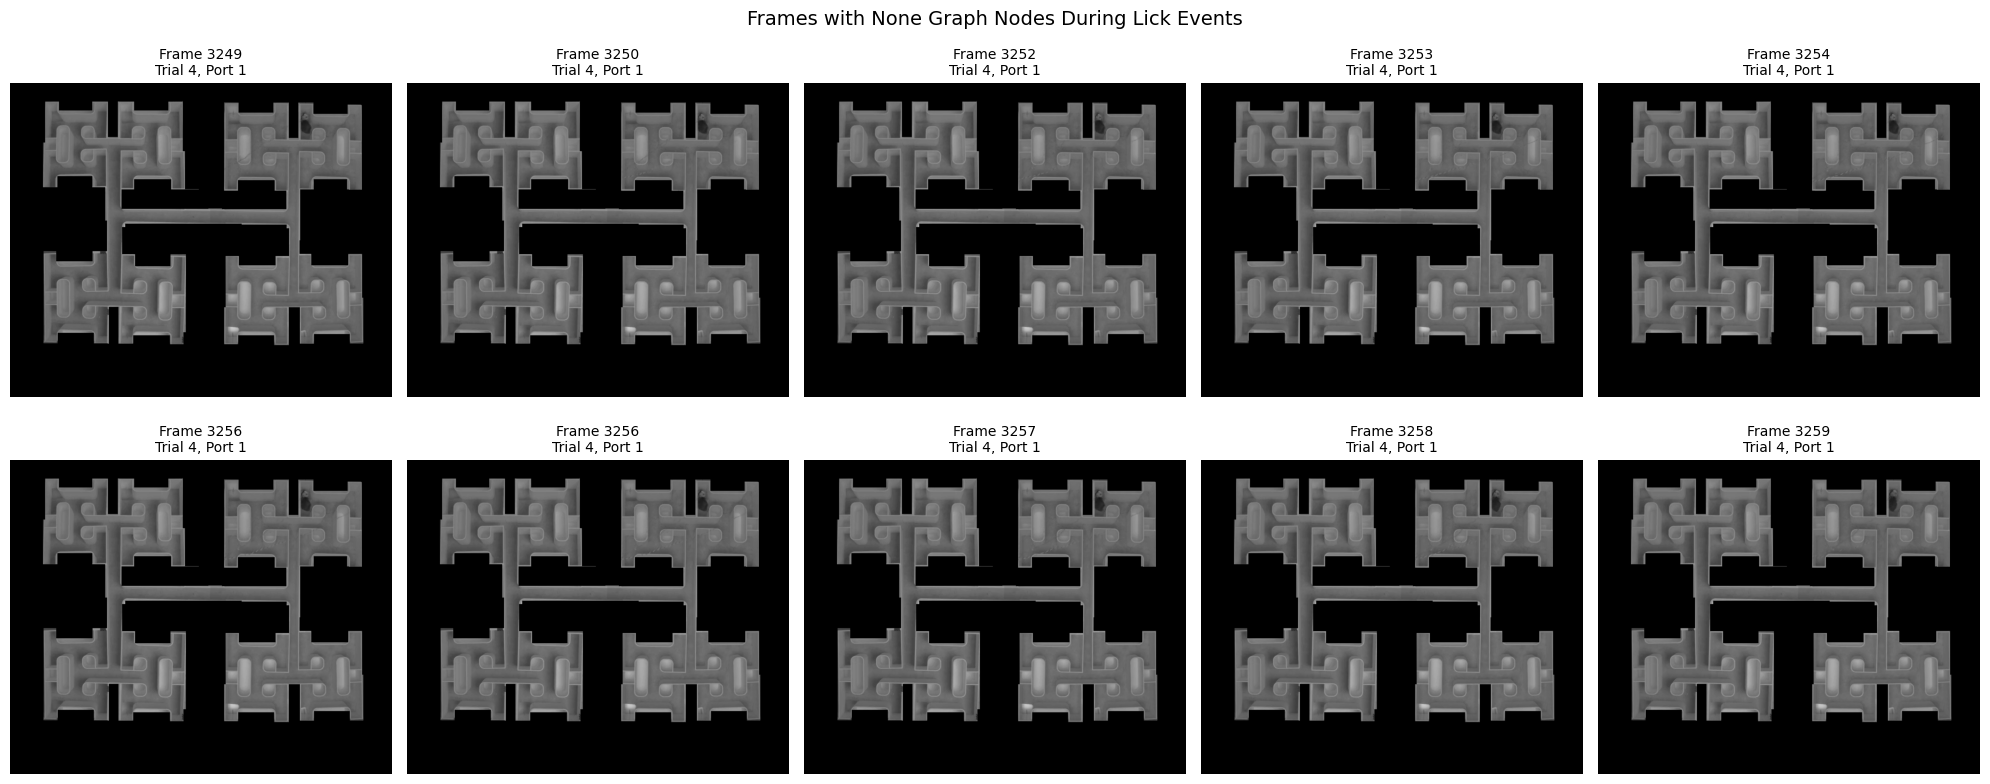

In [505]:
# Find lick events where graph node is None and display the frames
import cv2
import matplotlib.pyplot as plt

print("\n" + "="*60)
print("ANALYZING LICK EVENTS WITH NONE NODES")
print("="*60)

# Filter for lick events that have 'None' in their nodes
licks_with_none = lick_frames[lick_frames['all_nodes'].str.contains('None', na=False)]

print(f"\nFound {len(licks_with_none)} lick events with None nodes")

if len(licks_with_none) > 0:
    print(f"\nBreakdown by port:")
    for port in sorted(licks_with_none['lick_port'].unique()):
        port_count = len(licks_with_none[licks_with_none['lick_port'] == port])
        print(f"  Port {port}: {port_count} licks with None nodes")
    
    print(f"\n\nFirst 10 lick events with None nodes:")
    print(licks_with_none[['trial_idx', 'lick_port', 'most_common_node', 'num_frames', 'unique_nodes', 'all_nodes']].head(10))
    
    # For each lick event with None, find the specific frames where node is None
    print(f"\n\nDetailed frame-level analysis for licks with None nodes:")
    
    none_frame_details = []
    
    for idx, row in licks_with_none.head(20).iterrows():  # Limit to first 20 for analysis
        trial_idx = row['trial_idx']
        lick_port = row['lick_port']
        frame_start = row['frame_idx_start']
        frame_end = row['frame_idx_end']
        all_nodes = row['all_nodes'].split(',')
        
        # Find which specific frames had None
        frame_range = range(frame_start, frame_end + 1)
        for i, (frame_idx, node) in enumerate(zip(frame_range, all_nodes)):
            if node == 'None':
                none_frame_details.append({
                    'trial_idx': trial_idx,
                    'lick_port': lick_port,
                    'frame_idx': frame_idx,
                    'position_in_lick': i,
                    'total_frames_in_lick': len(all_nodes)
                })
    
    none_frames_df = pd.DataFrame(none_frame_details)
    print(f"\nFound {len(none_frames_df)} individual frames with None nodes")
    print(none_frames_df.head(20))
    
    # Load video and display frames with None nodes
    print(f"\n\nLoading frames from video...")
    cap = cv2.VideoCapture(maze_video_path)
    
    if not cap.isOpened():
        print(f"Error: Could not open video at {maze_video_path}")
    else:
        # Display first 10 frames with None nodes
        frames_to_display = none_frames_df.head(10)
        
        if len(frames_to_display) > 0:
            fig, axes = plt.subplots(2, 5, figsize=(20, 8))
            axes = axes.flatten()
            
            for idx, (_, frame_info) in enumerate(frames_to_display.iterrows()):
                frame_idx = frame_info['frame_idx']
                trial_idx = frame_info['trial_idx']
                lick_port = frame_info['lick_port']
                
                # Seek to the specific frame
                cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
                ret, frame = cap.read()
                
                if ret:
                    # Convert BGR to RGB for matplotlib
                    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                    axes[idx].imshow(frame_rgb)
                    axes[idx].set_title(f"Frame {frame_idx}\nTrial {trial_idx}, Port {lick_port}", fontsize=10)
                    axes[idx].axis('off')
                else:
                    axes[idx].text(0.5, 0.5, f"Could not load\nframe {frame_idx}", 
                                  ha='center', va='center')
                    axes[idx].axis('off')
            
            # Hide any unused subplots
            for idx in range(len(frames_to_display), 10):
                axes[idx].axis('off')
            
            plt.tight_layout()
            plt.suptitle("Frames with None Graph Nodes During Lick Events", fontsize=14, y=1.02)
            plt.show()
        
        cap.release()
else:
    print("\nNo lick events with None nodes found!")

## Zigzag Analysis: Leaf-Parent Node Transitions

Analyze rapid transitions between leaf reward nodes and their parent nodes to quantify tracking instability.

In [506]:
# Define reward leaf nodes and their parent nodes based on the reward port analysis
# Port -> (Leaf Node, Parent Node(s))
reward_leaf_parents = {
    1: ('R522', ['R411']),   # Port 1: 100% R522
    2: ('R526', ['R413']),   # Port 2: 100% R526
    3: ('L56', ['L43']),     # Port 3: 78% L56, 22% L43
    4: ('L510', ['L45']),    # Port 4: 71% L510, 29% L45  
    5: ('L521', ['L410']),   # Port 5: 100% L521
    6: ('L525', ['L412']),   # Port 6: 55% L525, 45% L412
    7: ('R55', ['R42']),     # Port 7: 76% R42, 24% R55
    8: ('R59', ['R44'])      # Port 8: 96% R59, 4% R44
}

# # Also track secondary nodes that appeared in the analysis
# reward_secondary_nodes = {
#     3: 'L43',
#     4: 'L45',
#     6: 'L412',
#     7: 'R55',
#     8: 'R44'
# }

print("Reward leaf nodes and their expected parents:")
for port, (leaf, parents) in reward_leaf_parents.items():
    # secondary = f" (secondary: {reward_secondary_nodes[port]})" if port in reward_secondary_nodes else ""
    print(f"  Port {port}: {leaf} -> {parents}")


Reward leaf nodes and their expected parents:
  Port 1: R522 -> ['R411']
  Port 2: R526 -> ['R413']
  Port 3: L56 -> ['L43']
  Port 4: L510 -> ['L45']
  Port 5: L521 -> ['L410']
  Port 6: L525 -> ['L412']
  Port 7: R55 -> ['R42']
  Port 8: R59 -> ['R44']


In [507]:
# Analyze lick events per port - how many licks in each node
print("\n" + "="*60)
print("LICK EVENTS ANALYSIS: NODE DISTRIBUTION PER PORT")
print("="*60)

# Use all lick events (lick_frames includes all matched licks now)
print(f"\nTotal lick events analyzed: {len(lick_frames)}")
print(f"Total licks in original data: {len(lick_df)}")
print(f"Match rate: {len(lick_frames)/len(lick_df)*100:.2f}%\n")

# Analyze each port
from collections import Counter

for port in sorted(lick_frames['lick_port'].unique()):
    port_licks = lick_frames[lick_frames['lick_port'] == port]
    
    # Check if this is port 9 (not a physical port)
    if port == 9:
        print(f"\n{'='*60}")
        print(f"PORT {port} - Non-physical port (no expected node)")
        print(f"{'='*60}")
        print(f"Total lick events: {len(port_licks)}")
        
        # Count nodes across all frames during all licks
        all_nodes = []
        for nodes_str in port_licks['all_nodes']:
            all_nodes.extend(nodes_str.split(','))
        
        node_counts = Counter(all_nodes)
        total_frames = len(all_nodes)
        
        print(f"Total frames during licks: {total_frames}")
        print(f"\nNode distribution (no expected node for this port):")
        
        # Sort by count descending
        for node, count in node_counts.most_common():
            pct = count / total_frames * 100
            print(f"    {node:10s}: {count:5d} frames ({pct:5.1f}%)")
        
        continue
    
    # For physical ports (1-8), check if port is defined
    if port not in reward_leaf_parents:
        print(f"\n{'='*60}")
        print(f"PORT {port} - WARNING: Not defined in reward_leaf_parents")
        print(f"{'='*60}")
        print(f"Total lick events: {len(port_licks)}")
        print(f"Skipping analysis for this port...")
        continue
    
    expected_leaf = reward_leaf_parents[port][0]
    
    print(f"\n{'='*60}")
    print(f"PORT {port} - Expected Node: {expected_leaf}")
    print(f"{'='*60}")
    print(f"Total lick events: {len(port_licks)}")
    
    # Count nodes across all frames during all licks
    all_nodes = []
    for nodes_str in port_licks['all_nodes']:
        all_nodes.extend(nodes_str.split(','))
    
    node_counts = Counter(all_nodes)
    total_frames = len(all_nodes)
    
    print(f"Total frames during licks: {total_frames}")
    print(f"\nNode distribution:")
    
    # Sort by count descending
    for node, count in node_counts.most_common():
        pct = count / total_frames * 100
        marker = "✓" if node == expected_leaf else " "
        print(f"  {marker} {node:10s}: {count:5d} frames ({pct:5.1f}%)")
    
    # Calculate accuracy (frames in expected node)
    correct_frames = node_counts.get(expected_leaf, 0)
    accuracy = correct_frames / total_frames * 100 if total_frames > 0 else 0
    print(f"\nAccuracy: {correct_frames}/{total_frames} frames in correct node ({accuracy:.1f}%)")

print("\n" + "="*60)
print("ANALYSIS COMPLETE")
print("="*60)


LICK EVENTS ANALYSIS: NODE DISTRIBUTION PER PORT

Total lick events analyzed: 17033
Total licks in original data: 17033
Match rate: 100.00%


PORT 1 - Expected Node: R522
Total lick events: 2256
Total frames during licks: 8826

Node distribution:
    None      :  8825 frames (100.0%)
  ✓ R522      :     1 frames (  0.0%)

Accuracy: 1/8826 frames in correct node (0.0%)

PORT 2 - Expected Node: R526
Total lick events: 4634
Total frames during licks: 19987

Node distribution:
  ✓ R526      : 19987 frames (100.0%)

Accuracy: 19987/19987 frames in correct node (100.0%)

PORT 3 - Expected Node: L56
Total lick events: 1403
Total frames during licks: 5836

Node distribution:
  ✓ L56       :  5812 frames ( 99.6%)
    L43       :    24 frames (  0.4%)

Accuracy: 5812/5836 frames in correct node (99.6%)

PORT 4 - Expected Node: L510
Total lick events: 2621
Total frames during licks: 9390

Node distribution:
  ✓ L510      :  9385 frames ( 99.9%)
    L45       :     5 frames (  0.1%)

Accuracy: 93

In [508]:
# Function to detect zigzag patterns between leaf and parent nodes
def detect_zigzags(nav_df, leaf_node, parent_nodes, max_gap_frames=5, bodypart='headstage'):
    """
    Detect rapid transitions (zigzags) between a leaf node and its parent node(s).
    
    Parameters:
    - nav_df: NaviGraph DataFrame with graph locations
    - leaf_node: The leaf node name (e.g., 'R522')
    - parent_nodes: List of potential parent node names (e.g., ['R52'])
    - max_gap_frames: Maximum number of frames for a "quick" jump (threshold)
    - bodypart: Which bodypart to use for graph location
    
    Returns:
    - DataFrame with zigzag events
    """
    node_col = f'{bodypart}_graph_node'
    
    # Get graph locations for all frames
    locations = nav_df[node_col].values
    
    zigzag_events = []
    
    # Iterate through the sequence looking for patterns
    i = 0
    while i < len(locations) - max_gap_frames - 1:
        current_node = locations[i]
        
        # Check if we're starting from the leaf node
        if current_node == leaf_node:
            # Look ahead for potential zigzag
            for gap in range(1, max_gap_frames + 1):
                if i + gap >= len(locations):
                    break
                    
                middle_node = locations[i + gap]
                
                # Check if middle node is a parent
                if middle_node in parent_nodes:
                    # Check if we return to leaf within the gap threshold
                    for return_gap in range(1, gap + 1):
                        if i + gap + return_gap >= len(locations):
                            break
                        
                        return_node = locations[i + gap + return_gap]
                        
                        if return_node == leaf_node:
                            # Found a zigzag pattern!
                            # Count how long we stay in leaf before and after
                            frames_before = 1
                            for j in range(i - 1, -1, -1):
                                if locations[j] == leaf_node:
                                    frames_before += 1
                                else:
                                    break
                            
                            frames_in_parent = return_gap
                            
                            frames_after = 1
                            for j in range(i + gap + return_gap + 1, min(i + gap + return_gap + 50, len(locations))):
                                if locations[j] == leaf_node:
                                    frames_after += 1
                                else:
                                    break
                            
                            zigzag_events.append({
                                'frame_start': i,
                                'frame_parent': i + gap,
                                'frame_return': i + gap + return_gap,
                                'leaf_node': leaf_node,
                                'parent_node': middle_node,
                                'frames_before_zigzag': frames_before,
                                'frames_in_parent': frames_in_parent,
                                'frames_after_zigzag': frames_after,
                                'total_zigzag_duration': gap + return_gap
                            })
                            
                            # Skip ahead to avoid double-counting
                            i = i + gap + return_gap
                            break
                    else:
                        continue
                    break
        
        i += 1
    
    return pd.DataFrame(zigzag_events)

print("Zigzag detection function defined.")
print(f"Will analyze transitions with gaps up to 5 frames (125ms at 40 FPS)")


Zigzag detection function defined.
Will analyze transitions with gaps up to 5 frames (125ms at 40 FPS)


In [509]:
# Analyze zigzags for all reward leaf nodes
print("="*80)
print("ZIGZAG ANALYSIS FOR ALL REWARD LEAF NODES")
print("="*80)

all_zigzags = {}
threshold_analysis = {}

for port, (leaf_node, parent_nodes) in reward_leaf_parents.items():
    print(f"\n{'='*80}")
    print(f"Port {port}: {leaf_node} <-> {parent_nodes}")
    print(f"{'='*80}")
    
    # Detect zigzags for different thresholds
    threshold_results = {}
    
    for threshold in [1, 2, 3, 5]:
        zigzags = detect_zigzags(nav_df, leaf_node, parent_nodes, max_gap_frames=threshold, bodypart='headstage')
        threshold_results[threshold] = zigzags
        
        if len(zigzags) > 0:
            print(f"\nThreshold = {threshold} frames ({threshold * 25}ms):")
            print(f"  Total zigzag events: {len(zigzags)}")
            print(f"  Avg frames in parent: {zigzags['frames_in_parent'].mean():.1f}")
            print(f"  Avg frames before zigzag: {zigzags['frames_before_zigzag'].mean():.1f}")
            print(f"  Avg frames after zigzag: {zigzags['frames_after_zigzag'].mean():.1f}")
            
            # Show distribution of parent frame durations
            parent_duration_counts = zigzags['frames_in_parent'].value_counts().sort_index()
            print(f"  Parent node duration distribution:")
            for duration, count in parent_duration_counts.items():
                print(f"    {duration} frame(s): {count} events ({count/len(zigzags)*100:.1f}%)")
        else:
            print(f"\nThreshold = {threshold} frames ({threshold * 25}ms): No zigzags detected")
    
    all_zigzags[port] = threshold_results

print(f"\n{'='*80}")
print("ANALYSIS COMPLETE")
print(f"{'='*80}")


ZIGZAG ANALYSIS FOR ALL REWARD LEAF NODES

Port 1: R522 <-> ['R411']

Threshold = 1 frames (25ms):
  Total zigzag events: 1
  Avg frames in parent: 1.0
  Avg frames before zigzag: 1.0
  Avg frames after zigzag: 2.0
  Parent node duration distribution:
    1 frame(s): 1 events (100.0%)

Threshold = 2 frames (50ms):
  Total zigzag events: 2
  Avg frames in parent: 1.5
  Avg frames before zigzag: 1.5
  Avg frames after zigzag: 4.0
  Parent node duration distribution:
    1 frame(s): 1 events (50.0%)
    2 frame(s): 1 events (50.0%)

Threshold = 3 frames (75ms):
  Total zigzag events: 2
  Avg frames in parent: 1.5
  Avg frames before zigzag: 1.0
  Avg frames after zigzag: 4.0
  Parent node duration distribution:
    1 frame(s): 1 events (50.0%)
    2 frame(s): 1 events (50.0%)

Threshold = 5 frames (125ms):
  Total zigzag events: 2
  Avg frames in parent: 1.5
  Avg frames before zigzag: 1.0
  Avg frames after zigzag: 4.0
  Parent node duration distribution:
    1 frame(s): 1 events (50.0%)


SUMMARY TABLE: ZIGZAG EVENTS BY PORT AND THRESHOLD
 Port Leaf Node  Threshold (frames)  Threshold (ms)  Total Zigzags  Avg Parent Frames  1-Frame Parents  Avg Before  Avg After
    1      R522                   1              25              1           1.000000                1    1.000000   2.000000
    1      R522                   2              50              2           1.500000                1    1.500000   4.000000
    1      R522                   3              75              2           1.500000                1    1.000000   4.000000
    1      R522                   5             125              2           1.500000                1    1.000000   4.000000
    2      R526                   1              25              2           1.000000                2    2.000000  40.000000
    2      R526                   2              50              3           1.333333                2    8.666667  27.000000
    2      R526                   3              75              3

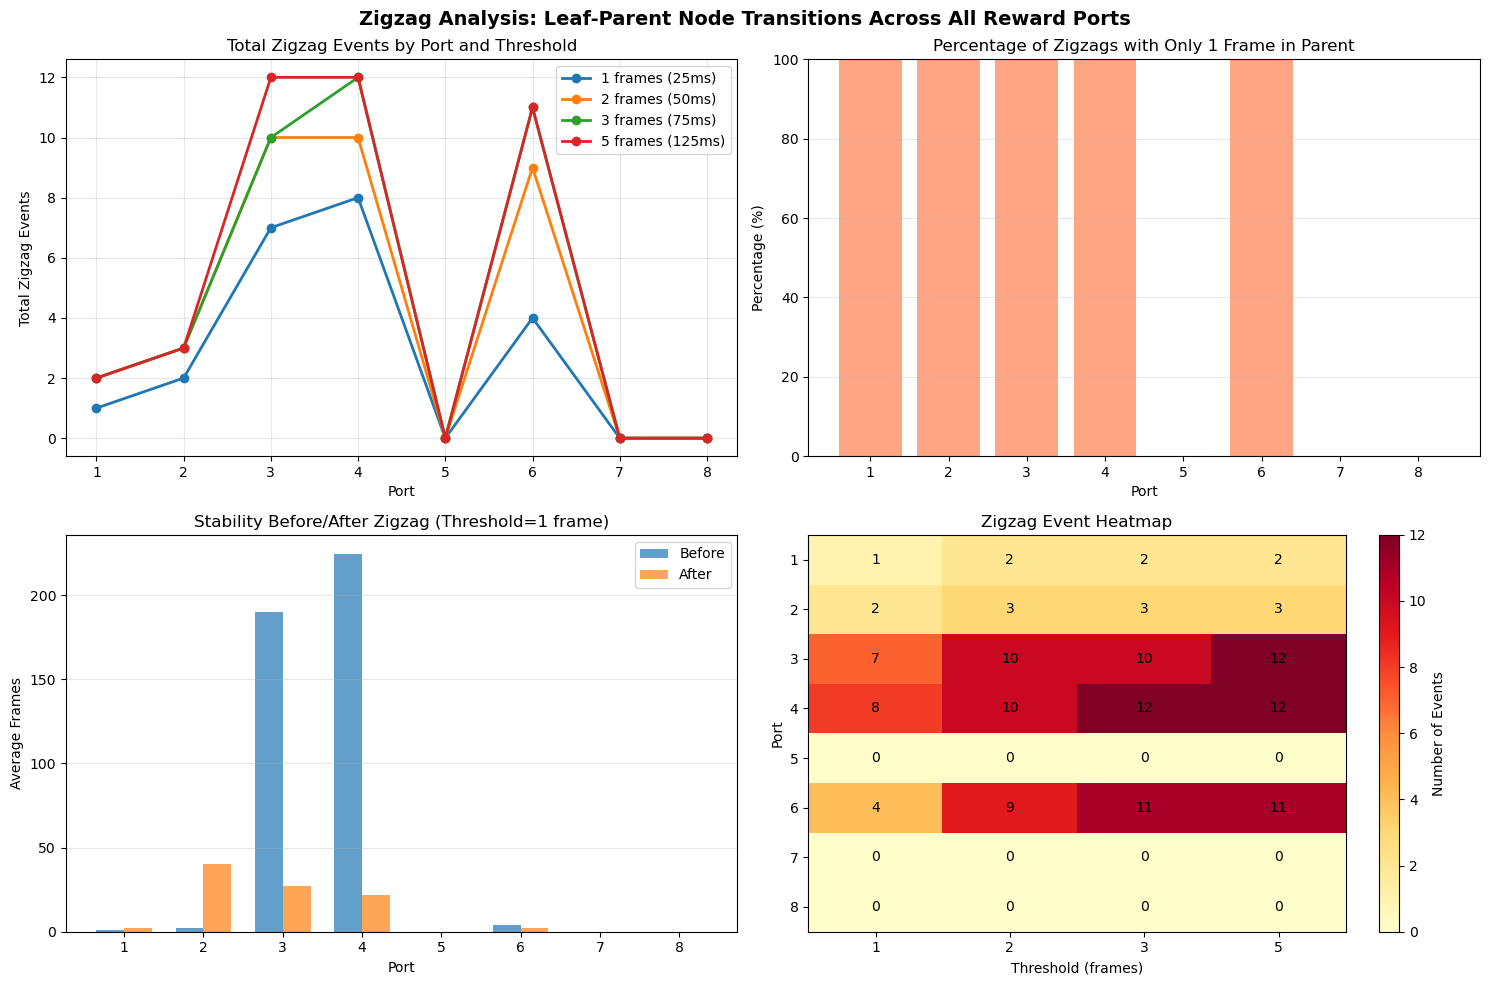


Visualization complete!


In [ ]:
# Create summary table across all ports and thresholds
import matplotlib.pyplot as plt

summary_data = []

for port in sorted(all_zigzags.keys()):
    leaf_node = reward_leaf_parents[port][0]
    for threshold in [1, 2, 3, 5]:
        zigzags = all_zigzags[port][threshold]
        summary_data.append({
            'Port': port,
            'Leaf Node': leaf_node,
            'Threshold (frames)': threshold,
            'Threshold (ms)': threshold * 25,
            'Total Zigzags': len(zigzags),
            'Avg Parent Frames': zigzags['frames_in_parent'].mean() if len(zigzags) > 0 else 0,
            '1-Frame Parents': (zigzags['frames_in_parent'] == 1).sum() if len(zigzags) > 0 else 0,
            'Avg Before': zigzags['frames_before_zigzag'].mean() if len(zigzags) > 0 else 0,
            'Avg After': zigzags['frames_after_zigzag'].mean() if len(zigzags) > 0 else 0
        })


summary_df = pd.DataFrame(summary_data)

print("\n" + "="*80)
print("SUMMARY TABLE: ZIGZAG EVENTS BY PORT AND THRESHOLD")
print("="*80)
print(summary_df.to_string(index=False))

# Plot zigzag counts by port and threshold
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Zigzag Analysis: Leaf-Parent Node Transitions Across All Reward Ports', fontsize=14, fontweight='bold')

# Plot 1: Total zigzags by port for each threshold
for threshold in [1, 2, 3, 5]:
    threshold_data = summary_df[summary_df['Threshold (frames)'] == threshold]
    axes[0, 0].plot(threshold_data['Port'], threshold_data['Total Zigzags'], 
                    marker='o', label=f'{threshold} frames ({threshold*25}ms)', linewidth=2)

axes[0, 0].set_xlabel('Port')
axes[0, 0].set_ylabel('Total Zigzag Events')
axes[0, 0].set_title('Total Zigzag Events by Port and Threshold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_xticks(range(1, 9))

# Plot 2: Percentage of 1-frame parent visits
threshold_1_data = summary_df[summary_df['Threshold (frames)'] >= 1].groupby('Port').first()
total_zigzags = threshold_1_data['Total Zigzags']
one_frame = threshold_1_data['1-Frame Parents']
pct_one_frame = (one_frame / total_zigzags * 100).fillna(0)

axes[0, 1].bar(range(1, 9), pct_one_frame, color='coral', alpha=0.7)
axes[0, 1].set_xlabel('Port')
axes[0, 1].set_ylabel('Percentage (%)')
axes[0, 1].set_title('Percentage of Zigzags with Only 1 Frame in Parent')
axes[0, 1].grid(True, alpha=0.3, axis='y')
axes[0, 1].set_xticks(range(1, 9))
axes[0, 1].set_ylim([0, 100])

# Plot 3: Average frames before/after zigzag (threshold=1)
threshold_1_only = summary_df[summary_df['Threshold (frames)'] == 1]
x = np.arange(len(threshold_1_only))
width = 0.35

axes[1, 0].bar(x - width/2, threshold_1_only['Avg Before'], width, label='Before', alpha=0.7)
axes[1, 0].bar(x + width/2, threshold_1_only['Avg After'], width, label='After', alpha=0.7)
axes[1, 0].set_xlabel('Port')
axes[1, 0].set_ylabel('Average Frames')
axes[1, 0].set_title('Stability Before/After Zigzag (Threshold=1 frame)')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(threshold_1_only['Port'])
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Plot 4: Heatmap of zigzag counts
pivot_table = summary_df.pivot(index='Port', columns='Threshold (frames)', values='Total Zigzags')
im = axes[1, 1].imshow(pivot_table.values, cmap='YlOrRd', aspect='auto')
axes[1, 1].set_xticks(range(len(pivot_table.columns)))
axes[1, 1].set_xticklabels(pivot_table.columns)
axes[1, 1].set_yticks(range(len(pivot_table.index)))
axes[1, 1].set_yticklabels(pivot_table.index)
axes[1, 1].set_xlabel('Threshold (frames)')
axes[1, 1].set_ylabel('Port')
axes[1, 1].set_title('Zigzag Event Heatmap')

# Add text annotations
for i in range(len(pivot_table.index)):
    for j in range(len(pivot_table.columns)):
        text = axes[1, 1].text(j, i, int(pivot_table.values[i, j]),
                              ha="center", va="center", color="black", fontsize=10)

plt.colorbar(im, ax=axes[1, 1], label='Number of Events')

plt.tight_layout()
plt.show()

print("\nVisualization complete!")


In [ ]:
# Detailed example: Show specific zigzag events for one port
example_port = 2  # Port with 100% consistency (R526)
example_threshold = 1

print(f"\n{'='*80}")
print(f"DETAILED EXAMPLE: Port {example_port} ({reward_leaf_parents[example_port][0]}) with Threshold={example_threshold}")
print(f"{'='*80}\n")

example_zigzags = all_zigzags[example_port][example_threshold]

if len(example_zigzags) > 0:
    print(f"Total zigzag events found: {len(example_zigzags)}")
    print(f"\nFirst 10 zigzag events:\n")
    
    display_cols = ['frame_start', 'frame_parent', 'frame_return', 'leaf_node', 'parent_node', 
                    'frames_before_zigzag', 'frames_in_parent', 'frames_after_zigzag']
    print(example_zigzags[display_cols].head(10).to_string(index=False))
    
    # Show timing statistics
    print(f"\n\nTiming Statistics:")
    print(f"  Duration in parent node:")
    print(f"    Min: {example_zigzags['frames_in_parent'].min()} frames ({example_zigzags['frames_in_parent'].min() * 25}ms)")
    print(f"    Max: {example_zigzags['frames_in_parent'].max()} frames ({example_zigzags['frames_in_parent'].max() * 25}ms)")
    print(f"    Mean: {example_zigzags['frames_in_parent'].mean():.1f} frames ({example_zigzags['frames_in_parent'].mean() * 25:.1f}ms)")
    
    print(f"\n  Stability before zigzag:")
    print(f"    Min: {example_zigzags['frames_before_zigzag'].min()} frames")
    print(f"    Max: {example_zigzags['frames_before_zigzag'].max()} frames")
    print(f"    Mean: {example_zigzags['frames_before_zigzag'].mean():.1f} frames")
    
    print(f"\n  Stability after zigzag:")
    print(f"    Min: {example_zigzags['frames_after_zigzag'].min()} frames")
    print(f"    Max: {example_zigzags['frames_after_zigzag'].max()} frames")
    print(f"    Mean: {example_zigzags['frames_after_zigzag'].mean():.1f} frames")
    
    # Calculate zigzag rate
    leaf_node = reward_leaf_parents[example_port][0]
    total_frames_in_leaf = (nav_df['headstage_graph_node'] == leaf_node).sum()
    zigzag_rate = len(example_zigzags) / total_frames_in_leaf * 100 if total_frames_in_leaf > 0 else 0
    
    print(f"\n  Zigzag frequency:")
    print(f"    Total frames in {leaf_node}: {total_frames_in_leaf}")
    print(f"    Zigzag events: {len(example_zigzags)}")
    print(f"    Zigzag rate: {zigzag_rate:.2f}% of frames in leaf node")
else:
    
    print("No zigzag events detected for this port and threshold.")



DETAILED EXAMPLE: Port 2 (R526) with Threshold=1

Total zigzag events found: 2

First 10 zigzag events:

 frame_start  frame_parent  frame_return leaf_node parent_node  frames_before_zigzag  frames_in_parent  frames_after_zigzag
      101033        101034        101035      R526        R413                     3                 1                   30
      120621        120622        120623      R526        R413                     1                 1                   50


Timing Statistics:
  Duration in parent node:
    Min: 1 frames (25ms)
    Max: 1 frames (25ms)
    Mean: 1.0 frames (25.0ms)

  Stability before zigzag:
    Min: 1 frames
    Max: 3 frames
    Mean: 2.0 frames

  Stability after zigzag:
    Min: 30 frames
    Max: 50 frames
    Mean: 40.0 frames

  Zigzag frequency:
    Total frames in R526: 27547
    Zigzag events: 2
    Zigzag rate: 0.01% of frames in leaf node


In [512]:
# Overall session summary
print(f"\n{'='*80}")
print("OVERALL SESSION SUMMARY")
print(f"{'='*80}\n")

# Calculate total zigzags across all ports for threshold=1
total_zigzags_t1 = sum(len(all_zigzags[port][1]) for port in all_zigzags.keys())
total_frames = len(nav_df)

print(f"Total frames in session: {total_frames:,}")
print(f"Total frames analyzed: {total_frames:,}")
print(f"\nZigzag events (threshold = 1 frame / 25ms):")
print(f"  Total across all 8 reward ports: {total_zigzags_t1}")
print(f"  Rate: {total_zigzags_t1/total_frames*100:.3f}% of all frames")
print(f"  Average per port: {total_zigzags_t1/8:.1f}")

# Count total frames spent in reward leaf nodes
total_leaf_frames = 0
for port, (leaf_node, _) in reward_leaf_parents.items():
    leaf_frames = (nav_df['headstage_graph_node'] == leaf_node).sum()
    total_leaf_frames += leaf_frames

print(f"\nTotal frames in reward leaf nodes: {total_leaf_frames:,} ({total_leaf_frames/total_frames*100:.1f}% of session)")
print(f"Zigzag rate in reward areas: {total_zigzags_t1/total_leaf_frames*100:.2f}% of frames in leaf nodes")

# Most problematic ports
print(f"\n{'='*40}")
print("Most Problematic Ports (Threshold=1):")
print(f"{'='*40}")

port_zigzag_counts = [(port, len(all_zigzags[port][1])) for port in sorted(all_zigzags.keys())]
port_zigzag_counts.sort(key=lambda x: x[1], reverse=True)

for i, (port, count) in enumerate(port_zigzag_counts[:5], 1):
    leaf_node = reward_leaf_parents[port][0]
    leaf_frames = (nav_df['headstage_graph_node'] == leaf_node).sum()
    rate = count / leaf_frames * 100 if leaf_frames > 0 else 0
    print(f"  {i}. Port {port} ({leaf_node}): {count} events ({rate:.2f}% of {leaf_frames} leaf frames)")

print(f"\n{'='*80}")
print("ZIGZAG ANALYSIS COMPLETE")
print(f"{'='*80}")
print("\nKey Findings:")
print("- Zigzag events indicate rapid transitions between leaf and parent nodes")
print("- High zigzag rates suggest tracking instability near reward locations")
print("- Threshold=1 captures single-frame jumps (most sensitive)")
print("- This data can guide post-processing or smoothing strategies")



OVERALL SESSION SUMMARY

Total frames in session: 185,536
Total frames analyzed: 185,536

Zigzag events (threshold = 1 frame / 25ms):
  Total across all 8 reward ports: 22
  Rate: 0.012% of all frames
  Average per port: 2.8

Total frames in reward leaf nodes: 48,727 (26.3% of session)
Zigzag rate in reward areas: 0.05% of frames in leaf nodes

Most Problematic Ports (Threshold=1):
  1. Port 4 (L510): 8 events (0.06% of 13384 leaf frames)
  2. Port 3 (L56): 7 events (0.09% of 7479 leaf frames)
  3. Port 6 (L525): 4 events (2.35% of 170 leaf frames)
  4. Port 2 (R526): 2 events (0.01% of 27547 leaf frames)
  5. Port 1 (R522): 1 events (0.82% of 122 leaf frames)

ZIGZAG ANALYSIS COMPLETE

Key Findings:
- Zigzag events indicate rapid transitions between leaf and parent nodes
- High zigzag rates suggest tracking instability near reward locations
- Threshold=1 captures single-frame jumps (most sensitive)
- This data can guide post-processing or smoothing strategies


## Fix Graph Locations: Smoothing Leaf-Parent Zigzags

Apply correction to remove rapid single-frame transitions between leaf nodes and their parents, then re-evaluate reward location accuracy.

In [513]:
# Create a corrected version of the graph locations
def smooth_leaf_parent_zigzags(nav_df, reward_leaf_parents, max_gap_frames=1, bodypart='headstage'):
    """
    Smooth out rapid transitions between leaf nodes and their parent nodes.
    
    Strategy: If a leaf node L appears, followed by parent P for ≤ max_gap_frames, 
    followed by leaf L again, replace the parent frames with the leaf node.
    
    Parameters:
    - nav_df: NaviGraph DataFrame with graph locations
    - reward_leaf_parents: Dictionary mapping ports to (leaf, parent_list) tuples
    - max_gap_frames: Maximum number of frames to smooth (threshold)
    - bodypart: Which bodypart to use for graph location
    
    Returns:
    - Corrected DataFrame with smoothed graph locations
    """
    node_col = f'{bodypart}_graph_node'
    
    # Create a copy of the dataframe
    corrected_df = nav_df.copy()
    locations = corrected_df[node_col].values.copy()
    
    # Build a mapping of leaf -> parents for quick lookup
    leaf_to_parents = {}
    for port, (leaf, parents) in reward_leaf_parents.items():
        leaf_to_parents[leaf] = parents
    
    corrections_made = 0
    correction_details = []
    
    # Iterate through the sequence looking for zigzag patterns
    i = 0
    while i < len(locations) - max_gap_frames - 1:
        current_node = locations[i]
        
        # Check if we're starting from a leaf node
        if current_node in leaf_to_parents:
            leaf_node = current_node
            parent_nodes = leaf_to_parents[leaf_node]
            
            # Look ahead for potential zigzag
            for gap in range(1, max_gap_frames + 1):
                if i + gap >= len(locations):
                    break
                    
                middle_node = locations[i + gap]
                
                # Check if middle node is the parent
                if middle_node in parent_nodes:
                    # Check if we return to leaf within gap frames
                    all_parent = True
                    for check_idx in range(i + gap, min(i + gap + gap, len(locations))):
                        if locations[check_idx] not in parent_nodes:
                            all_parent = False
                            break
                    
                    if all_parent:
                        # Check for return to leaf
                        for return_gap in range(1, gap + 1):
                            if i + gap + return_gap >= len(locations):
                                break
                            
                            return_node = locations[i + gap + return_gap]
                            
                            if return_node == leaf_node:
                                # Found a zigzag - correct it!
                                for fix_idx in range(i + gap, i + gap + return_gap):
                                    locations[fix_idx] = leaf_node
                                    corrections_made += 1
                                
                                correction_details.append({
                                    'frame_start': i + gap,
                                    'frame_end': i + gap + return_gap - 1,
                                    'leaf_node': leaf_node,
                                    'parent_node': middle_node,
                                    'frames_corrected': return_gap - 1
                                })
                                
                                # Skip ahead
                                i = i + gap + return_gap - 1
                                break
                        else:
                            continue
                        break
        
        i += 1
    
    # Update the corrected dataframe
    corrected_df[node_col] = locations
    
    return corrected_df, corrections_made, pd.DataFrame(correction_details)

# Apply smoothing with threshold=1 (single-frame parent visits)
print("Applying smoothing to remove single-frame parent visits...")
nav_df_corrected, total_corrections, correction_df = smooth_leaf_parent_zigzags(
    nav_df, reward_leaf_parents, max_gap_frames=1, bodypart='headstage'
)

print(f"\nCorrection complete!")
print(f"Total frames corrected: {total_corrections}")
print(f"Total correction events: {len(correction_df)}")

if len(correction_df) > 0:
    print(f"\nCorrection breakdown by leaf node:")
    for port, (leaf_node, _) in reward_leaf_parents.items():
        leaf_corrections = correction_df[correction_df['leaf_node'] == leaf_node]
        if len(leaf_corrections) > 0:
            print(f"  Port {port} ({leaf_node}): {len(leaf_corrections)} events, {leaf_corrections['frames_corrected'].sum()} frames")


Applying smoothing to remove single-frame parent visits...

Correction complete!
Total frames corrected: 22
Total correction events: 22

Correction breakdown by leaf node:
  Port 1 (R522): 1 events, 0 frames
  Port 2 (R526): 2 events, 0 frames
  Port 3 (L56): 7 events, 0 frames
  Port 4 (L510): 8 events, 0 frames
  Port 6 (L525): 4 events, 0 frames


In [514]:
# Re-evaluate reward locations with corrected data
print("="*80)
print("RE-EVALUATION: REWARD LOCATIONS AFTER CORRECTION")
print("="*80)

# Extract corrected graph locations for reward frames
reward_frames_corrected = reward_frames.copy()
reward_frames_corrected['graph_node_corrected'] = None
reward_frames_corrected['graph_edge_corrected'] = None
reward_frames_corrected['was_corrected'] = False

node_col = 'headstage_graph_node'
edge_col = 'headstage_graph_edge'

for idx, row in reward_frames_corrected.iterrows():
    if pd.isna(row['frame_idx_global']):
        continue
        
    frame_idx = int(row['frame_idx_global'])
    
    if frame_idx < len(nav_df_corrected):
        # Use .at for direct scalar access to avoid iterable issues
        try:
            node_corrected = nav_df_corrected.at[frame_idx, node_col]
            edge_corrected = nav_df_corrected.at[frame_idx, edge_col]
            node_original = nav_df.at[frame_idx, node_col]
        except (KeyError, ValueError):
            # Fallback for duplicate columns or non-standard index
            node_corrected = nav_df_corrected.loc[frame_idx, node_col]
            edge_corrected = nav_df_corrected.loc[frame_idx, edge_col]
            node_original = nav_df.loc[frame_idx, node_col]
            
            # Ensure scalar values
            if hasattr(node_corrected, '__iter__') and not isinstance(node_corrected, str):
                node_corrected = node_corrected.iloc[0] if hasattr(node_corrected, 'iloc') else node_corrected[0]
            if hasattr(edge_corrected, '__iter__') and not isinstance(edge_corrected, str):
                edge_corrected = edge_corrected.iloc[0] if hasattr(edge_corrected, 'iloc') else edge_corrected[0]
            if hasattr(node_original, '__iter__') and not isinstance(node_original, str):
                node_original = node_original.iloc[0] if hasattr(node_original, 'iloc') else node_original[0]
        
        reward_frames_corrected.at[idx, 'graph_node_corrected'] = node_corrected
        reward_frames_corrected.at[idx, 'graph_edge_corrected'] = edge_corrected
        
        # Check if this frame was corrected
        if node_original != node_corrected:
            reward_frames_corrected.at[idx, 'was_corrected'] = True

# Summary by port - BEFORE correction
print("\nBEFORE CORRECTION:")
print("="*80)
for port in sorted(reward_frames['reward_port'].unique()):
    port_data = reward_frames[reward_frames['reward_port'] == port]
    expected_leaf = reward_leaf_parents[port][0]
    
    print(f"\nPort {port} (Expected: {expected_leaf}):")
    valid_nodes = port_data[port_data['graph_node'].notna()]
    if len(valid_nodes) > 0:
        mode_nodes = valid_nodes['graph_node'].mode()
        most_common = mode_nodes.values[0] if len(mode_nodes) > 0 else 'N/A'
        correct_count = (valid_nodes['graph_node'] == expected_leaf).sum()
        
        print(f"  Most common node: {most_common}")
        print(f"  Correct location: {correct_count}/{len(valid_nodes)} ({correct_count/len(valid_nodes)*100:.1f}%)")
        print(f"  Node distribution:")
        node_counts = valid_nodes['graph_node'].value_counts().head(3)
        for node, count in node_counts.items():
            marker = "✓" if node == expected_leaf else "✗"
            print(f"    {marker} {node}: {count} ({count/len(valid_nodes)*100:.1f}%)")

# Summary by port - AFTER correction  
print("\n\nAFTER CORRECTION:")
print("="*80)
total_corrections_at_reward = 0
total_newly_correct = 0

for port in sorted(reward_frames_corrected['reward_port'].unique()):
    port_data = reward_frames_corrected[reward_frames_corrected['reward_port'] == port]
    expected_leaf = reward_leaf_parents[port][0]
    
    print(f"\nPort {port} (Expected: {expected_leaf}):")
    valid_nodes = port_data[port_data['graph_node_corrected'].notna()]
    if len(valid_nodes) > 0:
        mode_nodes = valid_nodes['graph_node_corrected'].mode()
        most_common = mode_nodes.values[0] if len(mode_nodes) > 0 else 'N/A'
        correct_count = (valid_nodes['graph_node_corrected'] == expected_leaf).sum()
        corrected_at_reward = port_data['was_corrected'].sum()
        
        # Calculate improvement
        original_correct = (port_data['graph_node'] == expected_leaf).sum()
        improvement = correct_count - original_correct
        
        print(f"  Most common node: {most_common}")
        print(f"  Correct location: {correct_count}/{len(valid_nodes)} ({correct_count/len(valid_nodes)*100:.1f}%)")
        print(f"  Frames corrected at reward: {corrected_at_reward}")
        if improvement > 0:
            print(f"  ✓ Improvement: +{improvement} correct (+{improvement/len(valid_nodes)*100:.1f}%)")
            total_newly_correct += improvement
        
        print(f"  Node distribution:")
        node_counts = valid_nodes['graph_node_corrected'].value_counts().head(3)
        for node, count in node_counts.items():
            marker = "✓" if node == expected_leaf else "✗"
            print(f"    {marker} {node}: {count} ({count/len(valid_nodes)*100:.1f}%)")
        
        total_corrections_at_reward += corrected_at_reward

print("\n" + "="*80)
print("OVERALL IMPROVEMENT SUMMARY")
print("="*80)
print(f"Total reward frames corrected: {total_corrections_at_reward}")
print(f"Total newly correct reward locations: {total_newly_correct}")
print(f"Percentage of corrections that fixed reward locations: {total_newly_correct/total_corrections_at_reward*100:.1f}%" if total_corrections_at_reward > 0 else "N/A")


RE-EVALUATION: REWARD LOCATIONS AFTER CORRECTION

BEFORE CORRECTION:

Port 1.0 (Expected: R522):

Port 2.0 (Expected: R526):
  Most common node: R526
  Correct location: 201/201 (100.0%)
  Node distribution:
    ✓ R526: 201 (100.0%)

Port 3.0 (Expected: L56):
  Most common node: L56
  Correct location: 77/80 (96.2%)
  Node distribution:
    ✓ L56: 77 (96.2%)
    ✗ L43: 3 (3.8%)

Port 4.0 (Expected: L510):
  Most common node: L510
  Correct location: 107/107 (100.0%)
  Node distribution:
    ✓ L510: 107 (100.0%)

Port 5.0 (Expected: L521):
  Most common node: L410
  Correct location: 1/190 (0.5%)
  Node distribution:
    ✗ L410: 189 (99.5%)
    ✓ L521: 1 (0.5%)

Port 6.0 (Expected: L525):
  Most common node: L412
  Correct location: 0/83 (0.0%)
  Node distribution:
    ✗ L412: 83 (100.0%)

Port 7.0 (Expected: R55):
  Most common node: R42
  Correct location: 0/26 (0.0%)
  Node distribution:
    ✗ R42: 26 (100.0%)

Port 8.0 (Expected: R59):
  Most common node: R44
  Correct location: 0/1

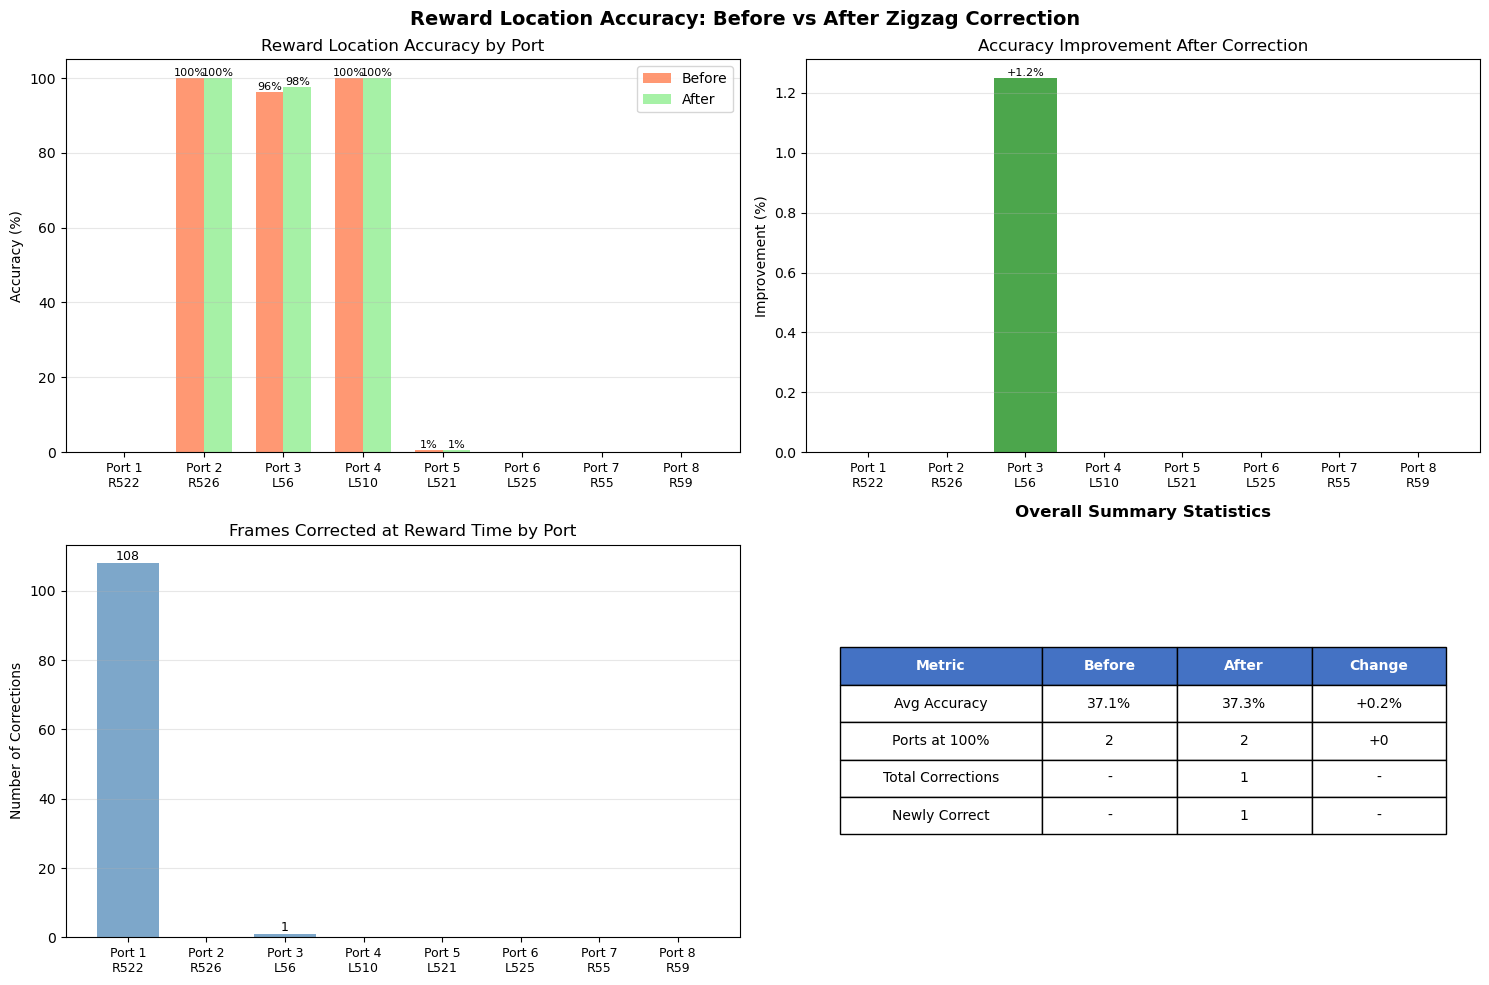


Visualization complete!


In [515]:
# Visualize the improvement
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Reward Location Accuracy: Before vs After Zigzag Correction', fontsize=14, fontweight='bold')

# Calculate accuracy metrics for each port
ports = sorted(reward_frames['reward_port'].unique())
accuracy_before = []
accuracy_after = []
corrections_made = []
port_labels = []

for port in ports:
    expected_leaf = reward_leaf_parents[port][0]
    
    # Before
    port_data_before = reward_frames[reward_frames['reward_port'] == port]
    valid_before = port_data_before[port_data_before['graph_node'].notna()]
    correct_before = (valid_before['graph_node'] == expected_leaf).sum()
    acc_before = correct_before / len(valid_before) * 100 if len(valid_before) > 0 else 0
    
    # After
    port_data_after = reward_frames_corrected[reward_frames_corrected['reward_port'] == port]
    valid_after = port_data_after[port_data_after['graph_node_corrected'].notna()]
    correct_after = (valid_after['graph_node_corrected'] == expected_leaf).sum()
    acc_after = correct_after / len(valid_after) * 100 if len(valid_after) > 0 else 0
    
    # Corrections
    corrections = port_data_after['was_corrected'].sum()
    
    accuracy_before.append(acc_before)
    accuracy_after.append(acc_after)
    corrections_made.append(corrections)
    port_labels.append(f"Port {int(port)}\n{expected_leaf}")

# Plot 1: Accuracy comparison
x = np.arange(len(ports))
width = 0.35

bars1 = axes[0, 0].bar(x - width/2, accuracy_before, width, label='Before', alpha=0.8, color='coral')
bars2 = axes[0, 0].bar(x + width/2, accuracy_after, width, label='After', alpha=0.8, color='lightgreen')

axes[0, 0].set_ylabel('Accuracy (%)')
axes[0, 0].set_title('Reward Location Accuracy by Port')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(port_labels, fontsize=9)
axes[0, 0].legend()
axes[0, 0].set_ylim([0, 105])
axes[0, 0].grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            axes[0, 0].text(bar.get_x() + bar.get_width()/2., height,
                          f'{height:.0f}%', ha='center', va='bottom', fontsize=8)

# Plot 2: Improvement delta
improvement = [after - before for before, after in zip(accuracy_before, accuracy_after)]
colors = ['green' if imp > 0 else 'gray' for imp in improvement]
bars = axes[0, 1].bar(x, improvement, color=colors, alpha=0.7)
axes[0, 1].set_ylabel('Improvement (%)')
axes[0, 1].set_title('Accuracy Improvement After Correction')
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(port_labels, fontsize=9)
axes[0, 1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Add value labels
for bar in bars:
    height = bar.get_height()
    if abs(height) > 0.1:
        axes[0, 1].text(bar.get_x() + bar.get_width()/2., height,
                      f'{height:+.1f}%', ha='center', va='bottom' if height > 0 else 'top', fontsize=8)

# Plot 3: Number of corrections per port
bars = axes[1, 0].bar(x, corrections_made, color='steelblue', alpha=0.7)
axes[1, 0].set_ylabel('Number of Corrections')
axes[1, 0].set_title('Frames Corrected at Reward Time by Port')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(port_labels, fontsize=9)
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Add value labels
for bar in bars:
    height = bar.get_height()
    if height > 0:
        axes[1, 0].text(bar.get_x() + bar.get_width()/2., height,
                      f'{int(height)}', ha='center', va='bottom', fontsize=9)

# Plot 4: Overall summary statistics
summary_data = {
    'Before Correction': [np.mean(accuracy_before), sum(corrections_made), 0],
    'After Correction': [np.mean(accuracy_after), 0, total_newly_correct]
}
summary_labels = ['Avg Accuracy (%)', 'Corrections Made', 'Newly Correct']

axes[1, 1].axis('off')
table_data = [
    ['Metric', 'Before', 'After', 'Change'],
    ['Avg Accuracy', f'{np.mean(accuracy_before):.1f}%', f'{np.mean(accuracy_after):.1f}%', 
     f'{np.mean(accuracy_after) - np.mean(accuracy_before):+.1f}%'],
    ['Ports at 100%', f'{sum(1 for a in accuracy_before if a == 100)}', 
     f'{sum(1 for a in accuracy_after if a == 100)}', 
     f'{sum(1 for a in accuracy_after if a == 100) - sum(1 for a in accuracy_before if a == 100):+d}'],
    ['Total Corrections', '-', f'{total_corrections_at_reward}', '-'],
    ['Newly Correct', '-', f'{total_newly_correct}', '-']
]

table = axes[1, 1].table(cellText=table_data, cellLoc='center', loc='center',
                        colWidths=[0.3, 0.2, 0.2, 0.2])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)

# Style header row
for i in range(4):
    table[(0, i)].set_facecolor('#4472C4')
    table[(0, i)].set_text_props(weight='bold', color='white')

axes[1, 1].set_title('Overall Summary Statistics', fontsize=12, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

print("\nVisualization complete!")


## Reward-Based Correction (0.25s reward period)

Fix graph locations during reward consumption by setting reward frame + next 9 frames to correct leaf node.

In [516]:
# Diagnostic: Check nav_df structure before applying correction
print("=== nav_df Structure Diagnostic ===")
print(f"Shape: {nav_df.shape}")
print(f"Column type: {type(nav_df.columns)}")
print(f"Is MultiIndex: {isinstance(nav_df.columns, pd.MultiIndex)}")
print(f"\nFirst 5 columns: {nav_df.columns[:5].tolist()}")
if isinstance(nav_df.columns, pd.MultiIndex):
    print("\nSearching for graph_node columns in MultiIndex:")
    graph_cols = [col for col in nav_df.columns if 'graph_node' in str(col)]
    print(f"Found {len(graph_cols)} graph_node columns: {graph_cols}")
else:
    print("\nSearching for graph_node columns in flat structure:")
    graph_cols = [col for col in nav_df.columns if 'graph_node' in col]
    print(f"Found {len(graph_cols)} graph_node columns: {graph_cols}")

=== nav_df Structure Diagnostic ===
Shape: (185536, 30)
Column type: <class 'pandas.Index'>
Is MultiIndex: False

First 5 columns: ['headstage_x', 'headstage_y', 'headstage_likelihood', 'ear_L_x', 'ear_L_y']

Searching for graph_node columns in flat structure:
Found 6 graph_node columns: ['ear_L_graph_node', 'ear_R_graph_node', 'headstage_graph_node', 'midbody_graph_node', 'tailbase_graph_node', 'weighted_graph_node']


In [517]:
# Define and apply reward-based correction
def apply_reward_based_correction(nav_df, reward_frames, port_to_leaf_mapping, reward_duration_frames=10, bodypart='headstage'):
    corrected_df = nav_df.copy()
    
    # Find the correct column for graph_node
    if isinstance(corrected_df.columns, pd.MultiIndex):
        # Try MultiIndex access
        node_col = (bodypart, 'graph_node')
        if node_col not in corrected_df.columns:
            # Search for any column with graph_node
            graph_cols = [col for col in corrected_df.columns if 'graph_node' in str(col)]
            if not graph_cols:
                raise ValueError(f"No graph_node column found in DataFrame")
            node_col = graph_cols[0]
            print(f"Using graph_node column: {node_col}")
    else:
        # Flat columns - look for headstage_graph_node or similar
        if f'{bodypart}_graph_node' in corrected_df.columns:
            node_col = f'{bodypart}_graph_node'
        elif 'graph_node' in corrected_df.columns:
            node_col = 'graph_node'
        else:
            raise ValueError(f"No suitable graph_node column found. Available columns: {corrected_df.columns[:10].tolist()}")
    
    corrections_made = 0
    correction_details = {port: {'frames_corrected': 0, 'changed_from': {}} 
                         for port in port_to_leaf_mapping.keys()}
    port_to_leaf = {port: info[0] for port, info in port_to_leaf_mapping.items()}
    
    print(f"Applying reward-based correction for {len(reward_frames)} reward events...")
    print(f"Each reward corrects {reward_duration_frames} frames (0.25s at 40 FPS)")
    print(f"Using column: {node_col}\n")
    
    locations = corrected_df[node_col].tolist()
    
    for idx, row in reward_frames.iterrows():
        reward_frame = int(row['frame_idx_global'])
        reward_port = int(row['reward_port'])
        expected_leaf = port_to_leaf[reward_port]
        
        start_frame = reward_frame
        end_frame = min(reward_frame + reward_duration_frames, len(locations))
        
        for frame_idx in range(start_frame, end_frame):
            current_node = locations[frame_idx]
            if pd.notna(current_node) and current_node != expected_leaf:
                if current_node not in correction_details[reward_port]['changed_from']:
                    correction_details[reward_port]['changed_from'][current_node] = 0
                correction_details[reward_port]['changed_from'][current_node] += 1
                locations[frame_idx] = expected_leaf
                corrections_made += 1
                correction_details[reward_port]['frames_corrected'] += 1
    
    corrected_df[node_col] = locations
    
    print(f"Total frames corrected: {corrections_made}")
    print(f"\nBreakdown by port:")
    for port in sorted(port_to_leaf_mapping.keys()):
        leaf = port_to_leaf[port]
        n_corrected = correction_details[port]['frames_corrected']
        print(f"  Port {port} ({leaf}): {n_corrected} frames corrected")
        if correction_details[port]['changed_from']:
            print(f"    Changed from: {correction_details[port]['changed_from']}")
    
    return corrected_df, corrections_made, correction_details

# Apply it
nav_df_reward_corrected, reward_corrections_total, reward_correction_details = apply_reward_based_correction(
    nav_df, reward_frames, reward_leaf_parents, reward_duration_frames=10, bodypart='headstage'
)

Applying reward-based correction for 814 reward events...
Each reward corrects 10 frames (0.25s at 40 FPS)
Using column: headstage_graph_node

Total frames corrected: 3206

Breakdown by port:
  Port 1 (R522): 2 frames corrected
    Changed from: {'R411': 2}
  Port 2 (R526): 3 frames corrected
    Changed from: {'R413': 3}
  Port 3 (L56): 29 frames corrected
    Changed from: {'L43': 29}
  Port 4 (L510): 5 frames corrected
    Changed from: {'L45': 5}
  Port 5 (L521): 1887 frames corrected
    Changed from: {'L410': 1887}
  Port 6 (L525): 830 frames corrected
    Changed from: {'L412': 830}
  Port 7 (R55): 260 frames corrected
    Changed from: {'R42': 260}
  Port 8 (R59): 190 frames corrected
    Changed from: {'R44': 190}


## Reward-Based Location Correction

We'll fix graph locations during reward consumption periods:
- Set the reward frame + next 9 frames (0.25s at 40 FPS) to the correct leaf node
- This accounts for the time the mouse is physically at the reward port drinking

In [518]:
# Apply reward-based correction to the original nav_df
nav_df_reward_corrected, reward_corrections_total, reward_correction_details = apply_reward_based_correction(
    nav_df, 
    reward_frames, 
    reward_leaf_parents,
    reward_duration_frames=10,  # 0.25s at 40 FPS
    bodypart='headstage'
)

Applying reward-based correction for 814 reward events...
Each reward corrects 10 frames (0.25s at 40 FPS)
Using column: headstage_graph_node

Total frames corrected: 3206

Breakdown by port:
  Port 1 (R522): 2 frames corrected
    Changed from: {'R411': 2}
  Port 2 (R526): 3 frames corrected
    Changed from: {'R413': 3}
  Port 3 (L56): 29 frames corrected
    Changed from: {'L43': 29}
  Port 4 (L510): 5 frames corrected
    Changed from: {'L45': 5}
  Port 5 (L521): 1887 frames corrected
    Changed from: {'L410': 1887}
  Port 6 (L525): 830 frames corrected
    Changed from: {'L412': 830}
  Port 7 (R55): 260 frames corrected
    Changed from: {'R42': 260}
  Port 8 (R59): 190 frames corrected
    Changed from: {'R44': 190}


In [519]:
def apply_reward_based_correction(nav_df, reward_frames, port_to_leaf_mapping, reward_duration_frames=10, bodypart='headstage'):
    """
    Fix graph locations during reward consumption periods.
    
    Parameters:
    -----------
    nav_df : pd.DataFrame
        NaviGraph DataFrame with MultiIndex columns
    reward_frames : pd.DataFrame
        DataFrame with reward information including frame_idx_global and reward_port
    port_to_leaf_mapping : dict
        Maps port number to (leaf_node, parent_nodes) tuple
    reward_duration_frames : int
        Number of frames to correct (default 10 = 0.25s at 40 FPS)
    bodypart : str
        Which bodypart's graph location to correct (default 'headstage')
    
    Returns:
    --------
    corrected_df : pd.DataFrame
        DataFrame with corrected graph locations
    corrections_made : int
        Total number of frames corrected
    correction_details : dict
        Details of corrections by port
    """
    # Make a copy to avoid modifying original
    corrected_df = nav_df.copy()
    
    # Find the correct column for graph_node
    node_col = (bodypart, 'graph_node')
    if node_col not in corrected_df.columns:
        # Try to find any column with graph_node
        graph_node_cols = [col for col in corrected_df.columns if 'graph_node' in str(col)]
        if graph_node_cols:
            node_col = graph_node_cols[0]
            print(f"Using column: {node_col}")
        else:
            raise ValueError("Could not find graph_node column")
    
    corrections_made = 0
    correction_details = {port: {'frames_corrected': 0, 'changed_from': {}} 
                         for port in port_to_leaf_mapping.keys()}
    
    # Extract leaf nodes from mapping
    port_to_leaf = {port: info[0] for port, info in port_to_leaf_mapping.items()}
    
    print(f"Applying reward-based correction for {len(reward_frames)} reward events...")
    print(f"Each reward corrects {reward_duration_frames} frames (0.25s at 40 FPS)\n")
    
    # Get the graph locations as a list for faster access
    locations = corrected_df[node_col].tolist()
    
    for idx, row in reward_frames.iterrows():
        reward_frame = int(row['frame_idx_global'])
        reward_port = int(row['reward_port'])
        expected_leaf = port_to_leaf[reward_port]
        
        # Define the range of frames to correct
        start_frame = reward_frame
        end_frame = min(reward_frame + reward_duration_frames, len(locations))
        
        # Count and track changes
        for frame_idx in range(start_frame, end_frame):
            current_node = locations[frame_idx]
            if pd.notna(current_node) and current_node != expected_leaf:
                # Track what we're changing from
                if current_node not in correction_details[reward_port]['changed_from']:
                    correction_details[reward_port]['changed_from'][current_node] = 0
                correction_details[reward_port]['changed_from'][current_node] += 1
                
                # Apply correction
                locations[frame_idx] = expected_leaf
                corrections_made += 1
                correction_details[reward_port]['frames_corrected'] += 1
    
    # Update the corrected dataframe
    corrected_df[node_col] = locations
    
    # Print summary
    print(f"Total frames corrected: {corrections_made}")
    print(f"\nBreakdown by port:")
    for port in sorted(port_to_leaf_mapping.keys()):
        leaf = port_to_leaf[port]
        n_corrected = correction_details[port]['frames_corrected']
        print(f"  Port {port} ({leaf}): {n_corrected} frames corrected")
        if correction_details[port]['changed_from']:
            print(f"    Changed from: {correction_details[port]['changed_from']}")
    
    return corrected_df, corrections_made, correction_details

In [520]:
# Apply reward-based correction to the original nav_df
nav_df_reward_corrected, reward_corrections_total, reward_correction_details = apply_reward_based_correction(
    nav_df, 
    reward_frames, 
    reward_leaf_parents,
    reward_duration_frames=10  # 0.25s at 40 FPS
)

Using column: ear_L_graph_node
Applying reward-based correction for 814 reward events...
Each reward corrects 10 frames (0.25s at 40 FPS)

Total frames corrected: 6192

Breakdown by port:
  Port 1 (R522): 0 frames corrected
  Port 2 (R526): 1343 frames corrected
    Changed from: {'R413': 1343}
  Port 3 (L56): 599 frames corrected
    Changed from: {'L43': 599}
  Port 4 (L510): 1070 frames corrected
    Changed from: {'L45': 1070}
  Port 5 (L521): 1900 frames corrected
    Changed from: {'L410': 1900}
  Port 6 (L525): 830 frames corrected
    Changed from: {'L412': 830}
  Port 7 (R55): 260 frames corrected
    Changed from: {'R42': 259, 'R54': 1}
  Port 8 (R59): 190 frames corrected
    Changed from: {'R44': 190}


In [521]:
# Check nav_df structure to understand the column access
print("nav_df columns:", nav_df.columns.tolist()[:10])
print("nav_df shape:", nav_df.shape)
print("\nChecking for graph_node column:")
if isinstance(nav_df.columns, pd.MultiIndex):
    print("MultiIndex detected")
    # Find columns with 'graph_node'
    graph_cols = [col for col in nav_df.columns if 'graph_node' in str(col)]
    print("Graph node columns:", graph_cols[:5])

nav_df columns: ['headstage_x', 'headstage_y', 'headstage_likelihood', 'ear_L_x', 'ear_L_y', 'ear_L_likelihood', 'ear_R_x', 'ear_R_y', 'ear_R_likelihood', 'midbody_x']
nav_df shape: (185536, 30)

Checking for graph_node column:


# Check Lick events based on Reward Corretions

In [522]:
# Comprehensive comparison: Lick event analysis across all three versions
print("="*80)
print("COMPREHENSIVE LICK EVENT ANALYSIS")
print("="*80)
print("\nComparing three versions:")
print("  1. Original (nav_df)")
print("  2. Reward-Corrected (nav_df_reward_corrected)")
print("  3. Reward+Zigzag-Corrected (nav_df_reward_zigzag_corrected)")
print("\n" + "="*80)

# Define the versions dictionary
versions = {
    'Original': nav_df,
    'Reward-Corrected': nav_df_reward_corrected,
    'Reward+Zigzag': nav_df_corrected
}

# Run lick analysis on all three versions
versions_lick_analysis = {}

for version_name, df in versions.items():
    print(f"\nAnalyzing {version_name}...")
    lick_frames_version = find_lick_frames(lick_df, aligned_data, df)
    versions_lick_analysis[version_name] = lick_frames_version
    print(f"  Matched {len(lick_frames_version)} lick events")

# Compare accuracy per port across versions
print("\n" + "="*80)
print("LICK EVENT NODE ACCURACY BY PORT")
print("="*80)

lick_comparison = []

for port in sorted(reward_leaf_parents.keys()):
    if port == 9:  # Skip non-physical port
        continue
    
    expected_leaf = reward_leaf_parents[port][0]
    
    print(f"\n{'='*60}")
    print(f"PORT {port} - Expected Node: {expected_leaf}")
    print(f"{'='*60}")
    
    for version_name in ['Original', 'Reward-Corrected', 'Reward+Zigzag']:
        lick_frames_version = versions_lick_analysis[version_name]
        port_licks = lick_frames_version[lick_frames_version['lick_port'] == port]
        
        if len(port_licks) == 0:
            print(f"\n{version_name}: No licks found")
            continue
        
        # Count nodes across all frames during all licks
        all_nodes = []
        for nodes_str in port_licks['all_nodes']:
            all_nodes.extend(nodes_str.split(','))
        
        node_counts = Counter(all_nodes)
        total_frames = len(all_nodes)
        correct_frames = node_counts.get(expected_leaf, 0)
        accuracy = correct_frames / total_frames * 100 if total_frames > 0 else 0
        
        print(f"\n{version_name}:")
        print(f"  Total lick events: {len(port_licks)}")
        print(f"  Total frames: {total_frames}")
        print(f"  Accuracy: {correct_frames}/{total_frames} ({accuracy:.1f}%)")
        print(f"  Node distribution (top 3):")
        for node, count in node_counts.most_common(3):
            pct = count / total_frames * 100
            marker = "✓" if node == expected_leaf else " "
            print(f"    {marker} {node:10s}: {count:5d} frames ({pct:5.1f}%)")
        
        lick_comparison.append({
            'port': port,
            'version': version_name,
            'expected_leaf': expected_leaf,
            'total_licks': len(port_licks),
            'total_frames': total_frames,
            'correct_frames': correct_frames,
            'accuracy': accuracy
        })

# Create comparison DataFrame
lick_comparison_df = pd.DataFrame(lick_comparison)

# Calculate improvements
print("\n" + "="*80)
print("IMPROVEMENT SUMMARY")
print("="*80)

for port in sorted(reward_leaf_parents.keys()):
    if port == 9:
        continue
    
    port_data = lick_comparison_df[lick_comparison_df['port'] == port]
    
    orig = port_data[port_data['version'] == 'Original']['accuracy'].values[0]
    reward_corr = port_data[port_data['version'] == 'Reward-Corrected']['accuracy'].values[0]
    full_corr = port_data[port_data['version'] == 'Reward+Zigzag']['accuracy'].values[0]
    
    print(f"\nPort {port} ({reward_leaf_parents[port][0]}):")
    print(f"  Original → Reward-Corrected: {orig:.1f}% → {reward_corr:.1f}% ({reward_corr - orig:+.1f}%)")
    print(f"  Reward-Corrected → Full: {reward_corr:.1f}% → {full_corr:.1f}% ({full_corr - reward_corr:+.1f}%)")
    print(f"  Original → Full: {orig:.1f}% → {full_corr:.1f}% ({full_corr - orig:+.1f}%)")

# Overall statistics
print("\n" + "="*80)
print("OVERALL STATISTICS")
print("="*80)

for version_name in ['Original', 'Reward-Corrected', 'Reward+Zigzag']:
    version_data = lick_comparison_df[lick_comparison_df['version'] == version_name]
    avg_accuracy = version_data['accuracy'].mean()
    ports_above_90 = (version_data['accuracy'] >= 90).sum()
    ports_at_100 = (version_data['accuracy'] == 100).sum()
    
    print(f"\n{version_name}:")
    print(f"  Average accuracy: {avg_accuracy:.1f}%")
    print(f"  Ports ≥90% accuracy: {ports_above_90}/8")
    print(f"  Ports at 100% accuracy: {ports_at_100}/8")

COMPREHENSIVE LICK EVENT ANALYSIS

Comparing three versions:
  1. Original (nav_df)
  2. Reward-Corrected (nav_df_reward_corrected)
  3. Reward+Zigzag-Corrected (nav_df_reward_zigzag_corrected)


Analyzing Original...
  Matched 17033 lick events

Analyzing Reward-Corrected...
  Matched 17033 lick events

Analyzing Reward+Zigzag...
  Matched 17033 lick events

LICK EVENT NODE ACCURACY BY PORT

PORT 1 - Expected Node: R522

Original:
  Total lick events: 2256
  Total frames: 8826
  Accuracy: 1/8826 (0.0%)
  Node distribution (top 3):
      None      :  8825 frames (100.0%)
    ✓ R522      :     1 frames (  0.0%)

Reward-Corrected:
  Total lick events: 2256
  Total frames: 8826
  Accuracy: 1/8826 (0.0%)
  Node distribution (top 3):
      None      :  8825 frames (100.0%)
    ✓ R522      :     1 frames (  0.0%)

Reward+Zigzag:
  Total lick events: 2256
  Total frames: 8826
  Accuracy: 1/8826 (0.0%)
  Node distribution (top 3):
      nan       :  8825 frames (100.0%)
    ✓ R522      :     1

In [523]:
# First, create a dictionary mapping each port's parent to its expected grandparents
# This will need manual editing based on your graph structure

port_parent_grandparents = {
    1: {  # Port 1: R522 -> R411
        'parent': 'R411',
        'grandparents': ['R523', 'R35']  # Edit these based on actual graph structure
    },
    2: {  # Port 2: R526 -> R413
        'parent': 'R413',
        'grandparents': ['R527', 'R36']  # Edit these
    },
    3: {  # Port 3: L56 -> L43
        'parent': 'L43',
        'grandparents': ['L57', 'L31']  # Edit these
    },
    4: {  # Port 4: L510 -> L45
        'parent': 'L45',
        'grandparents': ['L511', 'L32']  # Edit these
    },
    5: {  # Port 5: L521 -> L410
        'parent': 'L410',
        'grandparents': ['L520', 'L35']  # Edit these
    },
    6: {  # Port 6: L525 -> L412
        'parent': 'L412',
        'grandparents': ['L524', 'L36']  # Edit these
    },
    7: {  # Port 7: R55 -> R42
        'parent': 'R42',
        'grandparents': ['R54', 'R31']  # Edit these
    },
    8: {  # Port 8: R59 -> R44
        'parent': 'R44',
        'grandparents': ['R58', 'R32']  # Edit these
    }
}

print("Port-Parent-Grandparent mapping created.")
print("\n⚠️  IMPORTANT: Please edit the grandparent nodes for each port based on your graph structure!")
print("\nCurrent mapping:")
for port, info in port_parent_grandparents.items():
    leaf = reward_leaf_parents[port][0]
    print(f"  Port {port} ({leaf}): {leaf} -> {info['parent']} -> {info['grandparents']}")

Port-Parent-Grandparent mapping created.

⚠️  IMPORTANT: Please edit the grandparent nodes for each port based on your graph structure!

Current mapping:
  Port 1 (R522): R522 -> R411 -> ['R523', 'R35']
  Port 2 (R526): R526 -> R413 -> ['R527', 'R36']
  Port 3 (L56): L56 -> L43 -> ['L57', 'L31']
  Port 4 (L510): L510 -> L45 -> ['L511', 'L32']
  Port 5 (L521): L521 -> L410 -> ['L520', 'L35']
  Port 6 (L525): L525 -> L412 -> ['L524', 'L36']
  Port 7 (R55): R55 -> R42 -> ['R54', 'R31']
  Port 8 (R59): R59 -> R44 -> ['R58', 'R32']


In [524]:
def analyze_port_parent_transitions_v2(nav_df, reward_leaf_parents, port_parent_grandparents, bodypart='headstage'):
    """
    Analyze transitions between port leaf nodes and their parents.
    Skips edges and treats consecutive frames in same node as single visit.
    
    Classifies each node-to-node transition as:
    - 'port-parent-grandparent': Valid outbound (port -> parent -> grandparent)
    - 'grandparent-parent-port': Valid inbound (grandparent -> parent -> port)
    - 'port-parent-port': Zigzag (port -> parent -> port, no actual movement)
    - 'other': Other patterns
    
    Parameters:
    -----------
    nav_df : pd.DataFrame
        NaviGraph DataFrame with graph locations
    reward_leaf_parents : dict
        Maps port to (leaf_node, parent_nodes) tuple
    port_parent_grandparents : dict
        Maps port to {'parent': str, 'grandparents': list}
    bodypart : str
        Which bodypart to use for graph location
    
    Returns:
    --------
    pd.DataFrame with transition analysis
    """
    node_col = f'{bodypart}_graph_node'
    locations = nav_df[node_col].values
    
    # Extract node sequence (skip edges and compress consecutive same nodes)
    node_sequence = []
    frame_indices = []
    prev_node = None
    
    for i, loc in enumerate(locations):
        if pd.notna(loc) and loc != prev_node:  # New node (not edge, not same as previous)
            node_sequence.append(loc)
            frame_indices.append(i)
            prev_node = loc
    
    print(f"\nCompressed sequence: {len(locations)} frames -> {len(node_sequence)} unique node visits")
    print(f"Example sequence (first 20): {node_sequence[:20]}")
    
    transition_data = []
    
    for port, (leaf_node, parent_nodes) in reward_leaf_parents.items():
        if port not in port_parent_grandparents:
            print(f"\nWarning: Port {port} not in grandparent mapping, skipping...")
            continue
        
        expected_parent = port_parent_grandparents[port]['parent']
        expected_grandparents = port_parent_grandparents[port]['grandparents']
        
        print(f"\n{'='*60}")
        print(f"PORT {port}: {leaf_node} <-> {expected_parent} <-> {expected_grandparents}")
        print(f"{'='*60}")
        
        # Track transitions
        transitions = {
            'port-parent-grandparent': 0,  # Valid outbound
            'grandparent-parent-port': 0,  # Valid inbound
            'port-parent-port': 0,         # Zigzag
            'other': 0                      # Other patterns
        }
        
        examples = {
            'port-parent-grandparent': [],
            'grandparent-parent-port': [],
            'port-parent-port': [],
            'other': []
        }
        
        # Scan through node sequence looking for 3-node patterns involving parent
        for i in range(1, len(node_sequence) - 1):
            prev_node = node_sequence[i - 1]
            curr_node = node_sequence[i]
            next_node = node_sequence[i + 1]
            
            # Skip if current node is not the expected parent
            if curr_node != expected_parent:
                continue
            
            # Classify the transition pattern
            pattern = None
            
            # Check for port-parent-grandparent (outbound)
            if prev_node == leaf_node and next_node in expected_grandparents:
                pattern = 'port-parent-grandparent'
            
            # Check for grandparent-parent-port (inbound)
            elif prev_node in expected_grandparents and next_node == leaf_node:
                pattern = 'grandparent-parent-port'
            
            # Check for port-parent-port (zigzag)
            elif prev_node == leaf_node and next_node == leaf_node:
                pattern = 'port-parent-port'
            
            # Everything else is 'other'
            else:
                pattern = 'other'
            
            transitions[pattern] += 1
            
            # Store examples (limit to 5 per pattern)
            if len(examples[pattern]) < 5:
                examples[pattern].append({
                    'sequence_idx': i,
                    'frame_idx': frame_indices[i],
                    'prev_node': prev_node,
                    'curr_node': curr_node,
                    'next_node': next_node
                })
        
        # Calculate percentages
        total = sum(transitions.values())
        if total > 0:
            print(f"\nTotal node-to-node transitions through {expected_parent}: {total}")
            for pattern, count in transitions.items():
                pct = count / total * 100
                marker = "✓" if pattern in ['port-parent-grandparent', 'grandparent-parent-port'] else "⚠" if pattern == 'port-parent-port' else "?"
                print(f"  {marker} {pattern:30s}: {count:5d} ({pct:5.1f}%)")
                
                # Show examples for all patterns
                if count > 0 and len(examples[pattern]) > 0:
                    print(f"      Examples:")
                    for ex in examples[pattern]:
                        print(f"        Seq {ex['sequence_idx']}, Frame {ex['frame_idx']}: {ex['prev_node']} -> {ex['curr_node']} -> {ex['next_node']}")
        else:
            print(f"  No transitions through {expected_parent} found")
        
        # Store results
        transition_data.append({
            'port': port,
            'leaf_node': leaf_node,
            'parent_node': expected_parent,
            'grandparents': str(expected_grandparents),
            'total_transitions': total,
            'valid_outbound': transitions['port-parent-grandparent'],
            'valid_inbound': transitions['grandparent-parent-port'],
            'zigzag': transitions['port-parent-port'],
            'other': transitions['other'],
            'zigzag_pct': (transitions['port-parent-port'] / total * 100) if total > 0 else 0,
            'valid_pct': ((transitions['port-parent-grandparent'] + transitions['grandparent-parent-port']) / total * 100) if total > 0 else 0
        })
    
    return pd.DataFrame(transition_data)

print("Updated transition analysis function defined.")
print("This version skips edges and compresses consecutive same-node frames.")

Updated transition analysis function defined.
This version skips edges and compresses consecutive same-node frames.


In [525]:
# Run the updated analysis
print("="*80)
print("ANALYZING PORT-PARENT-GRANDPARENT TRANSITIONS (V2)")
print("="*80)

transition_results_v2 = analyze_port_parent_transitions_v2(
    nav_df_corrected,
    reward_leaf_parents,
    port_parent_grandparents,
    bodypart='headstage'
)

# Display summary table
print("\n" + "="*80)
print("SUMMARY TABLE: TRANSITION PATTERNS BY PORT")
print("="*80)
print(transition_results_v2[['port', 'leaf_node', 'parent_node', 'total_transitions', 
                              'valid_outbound', 'valid_inbound', 'zigzag', 'other', 
                              'zigzag_pct', 'valid_pct']].to_string(index=False))

# Overall statistics
print("\n" + "="*80)
print("OVERALL STATISTICS")
print("="*80)
total_trans = transition_results_v2['total_transitions'].sum()
total_valid = (transition_results_v2['valid_outbound'] + transition_results_v2['valid_inbound']).sum()
total_zigzag = transition_results_v2['zigzag'].sum()
total_other = transition_results_v2['other'].sum()

if total_trans > 0:
    print(f"\nAcross all ports:")
    print(f"  Total node-to-node transitions: {total_trans}")
    print(f"  Valid transitions (through grandparent): {total_valid} ({total_valid/total_trans*100:.1f}%)")
    print(f"  Zigzag (port-parent-port): {total_zigzag} ({total_zigzag/total_trans*100:.1f}%)")
    print(f"  Other patterns: {total_other} ({total_other/total_trans*100:.1f}%)")
else:
    print("\nNo transitions found - check grandparent mapping!")

ANALYZING PORT-PARENT-GRANDPARENT TRANSITIONS (V2)

Compressed sequence: 185536 frames -> 3498 unique node visits
Example sequence (first 20): ['R528', 'L0', 'L516', 'L11', 'L23', 'L36', 'L412', 'L525', 'L412', 'L23', 'L11', 'L0', 'R530', 'R415', 'R531', 'R23', 'R413', 'R526', 'R413', 'R527']

PORT 1: R522 <-> R411 <-> ['R523', 'R35']

Total node-to-node transitions through R411: 129
  ✓ port-parent-grandparent       :    28 ( 21.7%)
      Examples:
        Seq 86, Frame 5681: R522 -> R411 -> R35
        Seq 198, Frame 9065: R522 -> R411 -> R523
        Seq 282, Frame 12354: R522 -> R411 -> R523
        Seq 536, Frame 22662: R522 -> R411 -> R523
        Seq 682, Frame 29610: R522 -> R411 -> R523
  ✓ grandparent-parent-port       :     1 (  0.8%)
      Examples:
        Seq 1452, Frame 74597: R523 -> R411 -> R522
  ⚠ port-parent-port              :     1 (  0.8%)
      Examples:
        Seq 703, Frame 31578: R522 -> R411 -> R522
  ? other                         :    99 ( 76.7%)
      E

In [526]:
# # Load the results from the pickle file
# from pathlib import Path


# results_file = Path('/var/home/almogmeir/Documents/GitHub/NaviGraph/output/experiment_2026-01-15_11-44-58/analysis/session_metrics_20260115_114647.pkl')

# with open(results_file, 'rb') as f:
#     results = pickle.load(f)

# # Extract jump detection results
# # jumps = results['session_results'][0]['metrics']['tracking_jumps']

# # Extract individual metrics
# metrics = results['session_results'][0]['metrics']
# jumps = metrics.get('tracking_jumps', {}) or {}
# flow = metrics.get('transition_flow', {}) or {}

# traversal_data = metrics.get('traversal_sequence', {}) or {}


In [527]:
# # Session 24/08
# # Load the results from the pickle file
# from pathlib import Path


# results_file = Path('/var/home/almogmeir/Documents/GitHub/NaviGraph/output/experiment_2026-02-03_17-53-07/analysis/session_metrics_20260203_175436.pkl')

# with open(results_file, 'rb') as f:
#     results = pickle.load(f)

# # Extract jump detection results
# # jumps = results['session_results'][0]['metrics']['tracking_jumps']

# # Extract individual metrics
# metrics = results['session_results'][0]['metrics']
# jumps = metrics.get('tracking_jumps', {}) or {}
# flow = metrics.get('transition_flow', {}) or {}

# traversal_data = metrics.get('traversal_sequence', {}) or {}


In [528]:
traversal_data

{'traversal_sequence': [{'type': 'edge',
   'position': "('L0', 'R0')",
   'start_frame': 273,
   'end_frame': 372,
   'duration': 100,
   'transition_type': 'tracked'},
  {'type': 'node',
   'position': 'R0',
   'start_frame': 373,
   'end_frame': 374,
   'duration': 1,
   'transition_type': 'inferred',
   'jump_id': None},
  {'type': 'node',
   'position': 'L0',
   'start_frame': 375,
   'end_frame': 387,
   'duration': 13,
   'transition_type': 'tracked'},
  {'type': 'edge',
   'position': "('L0', 'L11')",
   'start_frame': 388,
   'end_frame': 450,
   'duration': 63,
   'transition_type': 'tracked'},
  {'type': 'node',
   'position': 'L11',
   'start_frame': 451,
   'end_frame': 452,
   'duration': 1,
   'transition_type': 'inferred',
   'jump_id': None},
  {'type': 'edge',
   'position': "('L11', 'L22')",
   'start_frame': 453,
   'end_frame': 454,
   'duration': 2,
   'transition_type': 'tracked'},
  {'type': 'node',
   'position': 'L22',
   'start_frame': 455,
   'end_frame': 45

In [529]:
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import pandas as pd

def analyze_inferred_streaks(traversal_data):
    """
    Analyze streaks of consecutive inferred locations.
    
    Returns:
    --------
    pd.DataFrame with streak information
    """
    sequence = traversal_data['traversal_sequence']
    
    streaks = []
    current_streak = []
    streak_start_idx = None
    
    for i, entry in enumerate(sequence):
        if entry['transition_type'] == 'inferred':
            if not current_streak:
                streak_start_idx = i
            current_streak.append(entry)
        else:
            if current_streak:
                # Get the entry before the streak
                before_entry = sequence[streak_start_idx - 1] if streak_start_idx > 0 else None
                # Get the entry after the streak
                after_idx = streak_start_idx + len(current_streak)
                after_entry = sequence[after_idx] if after_idx < len(sequence) else None
                
                # End of streak - record it
                streaks.append({
                    'streak_idx': len(streaks),
                    'start_sequence_idx': streak_start_idx,
                    'end_sequence_idx': streak_start_idx + len(current_streak) - 1,
                    'length': len(current_streak),
                    'start_frame': current_streak[0]['start_frame'],
                    'end_frame': current_streak[-1]['end_frame'],
                    'total_frames': current_streak[-1]['end_frame'] - current_streak[0]['start_frame'] + 1,
                    'positions': [e['position'] for e in current_streak],
                    'before_position': before_entry['position'] if before_entry else None,
                    'after_position': after_entry['position'] if after_entry else None,
                    'before_start_frame': before_entry['start_frame'] if before_entry else None,
                    'before_end_frame': before_entry['end_frame'] if before_entry else None,
                    'after_start_frame': after_entry['start_frame'] if after_entry else None,
                    'after_end_frame': after_entry['end_frame'] if after_entry else None
                })
                current_streak = []
                streak_start_idx = None
    
    # Handle case where sequence ends with inferred streak
    if current_streak:
        before_entry = sequence[streak_start_idx - 1] if streak_start_idx > 0 else None
        
        streaks.append({
            'streak_idx': len(streaks),
            'start_sequence_idx': streak_start_idx,
            'end_sequence_idx': streak_start_idx + len(current_streak) - 1,
            'length': len(current_streak),
            'start_frame': current_streak[0]['start_frame'],
            'end_frame': current_streak[-1]['end_frame'],
            'total_frames': current_streak[-1]['end_frame'] - current_streak[0]['start_frame'] + 1,
            'positions': [e['position'] for e in current_streak],
            'before_position': before_entry['position'] if before_entry else None,
            'after_position': None,
            'before_start_frame': before_entry['start_frame'] if before_entry else None,
            'before_end_frame': before_entry['end_frame'] if before_entry else None,
            'after_start_frame': None,
            'after_end_frame': None
        })
    
    return pd.DataFrame(streaks)

def create_streak_video(streak_info, video_path, output_path, tracking_data, fps=40):
    """
    Create a video showing the tracked -> inferred -> tracked sequence with headstage overlay.
    
    Parameters:
    -----------
    streak_info : pd.Series
        Row from streaks DataFrame
    video_path : str
        Path to original video
    output_path : Path
        Output video path
    tracking_data : pd.DataFrame
        DLC tracking data with headstage x,y coordinates
    fps : int
        FPS of output video
    """
    cap = cv2.VideoCapture(str(video_path))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    
    # Define frame range (before tracked -> inferred -> after tracked)
    # Use the before/inferred/after frame ranges correctly
    start_frame = streak_info['before_start_frame'] if pd.notna(streak_info['before_start_frame']) else streak_info['start_frame']
    end_frame = streak_info['after_end_frame'] if pd.notna(streak_info['after_end_frame']) else streak_info['end_frame']
    
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(str(output_path), fourcc, fps, (width, height))
    
    inferred_start = streak_info['start_frame']
    inferred_end = streak_info['end_frame']
    after_start = streak_info['after_start_frame']
    
    frames_written = 0
    for frame_idx in range(int(start_frame), int(end_frame) + 1):
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
        ret, frame = cap.read()
        
        if not ret:
            break
        
        # Get headstage position for this frame
        headstage_x = np.nan
        headstage_y = np.nan
        if frame_idx < len(tracking_data):
            headstage_x = tracking_data.iloc[frame_idx]['headstage']['x']
            headstage_y = tracking_data.iloc[frame_idx]['headstage']['y']
            
            # Draw headstage position if valid (not NaN)
            if not pd.isna(headstage_x) and not pd.isna(headstage_y):
                x_pos = int(headstage_x)
                y_pos = int(headstage_y)
                # Draw circle at headstage position
                cv2.circle(frame, (x_pos, y_pos), 8, (255, 0, 255), -1)  # Magenta filled circle
                cv2.circle(frame, (x_pos, y_pos), 10, (255, 255, 255), 2)  # White outline
        
        # Determine phase and add overlay
        if frame_idx < inferred_start:
            label = f"TRACKED: {streak_info['before_position']}"
            color = (0, 255, 0)  # Green
            bg_color = (0, 180, 0)
        elif frame_idx >= inferred_start and frame_idx <= inferred_end:
            # Calculate which inferred position we're in
            positions_str = ' -> '.join(streak_info['positions'])
            label = f"INFERRED: {positions_str}"
            color = (0, 165, 255)  # Orange
            bg_color = (0, 100, 200)
        elif after_start is not None and pd.notna(after_start) and frame_idx >= after_start:
            label = f"TRACKED: {streak_info['after_position']}"
            color = (0, 255, 0)  # Green
            bg_color = (0, 180, 0)
        else:
            label = "TRANSITION"
            color = (255, 255, 255)
            bg_color = (128, 128, 128)
        
        # Draw semi-transparent background for text
        overlay = frame.copy()
        cv2.rectangle(overlay, (10, 10), (width - 10, 120), bg_color, -1)
        frame = cv2.addWeighted(frame, 0.7, overlay, 0.3, 0)
        
        # Draw text
        cv2.putText(frame, label, (20, 45), cv2.FONT_HERSHEY_SIMPLEX, 
                   0.8, color, 2, cv2.LINE_AA)
        cv2.putText(frame, f"Frame: {frame_idx}", (20, 75), 
                   cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 1, cv2.LINE_AA)
        cv2.putText(frame, f"Streak #{streak_info['streak_idx']} | Length: {streak_info['length']} positions", 
                   (20, 95), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1, cv2.LINE_AA)
        
        headstage_str = f"({int(headstage_x)}, {int(headstage_y)})" if not pd.isna(headstage_x) and not pd.isna(headstage_y) else "N/A"
        cv2.putText(frame, f"Headstage: {headstage_str}", 
                   (20, 115), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1, cv2.LINE_AA)
        
        out.write(frame)
        frames_written += 1
    
    cap.release()
    out.release()
    
    return frames_written

# ============================================================================
# MAIN ANALYSIS
# ============================================================================

print("="*80)
print("ANALYZING INFERRED LOCATION STREAKS")
print("="*80)

# Analyze streaks
streaks_df = analyze_inferred_streaks(traversal_data)

print(f"\nTotal inferred streaks found: {len(streaks_df)}")
print(f"\nStreak length statistics:")
print(f"  Mean: {streaks_df['length'].mean():.2f} positions")
print(f"  Std:  {streaks_df['length'].std():.2f} positions")
print(f"  Min:  {streaks_df['length'].min()} positions")
print(f"  Max:  {streaks_df['length'].max()} positions")
print(f"  Median: {streaks_df['length'].median():.0f} positions")

# Get top N longest streaks
N = 10
longest_streaks = streaks_df.nlargest(N, 'length')

# Get first N streaks chronologically
first_streaks = streaks_df.head(N)

print(f"\n{'='*80}")
print(f"TOP {N} LONGEST INFERRED STREAKS:")
print(f"{'='*80}")
for idx, row in longest_streaks.iterrows():
    positions_str = ' -> '.join(row['positions'])
    print(f"\nStreak #{row['streak_idx']}:")
    print(f"  Length: {row['length']} positions ({row['total_frames']} frames)")
    print(f"  Inferred frames: {row['start_frame']} - {row['end_frame']}")
    
    # Show context frames
    context_str = f"  Context frames: "
    if pd.notna(row['before_start_frame']):
        context_str += f"BEFORE ({row['before_start_frame']}-{row['before_end_frame']}) -> "
    context_str += f"INFERRED ({row['start_frame']}-{row['end_frame']})"
    if pd.notna(row['after_start_frame']):
        context_str += f" -> AFTER ({row['after_start_frame']}-{row['after_end_frame']})"
    print(context_str)
    
    print(f"  Sequence: {row['before_position']} -> [{positions_str}] -> {row['after_position']}")

print(f"\n{'='*80}")
print(f"FIRST {N} INFERRED STREAKS (CHRONOLOGICALLY):")
print(f"{'='*80}")
for idx, row in first_streaks.iterrows():
    positions_str = ' -> '.join(row['positions'])
    print(f"\nStreak #{row['streak_idx']}:")
    print(f"  Length: {row['length']} positions ({row['total_frames']} frames)")
    print(f"  Inferred frames: {row['start_frame']} - {row['end_frame']}")
    
    # Show context frames
    context_str = f"  Context frames: "
    if pd.notna(row['before_start_frame']):
        context_str += f"BEFORE ({row['before_start_frame']}-{row['before_end_frame']}) -> "
    context_str += f"INFERRED ({row['start_frame']}-{row['end_frame']})"
    if pd.notna(row['after_start_frame']):
        context_str += f" -> AFTER ({row['after_start_frame']}-{row['after_end_frame']})"
    print(context_str)
    
    print(f"  Sequence: {row['before_position']} -> [{positions_str}] -> {row['after_position']}")

# ============================================================================
# CREATE VIDEOS FOR BOTH SETS OF STREAKS
# ============================================================================

# output_dir = Path("/var/home/almogmeir/Documents/GitHub/NaviGraph/examples/dual_root_tree/resources/21_08_2025/inferred_streak_videos")
# output_dir.mkdir(parents=True, exist_ok=True)

# print(f"\n{'='*80}")
# print(f"CREATING VIDEOS FOR TOP {N} LONGEST STREAKS")
# print(f"{'='*80}")
# print(f"Output directory: {output_dir}\n")

# for idx, row in longest_streaks.iterrows():
#     output_path = output_dir / f"longest_streak_{row['streak_idx']:03d}_len{row['length']}.mp4"
    
#     print(f"Creating video for Longest Streak #{row['streak_idx']} (length {row['length']})...")
#     print(f"  Frame range: {int(row['before_start_frame']) if pd.notna(row['before_start_frame']) else row['start_frame']} - {int(row['after_end_frame']) if pd.notna(row['after_end_frame']) else row['end_frame']}")
    
#     try:
#         frames_written = create_streak_video(row, maze_video_path, output_path, tracking_data, fps=40)
#         print(f"  ✓ Saved: {output_path.name} ({frames_written} frames)")
#     except Exception as e:
#         print(f"  ✗ Error: {e}")

# print(f"\n{'='*80}")
# print(f"CREATING VIDEOS FOR FIRST {N} STREAKS")
# print(f"{'='*80}")

# for idx, row in first_streaks.iterrows():
#     output_path = output_dir / f"first_streak_{row['streak_idx']:03d}_len{row['length']}.mp4"
    
#     print(f"Creating video for First Streak #{row['streak_idx']} (length {row['length']})...")
#     print(f"  Frame range: {int(row['before_start_frame']) if pd.notna(row['before_start_frame']) else row['start_frame']} - {int(row['after_end_frame']) if pd.notna(row['after_end_frame']) else row['end_frame']}")
    
#     try:
#         frames_written = create_streak_video(row, maze_video_path, output_path, tracking_data, fps=40)
#         print(f"  ✓ Saved: {output_path.name} ({frames_written} frames)")
#     except Exception as e:
#         print(f"  ✗ Error: {e}")

print(f"\n{'='*80}")
print("VIDEO CREATION COMPLETE")
print(f"{'='*80}")
# print(f"Videos saved to: {output_dir}")
print(f"\nCreated {len(longest_streaks)} videos for longest streaks")
print(f"Created {len(first_streaks)} videos for first (chronological) streaks")
print(f"\nThe magenta dots show the tracked headstage position")
print(f"White outline indicates tracking confidence")

ANALYZING INFERRED LOCATION STREAKS

Total inferred streaks found: 3538

Streak length statistics:
  Mean: 3.76 positions
  Std:  3.41 positions
  Min:  1 positions
  Max:  17 positions
  Median: 1 positions

TOP 10 LONGEST INFERRED STREAKS:

Streak #2581:
  Length: 17 positions (1 frames)
  Inferred frames: 135940 - 135940
  Context frames: BEFORE (135939-135939) -> INFERRED (135940-135940) -> AFTER (135941-136294)
  Sequence: ('R20', 'R31') -> [R31 -> (R31, R20) -> R20 -> (R20, R10) -> R10 -> (R10, R0) -> R0 -> (R0, L0) -> L0 -> (L0, L11) -> L11 -> (L11, L22) -> L22 -> (L22, L35) -> L35 -> (L35, L410) -> L410] -> L410

Streak #2579:
  Length: 15 positions (2 frames)
  Inferred frames: 135871 - 135872
  Context frames: BEFORE (135768-135870) -> INFERRED (135871-135872) -> AFTER (135873-135938)
  Sequence: ('R20', 'R31') -> [R20 -> (R20, R10) -> R10 -> (R10, R0) -> R0 -> (R0, L0) -> L0 -> (L0, L11) -> L11 -> (L11, L22) -> L22 -> (L22, L35) -> L35 -> (L35, L410) -> L410] -> L410

Streak

In [530]:
# raw_file = Path('/var/home/almogmeir/Documents/GitHub/NaviGraph/output/experiment_2026-02-02_12-43-03/analysis/raw_session_data_20260202_124454.pkl')

# with open(results_file, 'rb') as f:
#     raw = pickle.load(f)

#load the h5 tracking file
tracking_file = Path(f'/var/home/almogmeir/Documents/GitHub/NaviGraph/examples/dual_root_tree/resources/prev_sessions/session_NPC1_{DD}_{MM}_{YYYY}/NPC1_{YYYY}_{MM}_{DD}_corrected.h5')
tracking_data = pd.read_hdf(tracking_file)

tracking_data[1000:1020]['headstage']

,x,y,likelihood
1000,406.905243,787.127563,0.859073
1001,406.513947,787.088623,0.885877
1002,406.933868,785.406738,0.825938
1003,407.353790,783.724854,0.847448
1004,407.773712,782.042969,0.896131
1005,407.923126,781.556274,0.871845
1006,407.678009,781.957825,0.798701
1007,407.432922,782.359436,0.790837
1008,407.187805,782.760986,0.797004
1009,406.942688,783.162598,0.800575


In [531]:
# import cv2
# import matplotlib.pyplot as plt
# from pathlib import Path
# import numpy as np
# import pandas as pd

# def analyze_inferred_streaks(traversal_data):
#     """
#     Analyze streaks of consecutive inferred locations.
    
#     Returns:
#     --------
#     pd.DataFrame with streak information
#     """
#     sequence = traversal_data['traversal_sequence']
    
#     streaks = []
#     current_streak = []
#     streak_start_idx = None
    
#     for i, entry in enumerate(sequence):
#         if entry['transition_type'] == 'inferred':
#             if not current_streak:
#                 streak_start_idx = i
#             current_streak.append(entry)
#         else:
#             if current_streak:
#                 # End of streak - record it
#                 streaks.append({
#                     'streak_idx': len(streaks),
#                     'start_sequence_idx': streak_start_idx,
#                     'end_sequence_idx': streak_start_idx + len(current_streak) - 1,
#                     'length': len(current_streak),
#                     'start_frame': current_streak[0]['start_frame'],
#                     'end_frame': current_streak[-1]['end_frame'],
#                     'total_frames': current_streak[-1]['end_frame'] - current_streak[0]['start_frame'] + 1,
#                     'positions': [e['position'] for e in current_streak],
#                     'before_position': sequence[streak_start_idx - 1]['position'] if streak_start_idx > 0 else None,
#                     'after_position': sequence[streak_start_idx + len(current_streak)]['position'] if streak_start_idx + len(current_streak) < len(sequence) else None,
#                     'before_start_frame': sequence[streak_start_idx - 1]['start_frame'] if streak_start_idx > 0 else None,
#                     'before_end_frame': sequence[streak_start_idx - 1]['end_frame'] if streak_start_idx > 0 else None,
#                     'after_start_frame': sequence[streak_start_idx + len(current_streak)]['start_frame'] if streak_start_idx + len(current_streak) < len(sequence) else None,
#                     'after_end_frame': sequence[streak_start_idx + len(current_streak)]['end_frame'] if streak_start_idx + len(current_streak) < len(sequence) else None
#                 })
#                 current_streak = []
#                 streak_start_idx = None
    
#     # Handle case where sequence ends with inferred streak
#     if current_streak:
#         streaks.append({
#             'streak_idx': len(streaks),
#             'start_sequence_idx': streak_start_idx,
#             'end_sequence_idx': streak_start_idx + len(current_streak) - 1,
#             'length': len(current_streak),
#             'start_frame': current_streak[0]['start_frame'],
#             'end_frame': current_streak[-1]['end_frame'],
#             'total_frames': current_streak[-1]['end_frame'] - current_streak[0]['start_frame'] + 1,
#             'positions': [e['position'] for e in current_streak],
#             'before_position': sequence[streak_start_idx - 1]['position'] if streak_start_idx > 0 else None,
#             'after_position': None,
#             'before_start_frame': sequence[streak_start_idx - 1]['start_frame'] if streak_start_idx > 0 else None,
#             'before_end_frame': sequence[streak_start_idx - 1]['end_frame'] if streak_start_idx > 0 else None,
#             'after_start_frame': None,
#             'after_end_frame': None
#         })
    
#     return pd.DataFrame(streaks)

# def create_streak_video(streak_info, video_path, output_path, tracking_data, fps=40):
#     """
#     Create a video showing the tracked -> inferred -> tracked sequence with headstage overlay.
    
#     Parameters:
#     -----------
#     streak_info : pd.Series
#         Row from streaks DataFrame
#     video_path : str
#         Path to original video
#     output_path : Path
#         Output video path
#     tracking_data : pd.DataFrame
#         DLC tracking data with headstage x,y coordinates
#     fps : int
#         FPS of output video
#     """
#     cap = cv2.VideoCapture(str(video_path))
#     width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
#     height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    
#     # Define frame range (before tracked -> inferred -> after tracked)
#     start_frame = streak_info['before_start_frame']
#     end_frame = streak_info['after_end_frame'] if streak_info['after_end_frame'] is not None else streak_info['end_frame']
    
#     fourcc = cv2.VideoWriter_fourcc(*'mp4v')
#     out = cv2.VideoWriter(str(output_path), fourcc, fps, (width, height))
    
#     inferred_start = streak_info['start_frame']
#     inferred_end = streak_info['end_frame']
#     after_start = streak_info['after_start_frame']
    
#     frames_written = 0
#     for frame_idx in range(int(start_frame), int(end_frame) + 1):
#         cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
#         ret, frame = cap.read()
        
#         if not ret:
#             break
        
#         # Get headstage position for this frame
#         if frame_idx < len(tracking_data):
#             headstage_x = tracking_data.iloc[frame_idx]['headstage']['x']
#             headstage_y = tracking_data.iloc[frame_idx]['headstage']['y']
            
#             # Draw headstage position if valid (not NaN)
#             if not pd.isna(headstage_x) and not pd.isna(headstage_y):
#                 x_pos = int(headstage_x)
#                 y_pos = int(headstage_y)
#                 # Draw circle at headstage position
#                 cv2.circle(frame, (x_pos, y_pos), 8, (255, 0, 255), -1)  # Magenta filled circle
#                 cv2.circle(frame, (x_pos, y_pos), 10, (255, 255, 255), 2)  # White outline
        
#         # Determine phase and add overlay
#         if frame_idx < inferred_start:
#             label = f"TRACKED: {streak_info['before_position']}"
#             color = (0, 255, 0)  # Green
#             bg_color = (0, 180, 0)
#         elif frame_idx >= inferred_start and frame_idx <= inferred_end:
#             # Calculate which inferred position we're in
#             positions_str = ' -> '.join(streak_info['positions'])
#             label = f"INFERRED: {positions_str}"
#             color = (0, 165, 255)  # Orange
#             bg_color = (0, 100, 200)
#         elif after_start is not None and frame_idx >= after_start:
#             label = f"TRACKED: {streak_info['after_position']}"
#             color = (0, 255, 0)  # Green
#             bg_color = (0, 180, 0)
#         else:
#             label = "TRANSITION"
#             color = (255, 255, 255)
#             bg_color = (128, 128, 128)
        
#         # Draw semi-transparent background for text
#         overlay = frame.copy()
#         cv2.rectangle(overlay, (10, 10), (width - 10, 120), bg_color, -1)
#         frame = cv2.addWeighted(frame, 0.7, overlay, 0.3, 0)
        
#         # Draw text
#         cv2.putText(frame, label, (20, 45), cv2.FONT_HERSHEY_SIMPLEX, 
#                    0.8, color, 2, cv2.LINE_AA)
#         cv2.putText(frame, f"Frame: {frame_idx}", (20, 75), 
#                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 1, cv2.LINE_AA)
#         cv2.putText(frame, f"Streak #{streak_info['streak_idx']} | Length: {streak_info['length']} positions", 
#                    (20, 95), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1, cv2.LINE_AA)
#         cv2.putText(frame, f"Headstage: ({int(headstage_x) if not pd.isna(headstage_x) else 'N/A'}, {int(headstage_y) if not pd.isna(headstage_y) else 'N/A'})", 
#                    (20, 115), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1, cv2.LINE_AA)
        
#         out.write(frame)
#         frames_written += 1
    
#     cap.release()
#     out.release()
    
#     return frames_written

# # ============================================================================
# # MAIN ANALYSIS
# # ============================================================================

# print("="*80)
# print("ANALYZING INFERRED LOCATION STREAKS")
# print("="*80)

# # Analyze streaks
# streaks_df = analyze_inferred_streaks(traversal_data)

# print(f"\nTotal inferred streaks found: {len(streaks_df)}")
# print(f"\nStreak length statistics:")
# print(f"  Mean: {streaks_df['length'].mean():.2f} positions")
# print(f"  Std:  {streaks_df['length'].std():.2f} positions")
# print(f"  Min:  {streaks_df['length'].min()} positions")
# print(f"  Max:  {streaks_df['length'].max()} positions")
# print(f"  Median: {streaks_df['length'].median():.0f} positions")

# # Show top N longest streaks
# N = 10
# longest_streaks = streaks_df.nlargest(N, 'length')

# print(f"\n{'='*80}")
# print(f"TOP {N} LONGEST INFERRED STREAKS:")
# print(f"{'='*80}")
# for idx, row in longest_streaks.iterrows():
#     positions_str = ' -> '.join(row['positions'])
#     print(f"\nStreak #{row['streak_idx']}:")
#     print(f"  Length: {row['length']} positions ({row['total_frames']} frames)")
#     print(f"  Sequence: {row['before_position']} -> [{positions_str}] -> {row['after_position']}")
#     print(f"  Frame range: {row['before_start_frame']} - {row['after_end_frame']}")

# # ============================================================================
# # CREATE VIDEOS FOR TOP N STREAKS
# # ============================================================================

# output_dir = Path("/var/home/almogmeir/Documents/GitHub/NaviGraph/examples/dual_root_tree/resources/21_08_2025/inferred_streak_videos")
# output_dir.mkdir(parents=True, exist_ok=True)

# print(f"\n{'='*80}")
# print(f"CREATING VIDEOS FOR TOP {N} STREAKS WITH HEADSTAGE TRACKING")
# print(f"{'='*80}")
# print(f"Output directory: {output_dir}\n")

# for idx, row in longest_streaks.iterrows():
#     output_path = output_dir / f"streak_{row['streak_idx']:03d}_len{row['length']}.mp4"
    
#     print(f"Creating video for Streak #{row['streak_idx']} (length {row['length']})...")
#     try:
#         frames_written = create_streak_video(row, maze_video_path, output_path, tracking_data, fps=40)
#         print(f"  ✓ Saved: {output_path.name} ({frames_written} frames)")
#     except Exception as e:
#         print(f"  ✗ Error: {e}")

# print(f"\n{'='*80}")
# print("VIDEO CREATION COMPLETE")
# print(f"{'='*80}")
# print(f"Videos saved to: {output_dir}")
# print(f"\nThe magenta dots show the tracked headstage position")
# print(f"White outline indicates tracking confidence")

# # Save streak statistics to CSV
# # stats_csv = output_dir / "inferred_streaks_summary.csv"
# # streaks_df.to_csv(stats_csv, index=False)
# # print(f"Streak statistics saved to: {stats_csv}")

In [532]:
# Analyze port-parent-grandparent transitions using INFERRED sequence
print("="*80)
print("ANALYZING PORT-PARENT-GRANDPARENT TRANSITIONS WITH INFERRED NODES")
print("="*80)

# Check if we have traversal data with inferred positions
if 'traversal_sequence' in traversal_data:
    sequence = traversal_data['traversal_sequence']
    
    # Extract node sequence from traversal (includes inferred nodes)
    node_sequence = [pos for pos in sequence if pos['type'] == 'node']
    node_names = [pos['position'] for pos in node_sequence]
    
    print(f"\nSequence with inferred nodes:")
    print(f"  Total positions in full sequence: {len(sequence)}")
    print(f"  Total node positions: {len(node_sequence)}")
    print(f"  Tracked nodes: {sum(1 for p in node_sequence if p['transition_type'] == 'tracked')}")
    print(f"  Inferred nodes: {sum(1 for p in node_sequence if p['transition_type'] == 'inferred')}")
    
    # Show statistics if available
    if 'statistics' in traversal_data:
        stats = traversal_data['statistics']
        print(f"\nTraversal Statistics:")
        print(f"  Total unique positions: {stats['total_unique_positions']}")
        print(f"  Jump count: {stats['jump_count']}")
        print(f"  Inferred ratio: {stats['inferred_ratio']*100:.1f}%")
    
    # Now analyze transitions using the inferred sequence
    transition_data = []
    
    for port, (leaf_node, parent_nodes) in reward_leaf_parents.items():
        if port not in port_parent_grandparents:
            continue
        
        expected_parent = port_parent_grandparents[port]['parent']
        expected_grandparents = port_parent_grandparents[port]['grandparents']
        
        print(f"\n{'='*60}")
        print(f"PORT {port}: {leaf_node} <-> {expected_parent} <-> {expected_grandparents}")
        print(f"{'='*60}")
        
        transitions = {
            'port-parent-grandparent': 0,
            'grandparent-parent-port': 0,
            'port-parent-port': 0,
            'other': 0
        }
        
        examples = {
            'port-parent-grandparent': [],
            'grandparent-parent-port': [],
            'port-parent-port': [],
            'other': []
        }
        
        # Scan through node sequence looking for 3-node patterns
        for i in range(1, len(node_names) - 1):
            prev_node = node_names[i - 1]
            curr_node = node_names[i]
            next_node = node_names[i + 1]
            
            if curr_node != expected_parent:
                continue
            
            # Classify the pattern
            pattern = None
            
            if prev_node == leaf_node and next_node in expected_grandparents:
                pattern = 'port-parent-grandparent'
            elif prev_node in expected_grandparents and next_node == leaf_node:
                pattern = 'grandparent-parent-port'
            elif prev_node == leaf_node and next_node == leaf_node:
                pattern = 'port-parent-port'
            else:
                pattern = 'other'
            
            transitions[pattern] += 1
            
            if len(examples[pattern]) < 5:
                examples[pattern].append({
                    'sequence_idx': i,
                    'frame_idx': node_sequence[i]['start_frame'],
                    'prev_node': prev_node,
                    'curr_node': curr_node,
                    'next_node': next_node,
                    'transition_type': node_sequence[i]['transition_type']
                })
        
        # Print results
        total = sum(transitions.values())
        if total > 0:
            print(f"\nTotal transitions through {expected_parent}: {total}")
            for pattern, count in transitions.items():
                pct = count / total * 100
                marker = "✓" if pattern in ['port-parent-grandparent', 'grandparent-parent-port'] else "⚠" if pattern == 'port-parent-port' else "?"
                print(f"  {marker} {pattern:30s}: {count:5d} ({pct:5.1f}%)")
                
                if count > 0 and len(examples[pattern]) > 0:
                    print(f"      Examples:")
                    for ex in examples[pattern]:
                        tracked_marker = "[TRACKED]" if ex['transition_type'] == 'tracked' else "[INFERRED]"
                        print(f"        Frame {ex['frame_idx']}: {ex['prev_node']} -> {ex['curr_node']} -> {ex['next_node']} {tracked_marker}")
        
        transition_data.append({
            'port': port,
            'total_transitions': total,
            'valid_outbound': transitions['port-parent-grandparent'],
            'valid_inbound': transitions['grandparent-parent-port'],
            'zigzag': transitions['port-parent-port'],
            'other': transitions['other']
        })
    
    # Summary
    print("\n" + "="*80)
    print("SUMMARY WITH INFERRED NODES")
    print("="*80)
    
    transition_df = pd.DataFrame(transition_data)
    total_trans = transition_df['total_transitions'].sum()
    total_valid = (transition_df['valid_outbound'] + transition_df['valid_inbound']).sum()
    total_zigzag = transition_df['zigzag'].sum()
    total_other = transition_df['other'].sum()
    
    print(f"\nAcross all ports:")
    print(f"  Total transitions: {total_trans}")
    print(f"  Valid (through grandparent): {total_valid} ({total_valid/total_trans*100:.1f}%)")
    print(f"  Zigzag: {total_zigzag} ({total_zigzag/total_trans*100:.1f}%)")
    print(f"  Other: {total_other} ({total_other/total_trans*100:.1f}%)")
else:
    print("No traversal_sequence found in traversal_data")
    print("Please ensure you loaded the correct data structure")

ANALYZING PORT-PARENT-GRANDPARENT TRANSITIONS WITH INFERRED NODES

Sequence with inferred nodes:
  Total positions in full sequence: 20689
  Total node positions: 11903
  Tracked nodes: 3882
  Inferred nodes: 8021

Traversal Statistics:
  Total unique positions: 20689
  Jump count: 1381
  Inferred ratio: 64.2%

PORT 1: R522 <-> R411 <-> ['R523', 'R35']

Total transitions through R411: 169
  ✓ port-parent-grandparent       :    50 ( 29.6%)
      Examples:
        Frame 5681: R522 -> R411 -> R35 [TRACKED]
        Frame 9065: R522 -> R411 -> R523 [TRACKED]
        Frame 12354: R522 -> R411 -> R523 [TRACKED]
        Frame 22662: R522 -> R411 -> R523 [TRACKED]
        Frame 28294: R522 -> R411 -> R35 [TRACKED]
  ✓ grandparent-parent-port       :    49 ( 29.0%)
      Examples:
        Frame 5626: R35 -> R411 -> R522 [TRACKED]
        Frame 9017: R35 -> R411 -> R522 [TRACKED]
        Frame 12299: R35 -> R411 -> R522 [TRACKED]
        Frame 22597: R35 -> R411 -> R522 [TRACKED]
        Frame 28

In [533]:
# Analyze port-parent-grandparent transitions using INFERRED sequence
print("="*80)
print("ANALYZING PORT-PARENT-GRANDPARENT TRANSITIONS WITH INFERRED NODES")
print("="*80)

# Check if we have traversal data with inferred positions
if 'traversal_sequence' in traversal_data:
    sequence = traversal_data['traversal_sequence']
    
    # Extract node sequence from traversal (includes inferred nodes)
    node_sequence = [pos for pos in sequence if pos['type'] == 'node']
    node_names = [pos['position'] for pos in node_sequence]
    
    print(f"\nSequence with inferred nodes:")
    print(f"  Total positions in full sequence: {len(sequence)}")
    print(f"  Total node positions: {len(node_sequence)}")
    print(f"  Tracked nodes: {sum(1 for p in node_sequence if p['transition_type'] == 'tracked')}")
    print(f"  Inferred nodes: {sum(1 for p in node_sequence if p['transition_type'] == 'inferred')}")
    
    # Show statistics if available
    if 'statistics' in traversal_data:
        stats = traversal_data['statistics']
        print(f"\nTraversal Statistics:")
        print(f"  Total unique positions: {stats['total_unique_positions']}")
        print(f"  Jump count: {stats['jump_count']}")
        print(f"  Inferred ratio: {stats['inferred_ratio']*100:.1f}%")
    
    # Now analyze transitions using the inferred sequence
    transition_data = []
    
    for port, (leaf_node, parent_nodes) in reward_leaf_parents.items():
        if port not in port_parent_grandparents:
            continue
        
        expected_parent = port_parent_grandparents[port]['parent']
        expected_grandparents = port_parent_grandparents[port]['grandparents']
        
        print(f"\n{'='*60}")
        print(f"PORT {port}: {leaf_node} <-> {expected_parent} <-> {expected_grandparents}")
        print(f"{'='*60}")
        
        transitions = {
            'port-parent-grandparent': 0,
            'grandparent-parent-port': 0,
            'port-parent-port': 0,
            'other': 0
        }
        
        examples = {
            'port-parent-grandparent': [],
            'grandparent-parent-port': [],
            'port-parent-port': [],
            'other': []
        }
        
        # Scan through node sequence looking for 3-node patterns
        # FIXED: Only consider patterns that include the port leaf node
        for i in range(1, len(node_names) - 1):
            prev_node = node_names[i - 1]
            curr_node = node_names[i]
            next_node = node_names[i + 1]
            
            # FIXED: Skip if neither prev nor next node is the leaf port node
            if prev_node != leaf_node and next_node != leaf_node:
                continue
            
            # Also skip if current node is not the expected parent
            if curr_node != expected_parent:
                continue
            
            # Classify the pattern
            pattern = None
            
            if prev_node == leaf_node and next_node in expected_grandparents:
                pattern = 'port-parent-grandparent'
            elif prev_node in expected_grandparents and next_node == leaf_node:
                pattern = 'grandparent-parent-port'
            elif prev_node == leaf_node and next_node == leaf_node:
                pattern = 'port-parent-port'
            else:
                # This shouldn't happen anymore with the fix, but keep for safety
                pattern = 'other'
            
            transitions[pattern] += 1
            
            if len(examples[pattern]) < 5:
                examples[pattern].append({
                    'sequence_idx': i,
                    'frame_idx': node_sequence[i]['start_frame'],
                    'prev_node': prev_node,
                    'curr_node': curr_node,
                    'next_node': next_node,
                    'transition_type': node_sequence[i]['transition_type']
                })
        
        # Print results
        total = sum(transitions.values())
        if total > 0:
            print(f"\nTotal transitions through {expected_parent} involving {leaf_node}: {total}")
            for pattern, count in transitions.items():
                pct = count / total * 100
                marker = "✓" if pattern in ['port-parent-grandparent', 'grandparent-parent-port'] else "⚠" if pattern == 'port-parent-port' else "?"
                print(f"  {marker} {pattern:30s}: {count:5d} ({pct:5.1f}%)")
                
                if count > 0 and len(examples[pattern]) > 0:
                    print(f"      Examples:")
                    for ex in examples[pattern]:
                        tracked_marker = "[TRACKED]" if ex['transition_type'] == 'tracked' else "[INFERRED]"
                        print(f"        Frame {ex['frame_idx']}: {ex['prev_node']} -> {ex['curr_node']} -> {ex['next_node']} {tracked_marker}")
        else:
            print(f"\nNo transitions through {expected_parent} involving {leaf_node}")
        
        transition_data.append({
            'port': port,
            'total_transitions': total,
            'valid_outbound': transitions['port-parent-grandparent'],
            'valid_inbound': transitions['grandparent-parent-port'],
            'zigzag': transitions['port-parent-port'],
            'other': transitions['other']
        })
    
    # Summary
    print("\n" + "="*80)
    print("SUMMARY WITH INFERRED NODES")
    print("="*80)
    
    transition_df = pd.DataFrame(transition_data)
    total_trans = transition_df['total_transitions'].sum()
    total_valid = (transition_df['valid_outbound'] + transition_df['valid_inbound']).sum()
    total_zigzag = transition_df['zigzag'].sum()
    total_other = transition_df['other'].sum()
    
    print(f"\nAcross all ports:")
    print(f"  Total transitions: {total_trans}")
    print(f"  Valid (through grandparent): {total_valid} ({total_valid/total_trans*100:.1f}%)")
    print(f"  Zigzag: {total_zigzag} ({total_zigzag/total_trans*100:.1f}%)")
    print(f"  Other: {total_other} ({total_other/total_trans*100:.1f}%)")
else:
    print("No traversal_sequence found in traversal_data")
    print("Please ensure you loaded the correct data structure")

ANALYZING PORT-PARENT-GRANDPARENT TRANSITIONS WITH INFERRED NODES

Sequence with inferred nodes:
  Total positions in full sequence: 20689
  Total node positions: 11903
  Tracked nodes: 3882
  Inferred nodes: 8021

Traversal Statistics:
  Total unique positions: 20689
  Jump count: 1381
  Inferred ratio: 64.2%

PORT 1: R522 <-> R411 <-> ['R523', 'R35']

Total transitions through R411 involving R522: 102
  ✓ port-parent-grandparent       :    50 ( 49.0%)
      Examples:
        Frame 5681: R522 -> R411 -> R35 [TRACKED]
        Frame 9065: R522 -> R411 -> R523 [TRACKED]
        Frame 12354: R522 -> R411 -> R523 [TRACKED]
        Frame 22662: R522 -> R411 -> R523 [TRACKED]
        Frame 28294: R522 -> R411 -> R35 [TRACKED]
  ✓ grandparent-parent-port       :    49 ( 48.0%)
      Examples:
        Frame 5626: R35 -> R411 -> R522 [TRACKED]
        Frame 9017: R35 -> R411 -> R522 [TRACKED]
        Frame 12299: R35 -> R411 -> R522 [TRACKED]
        Frame 22597: R35 -> R411 -> R522 [TRACKED]
 

In [534]:
# import random
# import cv2
# from pathlib import Path

# def extract_zigzag_video_clips(traversal_data, reward_leaf_parents, port_parent_grandparents, 
#                                  video_path, output_dir, n_samples=10, context_frames=20):
#     """
#     Extract video clips around zigzag sequences (port-parent-port patterns).
    
#     Parameters:
#     -----------
#     traversal_data : dict
#         Traversal sequence data from NaviGraph results
#     reward_leaf_parents : dict
#         Maps port to (leaf_node, parent_nodes)
#     port_parent_grandparents : dict
#         Maps port to parent-grandparent relationships
#     video_path : str
#         Path to the original video file
#     output_dir : Path or str
#         Directory to save video clips
#     n_samples : int
#         Number of random zigzag samples to extract per port
#     context_frames : int
#         Number of frames to include before and after the zigzag
    
#     Returns:
#     --------
#     dict with zigzag clip information
#     """
#     output_dir = Path(output_dir)
#     output_dir.mkdir(parents=True, exist_ok=True)
    
#     if 'traversal_sequence' not in traversal_data:
#         print("No traversal_sequence found in traversal_data")
#         return None
    
#     sequence = traversal_data['traversal_sequence']
#     node_sequence = [pos for pos in sequence if pos['type'] == 'node']
    
#     # Find all zigzag patterns for each port
#     zigzag_patterns = {}
    
#     for port, (leaf_node, parent_nodes) in reward_leaf_parents.items():
#         if port not in port_parent_grandparents:
#             continue
        
#         expected_parent = port_parent_grandparents[port]['parent']
#         zigzags = []
        
#         # Find port-parent-port patterns
#         for i in range(1, len(node_sequence) - 1):
#             prev_node_data = node_sequence[i - 1]
#             curr_node_data = node_sequence[i]
#             next_node_data = node_sequence[i + 1]
            
#             prev_node = prev_node_data['position']
#             curr_node = curr_node_data['position']
#             next_node = next_node_data['position']
            
#             if (prev_node == leaf_node and 
#                 curr_node == expected_parent and 
#                 next_node == leaf_node):
                
#                 zigzags.append({
#                     'sequence_idx': i,
#                     'port_visit_1': {
#                         'start_frame': prev_node_data['start_frame'],
#                         'end_frame': prev_node_data['end_frame'],
#                         'duration': prev_node_data['duration']
#                     },
#                     'parent_visit': {
#                         'start_frame': curr_node_data['start_frame'],
#                         'end_frame': curr_node_data['end_frame'],
#                         'duration': curr_node_data['duration']
#                     },
#                     'port_visit_2': {
#                         'start_frame': next_node_data['start_frame'],
#                         'end_frame': next_node_data['end_frame'],
#                         'duration': next_node_data['duration']
#                     },
#                     'leaf_node': leaf_node,
#                     'parent_node': expected_parent,
#                     'prev_transition': prev_node_data['transition_type'],
#                     'curr_transition': curr_node_data['transition_type'],
#                     'next_transition': next_node_data['transition_type'],
#                     'total_zigzag_frames': (next_node_data['end_frame'] - prev_node_data['start_frame'] + 1)
#                 })
        
#         zigzag_patterns[port] = zigzags
#         print(f"Port {port} ({leaf_node}): Found {len(zigzags)} zigzag patterns")
    
#     # Extract random samples from each port
#     cap = cv2.VideoCapture(str(video_path))
#     fps = cap.get(cv2.CAP_PROP_FPS)
#     width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
#     height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    
#     extracted_clips = {}
    
#     for port, zigzags in zigzag_patterns.items():
#         if len(zigzags) == 0:
#             print(f"Port {port}: No zigzags to sample")
#             continue
        
#         # Sample N random zigzags (or all if less than N)
#         samples = random.sample(zigzags, min(n_samples, len(zigzags)))
#         port_clips = []
        
#         for idx, zigzag in enumerate(samples):
#             # Calculate frame range with context
#             zigzag_start = zigzag['port_visit_1']['start_frame']
#             zigzag_end = zigzag['port_visit_2']['end_frame']
            
#             start_with_context = max(0, zigzag_start - context_frames)
#             end_with_context = zigzag_end + context_frames
            
#             # Create output filename
#             clip_filename = f"port{port}_zigzag{idx+1}_frames{start_with_context}-{end_with_context}.mp4"
#             clip_path = output_dir / clip_filename
            
#             # Create video writer
#             fourcc = cv2.VideoWriter_fourcc(*'mp4v')
#             out = cv2.VideoWriter(str(clip_path), fourcc, fps, (width, height))
            
#             frames_written = 0
#             for frame_idx in range(start_with_context, end_with_context + 1):
#                 cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
#                 ret, frame = cap.read()
                
#                 if not ret:
#                     break
                
#                 # Determine which phase this frame belongs to
#                 if frame_idx < zigzag_start:
#                     label = "BEFORE"
#                     color = (255, 255, 255)  # White
#                 elif zigzag['port_visit_1']['start_frame'] <= frame_idx <= zigzag['port_visit_1']['end_frame']:
#                     label = f"PORT 1st visit ({zigzag['leaf_node']})"
#                     color = (0, 255, 0)  # Green
#                 elif zigzag['parent_visit']['start_frame'] <= frame_idx <= zigzag['parent_visit']['end_frame']:
#                     label = f"PARENT ({zigzag['parent_node']})"
#                     color = (0, 255, 255)  # Yellow
#                 elif zigzag['port_visit_2']['start_frame'] <= frame_idx <= zigzag['port_visit_2']['end_frame']:
#                     label = f"PORT 2nd visit ({zigzag['leaf_node']})"
#                     color = (0, 255, 0)  # Green
#                 else:
#                     label = "AFTER"
#                     color = (255, 255, 255)  # White
                
#                 # Draw label and frame info
#                 cv2.putText(frame, label, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 
#                            0.7, color, 2, cv2.LINE_AA)
#                 cv2.putText(frame, f"Frame: {frame_idx}", (10, 60), 
#                            cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 1, cv2.LINE_AA)
                
#                 out.write(frame)
#                 frames_written += 1
            
#             out.release()
            
#             clip_info = {
#                 'path': clip_path,
#                 'port': port,
#                 'leaf_node': zigzag['leaf_node'],
#                 'parent_node': zigzag['parent_node'],
#                 'port_visit_1': zigzag['port_visit_1'],
#                 'parent_visit': zigzag['parent_visit'],
#                 'port_visit_2': zigzag['port_visit_2'],
#                 'total_zigzag_frames': zigzag['total_zigzag_frames'],
#                 'context_start': start_with_context,
#                 'context_end': end_with_context,
#                 'frames_written': frames_written,
#                 'transitions': {
#                     'prev': zigzag['prev_transition'],
#                     'curr': zigzag['curr_transition'],
#                     'next': zigzag['next_transition']
#                 }
#             }
#             port_clips.append(clip_info)
            
#             print(f"  Extracted clip {idx+1}/{len(samples)}: {clip_filename} ({frames_written} frames)")
        
#         extracted_clips[port] = port_clips
    
#     cap.release()
    
#     # Create summary report
#     summary_path = output_dir / "zigzag_clips_summary.txt"
#     with open(summary_path, 'w') as f:
#         f.write("ZIGZAG VIDEO CLIPS SUMMARY\n")
#         f.write("="*80 + "\n\n")
#         f.write(f"Context frames: {context_frames} before and after each zigzag\n")
#         f.write(f"Samples per port: up to {n_samples}\n\n")
        
#         for port, clips in extracted_clips.items():
#             f.write(f"\nPort {port} ({clips[0]['leaf_node']} <-> {clips[0]['parent_node']}):\n")
#             f.write(f"  Total clips extracted: {len(clips)}\n\n")
            
#             for i, clip in enumerate(clips, 1):
#                 f.write(f"  Clip {i}: {clip['path'].name}\n")
#                 f.write(f"    Full clip range: {clip['context_start']} - {clip['context_end']}\n")
#                 f.write(f"    Zigzag sequence ({clip['total_zigzag_frames']} frames):\n")
#                 f.write(f"      PORT 1st:  frames {clip['port_visit_1']['start_frame']}-{clip['port_visit_1']['end_frame']} ({clip['port_visit_1']['duration']} frames)\n")
#                 f.write(f"      PARENT:    frames {clip['parent_visit']['start_frame']}-{clip['parent_visit']['end_frame']} ({clip['parent_visit']['duration']} frames)\n")
#                 f.write(f"      PORT 2nd:  frames {clip['port_visit_2']['start_frame']}-{clip['port_visit_2']['end_frame']} ({clip['port_visit_2']['duration']} frames)\n")
#                 f.write(f"    Transition types: {clip['transitions']['prev']} -> {clip['transitions']['curr']} -> {clip['transitions']['next']}\n\n")
    
#     print(f"\n✓ Summary saved to: {summary_path}")
#     print(f"✓ Total clips extracted: {sum(len(clips) for clips in extracted_clips.values())}")
    
#     return extracted_clips

# # Create output directory for zigzag clips
# zigzag_output_dir = Path("/var/home/almogmeir/Documents/GitHub/NaviGraph/examples/dual_root_tree/zigzag_clips")

# # Extract 10 random zigzag clips per port with 20 frames context on each side
# print("="*80)
# print("EXTRACTING ZIGZAG VIDEO CLIPS")
# print("="*80)

# zigzag_clips = extract_zigzag_video_clips(
#     traversal_data=traversal_data,
#     reward_leaf_parents=reward_leaf_parents,
#     port_parent_grandparents=port_parent_grandparents,
#     video_path=maze_video_path,
#     output_dir=zigzag_output_dir,
#     n_samples=10,
#     context_frames=20
# )

# print("\n" + "="*80)
# print("EXTRACTION COMPLETE")
# print("="*80)
# print(f"Output directory: {zigzag_output_dir}")
# print("\nYou can now review the clips to determine if zigzags are:")
# print("  - Real mouse movement (zigzagging behavior)")
# print("  - Tracking artifacts (mouse stayed at port)")

# Summary df, frame based

In [535]:
import pandas as pd
import numpy as np

# 1. Start from aligned_data
summary_df = aligned_data.copy()

# 2. Add NaviGraph columns (node, edge, tile, etc.)
for col in ['headstage_graph_node', 'headstage_graph_edge']:
    # Use frame_idx_global to map from nav_df to summary_df
    summary_df[col] = summary_df['frame_idx_global'].apply(lambda idx: nav_df.loc[idx, col] if idx in nav_df.index else np.nan)

# 3. Add fixed/inferred node column
# Assume you have traversal_data['traversal_sequence'] with start/end frames for each inferred node
fixed_node_col = np.full(len(summary_df), None)
if 'traversal_sequence' in traversal_data:
    for entry in traversal_data['traversal_sequence']:
        node = entry['position'] if entry['type'] == 'node' else None
        if node is not None:
            start, end = entry['start_frame'], entry['end_frame']
            fixed_node_col[start:end+1] = node
summary_df['fixed_node'] = fixed_node_col

# 4. Add reward_node and reward_size columns

reward_node_col = np.zeros(len(summary_df), dtype=bool)
reward_size_col = np.full(len(summary_df), np.nan)

# Map frame_idx_global to reward_size using reward_frames
reward_size_map = reward_frames.set_index('frame_idx_global')['reward_size']
reward_node_map = reward_frames.set_index('frame_idx_global')['reward_port']

for idx, row in summary_df.iterrows():
    frame_idx = row['frame_idx_global']
    if isinstance(frame_idx, pd.Series):
        frame_idx = frame_idx.item()
    # Mark as reward node if frame_idx is in reward_frames
    if frame_idx in reward_node_map.index:
        reward_node_col[idx] = True
    # Assign reward_size from reward_frames
    if frame_idx in reward_size_map.index:
        reward_size_col[idx] = reward_size_map[frame_idx]

summary_df['reward_node'] = reward_node_col
summary_df['reward_size'] = reward_size_col

# 5. Add lick column
lick_col = np.zeros(len(summary_df), dtype=bool)
# 5. Add lick column
lick_col = np.zeros(len(summary_df), dtype=bool)
lick_time_tolerance = 0.013  # Half frame interval at 40 FPS

for idx, row in summary_df.iterrows():
    trial_idx = row['trial_idx']
    # Ensure trial_idx is a scalar
    if isinstance(trial_idx, (pd.Series, np.ndarray)):
        trial_idx = trial_idx.item() if hasattr(trial_idx, 'item') else trial_idx[0]
    frame_time = row['frame_time_in_trial']
    licks_in_trial = lick_df[lick_df['trial_idx'] == trial_idx]
    if not licks_in_trial.empty:
        if np.any(np.abs(licks_in_trial['lick_time'] - frame_time) <= lick_time_tolerance):
            lick_col[idx] = True

summary_df['lick'] = lick_col

# Final summary_df now contains all requested columns per frame

In [536]:
summary_df[350:370]

headstage                              ear_L                         \
              x           y likelihood           x           y likelihood   
350  432.408722  430.417358   0.968773  450.743622  440.658600   0.911023   
351  425.008820  431.589142   1.000000  444.554840  442.063660   0.780744   
352  421.508514  431.906769   1.000000  442.005981  442.239532   0.921989   
353  421.529724  431.342743   1.000000  439.352234  442.999329   0.955753   
354  416.362427  431.737793   1.000000  435.743683  442.934418   0.968037   
355  414.202087  432.591278   0.977309  434.955292  442.453705   0.971598   
356  409.878601  432.398010   1.000000  431.339630  442.471649   0.838487   
357  406.697449  431.274475   1.000000  428.278503  441.857849   0.819765   
358  406.343964  430.541290   1.000000  426.886536  440.317749   0.885105   
359  403.668976  431.290619   0.973331  422.558167  439.896790   0.928013   
360  399.937897  432.692505   0.878371  419.308594  439.825745   0.912209   
361  395.956116  433.325378   1.000000  418.263306  441.666473   0.923232   
362  395.154022  435.003448   1.000000  416.333740  442.204132   0.894859   
363  391.736725  435.363495   1.000000  413.218903  443.118103   0.809900   
364  393.045166  435.689911   1.000000  414.457947  443.076355   0.846155   
365  391.175873  435.580658   1.000000  412.144745  445.187469   0.836641   
366  390.784363  434.908234   1.000000  411.351013  445.327759   0.879489   
367  389.971313  435.158173   1.000000  409.467010  444.323700   0.922135   
368  386.814270  434.138031   1.000000  406.409149  443.869049   0.931533   
369  382.010620  432.997864   0.958345  402.146149  442.483856   0.920356   

          ear_R                            midbody  ... frame_time_in_trial  \
              x           y likelihood           x  ...                       
350  453.759369  425.613159   0.956665  474.200195  ...               8.750   
351  447.712524  425.143372   0.893847  467.631165  ...               8.775   
352  445.459991  427.841675   0.917646  464.627594  ...               8.800   
353  442.049255  427.692657   0.887128  461.565918  ...               8.825   
354  440.167999  427.300018   0.937535  459.560181  ...               8.850   
355  439.468445  427.388184   0.964915  457.158020  ...               8.875   
356  433.748199  426.492889   0.864331  455.313110  ...               8.900   
357  427.695496  426.571930   0.843888  451.026978  ...               8.925   
358  426.607758  426.439026   0.844934  448.545532  ...               8.950   
359  425.101990  427.393127   0.900857  446.518250  ...               8.975   
360  421.203583  427.360840   0.887615  443.833771  ...               9.000   
361  419.380066  427.689178   0.897281  441.805511  ...               9.025   
362  417.428467  427.526459   0.895201  440.298676  ...               9.050   
363  413.766052  428.289886   0.877992  434.156647  ...               9.075   
364  418.323334  427.564209   0.949395  435.619232  ...               9.100   
365  414.881531  428.434357   0.899794  433.778137  ...               9.125   
366  412.931213  427.786102   0.901025  434.328003  ...               9.150   
367  409.845428  427.272125   0.874845  431.664581  ...               9.175   
368  408.821777  427.722107   0.913538  429.948547  ...               9.200   
369  403.263397  426.620453   0.904328  426.676483  ...               9.225   

    trial_length is_exact_multiple has_extra_frame headstage_graph_node  \
                                                                          
350      23.7414             False            True                  NaN   
351      23.7414             False            True                  NaN   
352      23.7414             False            True                  NaN   
353      23.7414             False            True                  NaN   
354      23.7414             False            True                  NaN   
355      23.7414             False            T

In [537]:
reward_df

,trial_idx,reward_time,reward_port,subject_id,session,reward_size,abs_time,depletion_step,depletion_size
0,0,21.6113,6,105101.0,1.0,0.03,94.1815,0.0,1.0
1,1,32.4052,2,105101.0,1.0,0.00,128.8439,1.0,0.0
2,2,2.0821,2,105101.0,1.0,0.00,133.1463,1.0,0.0
3,3,3.8258,7,105101.0,1.0,0.00,139.1889,2.0,0.0
4,4,12.8016,1,105101.0,1.0,0.00,154.2114,1.0,0.0
...,...,...,...,...,...,...,...,...,...
809,809,2.2764,1,105101.0,1.0,0.00,4830.4333,1.0,0.0
810,810,2.2853,1,105101.0,1.0,0.00,4835.0922,2.0,0.0
811,811,1.3273,2,105101.0,1.0,0.00,4838.7914,3.0,0.0
812,812,2.1840,2,105101.0,1.0,0.00,4843.3499,1.0,0.0


In [538]:
import os

summary_csv_path = f"/var/home/almogmeir/Documents/GitHub/NaviGraph/examples/dual_root_tree/resources/outputs/{DD}_{MM}_{YYYY}/summary_df.csv"
summary_pkl_path = f"/var/home/almogmeir/Documents/GitHub/NaviGraph/examples/dual_root_tree/resources/outputs/{DD}_{MM}_{YYYY}/summary_df.pkl"

# Ensure the folder exists before saving
for path in [summary_csv_path, summary_pkl_path]:
    folder = os.path.dirname(path)
    if not os.path.exists(folder):
        os.makedirs(folder, exist_ok=True)

# Save as CSV
summary_df.to_csv(summary_csv_path, index=False)
print(f"✓ Saved summary_df as CSV to: {summary_csv_path}")

# Save as pickle
summary_df.to_pickle(summary_pkl_path)
print(f"✓ Saved summary_df as PKL to: {summary_pkl_path}")

✓ Saved summary_df as CSV to: /var/home/almogmeir/Documents/GitHub/NaviGraph/examples/dual_root_tree/resources/outputs/12_08_2025/summary_df.csv
✓ Saved summary_df as PKL to: /var/home/almogmeir/Documents/GitHub/NaviGraph/examples/dual_root_tree/resources/outputs/12_08_2025/summary_df.pkl


In [539]:
import pandas as pd
import numpy as np

# 1. Get traversal sequence (node visits)
traversal_seq = traversal_data.get('traversal_sequence', [])
node_visits = [entry for entry in traversal_seq if entry.get('type') == 'node']

# 2. Prepare lists for summary
node_idx_list = []
node_name_list = []
start_frame_list = []
end_frame_list = []
duration_list = []
trial_idx_list = []
reward_during_node = []
lick_during_node = []
lick_count_during_node = []
reward_size_during_node = []

# 3. Build node-based summary
for i, node_entry in enumerate(node_visits):
    node_name = node_entry['position']
    start_frame = node_entry['start_frame']
    end_frame = node_entry['end_frame']
    duration = end_frame - start_frame + 1

    # Find the row where ('frame_idx_global', '') == start_frame
    trial_row = aligned_data[aligned_data[('frame_idx_global', '')] == start_frame]
    if not trial_row.empty and ('trial_idx', '') in aligned_data.columns:
        trial_idx = trial_row.iloc[0][('trial_idx', '')]
    else:
        trial_idx = np.nan

    # Check if any reward occurred during this node visit
    rewards_in_node = reward_frames[
        (reward_frames['frame_idx_global'] >= start_frame) &
        (reward_frames['frame_idx_global'] <= end_frame)
    ]
    reward_during = not rewards_in_node.empty
    # Use the sum of reward_size for this node visit (from reward_frames, which is mapped from reward_df)
    reward_size = rewards_in_node['reward_size'].sum() if reward_during else np.nan

    # Check if any lick occurred during this node visit
    frames_in_node = summary_df.loc[start_frame:end_frame]
    licks_in_node = frames_in_node[frames_in_node['lick'] == True]
    lick_during = not licks_in_node.empty
    lick_count = licks_in_node.shape[0]

    # Append to lists
    node_idx_list.append(i)
    node_name_list.append(node_name)
    start_frame_list.append(start_frame)
    end_frame_list.append(end_frame)
    duration_list.append(duration)
    trial_idx_list.append(trial_idx)
    reward_during_node.append(reward_during)
    lick_during_node.append(lick_during)
    lick_count_during_node.append(lick_count)
    reward_size_during_node.append(reward_size)

# 4. Create DataFrame
node_summary_df = pd.DataFrame({
    'node_visit_idx': node_idx_list,
    'node_name': node_name_list,
    'start_frame': start_frame_list,
    'end_frame': end_frame_list,
    'duration_frames': duration_list,
    'trial_idx': trial_idx_list,
    'reward_during_node': reward_during_node,
    'reward_size_during_node': reward_size_during_node,
    'lick_during_node': lick_during_node,
    'lick_count_during_node': lick_count_during_node,
})

# 5. Save as CSV and PKL
node_summary_csv = f"/var/home/almogmeir/Documents/GitHub/NaviGraph/examples/dual_root_tree/resources/outputs/{DD}_{MM}_{YYYY}/node_summary_df.csv"
node_summary_pkl = f"/var/home/almogmeir/Documents/GitHub/NaviGraph/examples/dual_root_tree/resources/outputs/{DD}_{MM}_{YYYY}/node_summary_df.pkl"

node_summary_df.to_csv(node_summary_csv, index=False)
node_summary_df.to_pickle(node_summary_pkl)
print(f"✓ Saved node_summary_df as CSV to: {node_summary_csv}")
print(f"✓ Saved node_summary_df as PKL to: {node_summary_pkl}")

✓ Saved node_summary_df as CSV to: /var/home/almogmeir/Documents/GitHub/NaviGraph/examples/dual_root_tree/resources/outputs/12_08_2025/node_summary_df.csv
✓ Saved node_summary_df as PKL to: /var/home/almogmeir/Documents/GitHub/NaviGraph/examples/dual_root_tree/resources/outputs/12_08_2025/node_summary_df.pkl


In [540]:
node_visits = [entry for entry in traversal_seq if entry.get('type') == 'node']

start_frame = node_visits[18]['start_frame']
end_frame = node_visits[18]['end_frame']


rewards_in_node = reward_frames[
    (reward_frames['frame_idx_global'] >= start_frame) &
    (reward_frames['frame_idx_global'] <= end_frame)
]

start_frame, end_frame

(614, 628)

In [541]:
reward_frames

,trial_idx,reward_time,reward_port,reward_size,frame_idx_global,frame_time_in_trial,time_diff_ms,graph_node,graph_edge,graph_location_bodypart
0,0.0,21.6113,6.0,0.03,864,21.600,11.3,L412,None,headstage
1,1.0,32.4052,2.0,0.00,2246,32.400,5.2,R526,None,headstage
2,2.0,2.0821,2.0,0.00,2414,2.075,7.1,R526,None,headstage
3,3.0,3.8258,7.0,0.00,2652,3.825,0.8,R42,None,headstage
4,4.0,12.8016,1.0,0.00,3249,12.800,1.6,None,None,headstage
...,...,...,...,...,...,...,...,...,...,...
809,809.0,2.2764,1.0,0.00,184375,2.275,1.4,None,None,headstage
810,810.0,2.2853,1.0,0.00,184551,2.275,10.3,None,None,headstage
811,811.0,1.3273,2.0,0.00,184689,1.325,2.3,R526,None,headstage
812,812.0,2.1840,2.0,0.00,184861,2.175,9.0,R526,None,headstage


In [542]:
import networkx as nx
# Load the mapping file to get node positions
mapping_file = Path('/var/home/almogmeir/Documents/GitHub/NaviGraph/FullMazeGrid.pkl')
with open(mapping_file, 'rb') as f:
    mapping_data = pickle.load(f)

# Extract node and edge definitions
nodes_dict = mapping_data['mappings']['nodes']
edges_dict = mapping_data['mappings']['edges']

print(f"Found {len(nodes_dict)} nodes in mapping")
print(f"Found {len(edges_dict)} edge definitions")

# Convert node polygons to center positions
node_positions = {}
for node_id, polygon_list in nodes_dict.items():
    polygon = polygon_list[0] if polygon_list else []
    
    if polygon and len(polygon) >= 2:
        # Calculate center of bounding box
        xs = [p[0] for p in polygon]
        ys = [p[1] for p in polygon]
        center_x = sum(xs) / len(xs)
        center_y = sum(ys) / len(ys)
        node_positions[node_id] = (center_x, center_y)

print(f"Converted {len(node_positions)} node positions")

# Build graph structure from edges_dict
G = nx.DiGraph()

# Add all nodes
G.add_nodes_from(node_positions.keys())

# Add edges from edges_dict (bidirectional)
edges_added = 0
for edge_key, polygon_list in edges_dict.items():
    nodes = edge_key.split('_')
    if len(nodes) == 2:
        from_node, to_node = nodes
        if from_node in node_positions and to_node in node_positions:
            G.add_edge(from_node, to_node)
            G.add_edge(to_node, from_node)
            edges_added += 2

print(f"\nGraph loaded: {len(G.nodes)} nodes, {edges_added} edges (bidirectional)")
print(f"Graph ready for visualizations!")

Found 126 nodes in mapping
Found 125 edge definitions
Converted 126 node positions

Graph loaded: 126 nodes, 250 edges (bidirectional)
Graph ready for visualizations!


In [543]:
G.nodes, G.edges

(NodeView(('L34', 'L530', 'L52', 'L21', 'L30', 'R531', 'L56', 'R518', 'L517', 'R37', 'L510', 'R36', 'R530', 'L412', 'R525', 'R527', 'R57', 'L43', 'L41', 'L522', 'R45', 'R42', 'R512', 'L42', 'R46', 'R411', 'R32', 'R413', 'L525', 'R54', 'L527', 'R516', 'L529', 'R415', 'R517', 'R0', 'R23', 'R11', 'L58', 'R56', 'R514', 'R510', 'L48', 'L40', 'R48', 'L528', 'L526', 'R55', 'L513', 'L47', 'R43', 'R58', 'R21', 'R22', 'R50', 'L37', 'L36', 'R49', 'L515', 'L45', 'L51', 'L414', 'R414', 'L410', 'L23', 'L10', 'L514', 'R523', 'R526', 'L31', 'R33', 'L50', 'R519', 'L518', 'L22', 'L54', 'R515', 'R520', 'L0', 'L512', 'L49', 'L55', 'R10', 'R44', 'L516', 'R53', 'L531', 'R34', 'R511', 'R522', 'L519', 'L411', 'L523', 'L32', 'L53', 'L33', 'R524', 'R529', 'R528', 'L20', 'R20', 'R59', 'L511', 'L35', 'R40', 'R31', 'R410', 'L520', 'R51', 'R513', 'R412', 'L59', 'L11', 'L57', 'R47', 'L413', 'R521', 'R35', 'L524', 'L46', 'L44', 'L521', 'R41', 'L415', 'R52', 'R30')),
 OutEdgeView([('L34', 'L48'), ('L34', 'L22'), ('L34

In [544]:
# # --- Parameters ---
# output_video_path = "/var/home/almogmeir/Documents/GitHub/NaviGraph/examples/dual_root_tree/21_08_2025/traversal_video.mp4"
# fps = 2
# node_duration_sec = 0.5
# frames_per_node = int(fps * node_duration_sec)


# # --- Prepare traversal info ---
# # Map node_name to tracked/inferred
# node_type_map = {}
# for entry in traversal_data['traversal_sequence']:
#     if entry['type'] == 'node':
#         node_type_map[entry['position']] = entry.get('transition_type', 'tracked')

# # --- Create video writer ---
# fig, ax = plt.subplots(figsize=(8, 8))
# fourcc = cv2.VideoWriter_fourcc(*'mp4v')
# video_writer = cv2.VideoWriter(output_video_path, fourcc, fps, (800, 800))

# # 1. Build node_name to graph node mapping (if needed)
# # If node names in node_summary_df['node_name'] match G nodes, this is just identity
# node_name_to_graph_node = {name: name for name in G.nodes}

# # If you need to map differently, update the above accordingly

# # 2. Prepare node positions for plotting
# pos = node_positions  # Already in your code
# reward_nodes = [v[0] for v in reward_leaf_parents.values()]
# # 3. Update the video code to use the mapping
# try:
#     for idx, row in node_summary_df.iterrows():
#         node_name = row['node_name']
#         graph_node = node_name_to_graph_node.get(node_name)
#         if graph_node is None or graph_node not in G.nodes:
#             print(f"Warning: Node {node_name} not found in graph, skipping.")
#             continue
#         reward_size = row['reward_size_during_node']
#         node_type = node_type_map.get(node_name, 'tracked')
#         color = 'green' if node_type == 'tracked' else 'orange'

#         for frame in range(frames_per_node):
#             # Set node colors: blue for reward nodes, lightgray for others
#             node_colors = []
#             for n in G.nodes:
#                 if n in reward_nodes:
#                     node_colors.append('lightblue')
#                 else:
#                     node_colors.append('lightgray')

#             ax.clear()
#             nx.draw(G, pos, ax=ax, node_color=node_colors, edge_color='gray', with_labels=True, node_size=400)
#             # Draw current node on top (green/orange overrides blue)
#             nx.draw_networkx_nodes(G, pos, nodelist=[graph_node], node_color=color, ax=ax, node_size=500)
#             if not np.isnan(reward_size):
#                 ax.text(pos[graph_node][0], pos[graph_node][1]+0.1, f"Reward: {reward_size:.2f}", color='red', fontsize=16, ha='center')
#             trial_idx = row.get('trial_idx', None)
#             if trial_idx is not None and not pd.isna(trial_idx):
#                 ax.set_title(
#                     f"Node {node_name} ({'Tracked' if color=='green' else 'Inferred'})\nTrial {int(trial_idx)}",
#                     fontsize=18
#                 )
#             else:
#                 ax.set_title(f"Node {node_name} ({'Tracked' if color=='green' else 'Inferred'})", fontsize=18)
#             ax.axis('off')

#             fig.canvas.draw()
#             img = np.array(fig.canvas.renderer.buffer_rgba())
#             img = cv2.cvtColor(img, cv2.COLOR_RGBA2BGR)
#             img = cv2.resize(img, (800, 800))
#             video_writer.write(img)

# finally:
#     video_writer.release()
#     plt.close(fig)
#     print(f"✓ Traversal video saved to: {output_video_path}")

In [545]:
# # --- Parameters ---
# output_video_path = "/var/home/almogmeir/Documents/GitHub/NaviGraph/examples/dual_root_tree/21_08_2025/traversal_video_actual_duration.mp4"
# fps = 40  # Use actual video FPS

# # --- Prepare traversal info ---
# node_type_map = {}
# for entry in traversal_data['traversal_sequence']:
#     if entry['type'] == 'node':
#         node_type_map[entry['position']] = entry.get('transition_type', 'tracked')

# fig, ax = plt.subplots(figsize=(8, 8))
# fourcc = cv2.VideoWriter_fourcc(*'mp4v')
# video_writer = cv2.VideoWriter(output_video_path, fourcc, fps, (800, 800))

# node_name_to_graph_node = {name: name for name in G.nodes}
# pos = node_positions
# reward_nodes = [v[0] for v in reward_leaf_parents.values()]

# try:
#     for idx, row in node_summary_df.iterrows():
#         node_name = row['node_name']
#         graph_node = node_name_to_graph_node.get(node_name)
#         if graph_node is None or graph_node not in G.nodes:
#             print(f"Warning: Node {node_name} not found in graph, skipping.")
#             continue
#         reward_size = row['reward_size_during_node']
#         node_type = node_type_map.get(node_name, 'tracked')
#         color = 'green' if node_type == 'tracked' else 'orange'
#         duration_frames = int(row['duration_frames'])  # Use actual duration

#         for frame in range(duration_frames):
#             node_colors = []
#             for n in G.nodes:
#                 if n in reward_nodes:
#                     node_colors.append('lightblue')
#                 else:
#                     node_colors.append('lightgray')

#             ax.clear()
#             nx.draw(G, pos, ax=ax, node_color=node_colors, edge_color='gray', with_labels=True, node_size=400)
#             nx.draw_networkx_nodes(G, pos, nodelist=[graph_node], node_color=color, ax=ax, node_size=500)
#             if not np.isnan(reward_size):
#                 ax.text(pos[graph_node][0], pos[graph_node][1]+0.1, f"Reward: {reward_size:.2f}", color='red', fontsize=16, ha='center')
#             trial_idx = row.get('trial_idx', None)
#             if trial_idx is not None and not pd.isna(trial_idx):
#                 ax.set_title(
#                     f"Node {node_name} ({'Tracked' if color=='green' else 'Inferred'})\nTrial {int(trial_idx)}",
#                     fontsize=18
#                 )
#             else:
#                 ax.set_title(f"Node {node_name} ({'Tracked' if color=='green' else 'Inferred'})", fontsize=18)
#             ax.axis('off')

#             fig.canvas.draw()
#             img = np.array(fig.canvas.renderer.buffer_rgba())
#             img = cv2.cvtColor(img, cv2.COLOR_RGBA2BGR)
#             img = cv2.resize(img, (800, 800))
#             video_writer.write(img)

# finally:
#     video_writer.release()
#     plt.close(fig)
#     print(f"✓ Traversal video (actual durations) saved to: {output_video_path}")

# Add features to the node based data

'R522'  # Port 1
'R526'  # Port 2
'L56'   # Port 3
'L510'  # Port 4
'L521'  # Port 5
'L525'  # Port 6
'R55'   # Port 7
'R59'   # Port 8

In [546]:
def handle_reward_nans(df, port_node_names):
    """
    df: your dataframe
    port_node_names: list of node names that actually contain water ports
    """
    # 1. Create a binary indicator for whether the node is even CAPABLE of reward
    df['is_port_node'] = df['node_name'].isin(port_node_names)
    
    # 2. Fill the actual reward size NaNs with 0
    # This is safe now because 'is_port_node' provides the context
    df['reward_size_during_node'] = df['reward_size_during_node'].fillna(0)
    
    # 3. Differentiate "Rule-based 0" vs "Depletion/Probability 0"
    # We track how many times the mouse has visited THIS port since it last got a reward there.
    # If the count is high, it's likely a depletion/probability issue.
    df['visits_to_this_port_since_reward'] = 0
    
    port_counters = {name: 0 for name in port_node_names}
    visits_since = []
    
    for i, row in df.iterrows():
        node = row['node_name']
        if node in port_node_names:
            if row['reward_during_node'] > 0:
                port_counters[node] = 0 # Reset on success
            else:
                port_counters[node] += 1 # Increment on fail
            visits_since.append(port_counters[node])
        else:
            visits_since.append(0) # Non-port nodes stay 0
            
    df['visits_to_this_port_since_reward'] = visits_since
    
    return df

# Example usage:
ports = ['R522', 'R526', 'L56', 'L510', 'L521', 'L525', 'R55', 'R59']
node_summary_df = handle_reward_nans(node_summary_df, ports)

In [547]:
node_name_to_id = {name: idx for idx, name in enumerate(sorted(node_summary_df['node_name'].unique()))}
node_summary_df['node_name_numeric'] = node_summary_df['node_name'].map(node_name_to_id)

In [548]:
import pandas as pd
import numpy as np
from scipy.stats import entropy

def extract_behavioral_states(df):
    """
    df: Your existing dataframe with columns:
    ['node_visit_idx', 'node_name', 'start_frame', 'end_frame', 'duration_frames', 
     'reward_during_node', 'node_name_numeric']
    """
    # 1. Ensure time ordering
    df = df.sort_values('node_visit_idx').reset_index(drop=True)
    
    # --- REWARD HISTORY ---
    # Cumulative rewards (Satiety proxy)
    df['cumulative_rewards'] = df['reward_during_node'].cumsum()
    
    # Nodes since last reward (Frustration/Persistence proxy)
    reward_indices = df.index[df['reward_during_node'] > 0].tolist()
    def get_nodes_since_reward(idx):
        past_rewards = [i for i in reward_indices if i < idx]
        return idx - past_rewards[-1] if past_rewards else idx
    df['nodes_since_last_reward'] = df.index.map(get_nodes_since_reward)

    # --- SPATIAL NAVIGATION PATTERNS ---
    # Backtracking (A -> B -> A). High backtracking = Exploration/Uncertainty
    # df['is_backtracking'] = (df['node_name'] == df['node_name'].shift(2)).astype(int)
    
    # Node Recency (How many nodes ago did I visit this exact node?)
    # Small numbers indicate the mouse is "looping" in a small area.
    def calculate_recency(series):
        last_seen = {}
        recency = []
        for i, val in enumerate(series):
            if val in last_seen:
                recency.append(i - last_seen[val])
            else:
                recency.append(50) # Max value for 'never seen' or 'long ago'
            last_seen[val] = i
        return recency
    df['node_recency'] = calculate_recency(df['node_name'])

    # --- SEQUENCE COMPLEXITY ---
    # Path Entropy (Sliding window of 10 nodes)
    # 0 = repeating the same node (highly exploitative), High = varied path (exploratory)
    def sliding_entropy(window):
        return entropy(pd.Series(window).value_counts(normalize=True))
    
    df['path_entropy'] = df['node_name_numeric'].rolling(window=20).apply(sliding_entropy, raw=False).fillna(0)

    # Sequence Repetition (N-grams)
    # Did the mouse just repeat a 3-node sequence it has done before?
    df['triplet'] = (df['node_name'].astype(str) + "-" + 
                     df['node_name'].shift(1).astype(str) + "-" + 
                     df['node_name'].shift(2).astype(str))
    df['sequence_repeat_count'] = df.groupby('triplet').cumcount()

    # --- TEMPORAL DYNAMICS ---
    # Z-scored stay duration (is the mouse staying longer than usual for THIS specific node?)
    df['node_duration_zscore'] = df.groupby('node_name')['duration_frames'].transform(
        lambda x: (x - x.mean()) / (x.std() + 1e-6)
    )

    return df

# Apply the function
processed_df = extract_behavioral_states(node_summary_df)

In [549]:
processed_df['duration_frames'].hasnans
# node_summary_df['visits_to_this_port_since_reward'].unique()
# node_summary_df['lick_count_during_node'].unique()

False

In [550]:
processed_df

,node_visit_idx,node_name,start_frame,end_frame,duration_frames,trial_idx,reward_during_node,reward_size_during_node,lick_during_node,lick_count_during_node,is_port_node,visits_to_this_port_since_reward,node_name_numeric,cumulative_rewards,nodes_since_last_reward,node_recency,path_entropy,triplet,sequence_repeat_count,node_duration_zscore
0,0,R0,373,374,2,0.0,False,0.0,False,0,False,0,54,0,0,50,0.000000,NaN,NaN,0.239630
1,1,L0,375,387,13,0.0,False,0.0,False,0,False,0,0,0,1,50,0.000000,NaN,NaN,0.966892
2,2,L11,451,452,2,0.0,False,0.0,False,0,False,0,2,0,2,50,0.000000,L11-L0-R0,0.0,0.237242
3,3,L22,455,455,1,0.0,False,0.0,False,0,False,0,5,0,3,50,0.000000,L22-L11-L0,0.0,-0.369083
4,4,L34,456,456,1,0.0,False,0.0,False,0,False,0,11,0,4,50,0.000000,L34-L22-L11,0.0,-0.093099
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11898,11898,L520,185378,185378,1,813.0,False,0.0,False,0,False,0,40,470,83,4,2.154783,L520-L410-L35,25.0,-0.602840
11899,11899,L520,185379,185391,13,813.0,False,0.0,False,0,False,0,40,470,84,1,2.137793,L520-L520-L410,6.0,0.372287
11900,11900,L410,185392,185395,4,813.0,False,0.0,False,0,False,0,17,470,85,3,2.094641,L410-L520-L520,6.0,-0.897753
11901,11901,L520,185396,185396,1,813.0,False,0.0,False,0,False,0,40,470,86,2,2.038855,L520-L410-L520,8.0,-0.602840


In [551]:
import networkx as nx
import pandas as pd
import numpy as np

def add_port_distances_to_df(df, G, port_map):
    port_node_ids = list(port_map.keys())
    
    distance_cols = []
    
    for port_id in port_node_ids:
        port_label = port_map[port_id]
        
        # FIX: Wrap the generator in dict() so pandas can use it as a map
        lengths = dict(nx.single_target_shortest_path_length(G, port_id))
        
        col_name = f'dist_to_{port_label}'
        df[col_name] = df['node_name'].map(lengths)
        
        # Fill unreachable nodes (e.g. if the graph is disconnected)
        df[col_name] = df[col_name].fillna(999)
        distance_cols.append(col_name)

    # Calculate distance to the closest port across the 8 columns
    df['dist_to_closest_port'] = df[distance_cols].min(axis=1)
    
    # Identify which port is the closest
    # We use .idxmin to find the column name, then clean it up to just the Port label
    df['closest_port_id'] = df[distance_cols].idxmin(axis=1).str.replace('dist_to_', '')
    
    return df

# Usage:
port_map = {node_id: f"Port{i+1}" for i, node_id in enumerate(ports)}
processed_df = add_port_distances_to_df(processed_df, G, port_map)

In [552]:
def aggregate_node_visits(df):
    # 1. Create a unique ID for each consecutive stay in a node
    # The ID increments only when the node_name changes
    df['stay_id'] = (df['node_name'] != df['node_name'].shift(1)).cumsum()
    
    # 2. Define how to aggregate each column
    agg_logic = {
        'node_name': 'first',
        'node_name_numeric': 'first',
        'start_frame': 'min',
        'end_frame': 'max',
        'duration_frames': 'sum',           # Sum the time spent
        'reward_during_node': 'max',        # 1 if they got a reward at any point during stay
        'reward_size_during_node': 'sum',   # Total water received
        'lick_during_node': 'max',
        'lick_count_during_node': 'sum',    # Total licks during stay
        'is_port_node': 'first',
        'trial_idx': 'first'                # Assuming trials don't switch mid-stay
    }
    
    # 3. Perform the aggregation
    df_clean = df.groupby('stay_id').agg(agg_logic).reset_index(drop=True)
    
    # 4. Re-calculate the visit index
    df_clean['node_visit_idx'] = range(len(df_clean))
    
    return df_clean

# Apply to your main summary
node_summary_df_original = node_summary_df.copy()
processed_df_original = processed_df.copy()
node_summary_df = aggregate_node_visits(node_summary_df)
processed_df = aggregate_node_visits(processed_df)

len(node_summary_df_original), len(node_summary_df)

(11903, 10458)

In [553]:
port_map

{'R522': 'Port1',
 'R526': 'Port2',
 'L56': 'Port3',
 'L510': 'Port4',
 'L521': 'Port5',
 'L525': 'Port6',
 'R55': 'Port7',
 'R59': 'Port8'}

In [554]:
node_summary_df[100:120]

,node_name,node_name_numeric,start_frame,end_frame,duration_frames,reward_during_node,reward_size_during_node,lick_during_node,lick_count_during_node,is_port_node,trial_idx,node_visit_idx
100,R0,54,2556,2556,1,False,0.0,False,0,False,3.0,100
101,R10,55,2556,2556,1,False,0.0,False,0,False,3.0,101
102,R20,57,2556,2556,1,False,0.0,False,0,False,3.0,102
103,R30,61,2556,2556,1,False,0.0,False,0,False,3.0,103
104,R40,69,2556,2556,1,False,0.0,False,0,False,3.0,104
105,R50,82,2556,2569,14,False,0.0,False,0,False,3.0,105
106,R40,69,2570,2570,1,False,0.0,False,0,False,3.0,106
107,R30,61,2570,2570,1,False,0.0,False,0,False,3.0,107
108,R20,57,2570,2570,1,False,0.0,False,0,False,3.0,108
109,R10,55,2572,2572,1,False,0.0,False,0,False,3.0,109


In [555]:
processed_df[100:120]

,node_name,node_name_numeric,start_frame,end_frame,duration_frames,reward_during_node,reward_size_during_node,lick_during_node,lick_count_during_node,is_port_node,trial_idx,node_visit_idx
100,R0,54,2556,2556,1,False,0.0,False,0,False,3.0,100
101,R10,55,2556,2556,1,False,0.0,False,0,False,3.0,101
102,R20,57,2556,2556,1,False,0.0,False,0,False,3.0,102
103,R30,61,2556,2556,1,False,0.0,False,0,False,3.0,103
104,R40,69,2556,2556,1,False,0.0,False,0,False,3.0,104
105,R50,82,2556,2569,14,False,0.0,False,0,False,3.0,105
106,R40,69,2570,2570,1,False,0.0,False,0,False,3.0,106
107,R30,61,2570,2570,1,False,0.0,False,0,False,3.0,107
108,R20,57,2570,2570,1,False,0.0,False,0,False,3.0,108
109,R10,55,2572,2572,1,False,0.0,False,0,False,3.0,109


In [556]:
node_summary_df.columns

Index(['node_name', 'node_name_numeric', 'start_frame', 'end_frame',
       'duration_frames', 'reward_during_node', 'reward_size_during_node',
       'lick_during_node', 'lick_count_during_node', 'is_port_node',
       'trial_idx', 'node_visit_idx'],
      dtype='str')

# Port-to-Port analysis

In [557]:
df = node_summary_df.copy()

In [558]:
def get_reward_sequence_stats(df):
    # Filter for nodes where a reward was actually received
    reward_visits = df[df['reward_during_node'] > 0].copy()
    
    # Calculate the length of the sequence (number of nodes visited between rewards)
    # We subtract the previous reward's index from the current reward's index
    reward_visits['seq_length_nodes'] = reward_visits['node_visit_idx'].diff()
    
    # Calculate the time duration between rewards
    reward_visits['seq_duration_frames'] = reward_visits['start_frame'].diff()
    
    # Define the "Transition" (e.g., "Port 1 to Port 2")
    reward_visits['prev_node'] = reward_visits['node_name'].shift(1)
    reward_visits['transition'] = reward_visits['prev_node'] + " -> " + reward_visits['node_name']
    
    return reward_visits

# Run extraction
reward_data = get_reward_sequence_stats(node_summary_df)

In [559]:
reward_data

,node_name,node_name_numeric,start_frame,end_frame,duration_frames,reward_during_node,reward_size_during_node,lick_during_node,lick_count_during_node,is_port_node,trial_idx,node_visit_idx,seq_length_nodes,seq_duration_frames,prev_node,transition
35,L412,19,826,880,55,True,0.03,False,0,False,0.0,35,NaN,NaN,NaN,NaN
69,R526,89,2229,2472,244,True,0.00,False,0,True,1.0,69,34.0,1403.0,L412,L412 -> R526
122,R42,76,2628,2721,94,True,0.00,False,0,False,3.0,122,53.0,399.0,R526,R526 -> R42
168,R411,72,3210,3290,81,True,0.00,False,0,False,4.0,168,46.0,582.0,R42,R42 -> R411
190,L510,31,3610,3661,52,True,0.00,False,0,True,5.0,190,22.0,400.0,R411,R411 -> L510
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10258,R42,76,182478,182516,39,True,0.00,False,0,False,803.0,10258,26.0,334.0,R44,R44 -> R42
10361,R526,89,183443,184064,622,True,0.03,False,0,True,804.0,10361,103.0,965.0,R42,R42 -> R526
10372,R411,72,184171,184605,435,True,0.00,False,0,False,808.0,10372,11.0,728.0,R526,R526 -> R411
10381,R526,89,184675,184992,318,True,0.00,False,0,True,811.0,10381,9.0,504.0,R411,R411 -> R526


In [560]:
# The mapping based on your pairs
port_map = {
    'R522': 'Port1', 'R526': 'Port2',
    'L56':  'Port3', 'L510': 'Port4',
    'L521': 'Port5', 'L525': 'Port6',
    'R55':  'Port7', 'R59':  'Port8'
}

# Inverse mapping (useful for looking up graph nodes from port numbers)
inv_port_map = {v: k for k, v in port_map.items()}

# Apply to your dataframe
df['port_label'] = df['node_name'].map(port_map).fillna('Non-Port')

pairs_to_check = [('R522', 'R526'), ('L56', 'L510'), ('L521', 'L525'), ('R55', 'R59')]


In [561]:
# Update graph labels for plotting
labels = {node: port_map.get(node, node) for node in G.nodes()}

# # When calling nx.draw_networkx_labels, use these:
# nx.draw_networkx_labels(G, node_positions, labels=labels, font_size=7)

In [562]:
import pandas as pd
import numpy as np

def get_continuous_reward_stats(df, pairs, port_map):
    # 1. Identify all reward events
    reward_visits = df[df['reward_during_node'] > 0].copy()
    
    # 2. Calculate distance between rewards across the whole session
    # This measures how many nodes the mouse visited between port A and port B
    reward_visits['seq_length_nodes'] = reward_visits['node_visit_idx'].diff()
    
    # 3. Label the ports
    reward_visits['current_port_label'] = reward_visits['node_name'].map(port_map)
    reward_visits['prev_port_label'] = reward_visits['current_port_label'].shift(1)
    
    # 4. Filter and aggregate
    results = []
    for node_a, node_b in pairs:
        p_a, p_b = port_map[node_a], port_map[node_b]
        
        # Check for the pair in both directions
        mask = (
            ((reward_visits['prev_port_label'] == p_a) & (reward_visits['current_port_label'] == p_b)) |
            ((reward_visits['prev_port_label'] == p_b) & (reward_visits['current_port_label'] == p_a))
        )
        
        subset = reward_visits[mask]
        
        if not subset.empty:
            # We explicitly drop NaNs to ensure the first transition of the session is ignored
            clean_lengths = subset['seq_length_nodes'].dropna()
            
            stats = {
                'pair': f"{p_a} <-> {p_b}",
                'count': len(clean_lengths),
                'mean': clean_lengths.mean(),
                'std': clean_lengths.std(),
                'min': clean_lengths.min(),
                'max': clean_lengths.max()
            }
            results.append(stats)
            
    return pd.DataFrame(results)

# Run the analysis
# pairs_to_check = [('R522', 'R526'), ('L56', 'L510'), ('L521', 'L525'), ('R55', 'R59')]
stats_df = get_continuous_reward_stats(df, pairs_to_check, port_map)

print("Final Reward-to-Reward Statistics:")
print(stats_df)

Final Reward-to-Reward Statistics:
              pair  count     mean       std  min   max
0  Port1 <-> Port2      1  8.00000       NaN  8.0   8.0
1  Port3 <-> Port4     84  9.97619  4.874265  8.0  36.0


In [563]:
import pandas as pd
import numpy as np

def get_port_to_port_stats(df, pairs, port_map):
    # 1. Filter for all visits to port nodes (regardless of reward)
    # We use a copy to avoid SettingWithCopy warnings
    port_visits = df[df['is_port_node'] == True].copy()
    
    # 2. Calculate sequence length (nodes) and duration (frames) between port visits
    # This captures the 'effort' or 'path length' between any two port checks
    port_visits['seq_length_nodes'] = port_visits['node_visit_idx'].diff()
    port_visits['seq_duration_frames'] = port_visits['start_frame'].diff()
    
    # 3. Label the ports for easy reading
    port_visits['current_port_label'] = port_visits['node_name'].map(port_map)
    port_visits['prev_port_label'] = port_visits['current_port_label'].shift(1)
    
    # 4. Aggregate stats for the specific pairs
    results = []
    for node_a, node_b in pairs:
        p_a, p_b = port_map[node_a], port_map[node_b]
        
        # Filter for transitions between these two specific ports
        mask = (
            ((port_visits['prev_port_label'] == p_a) & (port_visits['current_port_label'] == p_b)) |
            ((port_visits['prev_port_label'] == p_b) & (port_visits['current_port_label'] == p_a))
        )
        
        subset = port_visits[mask]
        
        if not subset.empty:
            # Drop the first row if it's a NaN from the diff()
            clean_lengths = subset['seq_length_nodes'].dropna()
            
            stats = {
                'pair': f"{p_a} <-> {p_b}",
                'count': len(clean_lengths),
                'mean_nodes': clean_lengths.mean(),
                'std_nodes': clean_lengths.std(),
                'min_nodes': clean_lengths.min(),
                'max_nodes': clean_lengths.max(),
                'mean_duration_frames': subset['seq_duration_frames'].mean()
            }
            results.append(stats)
            
    return pd.DataFrame(results)

# Execute with your graph node pairs and port map
# pairs_to_check = [('R522', 'R526'), ('L56', 'L510'), ('L521', 'L525'), ('R55', 'R59')]
port_stats_df = get_port_to_port_stats(df, pairs_to_check, port_map)

print("Port-to-Port Sequence Statistics (All Visits):")
print(port_stats_df)

Port-to-Port Sequence Statistics (All Visits):
              pair  count  mean_nodes  std_nodes  min_nodes  max_nodes  \
0  Port1 <-> Port2     88   17.250000  28.595173        8.0      174.0   
1  Port3 <-> Port4     91    9.846154   7.358930        8.0       70.0   
2  Port5 <-> Port6      3   42.666667  20.526406       20.0       60.0   

   mean_duration_frames  
0            441.965909  
1            310.472527  
2            580.333333  


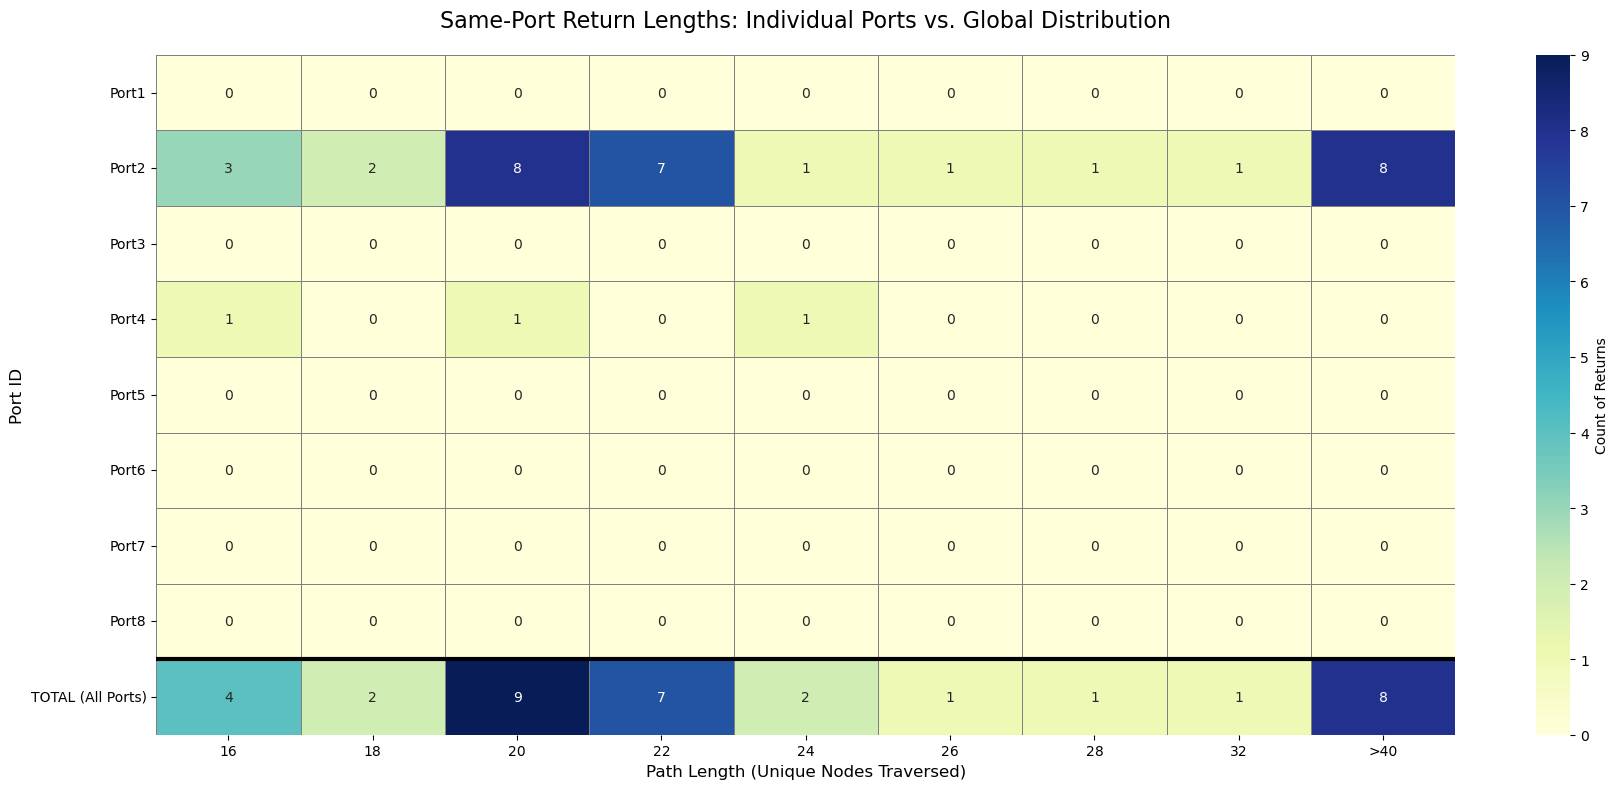

In [564]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def plot_same_port_returns_with_total(df_clean, port_map, exclude_length=2, max_length=40):
    # 1. Extraction and Sequence Calculation
    port_visits = df_clean[df_clean['is_port_node'] == True].copy()
    # port_visits = port_visits[port_visits['reward_during_node'] == True].copy()
    port_visits = port_visits[port_visits['reward_size_during_node'] > 0].copy()
    port_visits['seq_length_nodes'] = port_visits['node_visit_idx'].diff()
    port_visits['current_port_label'] = port_visits['node_name'].map(port_map)
    port_visits['prev_port_label'] = port_visits['current_port_label'].shift(1)
    
    # Filter for same-port returns and exclude noise
    same_port_mask = (port_visits['current_port_label'] == port_visits['prev_port_label'])
    returns_df = port_visits[same_port_mask].copy()
    returns_df = returns_df[returns_df['seq_length_nodes'] > exclude_length]
    
    # Clip lengths for readability
    returns_df['length_clipped'] = returns_df['seq_length_nodes'].clip(upper=max_length)
    
    # 2. Build the Heatmap Data
    # Create the contingency table for individual ports
    heatmap_data = pd.crosstab(returns_df['current_port_label'], returns_df['length_clipped'])
    
    # Ensure all ports 1-8 are present and sorted
    all_ports = [f'Port{i}' for i in range(1, 9)]
    heatmap_data = heatmap_data.reindex(all_ports).fillna(0)
    
    # 3. Add the "TOTAL" Row
    total_row = heatmap_data.sum(axis=0).to_frame().T
    total_row.index = ['TOTAL (All Ports)']
    heatmap_data = pd.concat([heatmap_data, total_row])

    # 4. Visualization
    plt.figure(figsize=(18, 8))
    
    # Use a diverging or sequential map; 'YlGnBu' is great for counts
    sns.heatmap(heatmap_data, annot=True, fmt=".0f", cmap="YlGnBu", 
                cbar_kws={'label': 'Count of Returns'},
                linewidths=.5, linecolor='gray')

    # Formatting X-axis labels
    cols = heatmap_data.columns.astype(int)
    xtick_labels = [str(c) if c < max_length else f">{max_length}" for c in cols]
    
    plt.xticks(np.arange(len(xtick_labels)) + 0.5, xtick_labels)
    plt.title(f"Same-Port Return Lengths: Individual Ports vs. Global Distribution", fontsize=16, pad=20)
    plt.xlabel("Path Length (Unique Nodes Traversed)", fontsize=12)
    plt.ylabel("Port ID", fontsize=12)
    
    # Draw a visual separator for the Total row
    plt.axhline(y=8, color='black', linewidth=3)
    
    plt.tight_layout()
    plt.show()

# Usage:
plot_same_port_returns_with_total(node_summary_df, port_map)

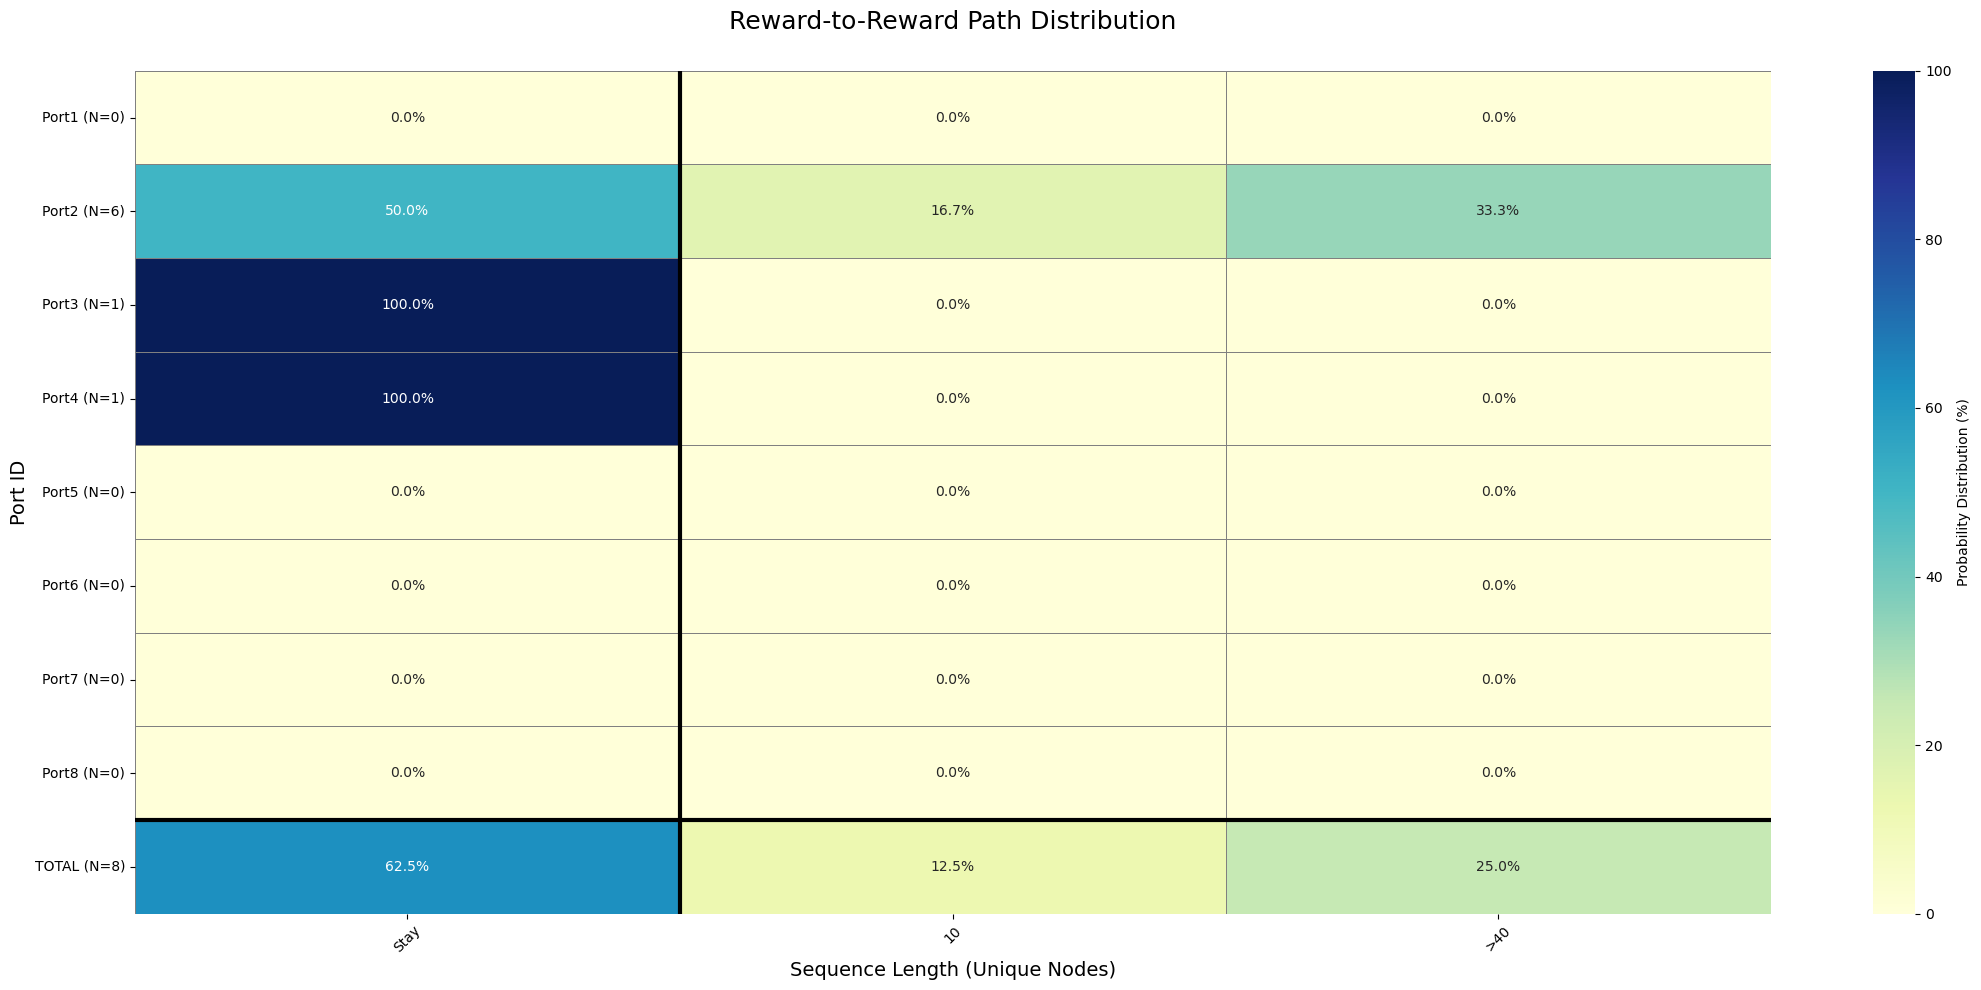

In [565]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def plot_same_port_returns_with_N(df_clean, port_map, exclude_length=2, max_length=40):
    # 1. Extraction and Sequence Calculation
    port_visits = df_clean[df_clean['reward_during_node'] > 0].copy()
    
    port_visits['seq_length_nodes'] = port_visits['node_visit_idx'].diff()
    port_visits['current_port_label'] = port_visits['node_name'].map(port_map)
    port_visits['prev_port_label'] = port_visits['current_port_label'].shift(1)
    port_visits['frame_diff'] = port_visits['start_frame'].diff()
    
    same_port_mask = (port_visits['current_port_label'] == port_visits['prev_port_label']) & \
                     (port_visits['frame_diff'] > 0)
    
    returns_df = port_visits[same_port_mask].copy()
    
    # 2. Categorize: "Stays" vs "Returns"
    def categorize_length(l):
        if l <= 3: return -1 
        if l <= exclude_length: return 0 
        return min(l, max_length)

    returns_df['length_cat'] = returns_df['seq_length_nodes'].apply(categorize_length)
    returns_df = returns_df[returns_df['length_cat'] != 0]
    
    # 3. Build Heatmap Data (Counts)
    heatmap_counts = pd.crosstab(returns_df['current_port_label'], returns_df['length_cat'])
    all_ports = [f'Port{i}' for i in range(1, 9)]
    heatmap_counts = heatmap_counts.reindex(all_ports).fillna(0)
    
    # Calculate totals for Y-axis labels before adding the TOTAL row
    row_totals = heatmap_counts.sum(axis=1).astype(int)
    y_labels = [f"{port} (N={row_totals[port]})" for port in all_ports]
    
    # Add TOTAL Row
    total_count_val = int(heatmap_counts.values.sum())
    total_row = heatmap_counts.sum(axis=0).to_frame().T
    total_row.index = [f'TOTAL (N={total_count_val})']
    heatmap_data_counts = pd.concat([heatmap_counts, total_row])
    
    # Update y_labels to include the Total row label
    y_labels.append(f'TOTAL (N={total_count_val})')

    # 4. Convert to Percentage
    heatmap_data_pct = (heatmap_data_counts.div(heatmap_data_counts.sum(axis=1), axis=0) * 100).fillna(0)

    # 5. Create Annotation Labels (with % sign)
    annot_labels = heatmap_data_pct.map(lambda x: f"{x:.1f}%")

    # 6. Visualization
    plt.figure(figsize=(22, 10))
    
    ax = sns.heatmap(heatmap_data_pct, 
                     annot=annot_labels, 
                     fmt="", 
                     cmap="YlGnBu", 
                     vmin=0, vmax=100,
                     cbar_kws={'label': 'Probability Distribution (%)'},
                     linewidths=.5, 
                     linecolor='gray')

    # Formatting X-axis labels
    cols = heatmap_data_pct.columns.tolist()
    xtick_labels = ["Stay" if c == -1 else (f">{int(max_length)}" if c >= max_length else str(int(c))) for c in cols]
    
    plt.xticks(np.arange(len(xtick_labels)) + 0.5, xtick_labels, rotation=45)
    plt.yticks(np.arange(len(y_labels)) + 0.5, y_labels, rotation=0) # Add N to Y-axis
    
    plt.title("Reward-to-Reward Path Distribution", fontsize=18, pad=30)
    plt.xlabel("Sequence Length (Unique Nodes)", fontsize=14)
    plt.ylabel("Port ID", fontsize=14)
    
    # Visual cues
    plt.axvline(x=1, color='black', linewidth=3)
    plt.axhline(y=8, color='black', linewidth=3)
    
    plt.tight_layout()
    plt.show()

plot_same_port_returns_with_N(node_summary_df, port_map, exclude_length=-1)

In [566]:
node_summary_df['reward_during_node']

0        False
1        False
2        False
3        False
4        False
         ...  
10453    False
10454    False
10455    False
10456    False
10457     True
Name: reward_during_node, Length: 10458, dtype: bool

In [567]:
port_visits = node_summary_df[node_summary_df['is_port_node'] == True].copy()
port_visits

,node_name,node_name_numeric,start_frame,end_frame,duration_frames,reward_during_node,reward_size_during_node,lick_during_node,lick_count_during_node,is_port_node,trial_idx,node_visit_idx
36,L525,45,881,890,10,False,0.00,False,0,True,0.0,36
69,R526,89,2229,2472,244,True,0.00,False,0,True,1.0,69
190,L510,31,3610,3661,52,True,0.00,False,0,True,5.0,190
211,R526,89,3997,4083,87,True,0.00,False,0,True,6.0,211
309,R522,87,5680,5680,1,False,0.00,False,0,True,10.0,309
...,...,...,...,...,...,...,...,...,...,...,...,...
10127,R526,89,181437,181441,5,False,0.00,False,0,True,799.0,10127
10137,R522,87,181622,181623,2,False,0.00,False,0,True,799.0,10137
10151,R526,89,181697,181735,39,True,0.00,False,0,True,800.0,10151
10361,R526,89,183443,184064,622,True,0.03,False,0,True,804.0,10361


In [568]:
node_summary_df

,node_name,node_name_numeric,start_frame,end_frame,duration_frames,reward_during_node,reward_size_during_node,lick_during_node,lick_count_during_node,is_port_node,trial_idx,node_visit_idx
0,R0,54,373,374,2,False,0.0,False,0,False,0.0,0
1,L0,0,375,387,13,False,0.0,False,0,False,0.0,1
2,L11,2,451,452,2,False,0.0,False,0,False,0.0,2
3,L22,5,455,455,1,False,0.0,False,0,False,0.0,3
4,L34,11,456,456,1,False,0.0,False,0,False,0.0,4
...,...,...,...,...,...,...,...,...,...,...,...,...
10453,L410,17,185378,185378,1,False,0.0,False,0,False,813.0,10453
10454,L520,40,185378,185391,14,False,0.0,False,0,False,813.0,10454
10455,L410,17,185392,185395,4,False,0.0,False,0,False,813.0,10455
10456,L520,40,185396,185396,1,False,0.0,False,0,False,813.0,10456


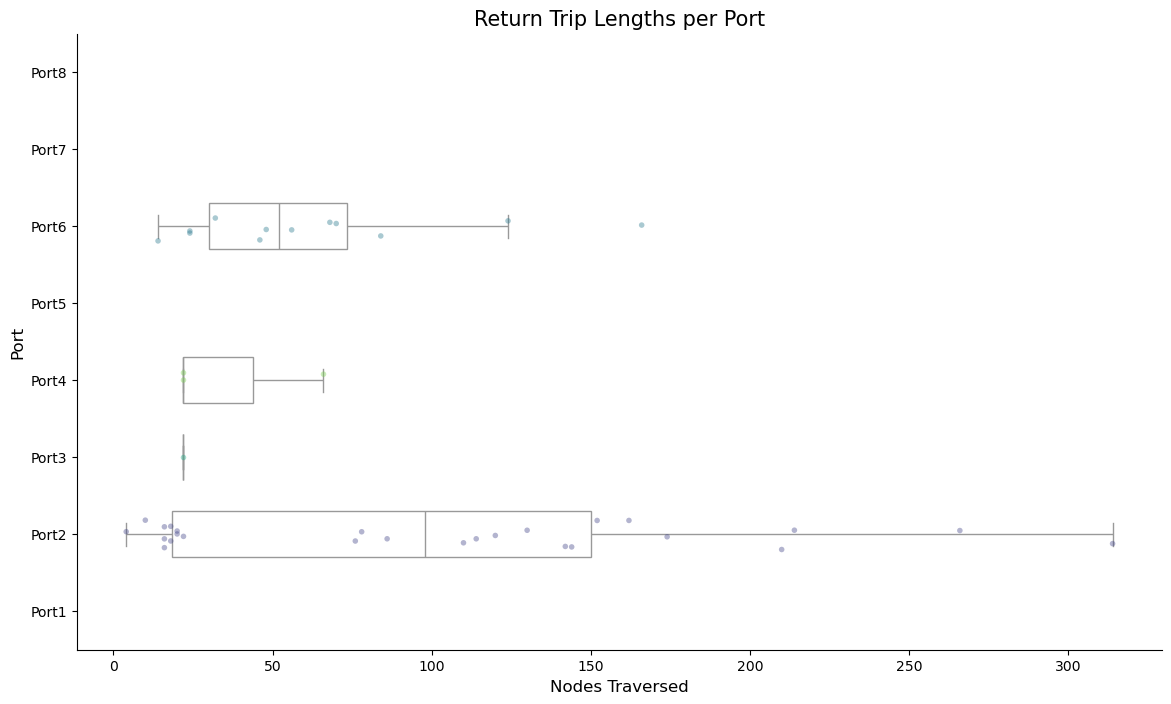

In [569]:
def plot_same_port_returns_boxplot(df, port_map, exclude_length=2):
    # 1. Extraction (Same logic as yours)
    port_visits = df[df['is_port_node'] == True].copy()
    port_visits['seq_length_nodes'] = port_visits['node_visit_idx'].diff()
    port_visits['current_port_label'] = port_visits['node_name'].map(port_map)
    port_visits['prev_port_label'] = port_visits['current_port_label'].shift(1)
    
    same_port_mask = (port_visits['current_port_label'] == port_visits['prev_port_label'])
    returns_df = port_visits[same_port_mask].copy()
    returns_df = returns_df[returns_df['seq_length_nodes'] > exclude_length]    
    plt.figure(figsize=(14, 8))
    order = [f'Port{i}' for i in range(8, 0, -1)] # Reverse order for Y-axis
    
    # Boxplot shows quartiles without smoothing the data
    sns.boxplot(data=returns_df, y='current_port_label', x='seq_length_nodes', 
                order=order, color="white", width=0.6, fliersize=0)
    
    # Stripplot shows every single discrete event
    sns.stripplot(data=returns_df, y='current_port_label', x='seq_length_nodes', 
                  order=order, size=4, hue='current_port_label', palette="viridis", 
                  alpha=0.4, jitter=0.2, legend=False)

    plt.title("Return Trip Lengths per Port", fontsize=15)
    plt.ylabel("Port", fontsize=12)
    plt.xlabel("Nodes Traversed", fontsize=12)
    sns.despine()
    plt.show()

plot_same_port_returns_boxplot(node_summary_df, port_map)

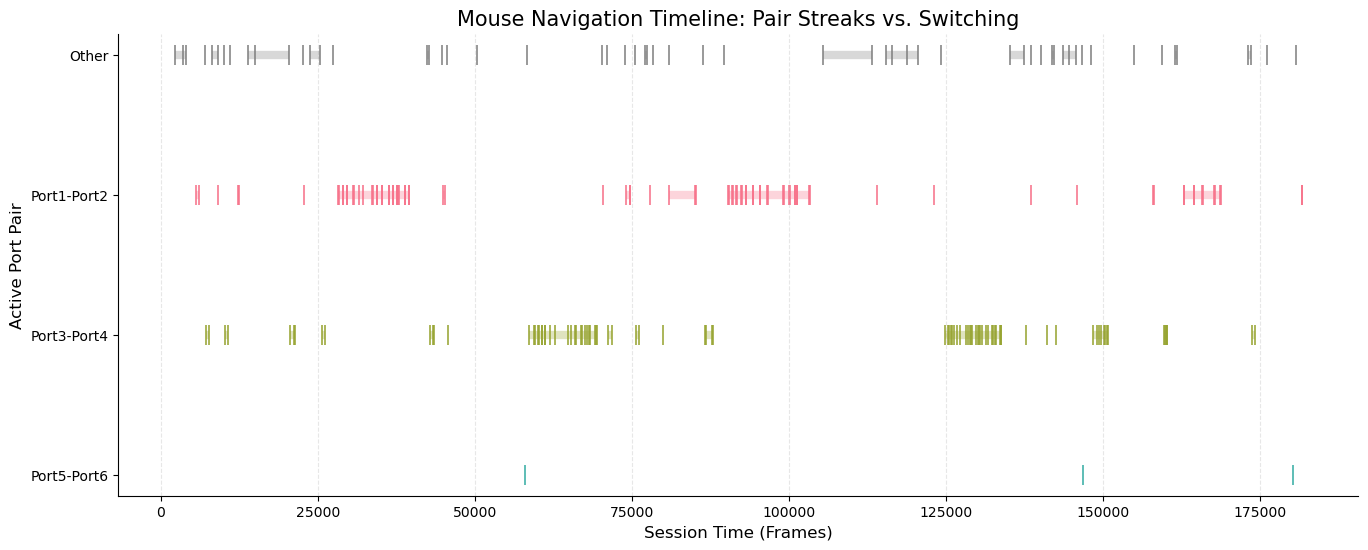

             count      mean   max
active_pair                       
Other         39.0  1.461538   4.0
Port1-Port2   18.0  4.888889  28.0
Port3-Port4   18.0  5.055556  27.0
Port5-Port6    3.0  1.000000   1.0


In [570]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def plot_pair_alternation_timeline(df, pairs_to_check, port_map):
    # 1. Filter for all port visits and label them
    port_visits = df[df['is_port_node'] == True].copy()
    port_visits['current_port'] = port_visits['node_name'].map(port_map)
    port_visits['prev_port'] = port_visits['current_port'].shift(1)
    
    # Define labels for our 4 pairs
    pair_labels = {tuple(sorted([p1, p2])): f"{p1}-{p2}" for p1, p2 in [
        ('Port1', 'Port2'), ('Port3', 'Port4'), ('Port5', 'Port6'), ('Port7', 'Port8')
    ]}
    
    def get_pair_name(row):
        if pd.isna(row['prev_port']) or pd.isna(row['current_port']): return "Start"
        if row['prev_port'] == row['current_port']: return "Self" # Ignored later
        sorted_pair = tuple(sorted([row['prev_port'], row['current_port']]))
        return pair_labels.get(sorted_pair, "Other")

    port_visits['active_pair'] = port_visits.apply(get_pair_name, axis=1)
    
    # 2. Filter: Keep transitions between different ports and exclude noise (length > 2)
    mask = (port_visits['active_pair'] != "Self") & (port_visits['node_visit_idx'].diff() > 2)
    valid_tx = port_visits[mask].copy()
    
    # 3. Calculate "Streaks" (how many sequences in a row for the same pair)
    valid_tx['pair_changed'] = valid_tx['active_pair'] != valid_tx['active_pair'].shift(1)
    valid_tx['streak_id'] = valid_tx['pair_changed'].cumsum()
    
    # Plotting
    plt.figure(figsize=(16, 6))
    pair_order = ["Port1-Port2", "Port3-Port4", "Port5-Port6", "Port7-Port8", "Other"]
    colors = sns.color_palette("husl", 4) + ["#808080"]
    color_map = dict(zip(pair_order, colors))

    # Draw streaks as horizontal lines
    for _, group in valid_tx.groupby('streak_id'):
        if len(group) > 1:
            p_name = group['active_pair'].iloc[0]
            if p_name in color_map:
                plt.hlines(y=p_name, xmin=group['start_frame'].min(), 
                           xmax=group['start_frame'].max(), 
                           color=color_map[p_name], linewidth=6, alpha=0.3)

    # Individual transitions as markers
    sns.scatterplot(data=valid_tx, x='start_frame', y='active_pair', hue='active_pair',
                    palette=color_map, hue_order=pair_order, marker='|', s=200, legend=False)

    plt.title("Mouse Navigation Timeline: Pair Streaks vs. Switching", fontsize=15)
    plt.xlabel("Session Time (Frames)", fontsize=12)
    plt.ylabel("Active Port Pair", fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.3)
    sns.despine()
    plt.show()

    # 4. Streak Statistics Summary
    streak_summary = valid_tx.groupby('streak_id').agg({
        'active_pair': 'first',
        'node_visit_idx': 'count'
    }).rename(columns={'node_visit_idx': 'streak_length'})
    
    return streak_summary.groupby('active_pair')['streak_length'].describe()[['count', 'mean', 'max']]

# Run:
streak_stats = plot_pair_alternation_timeline(node_summary_df, pairs_to_check, port_map)
print(streak_stats)

In [571]:
import pandas as pd
import numpy as np

def calculate_path_directness(df, pairs, port_map, G):
    # 1. Get all port-to-port transitions (same logic as before)
    port_visits = df[df['is_port_node'] == True].copy()
    port_visits['seq_length_nodes'] = port_visits['node_visit_idx'].diff()
    port_visits['current_port_label'] = port_visits['node_name'].map(port_map)
    port_visits['prev_port_label'] = port_visits['current_port_label'].shift(1)
    port_visits['prev_node_name'] = port_visits['node_name'].shift(1)
    
    results = []
    
    for node_a, node_b in pairs:
        p_a, p_b = port_map[node_a], port_map[node_b]
        
        # Calculate the theoretical shortest path for this specific pair
        # If your maze is perfectly symmetrical, this will be 8 for all.
        try:
            shortest_dist = nx.shortest_path_length(G, source=node_a, target=node_b)
            print(f"Shortest path between {node_a} and {node_b}: {shortest_dist} nodes")
        except nx.NetworkXNoPath:
            shortest_dist = 8 # Fallback to your stated distance
            
        # Filter for transitions between these two specific ports
        mask = (
            ((port_visits['prev_node_name'] == node_a) & (port_visits['node_name'] == node_b)) |
            ((port_visits['prev_node_name'] == node_b) & (port_visits['node_name'] == node_a))
        )
        
        subset = port_visits[mask].dropna(subset=['seq_length_nodes'])
        
        if not subset.empty:
            # Define 'Direct' as exactly the shortest distance (or your specific threshold of 8)
            # You can change '== shortest_dist' to '<= 8' if you prefer a hard cutoff
            n_direct = (subset['seq_length_nodes'] <= 8).sum()
            n_total = len(subset)
            
            perc_direct = (n_direct / n_total) * 100
            perc_non_direct = 100 - perc_direct
            
            results.append({
                'Pair': f"{p_a} <-> {p_b}",
                'Total Transitions': n_total,
                'Direct (≤8 nodes) %': round(perc_direct, 2),
                'Non-Direct (>8 nodes) %': round(perc_non_direct, 2),
                'Mean Nodes': round(subset['seq_length_nodes'].mean(), 2)
            })
            
    return pd.DataFrame(results)

# Usage:
directness_df = calculate_path_directness(node_summary_df, pairs_to_check, port_map, G)
print(directness_df)

Shortest path between R522 and R526: 8 nodes
Shortest path between L56 and L510: 8 nodes
Shortest path between L521 and L525: 8 nodes
Shortest path between R55 and R59: 8 nodes
              Pair  Total Transitions  Direct (≤8 nodes) %  \
0  Port1 <-> Port2                 88                35.23   
1  Port3 <-> Port4                 91                76.92   
2  Port5 <-> Port6                  3                 0.00   

   Non-Direct (>8 nodes) %  Mean Nodes  
0                    64.77       17.25  
1                    23.08        9.85  
2                   100.00       42.67  


In [572]:
def calculate_path_directness_fixed(df_clean, pairs, port_map):
    # Filter for all visits to port nodes
    port_visits = df_clean[df_clean['is_port_node'] == True].copy()
    
    # Calculate unique node distance
    port_visits['seq_length_unique_nodes'] = port_visits['node_visit_idx'].diff()
    port_visits['current_port_label'] = port_visits['node_name'].map(port_map)
    port_visits['prev_port_label'] = port_visits['current_port_label'].shift(1)
    port_visits['prev_node_name'] = port_visits['node_name'].shift(1)
    
    results = []
    for node_a, node_b in pairs:
        # SAFETY CHECK: If node_a is already 'Port1', don't look it up in the map
        p_a = port_map[node_a] if node_a in port_map else node_a
        p_b = port_map[node_b] if node_b in port_map else node_b
        
        shortest_dist = nx.shortest_path_length(G, source=node_a, target=node_b)

        # We filter based on the raw node names (Graph IDs) to be safe
        mask = (
            ((port_visits['prev_node_name'] == node_a) & (port_visits['node_name'] == node_b)) |
            ((port_visits['prev_node_name'] == node_b) & (port_visits['node_name'] == node_a))
        )
        
        subset = port_visits[mask].dropna(subset=['seq_length_unique_nodes'])
        
        if not subset.empty:
            # Here we use the threshold 8
            n_direct = (subset['seq_length_unique_nodes'] <= shortest_dist).sum()
            n_total = len(subset)
            
            results.append({
                'Pair': f"{p_a} <-> {p_b}",
                'Total Transitions': n_total,
                f'Direct (={shortest_dist} unique) %': round((n_direct / n_total) * 100, 2),
                f'Non-Direct (>{shortest_dist} unique) %': round((1 - n_direct / n_total) * 100, 2),
                'Mean Unique Nodes': round(subset['seq_length_unique_nodes'].mean(), 2),
                # We use the summed duration from the aggregated dataframe
                'Mean Duration (Frames)': round(subset['duration_frames'].mean(), 2) 
            })
            
    return pd.DataFrame(results)

# Run the function
directness_df = calculate_path_directness_fixed(node_summary_df, pairs_to_check, port_map)
print(directness_df)

              Pair  Total Transitions  Direct (=8 unique) %  \
0  Port1 <-> Port2                 88                 35.23   
1  Port3 <-> Port4                 91                 76.92   
2  Port5 <-> Port6                  3                  0.00   

   Non-Direct (>8 unique) %  Mean Unique Nodes  Mean Duration (Frames)  
0                     64.77              17.25                  184.49  
1                     23.08               9.85                  166.33  
2                    100.00              42.67                    3.00  


In [573]:
def get_unified_port_stats(df_clean, pairs, port_map, G):
    """
    df_clean: The aggregated dataframe (node_name != node_name.shift(1))
    """
    # 1. Filter for port visits
    port_visits = df_clean[df_clean['is_port_node'] == True].copy()
    
    # 2. Calculate unique node distance and time
    port_visits['seq_length_unique'] = port_visits['node_visit_idx'].diff()
    port_visits['seq_duration_frames'] = port_visits['start_frame'].diff()
    port_visits['current_port_label'] = port_visits['node_name'].map(port_map)
    port_visits['prev_port_label'] = port_visits['current_port_label'].shift(1)
    port_visits['prev_node_name'] = port_visits['node_name'].shift(1)
    
    results = []
    for node_a, node_b in pairs:
        p_a, p_b = port_map[node_a], port_map[node_b]
        
        shortest_dist = nx.shortest_path_length(G, source=node_a, target=node_b)
        # Identify transitions between these ports
        mask = (
            ((port_visits['prev_node_name'] == node_a) & (port_visits['node_name'] == node_b)) |
            ((port_visits['prev_node_name'] == node_b) & (port_visits['node_name'] == node_a))
        )
        
        subset = port_visits[mask].dropna(subset=['seq_length_unique'])
        
        if not subset.empty:
            lengths = subset['seq_length_unique']
            n_total = len(subset)
            # Standardizing 'Direct' as <= shortest_dist unique nodes
            n_direct = (lengths <= shortest_dist).sum() 
            
            results.append({
                'Pair': f"{p_a} <-> {p_b}",
                'Count': n_total,
                'Min Nodes': lengths.min(), # This should now be shortest_dist for direct paths
                'Max Nodes': lengths.max(),
                'Mean Nodes': round(lengths.mean(), 2),
                'Direct %': round((n_direct / n_total) * 100, 2),
                'Non-Direct %': round((1 - n_direct / n_total) * 100, 2)
            })
            
    return pd.DataFrame(results)

# PRE-REQUISITE: You must aggregate first!
final_stats = get_unified_port_stats(node_summary_df, pairs_to_check, port_map, G)
print(final_stats)

              Pair  Count  Min Nodes  Max Nodes  Mean Nodes  Direct %  \
0  Port1 <-> Port2     88        8.0      174.0       17.25     35.23   
1  Port3 <-> Port4     91        8.0       70.0        9.85     76.92   
2  Port5 <-> Port6      3       20.0       60.0       42.67      0.00   

   Non-Direct %  
0         64.77  
1         23.08  
2        100.00  


Port1 <-> Port2: Overflow count (> 25): 6
Port3 <-> Port4: Overflow count (> 25): 2
Port5 <-> Port6: Overflow count (> 25): 2
Port7 <-> Port8: Overflow count (> 25): 0


/tmp/ipykernel_28444/1669883251.py:34: RuntimeWarning: invalid value encountered in scalar divide
  'Direct': (n_direct / n_total) * 100,
/tmp/ipykernel_28444/1669883251.py:35: RuntimeWarning: invalid value encountered in scalar divide
  'Indirect': (1 - n_direct / n_total) * 100


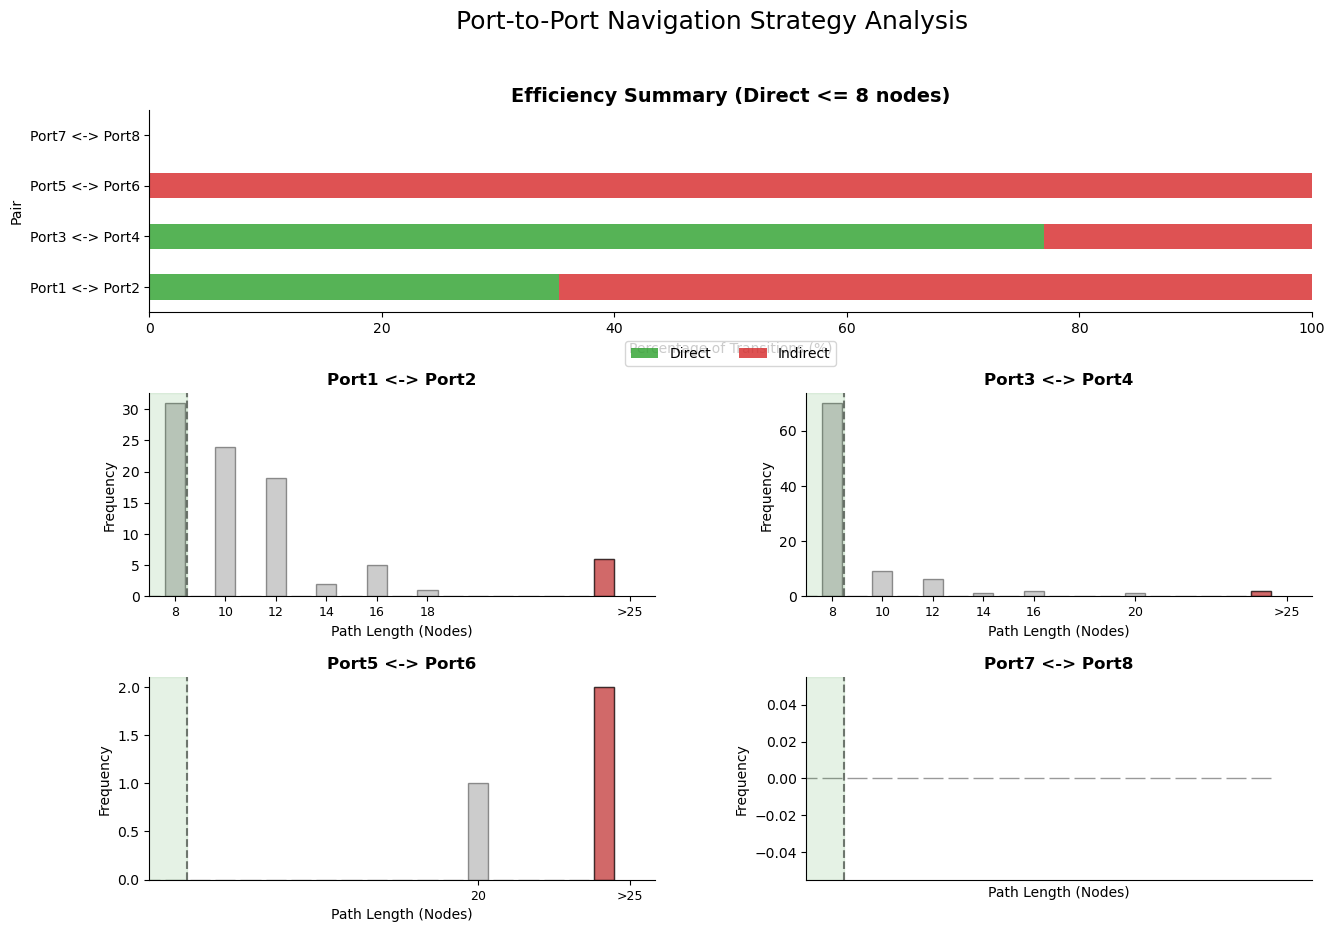

In [574]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_behavioral_summary(df_clean, pairs, port_map, direct_threshold=8, x_max=25):
    # 1. Prepare Data
    port_visits = df_clean[df_clean['is_port_node'] == True].copy()
    port_visits['seq_length'] = port_visits['node_visit_idx'].diff()
    port_visits['current_port_label'] = port_visits['node_name'].map(port_map)
    port_visits['prev_port_label'] = port_visits['current_port_label'].shift(1)
    
    # Store data for plotting
    plot_data = []
    summary_list = []
    
    for node_a, node_b in pairs:
        p_a, p_b = port_map[node_a], port_map[node_b]
        pair_label = f"{p_a} <-> {p_b}"
        
        mask = (
            ((port_visits['prev_port_label'] == p_a) & (port_visits['current_port_label'] == p_b)) |
            ((port_visits['prev_port_label'] == p_b) & (port_visits['current_port_label'] == p_a))
        )
        
        subset = port_visits[mask].dropna(subset=['seq_length']).copy()
        subset['pair_label'] = pair_label
        plot_data.append(subset)
        
        # Calculate summary stats
        n_total = len(subset)
        n_direct = (subset['seq_length'] <= direct_threshold).sum()
        summary_list.append({
            'Pair': pair_label,
            'Direct': (n_direct / n_total) * 100,
            'Indirect': (1 - n_direct / n_total) * 100
        })

    full_plot_df = pd.concat(plot_data)
    summary_df = pd.DataFrame(summary_list)

    # 2. Setup Figure Layout (GridSpec)
    fig = plt.figure(figsize=(15, 10))
    gs = fig.add_gridspec(3, 2, hspace=0.4, wspace=0.3)
    
    # --- TOP: Stacked Bar Chart ---
    ax_bar = fig.add_subplot(gs[0, :])
    summary_df.set_index('Pair').plot(kind='barh', stacked=True, 
                                      color=['#2ca02c', '#d62728'], alpha=0.8, ax=ax_bar)
    ax_bar.set_title(f"Efficiency Summary (Direct <= {direct_threshold} nodes)", fontsize=14, fontweight='bold')
    ax_bar.set_xlabel("Percentage of Transitions (%)")
    ax_bar.set_xlim(0, 100)
    ax_bar.legend(loc='lower center', bbox_to_anchor=(0.5, -0.3), ncol=2)

    # --- BOTTOM: Histograms for each Pair ---
    # We iterate through the 4 pairs and create a histogram for each
    pair_labels = summary_df['Pair'].tolist()
    axes_hist = [fig.add_subplot(gs[1, 0]), fig.add_subplot(gs[1, 1]), 
                 fig.add_subplot(gs[2, 0]), fig.add_subplot(gs[2, 1])]
        
    for i, pair_name in enumerate(pair_labels):
            ax = axes_hist[i]
            data_subset = full_plot_df[full_plot_df['pair_label'] == pair_name]
            data = data_subset['seq_length'].values
            
            # Create bins up to x_max
            bins = np.arange(0, x_max + 2) 
            counts, _ = np.histogram(data, bins=bins)
            
            # Handle Overflow (> x_max)
            overflow_count = np.sum(data > x_max)
            print(f"{pair_name}: Overflow count (> {x_max}): {overflow_count}")
            counts[-1] = overflow_count
            
            # Plot bars manually for fixed width (0.8)
            bin_centers = bins[:-1]
            ax.bar(bin_centers, counts, width=0.8, color='gray', alpha=0.4, edgecolor='black')
            
            # Highlight Overflow bin in red if it exists
            if overflow_count > 0:
                ax.bar(bin_centers[-1], overflow_count, width=0.8, color='#d62728', alpha=0.6, edgecolor='black')

            # Highlight Direct Zone
            ax.axvspan(-0.5, direct_threshold + 0.5, color='green', alpha=0.1)
            ax.axvline(direct_threshold + 0.5, color='black', linestyle='--', alpha=0.5)
            
            # DYNAMIC TICKS: Only where data actually exists
            unique_vals = sorted([v for v in np.unique(data) if v <= x_max])
            tick_labels = [str(int(v)) for v in unique_vals]
            if overflow_count > 0:
                unique_vals.append(x_max + 1)
                tick_labels.append(f">{x_max}")
            
            ax.set_xticks(unique_vals)
            ax.set_xticklabels(tick_labels, fontsize=9)
            
            ax.set_title(pair_name, fontsize=12, fontweight='semibold')
            ax.set_xlabel("Path Length (Nodes)")
            ax.set_ylabel("Frequency")
            ax.set_xlim(7, x_max + 2)

    plt.suptitle("Port-to-Port Navigation Strategy Analysis", fontsize=18, y=0.98)
    sns.despine()
    plt.show()

# Usage:
plot_behavioral_summary(node_summary_df, pairs_to_check, port_map)

In [575]:
import pandas as pd
import networkx as nx

def get_directional_port_stats(df_clean, pairs, port_map, G):
    """
    Analyzes port-to-port transitions separately for each direction.
    """
    # 1. Filter for port visits from the aggregated dataframe
    port_visits = df_clean[df_clean['is_port_node'] == True].copy()
    
    # 2. Calculate transition metrics
    port_visits['seq_length_unique'] = port_visits['node_visit_idx'].diff()
    port_visits['prev_node_name'] = port_visits['node_name'].shift(1)
    
    results = []
    
    # We expand the pair list to include both directions
    for node_start, node_end in pairs:
        # Check both: A -> B AND B -> A
        for src, dest in [(node_start, node_end), (node_end, node_start)]:
            p_src, p_dest = port_map[src], port_map[dest]
            
            # Theoretical shortest path (undirected G handles both same)
            try:
                shortest_dist = nx.shortest_path_length(G, source=src, target=dest)
            except nx.NetworkXNoPath:
                shortest_dist = 8 # Fallback
            
            # Identify transitions specifically for THIS direction
            mask = (port_visits['prev_node_name'] == src) & (port_visits['node_name'] == dest)
            
            subset = port_visits[mask].dropna(subset=['seq_length_unique'])
            
            if not subset.empty:
                lengths = subset['seq_length_unique']
                n_total = len(subset)
                n_direct = (lengths <= shortest_dist).sum() 
                
                results.append({
                    'Transition': f"{p_src} -> {p_dest}",
                    'Count': n_total,
                    'Shortest Possible': shortest_dist,
                    'Min Observed': int(lengths.min()),
                    'Max Observed': int(lengths.max()),
                    'Mean Nodes': round(lengths.mean(), 2),
                    'Direct %': round((n_direct / n_total) * 100, 2),
                    'Indirect %': round((1 - n_direct / n_total) * 100, 2)
                })
            
    return pd.DataFrame(results)

# Execution
directional_stats = get_directional_port_stats(node_summary_df, pairs_to_check, port_map, G)
print(directional_stats)

       Transition  Count  Shortest Possible  Min Observed  Max Observed  \
0  Port1 -> Port2     47                  8             8           102   
1  Port2 -> Port1     41                  8             8           174   
2  Port3 -> Port4     45                  8             8            20   
3  Port4 -> Port3     46                  8             8            70   
4  Port5 -> Port6      1                  8            20            20   
5  Port6 -> Port5      2                  8            48            60   

   Mean Nodes  Direct %  Indirect %  
0       12.55     40.43       59.57  
1       22.63     29.27       70.73  
2        8.98     77.78       22.22  
3       10.70     76.09       23.91  
4       20.00      0.00      100.00  
5       54.00      0.00      100.00  


In [576]:
# def print_sample_path_with_frames(df_clean, port_map, target_length=7):
#     # 1. Identify port visits and calculate distance
#     port_visits = df_clean[df_clean['is_port_node'] == True].copy()
#     port_visits['current_port_label'] = port_visits['node_name'].map(port_map)
#     port_visits['prev_port_label'] = port_visits['current_port_label'].shift(1)
#     port_visits['seq_length'] = port_visits['node_visit_idx'].diff()
    
#     # 2. Find the match
#     matches = port_visits[port_visits['seq_length'] == target_length].dropna(subset=['prev_port_label'])
    
#     if matches.empty:
#         print(f"No path found with index difference {target_length}")
#         return None

#     match = matches.iloc[0]

#     # 3. Extract the full sequence slice
#     end_idx = int(match['node_visit_idx'])
#     start_idx = int(end_idx - target_length)
#     sample_sequence = df_clean.iloc[start_idx : end_idx + 1]
    
#     # 4. Get the Absolute Frame Range
#     # Start frame of the first node in the trip
#     abs_start_frame = sample_sequence.iloc[0]['start_frame']
#     # End frame of the last node (the port) in the trip
#     abs_end_frame = sample_sequence.iloc[-1]['end_frame']
    
#     duration_sec = (abs_end_frame - abs_start_frame) / 30  # Assuming 30 FPS
    
#     print(f"--- Example Direct Path (Index Diff: {target_length}) ---")
#     print(f"From: {match['prev_port_label']} (Node: {sample_sequence.iloc[0]['node_name']})")
#     print(f"To:   {match['current_port_label']} (Node: {sample_sequence.iloc[-1]['node_name']})")
#     print("-" * 40)
#     print(f"Frame Range: {int(abs_start_frame)} to {int(abs_end_frame)}")
#     print(f"Approx Duration: {duration_sec:.2f} seconds")
#     print(f"Sequence: {' -> '.join(sample_sequence['node_name'].tolist())}")
    
#     return sample_sequence, (abs_start_frame, abs_end_frame)

# # Run it:
# sample_seq, frames = print_sample_path_with_frames(node_summary_df, port_map, target_length=8)

In [577]:
# node_summary_df_original[645:660]

In [578]:
# traversal_seq[1210:1240]

In [579]:
# import networkx as nx
# import matplotlib.pyplot as plt
# from collections import Counter

# def plot_multi_color_error_heatmap(G, node_positions, df_clean, pairs, port_map):
#     base_colors = {
#         'Port1-Port2': 'red', 
#         'Port3-Port4': 'blue', 
#         'Port5-Port6': 'green', 
#         'Port7-Port8': 'darkorange'
#     }

#     # --- [Step 1 & 2: Same as previous 'Strict' logic] ---
#     master_correct_nodes = set()
#     pair_direct_edges = {f"{port_map[a]}-{port_map[b]}": set() for a, b in pairs}
#     port_visits = df_clean[df_clean['is_port_node'] == True].copy()
#     indices = port_visits.index.tolist()

#     for i in range(1, len(indices)):
#         p1, p2 = port_visits.iloc[i-1]['node_name'], port_visits.iloc[i]['node_name']
#         for a, b in pairs:
#             if {p1, p2} == {a, b}:
#                 pair_key = f"{port_map[a]}-{port_map[b]}"
#                 path = df_clean.loc[indices[i-1]:indices[i], 'node_name'].tolist()
#                 if len(path) <= 8:
#                     master_correct_nodes.update(path)
#                     for j in range(len(path)-1):
#                         pair_direct_edges[pair_key].add(tuple(sorted((path[j], path[j+1]))))

#     pair_error_counts = {p: Counter() for p in pair_direct_edges.keys()}
#     for i in range(1, len(indices)):
#         p1, p2 = port_visits.iloc[i-1]['node_name'], port_visits.iloc[i]['node_name']
#         for a, b in pairs:
#             if {p1, p2} == {a, b}:
#                 pair_key = f"{port_map[a]}-{port_map[b]}"
#                 path = df_clean.loc[indices[i-1]:indices[i], 'node_name'].tolist()
#                 if len(path) > 8:
#                     errors = [n for n in path if n not in master_correct_nodes]
#                     pair_error_counts[pair_key].update(errors)

#     # --- [Step 3: New Multi-Layer Color Logic] ---
#     all_error_nodes = set().union(*(c.keys() for c in pair_error_counts.values()))
    
#     plt.figure(figsize=(16, 12))
#     ax = plt.gca()
#     nx.draw_networkx_edges(G, node_positions, ax=ax, alpha=0.1, edge_color='black', arrows=False)

#     # Draw Backbones
#     for pair_name, edges in pair_direct_edges.items():
#         nx.draw_networkx_edges(G, node_positions, edgelist=list(edges), 
#                                edge_color=base_colors[pair_name], width=4, alpha=0.6, arrows=False)

#     # Process each detour node individually for custom styling
#     for node in all_error_nodes:
#         # Get pairs that contributed to this node's error count, sorted by most visits
#         node_stats = {p: counts[node] for p, counts in pair_error_counts.items() if node in counts}
#         contributing_pairs = sorted(node_stats.keys(), key=lambda x: node_stats[x], reverse=True)
#         total_visits = sum(node_stats.values())
        
#         num_pairs = len(contributing_pairs)
        
#         # Default styling
#         fill_color = 'gray'
#         border_color = 'none'
#         text_color = 'white'
#         line_width = 0

#         if num_pairs == 1:
#             fill_color = base_colors[contributing_pairs[0]]
#             line_width = 0
#         elif num_pairs == 2:
#             fill_color = base_colors[contributing_pairs[0]]
#             border_color = base_colors[contributing_pairs[1]]
#             line_width = 3
#         elif num_pairs == 3:
#             fill_color = base_colors[contributing_pairs[0]]
#             border_color = base_colors[contributing_pairs[1]]
#             text_color = base_colors[contributing_pairs[2]]
#             line_width = 3
#         elif num_pairs >= 4:
#             fill_color = 'gray'
#             text_color = 'black'
#             line_width = 1
#             border_color = 'black'

#         # Draw the specific node
#         nx.draw_networkx_nodes(G, node_positions, nodelist=[node], 
#                                node_color=[fill_color], 
#                                edgecolors=border_color, 
#                                linewidths=line_width,
#                                node_size=650, alpha=0.8, ax=ax)
        
#         # Draw the specific label
#         nx.draw_networkx_labels(G, node_positions, labels={node: str(total_visits)}, 
#                                 font_size=10, font_color=text_color, font_weight='bold', ax=ax)

#     # Final Labels
#     port_labels = {k: v for k, v in port_map.items()}
#     nx.draw_networkx_labels(G, node_positions, labels=port_labels, font_size=12, font_weight='bold')

#     plt.title("Detour Map with Layered Pair Coloring (Fill/Border/Text)", fontsize=16)
#     plt.axis('off')
#     plt.show()

# plot_multi_color_error_heatmap(G, node_positions, node_summary_df, pairs_to_check, port_map)

In [580]:
# import networkx as nx
# import matplotlib.pyplot as plt
# from collections import Counter

# def plot_strict_error_heatmap(G, node_positions, df_clean, pairs, port_map):
#     base_colors = {
#         'Port1-Port2': 'red', 
#         'Port3-Port4': 'blue', 
#         'Port5-Port6': 'green', 
#         'Port7-Port8': 'darkorange'
#     }

#     # 1. DETERMINE THEORETICAL DIRECT PATHS FROM GRAPH
#     pair_direct_nodes = {}
#     pair_direct_edges = {}
    
#     for a, b in pairs:
#         pair_key = f"{port_map[a]}-{port_map[b]}"
#         try:
#             shortest_path = nx.shortest_path(G, a, b)
#             # Exclude ports themselves from the exclusion list to allow back-to-back checks
#             intermediate_nodes = set(shortest_path[1:-1]) if len(shortest_path) > 2 else set()
#             pair_direct_nodes[pair_key] = intermediate_nodes
            
#             edges = set()
#             for i in range(len(shortest_path) - 1):
#                 edges.add(tuple(sorted((shortest_path[i], shortest_path[i+1]))))
#             pair_direct_edges[pair_key] = edges
            
#         except nx.NetworkXNoPath:
#             pair_direct_nodes[pair_key] = set()
#             pair_direct_edges[pair_key] = set()
    
#     # 2. COUNT DETOUR NODES
#     pair_error_counts = {p: Counter() for p in pair_direct_edges.keys()}
#     port_visits = df_clean[df_clean['is_port_node'] == True].copy()
#     indices = port_visits.index.tolist()
    
#     for i in range(1, len(indices)):
#         p1, p2 = port_visits.iloc[i-1]['node_name'], port_visits.iloc[i]['node_name']
#         for a, b in pairs:
#             if {p1, p2} == {a, b}:
#                 pair_key = f"{port_map[a]}-{port_map[b]}"
#                 path = df_clean.loc[indices[i-1]:indices[i], 'node_name'].tolist()
#                 intermediate_nodes = path[1:-1] if len(path) > 2 else []
#                 detour_nodes = [n for n in intermediate_nodes if n not in pair_direct_nodes[pair_key]]
#                 pair_error_counts[pair_key].update(detour_nodes)

#     # 3. PLOTTING
#     plt.figure(figsize=(16, 12))
#     ax = plt.gca()

#     # Maze skeleton
#     nx.draw_networkx_edges(G, node_positions, ax=ax, alpha=0.2, edge_color='black', arrows=False)

#     # Draw Colored Direct Edges (The Backbone)
#     for pair_name, edges in pair_direct_edges.items():
#         if edges:
#             nx.draw_networkx_edges(G, node_positions, edgelist=list(edges), 
#                                    edge_color=base_colors[pair_name], width=4, alpha=0.8, arrows=False)

#     # 4. CONFLICT RESOLUTION & CUSTOM NODE DRAWING
#     all_error_nodes = set().union(*(c.keys() for c in pair_error_counts.values()))

#     for node in all_error_nodes:
#         # Get pairs that contributed, sorted by frequency (most frequent = dominant)
#         node_stats = {p: counts[node] for p, counts in pair_error_counts.items() if node in counts}
#         contributing_pairs = sorted(node_stats.keys(), key=lambda x: node_stats[x], reverse=True)
#         total_visits = sum(node_stats.values())
#         num_pairs = len(contributing_pairs)
        
#         # Default styling (4+ pairs)
#         fill_color = 'gray'
#         edge_color = 'black'
#         text_color = 'black'
#         lw = 1

#         if num_pairs == 1:
#             fill_color = base_colors[contributing_pairs[0]]
#             edge_color = 'none' # No border for single pair
#             text_color = 'white'
#             lw = 0
#         elif num_pairs == 2:
#             fill_color = base_colors[contributing_pairs[0]]
#             edge_color = base_colors[contributing_pairs[1]]
#             text_color = 'white'
#             lw = 4 # Thick border for secondary color
#         elif num_pairs == 3:
#             fill_color = base_colors[contributing_pairs[0]]
#             edge_color = base_colors[contributing_pairs[1]]
#             text_color = base_colors[contributing_pairs[2]]
#             lw = 4
        
#         # Draw the node with specific layer colors
#         nx.draw_networkx_nodes(G, node_positions, nodelist=[node], 
#                                node_color=[fill_color], 
#                                edgecolors=edge_color,
#                                linewidths=lw,
#                                node_size=600, alpha=0.95, ax=ax)
        
#         # Draw the frequency label inside
#         nx.draw_networkx_labels(G, node_positions, labels={node: str(total_visits)}, 
#                                 font_size=10, font_color=text_color, font_weight='bold', ax=ax)

#     # Ports
#     port_labels = {k: v for k, v in port_map.items()}
#     nx.draw_networkx_labels(G, node_positions, labels=port_labels, font_size=12, font_weight='bold')
 
#     plt.title("Detour Heatmap", fontsize=16)
#     plt.axis('off')
#     plt.show()

# # Execution
# plot_strict_error_heatmap(G, node_positions, node_summary_df, pairs_to_check, port_map)

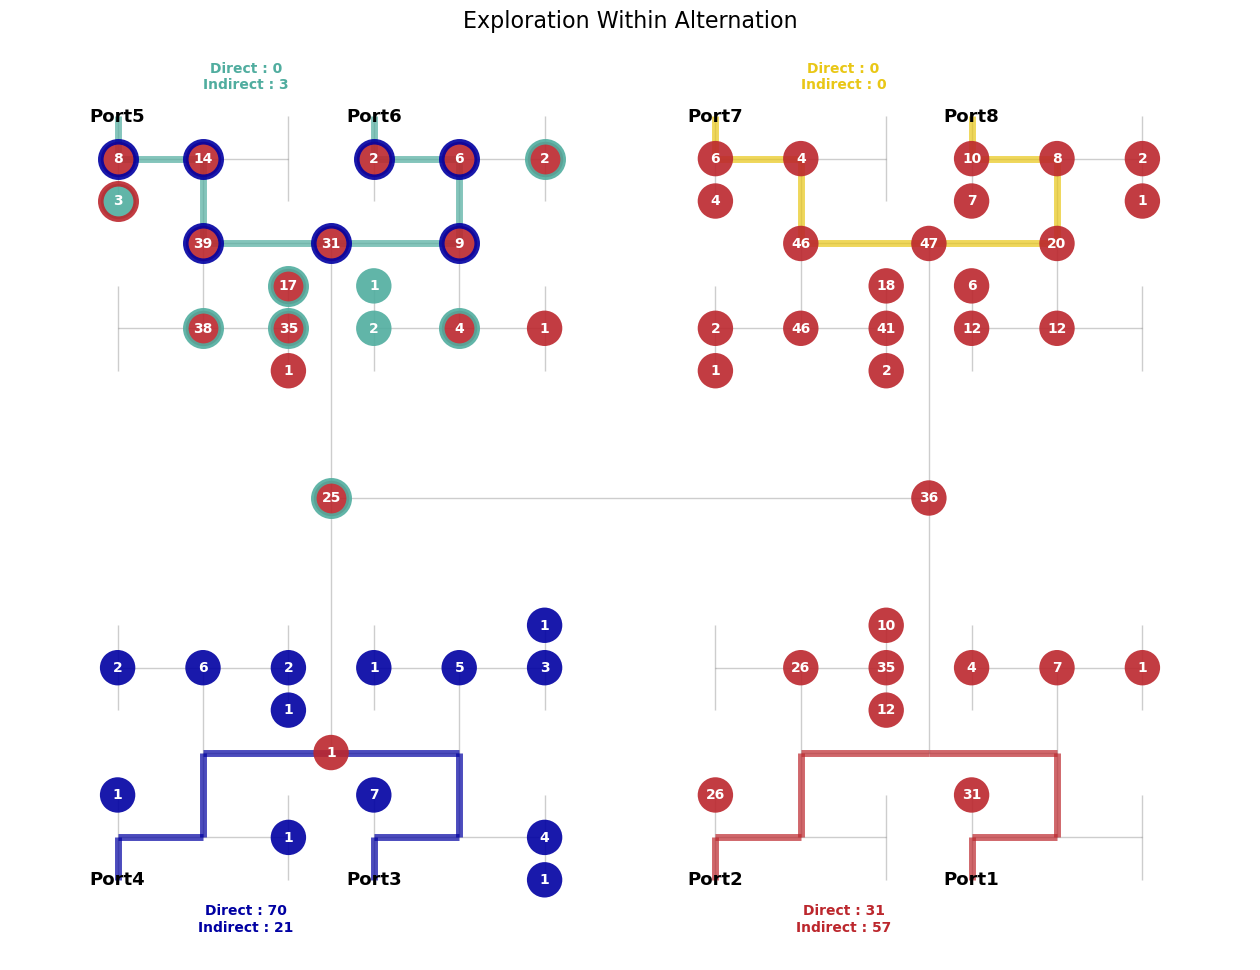

In [581]:
import networkx as nx
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np

def plot_strict_error_heatmap_with_stats(G, node_positions, df_clean, pairs, port_map):
    base_colors = {
        'Port1-Port2': '#bc272d', 
        'Port3-Port4': '#0000a2', 
        'Port5-Port6': '#50ad9f', 
        'Port7-Port8': '#e9c716'
    }

    # 1. DETERMINE THEORETICAL DIRECT PATHS & INIT STATS
    pair_direct_nodes = {}
    pair_direct_edges = {}
    pair_stats = {f"{port_map[a]}-{port_map[b]}": {'direct': 0, 'indirect': 0} for a, b in pairs}
    
    for a, b in pairs:
        pair_key = f"{port_map[a]}-{port_map[b]}"
        try:
            shortest_path = nx.shortest_path(G, a, b)
            shortest_len = len(shortest_path)
            intermediate_nodes = set(shortest_path[1:-1]) if len(shortest_path) > 2 else set()
            pair_direct_nodes[pair_key] = (intermediate_nodes, shortest_len)
            
            edges = set()
            for i in range(len(shortest_path) - 1):
                edges.add(tuple(sorted((shortest_path[i], shortest_path[i+1]))))
            pair_direct_edges[pair_key] = edges
            
        except nx.NetworkXNoPath:
            pair_direct_nodes[pair_key] = (set(), 0)
            pair_direct_edges[pair_key] = set()
    
    # 2. COUNT DETOUR NODES AND PATH EFFICIENCY
    pair_error_counts = {p: Counter() for p in pair_direct_edges.keys()}
    port_visits = df_clean[df_clean['is_port_node'] == True].copy()
    indices = port_visits.index.tolist()
    
    for i in range(1, len(indices)):
        p1, p2 = port_visits.iloc[i-1]['node_name'], port_visits.iloc[i]['node_name']
        for a, b in pairs:
            if {p1, p2} == {a, b}:
                pair_key = f"{port_map[a]}-{port_map[b]}"
                path = df_clean.loc[indices[i-1]:indices[i], 'node_name'].tolist()
                
                # Efficiency Check
                direct_intermediate, ideal_len = pair_direct_nodes[pair_key]
                if len(path) <= ideal_len:
                    pair_stats[pair_key]['direct'] += 1
                else:
                    pair_stats[pair_key]['indirect'] += 1
                
                # Detour Node Counting
                intermediate_nodes = path[1:-1] if len(path) > 2 else []
                detour_nodes = [n for n in intermediate_nodes if n not in direct_intermediate]
                pair_error_counts[pair_key].update(detour_nodes)

    # 3. PLOTTING
    plt.figure(figsize=(16, 12))
    ax = plt.gca()

    # Maze skeleton
    nx.draw_networkx_edges(G, node_positions, ax=ax, alpha=0.1, edge_color='black', arrows=False)

    # Draw Colored Direct Edges (The Backbone)
    for pair_name, edges in pair_direct_edges.items():
        if edges:
            nx.draw_networkx_edges(G, node_positions, edgelist=list(edges), 
                                   edge_color=base_colors[pair_name], width=5, alpha=0.7, arrows=False)

    # 4. ANNOTATE PAIR STATS (Midway between ports)
    for a, b in pairs:
        pair_key = f"{port_map[a]}-{port_map[b]}"
        pos_a = node_positions[a]
        pos_b = node_positions[b]
        # Calculate midpoint
        mid_x, mid_y = (pos_a[0] + pos_b[0]) / 2, (pos_a[1] + pos_b[1]) / 2
        # offset of 30 pixels on the y scale, for pairs (1,2) and (3,4) it is down, for the others up
        if (a,b) == ('R522','R526') or (a,b) == ('L56','L510'):
            mid_y -= 30
        else:
            mid_y += 30
        
        stats_text = f"Direct : {pair_stats[pair_key]['direct']}\nIndirect : {pair_stats[pair_key]['indirect']}"
        ax.text(mid_x, mid_y, stats_text, color=base_colors[pair_key], 
                fontweight='bold', fontsize=10, ha='center', va='center',
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.3'))

    # 5. CONFLICT RESOLUTION & CUSTOM NODE DRAWING
    all_error_nodes = set().union(*(c.keys() for c in pair_error_counts.values()))
    for node in all_error_nodes:
        node_stats = {p: counts[node] for p, counts in pair_error_counts.items() if node in counts}
        contributing_pairs = sorted(node_stats.keys(), key=lambda x: node_stats[x], reverse=True)
        total_visits = sum(node_stats.values())
        num_pairs = len(contributing_pairs)
        
        # Style logic
        fill_color = 'gray'
        edge_color = 'black'
        text_color = 'black'
        lw = 1

        if num_pairs == 1:
            fill_color = base_colors[contributing_pairs[0]]
            edge_color = 'none'; text_color = 'white'; lw = 0
        elif num_pairs >= 2:
            fill_color = base_colors[contributing_pairs[0]]
            edge_color = base_colors[contributing_pairs[1]]
            text_color = 'white'; lw = 4
        
        nx.draw_networkx_nodes(G, node_positions, nodelist=[node], node_color=[fill_color], 
                               edgecolors=edge_color, linewidths=lw, node_size=650, alpha=0.9, ax=ax)
        nx.draw_networkx_labels(G, node_positions, labels={node: str(total_visits)}, 
                                font_size=10, font_color=text_color, font_weight='bold', ax=ax)

    # Ports
    port_labels = {k: v for k, v in port_map.items()}
    nx.draw_networkx_labels(G, node_positions, labels=port_labels, font_size=13, font_weight='bold')
 
    plt.title("Exploration Within Alternation", fontsize=16)
    plt.axis('off')
    plt.show()

plot_strict_error_heatmap_with_stats(G, node_positions, node_summary_df, pairs_to_check, port_map)

In [582]:
# Generate all possible pairs of ports
from itertools import combinations
all_pairs = list(combinations(port_map.keys(), 2))

# Remove from all_pairs the pairs already in pairs_to_check
remaining_pairs = [pair for pair in all_pairs if pair not in pairs_to_check and (pair[1], pair[0]) not in pairs_to_check]

final_stats_all = get_unified_port_stats(node_summary_df, remaining_pairs, port_map, G)

final_stats_all

,Pair,Count,Min Nodes,Max Nodes,Mean Nodes,Direct %,Non-Direct %
0,Port1 <-> Port3,5,35.0,119.0,74.00,0.0,100.0
1,Port1 <-> Port4,4,23.0,159.0,79.00,0.0,100.0
2,Port1 <-> Port6,3,21.0,113.0,60.33,0.0,100.0
3,Port2 <-> Port3,9,23.0,113.0,52.56,0.0,100.0
4,Port2 <-> Port4,12,21.0,297.0,86.83,0.0,100.0
5,Port2 <-> Port5,4,47.0,111.0,71.50,0.0,100.0
6,Port2 <-> Port6,8,21.0,89.0,58.12,0.0,100.0
7,Port3 <-> Port5,1,34.0,34.0,34.00,0.0,100.0
8,Port3 <-> Port6,6,40.0,208.0,86.67,0.0,100.0
9,Port4 <-> Port6,5,18.0,134.0,87.20,0.0,100.0


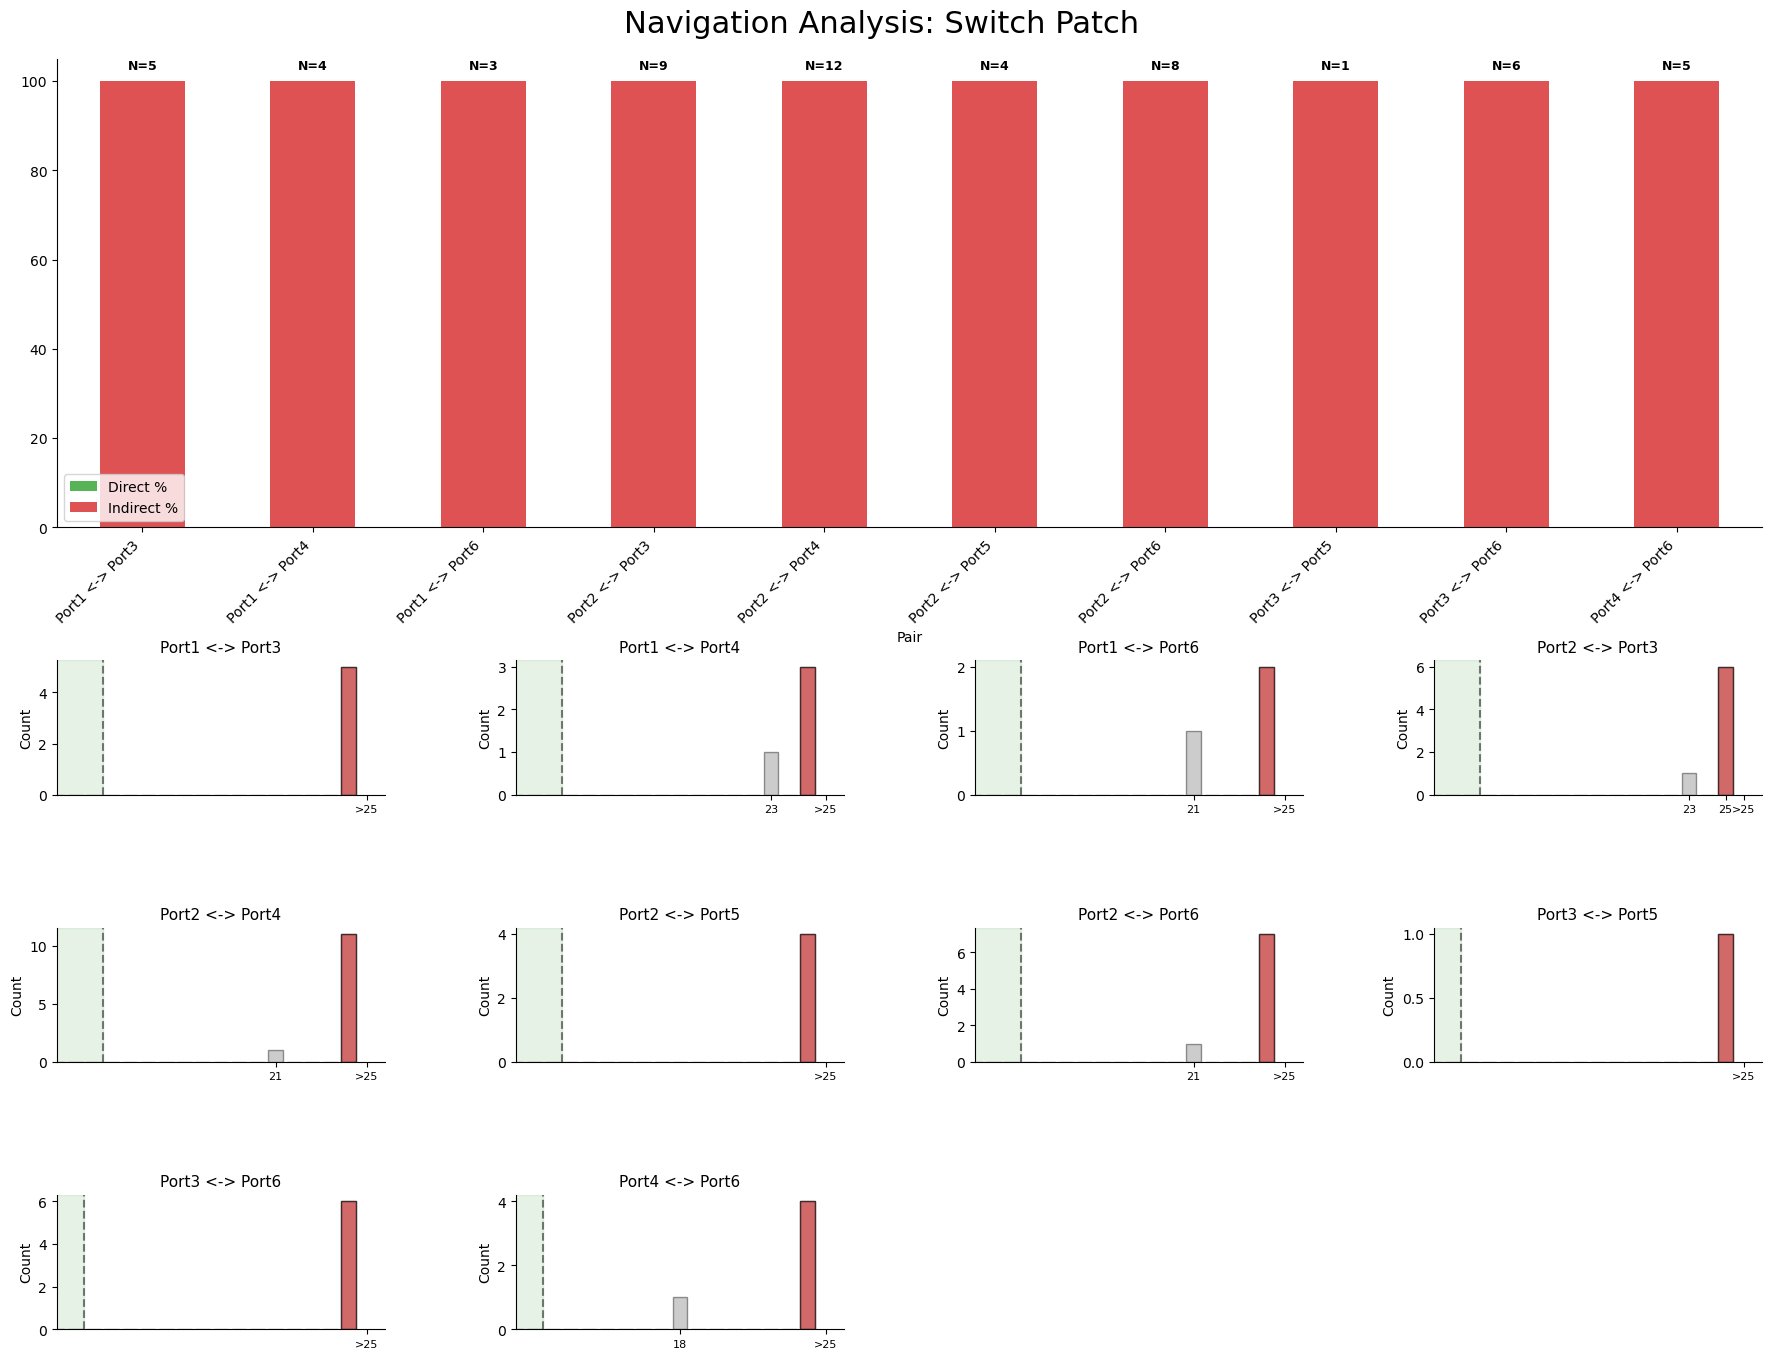

In [583]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import networkx as nx

def plot_large_scale_behavioral_summary_overflow(df_clean, all_pairs, port_map, G, x_max=25):
    # 1. Prepare Data
    port_visits = df_clean[df_clean['is_port_node'] == True].copy()
    port_visits['seq_length'] = port_visits['node_visit_idx'].diff()
    port_visits['current_port_label'] = port_visits['node_name'].map(port_map)
    port_visits['prev_port_label'] = port_visits['current_port_label'].shift(1)
    
    plot_data = []
    summary_list = []
    
    for node_a, node_b in all_pairs:
        p_a, p_b = port_map[node_a], port_map[node_b]
        pair_label = f"{p_a} <-> {p_b}"
        try:
            shortest_dist = nx.shortest_path_length(G, source=node_a, target=node_b)
        except:
            shortest_dist = 8 
        
        mask = (
            ((port_visits['prev_port_label'] == p_a) & (port_visits['current_port_label'] == p_b)) |
            ((port_visits['prev_port_label'] == p_b) & (port_visits['current_port_label'] == p_a))
        )
        subset = port_visits[mask].dropna(subset=['seq_length']).copy()
        if subset.empty: continue
            
        subset['pair_label'] = pair_label
        subset['shortest_dist'] = shortest_dist
        plot_data.append(subset)
        
        n_total = len(subset)
        n_direct = (subset['seq_length'] <= shortest_dist).sum()
        summary_list.append({'Pair': pair_label, 'Direct %': (n_direct/n_total)*100, 
                             'Indirect %': (1-n_direct/n_total)*100, 'Shortest': shortest_dist, 'Count': n_total})

    full_plot_df = pd.concat(plot_data)
    summary_df = pd.DataFrame(summary_list).sort_values('Direct %', ascending=False)

    # 2. Setup Figure
    num_pairs = len(summary_df)
    cols = 4
    rows = int(np.ceil(num_pairs / cols))
    h_ratios = [1.5, 1.0] + [1.0] * rows 
    fig = plt.figure(figsize=(22, 6 + (rows * 3.5)))
    gs = fig.add_gridspec(rows + 2, cols, height_ratios=h_ratios, hspace=0.9, wspace=0.4)
    
    ax_bar = fig.add_subplot(gs[0:2, :])
    for i, (index, row) in enumerate(summary_df.iterrows()):
        ax_bar.text(i, 102, f"N={int(row['Count'])}", 
                    ha='center', va='bottom', fontsize=9, fontweight='bold', rotation=0)
    summary_df.set_index('Pair')[['Direct %', 'Indirect %']].plot(kind='bar', stacked=True, 
                                                                  color=['#2ca02c', '#d62728'], alpha=0.8, ax=ax_bar)
    # ax_bar.set_title("Navigation Efficiency", fontsize=18, fontweight='bold', pad=20)
    plt.xticks(rotation=45, ha='right')

    # 3. Histograms with Overflow Bin
    pair_labels = summary_df['Pair'].tolist()
    for i, pair_name in enumerate(pair_labels):
        r, c = (i // cols) + 2, i % cols
        ax = fig.add_subplot(gs[r, c])
        
        data_subset = full_plot_df[full_plot_df['pair_label'] == pair_name]
        data = data_subset['seq_length'].values
        threshold = data_subset['shortest_dist'].iloc[0]
        
        # Binning logic: 0 to x_max, plus one bin for overflow
        bins = np.arange(0, x_max + 2) 
        counts, _ = np.histogram(data, bins=bins)
        
        # Add all counts > x_max to the last bin (overflow)
        overflow_count = np.sum(data > x_max)
        counts[-1] = overflow_count
        
        # Plotting manually using bar to ensure fixed width
        bin_centers = bins[:-1]
        ax.bar(bin_centers, counts, width=0.8, color='gray', alpha=0.4, edgecolor='black')
        
        # Color the overflow bin differently to stand out
        if overflow_count > 0:
            ax.bar(bin_centers[-1], overflow_count, width=0.8, color='#d62728', alpha=0.6, edgecolor='black')

        # Formatting
        ax.axvspan(-0.5, threshold + 0.5, color='green', alpha=0.1)
        ax.axvline(threshold + 0.5, color='black', linestyle='--', alpha=0.5)
        
        # Tick Management
        unique_vals = sorted([v for v in np.unique(data) if v <= x_max])
        tick_labels = [str(int(v)) for v in unique_vals]
        if overflow_count > 0:
            unique_vals.append(x_max + 1)
            tick_labels.append(f">{x_max}")
        
        ax.set_xticks(unique_vals)
        ax.set_xticklabels(tick_labels, fontsize=8)
        ax.set_title(f"{pair_name}", fontsize=11)
        ax.set_xlim(9, x_max + 2)
        ax.set_ylabel("Count")

    plt.suptitle(f"Navigation Analysis: Switch Patch", fontsize=22, y=0.91)
    sns.despine()
    plt.show()

plot_large_scale_behavioral_summary_overflow(node_summary_df, remaining_pairs, port_map, G, x_max=25)

In [584]:
# import networkx as nx
# import matplotlib.pyplot as plt
# from collections import Counter
# import matplotlib.cm as cm
# import matplotlib.patches as mpatches

# def plot_large_scale_heatmap_with_legend(G, node_positions, df_clean, all_pairs, port_map):
#     # 1. GENERATE DYNAMIC COLOR MAP (Categorical colors)
#     cmap = cm.get_cmap('tab20', len(all_pairs))
#     pair_to_color = {f"{port_map[a]}-{port_map[b]}": cmap(i) for i, (a, b) in enumerate(all_pairs)}

#     # 2. COUNT ALL NODES IN INDIRECT PATHS (Removing the exclusion logic)
#     pair_error_counts = {p: Counter() for p in pair_to_color.keys()}
#     port_visits = df_clean[df_clean['is_port_node'] == True].copy()
#     indices = port_visits.index.tolist()
    
#     for i in range(1, len(indices)):
#         p1, p2 = port_visits.iloc[i-1]['node_name'], port_visits.iloc[i]['node_name']
#         for a, b in all_pairs:
#             if {p1, p2} == {a, b}:
#                 pair_key = f"{port_map[a]}-{port_map[b]}"
#                 # Extract intermediate nodes
#                 path = df_clean.loc[indices[i-1]:indices[i], 'node_name'].tolist()
                
#                 # If length > 8, it's indirect. Count every intermediate node.
#                 if len(path) > 8:
#                     pair_error_counts[pair_key].update(path[1:-1])

#     # 3. SETUP FIGURE
#     fig = plt.figure(figsize=(20, 14))
#     # Create space for legend on the right
#     ax = fig.add_axes([0.05, 0.05, 0.7, 0.9]) 
    
#     # Maze skeleton
#     nx.draw_networkx_edges(G, node_positions, ax=ax, alpha=0.03, edge_color='black', arrows=False)

#     # 4. DRAW NODES WITH LAYERED COLORING
#     all_error_nodes = set().union(*(c.keys() for c in pair_error_counts.values()))

#     for node in all_error_nodes:
#         node_stats = {p: counts[node] for p, counts in pair_error_counts.items() if node in counts}
#         top_pairs = sorted(node_stats.keys(), key=lambda x: node_stats[x], reverse=True)
#         total_visits = sum(node_stats.values())
#         num_contribs = len(top_pairs)
        
#         # Color Logic
#         fill_color = pair_to_color[top_pairs[0]]
#         edge_color = pair_to_color[top_pairs[1]] if num_contribs > 1 else 'none'
#         text_color = pair_to_color[top_pairs[2]] if num_contribs > 2 else 'white'
        
#         if num_contribs >= 4:
#             fill_color, edge_color, text_color, lw = 'lightgray', 'black', 'black', 1
#         else:
#             lw = 4 if num_contribs > 1 else 0

#         nx.draw_networkx_nodes(G, node_positions, nodelist=[node], 
#                                node_color=[fill_color], edgecolors=edge_color,
#                                linewidths=lw, node_size=700, alpha=0.8, ax=ax)
        
#         nx.draw_networkx_labels(G, node_positions, labels={node: str(total_visits)}, 
#                                 font_size=9, font_color=text_color, font_weight='bold', ax=ax)

#     # Port Labels
#     port_labels = {k: v for k, v in port_map.items()}
#     nx.draw_networkx_labels(G, node_positions, labels=port_labels, font_size=10, font_weight='bold', ax=ax)

#     # 5. CREATE THE LEGEND
#     legend_patches = [mpatches.Patch(color=color, label=label) for label, color in pair_to_color.items()]
#     # Place legend outside the main axis
#     fig.legend(handles=legend_patches, loc='center right', title="Port Pairs", 
#                ncol=2, fontsize=9, bbox_to_anchor=(0.98, 0.5))

#     ax.set_title(f"Global Exploration Heatmap: Indirect Paths for {len(all_pairs)} Pairs", fontsize=18)
#     ax.axis('off')
#     plt.show()

# # Run
# plot_large_scale_heatmap_with_legend(G, node_positions, node_summary_df, remaining_pairs, port_map)

In [585]:
# import networkx as nx
# import matplotlib.pyplot as plt
# from collections import Counter
# import matplotlib.cm as cm
# import matplotlib.patches as mpatches

# def plot_large_scale_comprehensive_heatmap(G, node_positions, df_clean, all_pairs, port_map):
#     # 1. GENERATE DYNAMIC COLOR MAP (Categorical colors for 24 pairs)
#     cmap = cm.get_cmap('tab20', len(all_pairs))
#     pair_to_color = {f"{port_map[a]}-{port_map[b]}": cmap(i) for i, (a, b) in enumerate(all_pairs)}

#     # 2. CALCULATE DIRECT PATHS (Edges only)
#     pair_direct_edges = {}
#     for a, b in all_pairs:
#         pair_key = f"{port_map[a]}-{port_map[b]}"
#         try:
#             shortest_path = nx.shortest_path(G, a, b)
#             edges = [tuple(sorted((shortest_path[i], shortest_path[i+1]))) for i in range(len(shortest_path)-1)]
#             pair_direct_edges[pair_key] = edges
#         except nx.NetworkXNoPath:
#             pair_direct_edges[pair_key] = []

#     # 3. COUNT ALL NODES IN INDIRECT PATHS
#     pair_error_counts = {p: Counter() for p in pair_to_color.keys()}
#     port_visits = df_clean[df_clean['is_port_node'] == True].copy()
#     indices = port_visits.index.tolist()
    
#     for i in range(1, len(indices)):
#         p1, p2 = port_visits.iloc[i-1]['node_name'], port_visits.iloc[i]['node_name']
#         for a, b in all_pairs:
#             if {p1, p2} == {a, b}:
#                 pair_key = f"{port_map[a]}-{port_map[b]}"
#                 path = df_clean.loc[indices[i-1]:indices[i], 'node_name'].tolist()
                
#                 # Count all intermediate nodes if the path is indirect (>8 nodes)
#                 if len(path) > 8:
#                     pair_error_counts[pair_key].update(path[1:-1])

#     # 4. SETUP PLOT
#     fig = plt.figure(figsize=(22, 14))
#     ax = fig.add_axes([0.05, 0.05, 0.65, 0.9]) # Main maze area
    
#     # Maze skeleton (very faint)
#     nx.draw_networkx_edges(G, node_positions, ax=ax, alpha=0.02, edge_color='black', arrows=False)

#     # 5. DRAW TASK BACKBONES (Edges)
#     for pair_key, edges in pair_direct_edges.items():
#         if edges:
#             nx.draw_networkx_edges(G, node_positions, edgelist=edges, 
#                                    edge_color=[pair_to_color[pair_key]], 
#                                    width=2.0, alpha=0.35, ax=ax, arrows=False)

#     # 6. DRAW NODES WITH MULTI-PAIR LOGIC
#     all_error_nodes = set().union(*(c.keys() for c in pair_error_counts.values()))

#     for node in all_error_nodes:
#         node_stats = {p: counts[node] for p, counts in pair_error_counts.items() if node in counts}
#         top_pairs = sorted(node_stats.keys(), key=lambda x: node_stats[x], reverse=True)
#         total_visits = sum(node_stats.values())
#         num_contribs = len(top_pairs)
        
#         # Color Assignment
#         fill_color = pair_to_color[top_pairs[0]]
#         edge_color = pair_to_color[top_pairs[1]] if num_contribs > 1 else 'none'
#         text_color = pair_to_color[top_pairs[2]] if num_contribs > 2 else 'white'
        
#         if num_contribs >= 4:
#             fill_color, edge_color, text_color, lw = 'lightgray', 'black', 'black', 1
#         else:
#             lw = 4 if num_contribs > 1 else 0

#         nx.draw_networkx_nodes(G, node_positions, nodelist=[node], 
#                                node_color=[fill_color], edgecolors=edge_color,
#                                linewidths=lw, node_size=750, alpha=0.85, ax=ax)
        
#         nx.draw_networkx_labels(G, node_positions, labels={node: str(total_visits)}, 
#                                 font_size=9, font_color=text_color, font_weight='bold', ax=ax)

#     # Port Labels
#     port_labels = {k: v for k, v in port_map.items()}
#     nx.draw_networkx_labels(G, node_positions, labels=port_labels, font_size=11, font_weight='bold', ax=ax)

#     # 7. MULTI-COLUMN LEGEND
#     legend_patches = [mpatches.Patch(color=color, label=label) for label, color in pair_to_color.items()]
#     fig.legend(handles=legend_patches, loc='right', title="Task Pairs (Backbone & Fill)", 
#                ncol=2, fontsize=8, bbox_to_anchor=(0.75, 0.5))

#     ax.set_title(f"Multi-Task Exploration Heatmap: Backbones and Decision Hubs", fontsize=18)
#     ax.axis('off')
#     plt.show()

# plot_large_scale_comprehensive_heatmap(G, node_positions, node_summary_df, remaining_pairs, port_map)

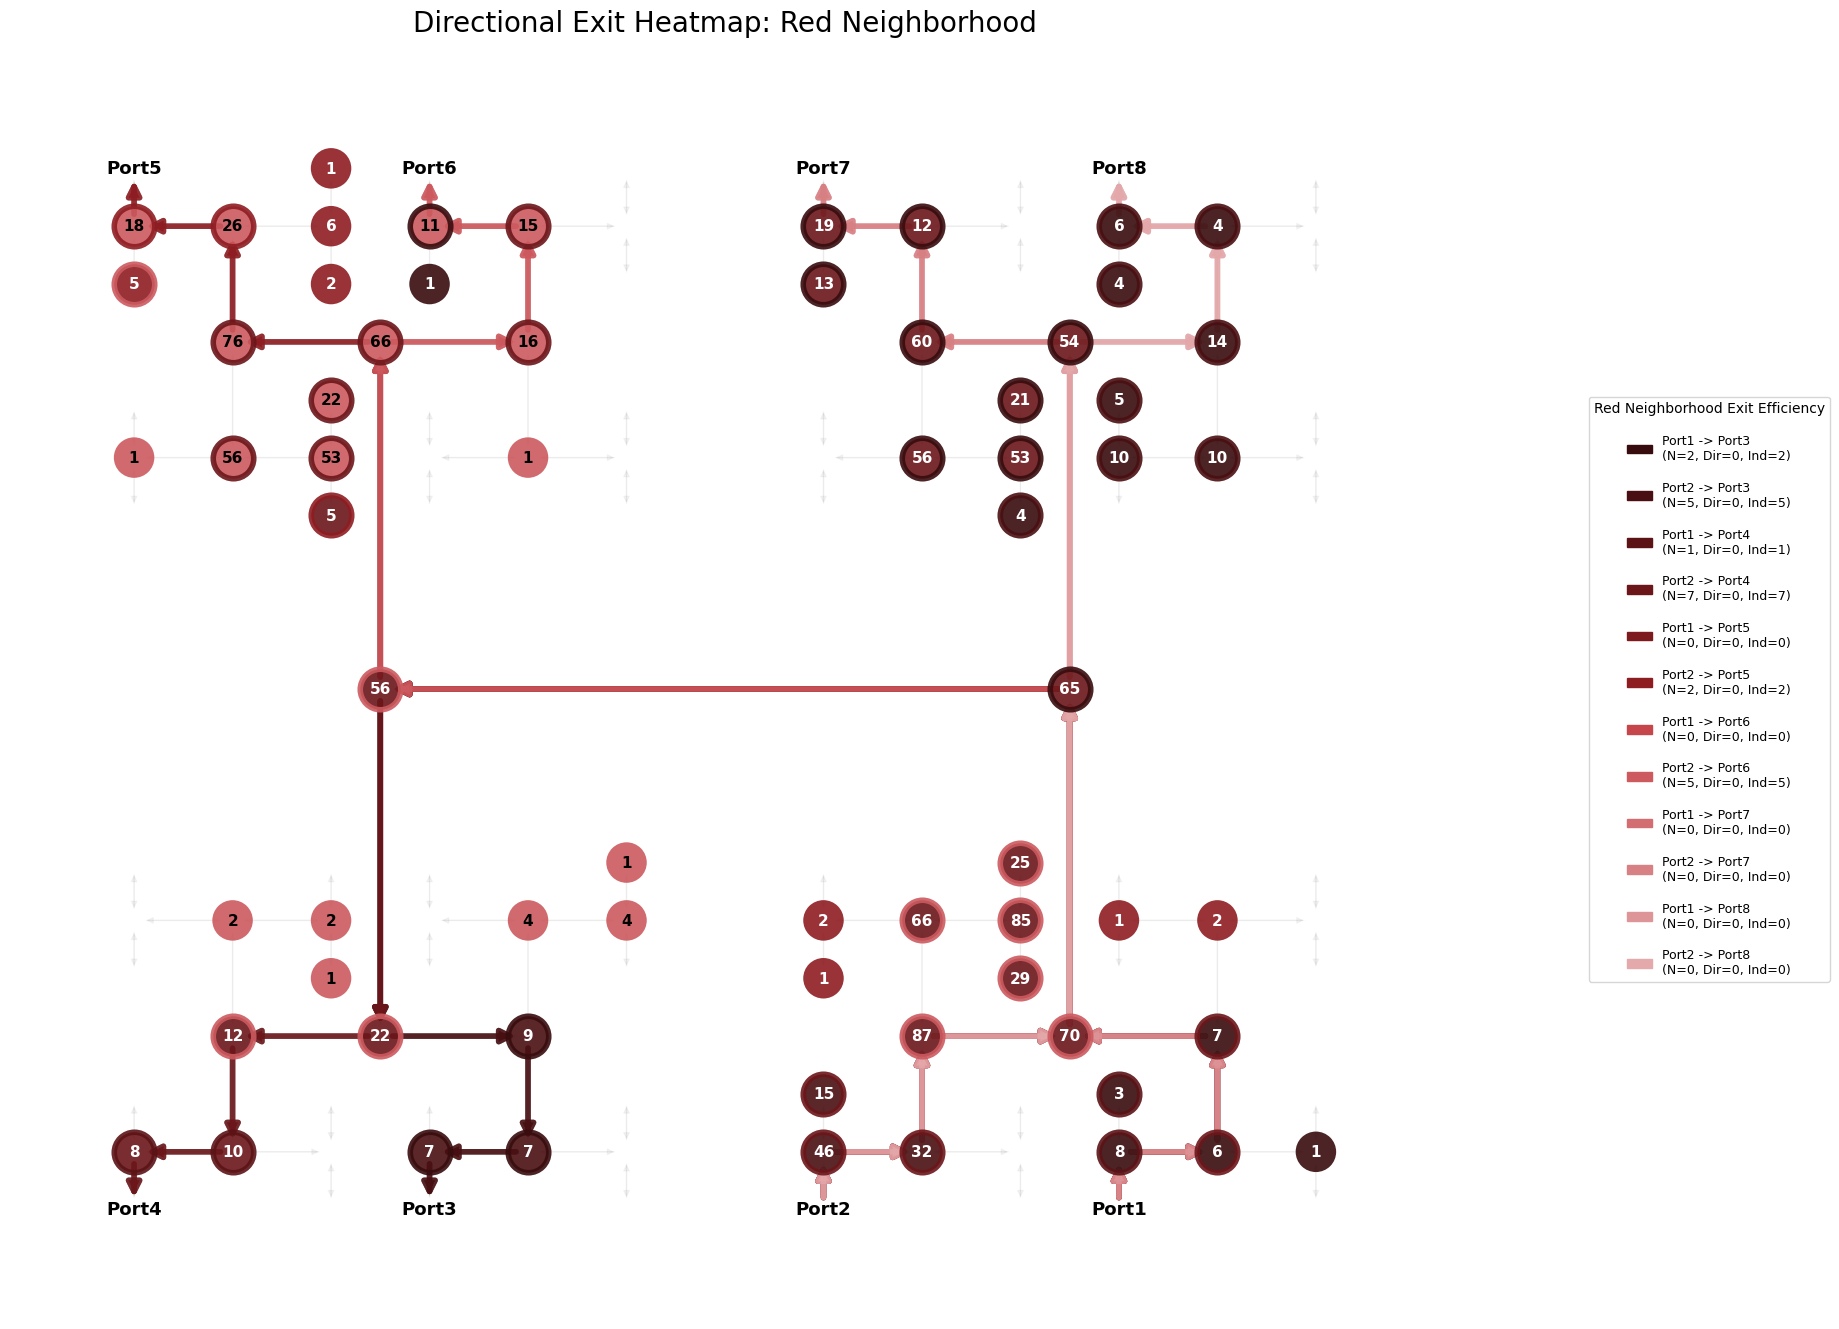

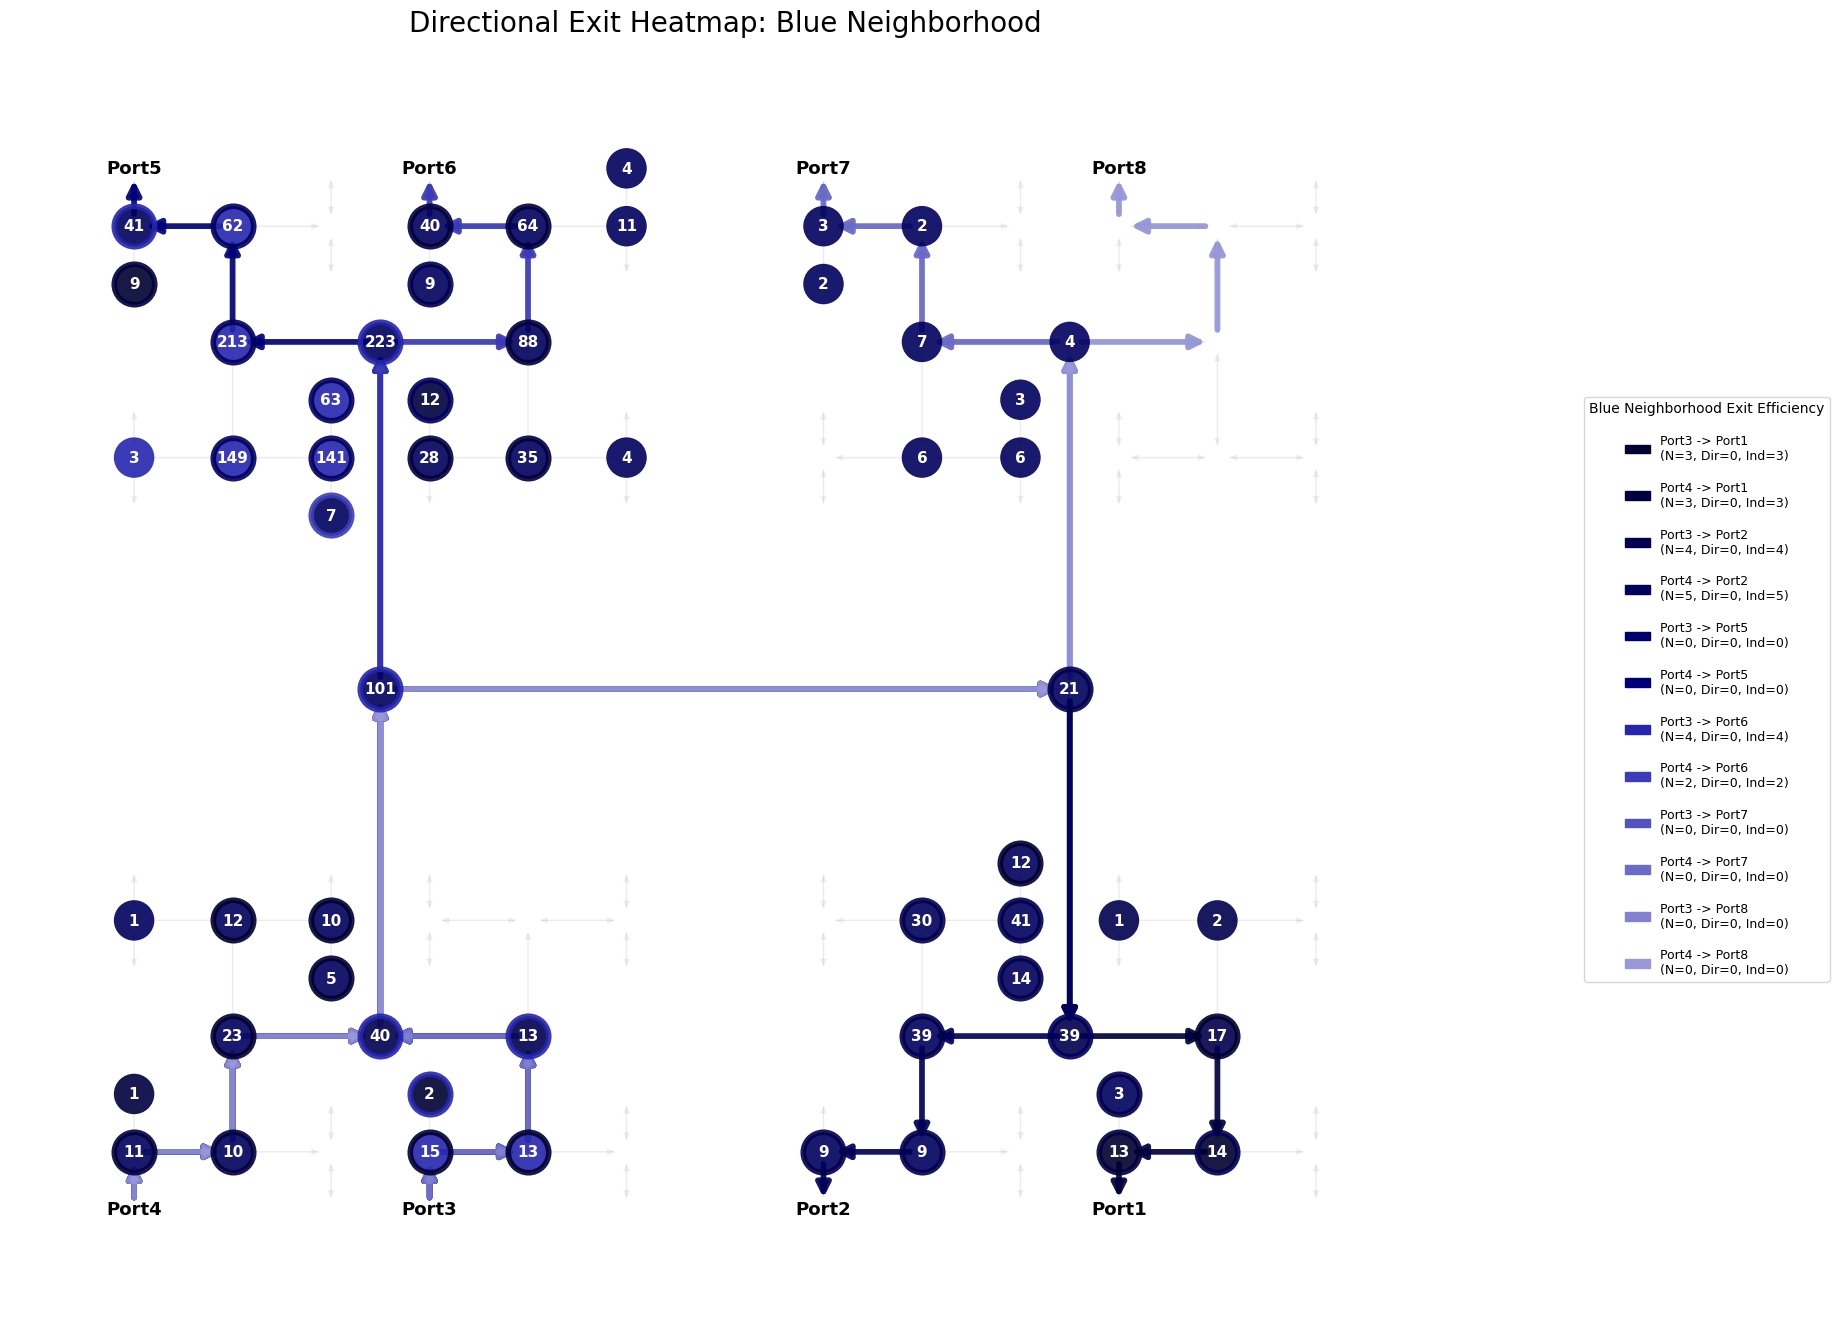

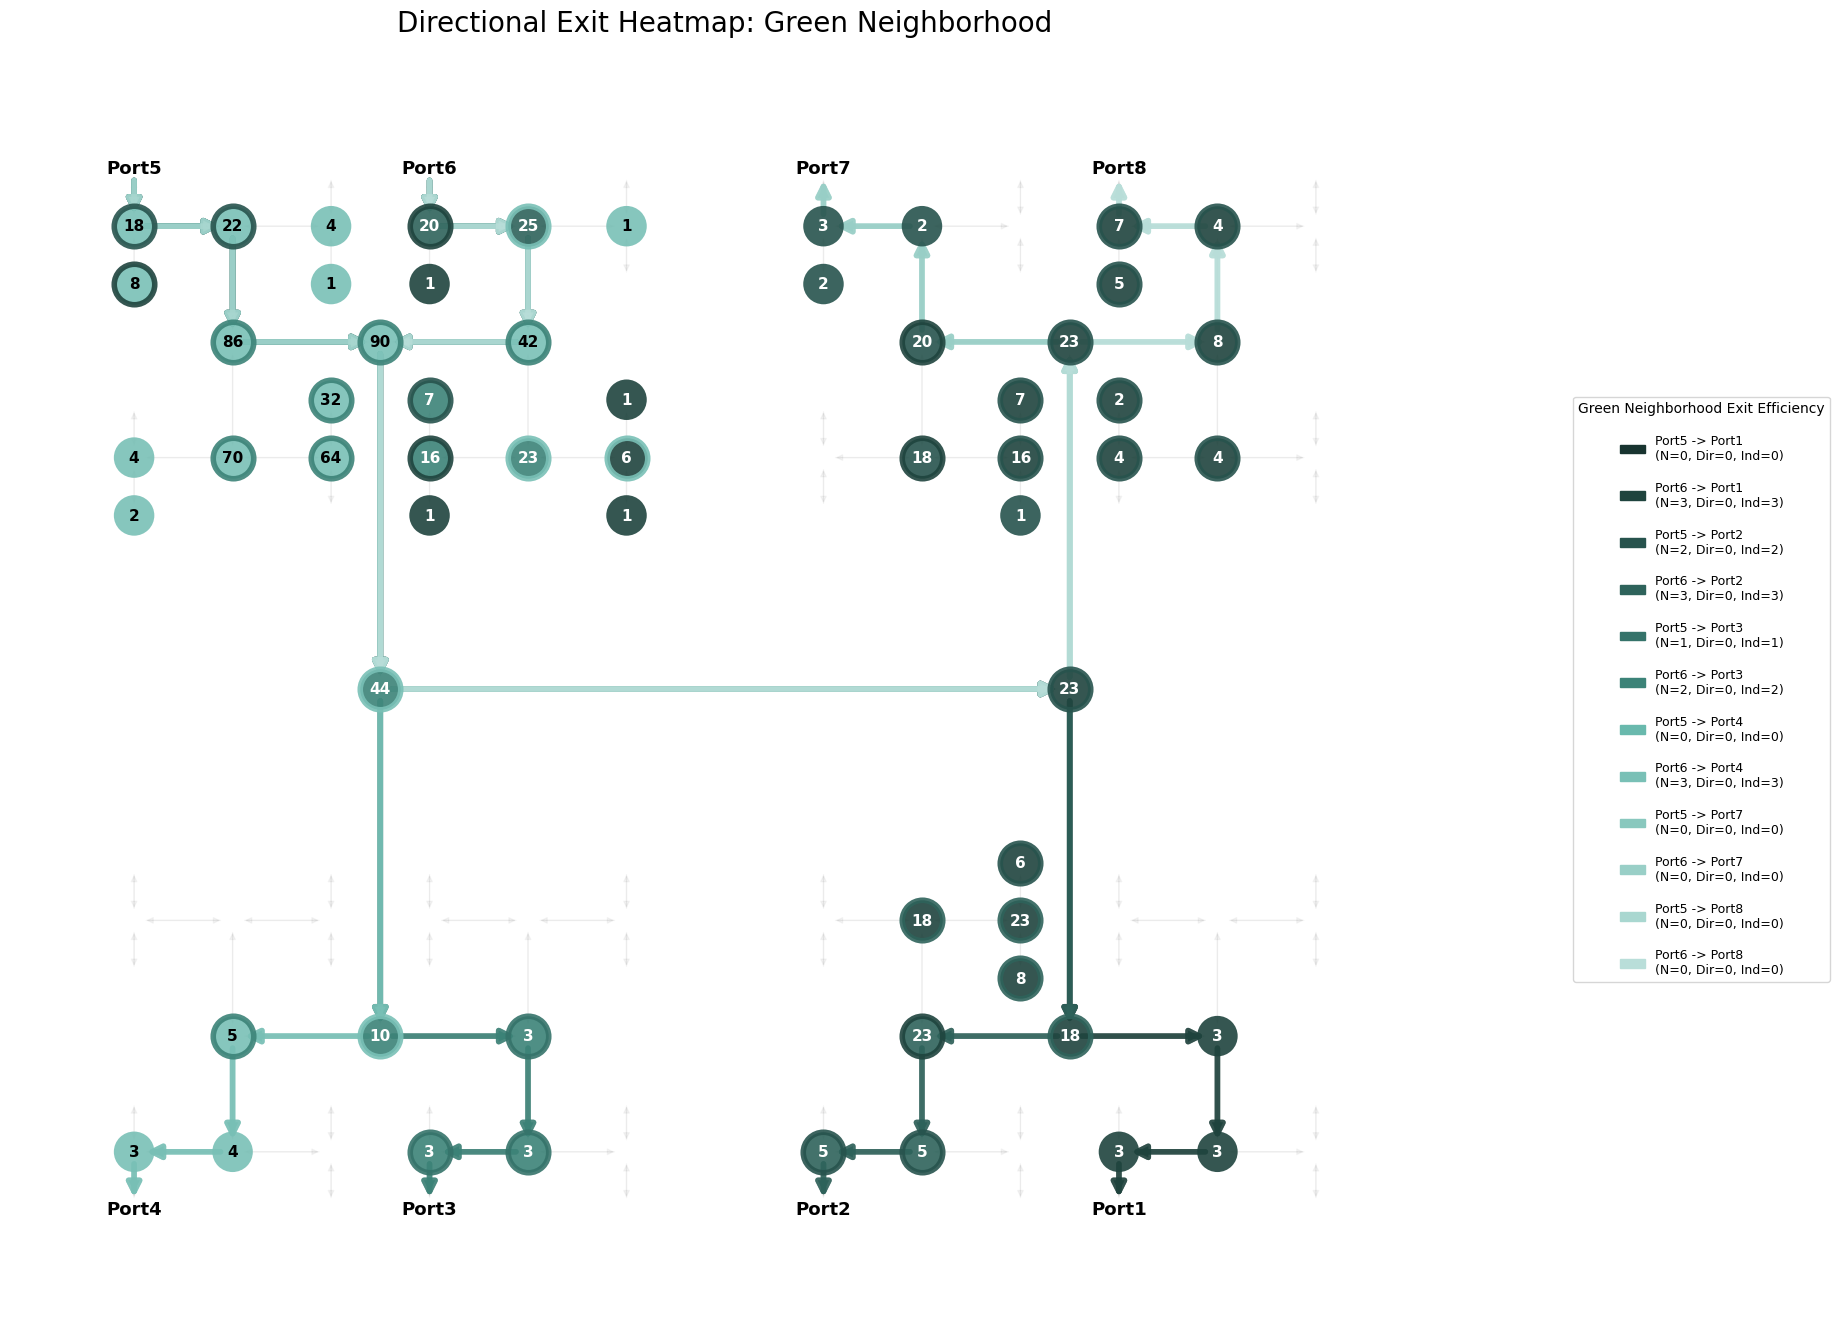

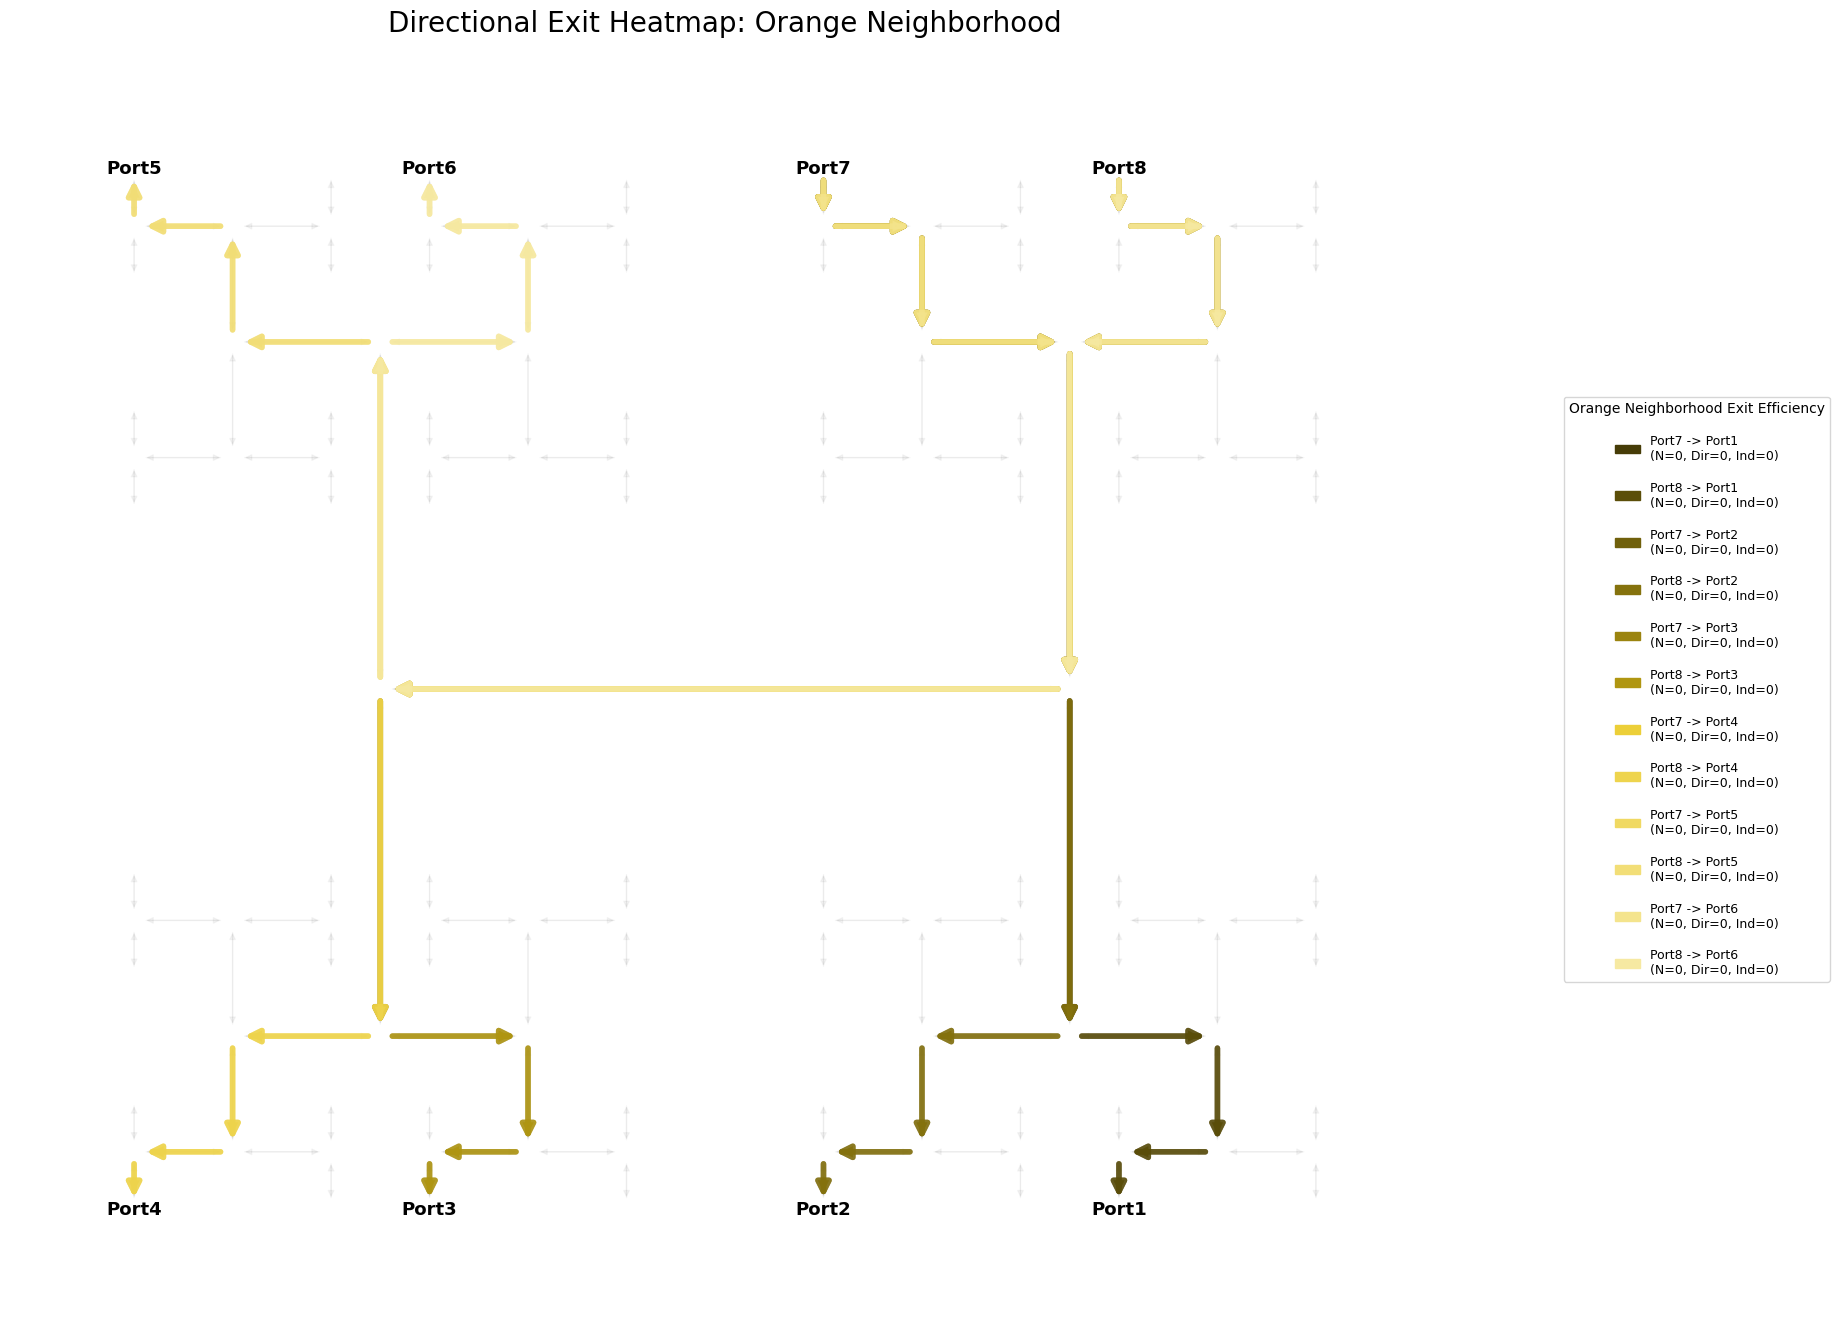

In [586]:
import networkx as nx
import matplotlib.pyplot as plt
from collections import Counter
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import numpy as np

def plot_gradient_exit_heatmaps_original_with_efficiency(G, node_positions, df_clean, all_pairs, port_map):
    base_colors = {
        'Red Neighborhood': '#bc272d', 
        'Blue Neighborhood': '#0000a2', 
        'Green Neighborhood': '#50ad9f', 
        'Orange Neighborhood': '#e9c716'
    }

    neighborhoods = {
        'Red Neighborhood': ['Port1', 'Port2'],
        'Blue Neighborhood': ['Port3', 'Port4'],
        'Green Neighborhood': ['Port5', 'Port6'],
        'Orange Neighborhood': ['Port7', 'Port8']
    }

    def get_distinct_colors(hex_color, n):
        if n == 0: return []
        base_rgb = np.array(mcolors.to_rgb(hex_color))
        colors = []
        for i in range(n):
            scale = (i / (n - 1)) if n > 1 else 0.5
            if scale < 0.5:
                color = base_rgb * (0.3 + scale) 
            else:
                color = base_rgb + (np.array([1, 1, 1]) - base_rgb) * (scale - 0.4)
            colors.append(mcolors.to_hex(np.clip(color, 0, 1)))
        return colors

    port_visits = df_clean[df_clean['is_port_node'] == True].copy()
    indices = port_visits.index.tolist()

    for title, focus_ports in neighborhoods.items():
        base_hex = base_colors[title]
        
        # 1. Gather the 12 exit directions
        directional_exits = []
        for src, dest in [(a, b) for a, b in all_pairs] + [(b, a) for a, b in all_pairs]:
            if port_map[src] in focus_ports:
                directional_exits.append((src, dest))

        directional_exits.sort(key=lambda x: port_map[x[1]])
        path_colors = get_distinct_colors(base_hex, len(directional_exits))
        pair_to_color = {f"{port_map[src]} -> {port_map[dest]}": path_colors[i] 
                         for i, (src, dest) in enumerate(directional_exits)}

        # 2. Prep Counters, Backbones, and SHORT PATH LENGTHS
        pair_error_counts = {pk: Counter() for pk in pair_to_color}
        pair_stats = {pk: {'total': 0, 'direct': 0, 'indirect': 0} for pk in pair_to_color}
        pair_shortest_len = {}
        pair_direct_edges = {}

        for src, dest in directional_exits:
            p_key = f"{port_map[src]} -> {port_map[dest]}"
            try:
                path = nx.shortest_path(G, src, dest)
                pair_shortest_len[p_key] = len(path) # Number of nodes in shortest path
                pair_direct_edges[p_key] = [(path[i], path[i+1]) for i in range(len(path)-1)]
            except: 
                pair_shortest_len[p_key] = 999
                pair_direct_edges[p_key] = []

        # 3. Analyze DataFrame
        port_visits = df_clean[df_clean['is_port_node'] == True].copy()
        indices = port_visits.index.tolist()
        
        for i in range(1, len(indices)):
            p_start_node = port_visits.iloc[i-1]['node_name']
            p_end_node = port_visits.iloc[i]['node_name']
            
            if port_map[p_start_node] in focus_ports:
                p_key = f"{port_map[p_start_node]} -> {port_map[p_end_node]}"
                
                if p_key in pair_stats:
                    pair_stats[p_key]['total'] += 1
                    # Extract the actual sequence of nodes the mouse took
                    path_nodes = df_clean.loc[indices[i-1]:indices[i], 'node_name'].tolist()
                    
                    # ADAPTIVE THRESHOLD: 
                    # We allow a small buffer (e.g., +2 nodes) for the mouse to "turn around" 
                    # at the port or for minor sampling jitter.
                    if len(path_nodes) > (pair_shortest_len[p_key] + 2):
                        pair_stats[p_key]['indirect'] += 1
                        pair_error_counts[p_key].update(path_nodes[1:-1])
                    else:
                        pair_stats[p_key]['direct'] += 1

        # 4. PLOTTING
        fig = plt.figure(figsize=(22, 14))
        ax = fig.add_axes([0.05, 0.05, 0.65, 0.9])
        nx.draw_networkx_edges(G, node_positions, ax=ax, alpha=0.04, edge_color='black')

        # Draw Backbones
        for p_key, edges in pair_direct_edges.items():
            nx.draw_networkx_edges(G, node_positions, edgelist=edges, 
                                   edge_color=pair_to_color[p_key], 
                                   width=4.0, alpha=0.7, ax=ax, 
                                   arrows=True, arrowsize=20, arrowstyle='-|>')

        # Draw Detour Nodes
        all_error_nodes = set().union(*(c.keys() for c in pair_error_counts.values()))
        for node in all_error_nodes:
            node_stats = {pk: pair_error_counts[pk][node] for pk in pair_error_counts if node in pair_error_counts[pk]}
            top_pk = sorted(node_stats.keys(), key=lambda x: node_stats[x], reverse=True)
            total = sum(node_stats.values())
            
            f_color = pair_to_color[top_pk[0]]
            e_color = pair_to_color[top_pk[1]] if len(top_pk) > 1 else 'none'
            lw = 4 if len(top_pk) > 1 else 0
            
            lum = np.mean(mcolors.to_rgb(f_color))
            nx.draw_networkx_nodes(G, node_positions, nodelist=[node], 
                                   node_color=[f_color], edgecolors=e_color,
                                   linewidths=lw, node_size=850, alpha=0.9, ax=ax)
            nx.draw_networkx_labels(G, node_positions, labels={node: str(total)}, 
                                    font_size=11, font_color='white' if lum < 0.5 else 'black', font_weight='bold', ax=ax)

        # Labels
        nx.draw_networkx_labels(G, node_positions, labels=port_map, font_size=13, font_weight='bold', ax=ax)

        # 5. LEGEND with Direct/Indirect breakdown
        legend_patches = []
        for pk in pair_to_color:
            s = pair_stats[pk]
            label_text = f"{pk}\n(N={s['total']}, Dir={s['direct']}, Ind={s['indirect']})"
            legend_patches.append(mpatches.Patch(color=pair_to_color[pk], label=label_text))
        
        fig.legend(handles=legend_patches, loc='center right', title=f"{title} Exit Efficiency", 
                   ncol=1, fontsize=9, bbox_to_anchor=(0.88, 0.5), frameon=True, labelspacing=1.5)

        ax.set_title(f"Directional Exit Heatmap: {title}", fontsize=20, pad=20)
        ax.axis('off')
        plt.show()

# Run
plot_gradient_exit_heatmaps_original_with_efficiency(G, node_positions, node_summary_df, remaining_pairs, port_map)

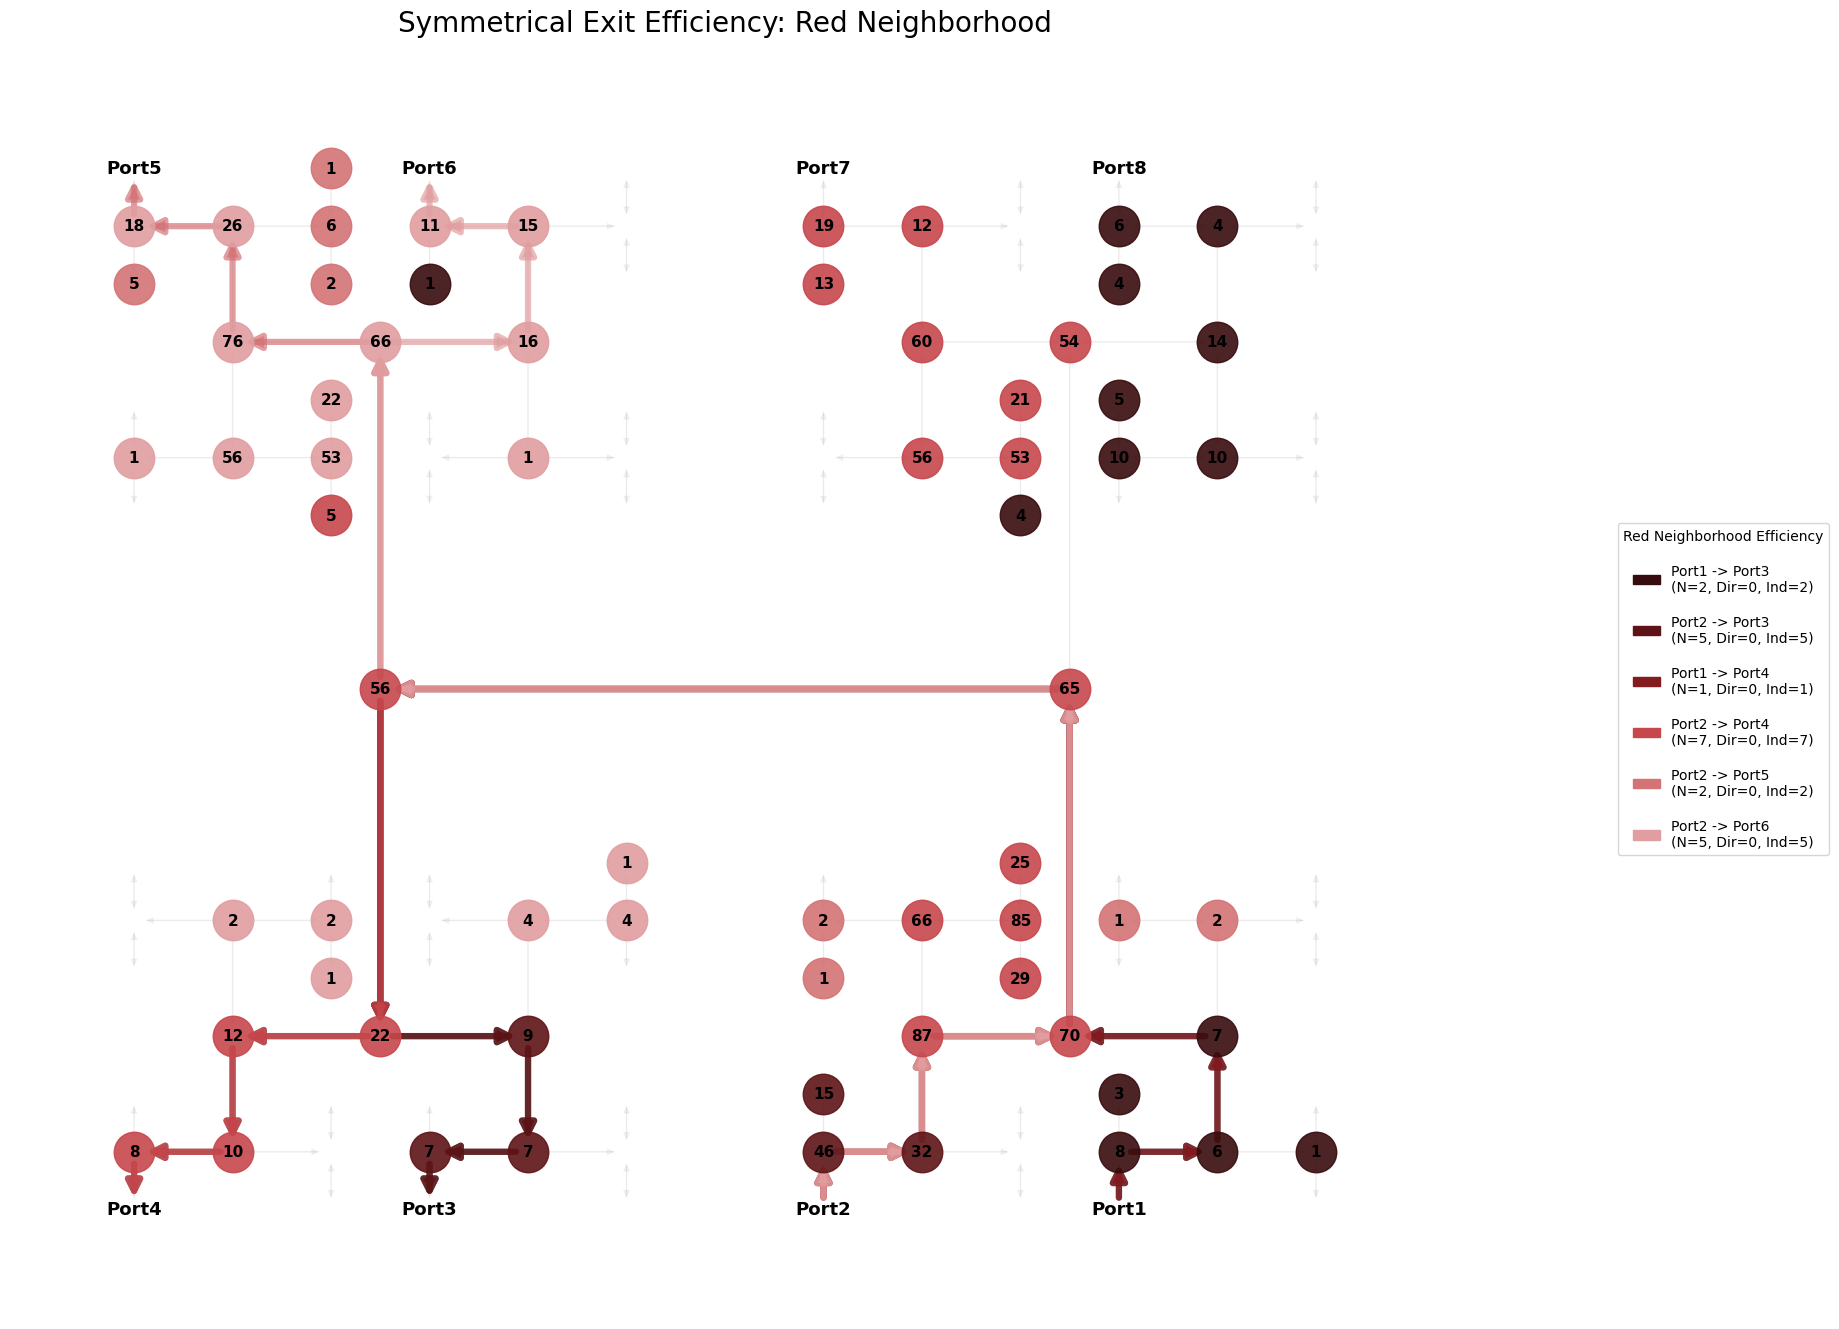

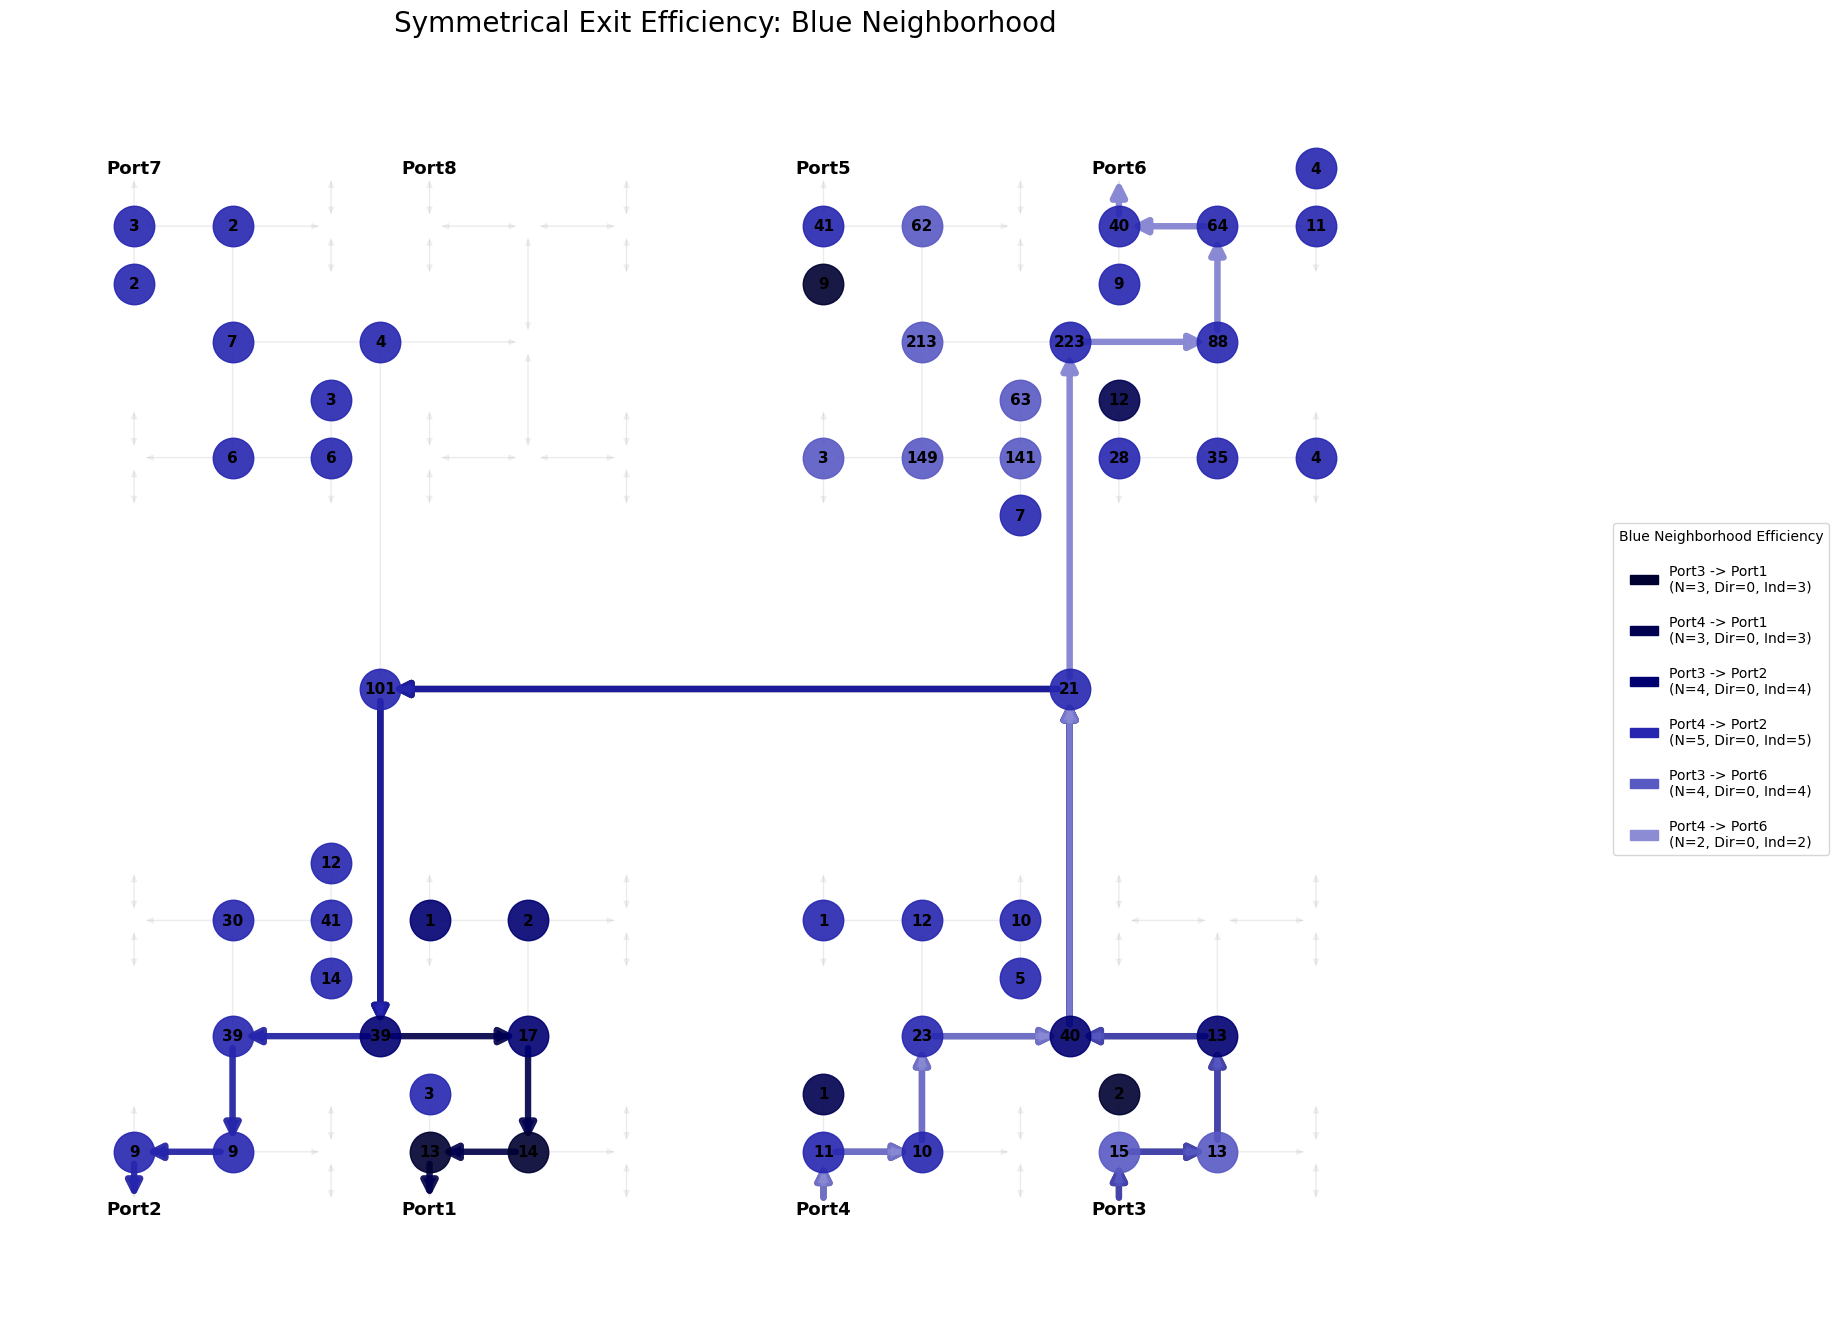

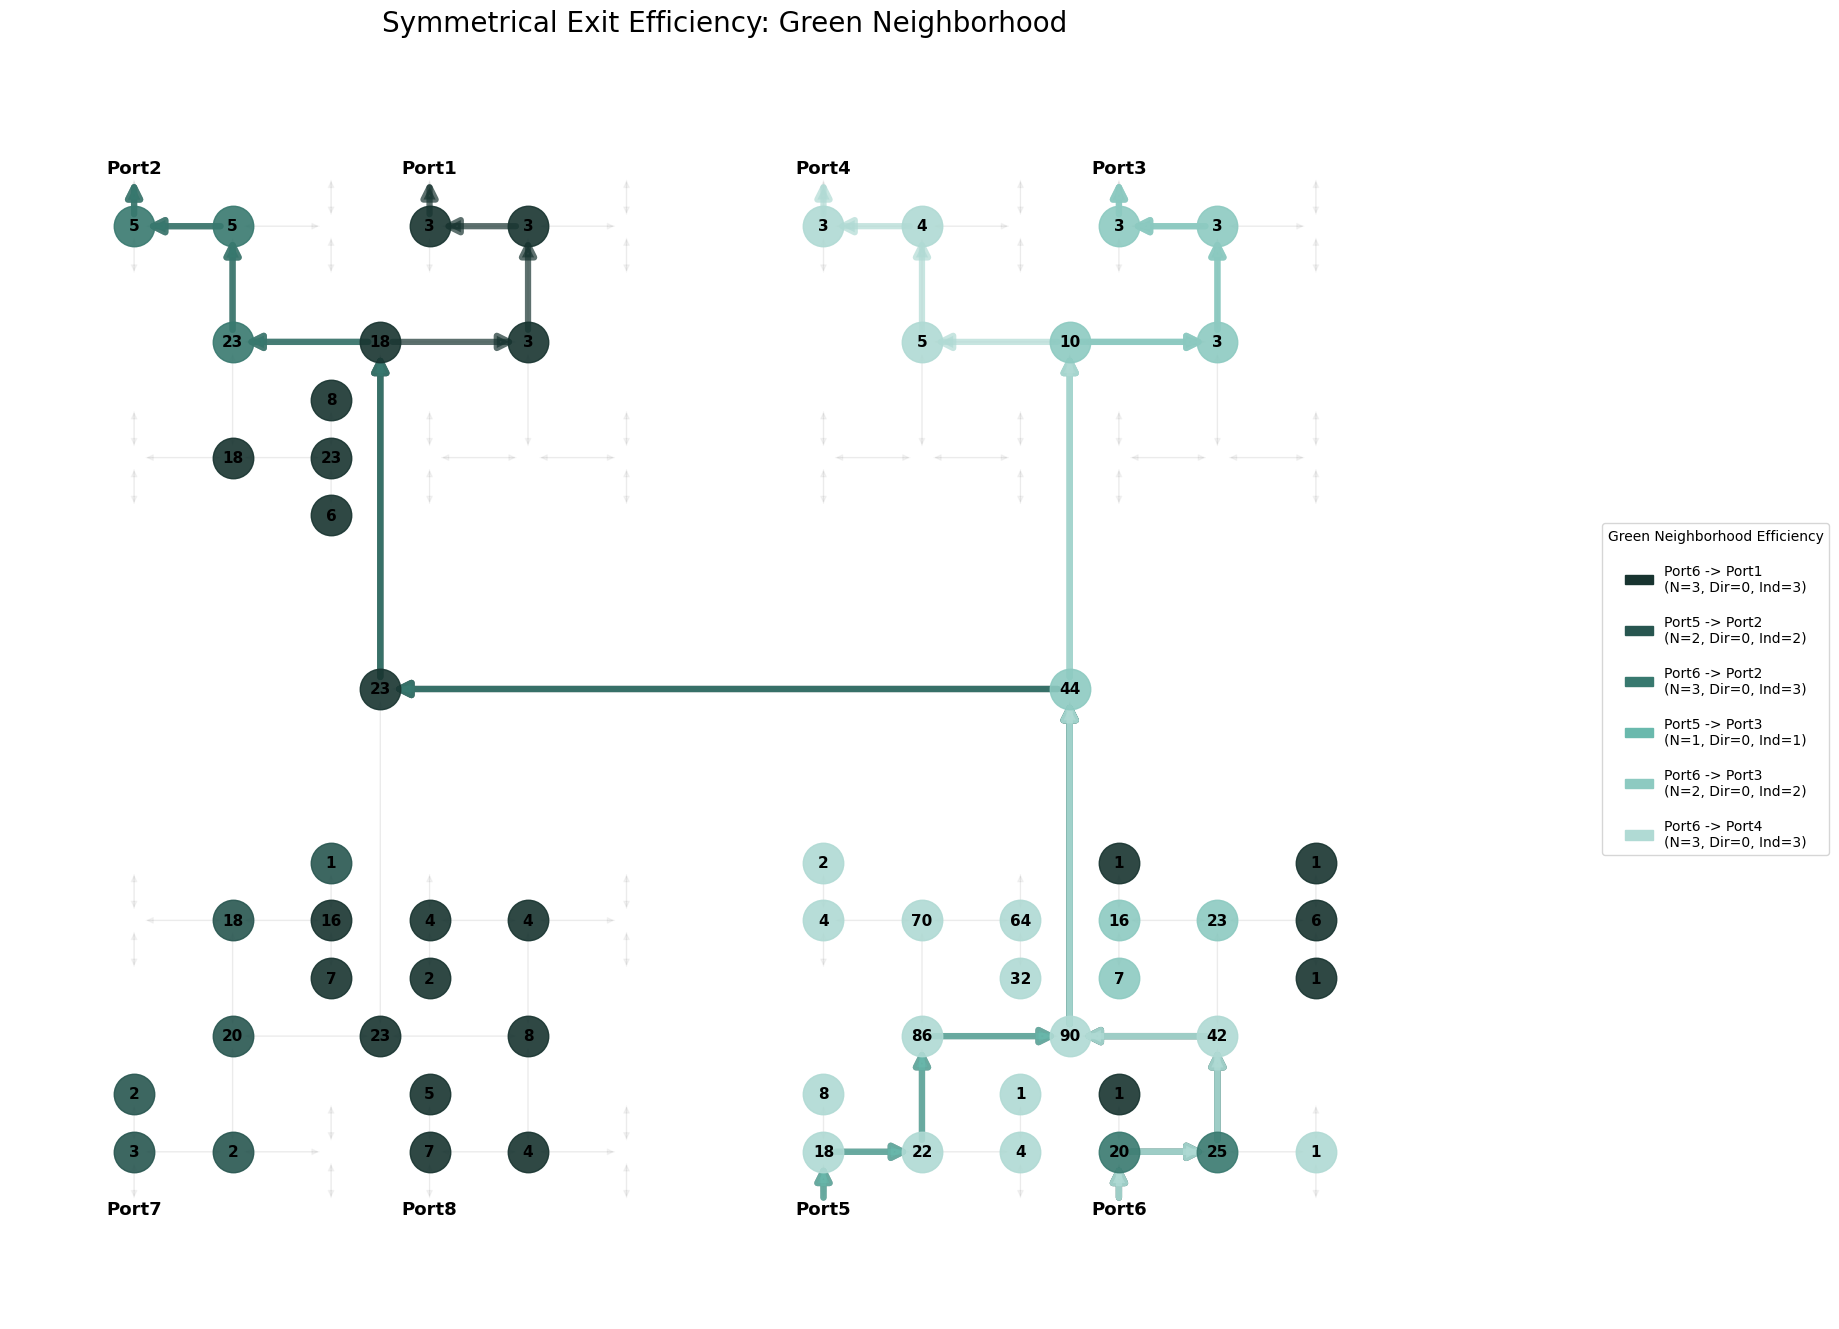

In [587]:
from itertools import groupby

def plot_symmetrical_exit_heatmaps_efficiency_fixed(G, node_positions, df_clean, all_pairs, port_map, reflection_maps):
    neighborhood_configs = [
        {'name': 'Red Neighborhood', 'ports': ['Port1', 'Port2'], 'color': '#bc272d', 'map_idx': 0},
        {'name': 'Blue Neighborhood', 'ports': ['Port3', 'Port4'], 'color': '#0000a2', 'map_idx': 1},
        {'name': 'Green Neighborhood', 'ports': ['Port5', 'Port6'], 'color': '#50ad9f', 'map_idx': 2},
        {'name': 'Orange Neighborhood', 'ports': ['Port7', 'Port8'], 'color': '#e9c716', 'map_idx': 3}
    ]

    def get_distinct_colors(hex_color, n):
        if n == 0: return []
        if n == 1: return [hex_color]
        base_rgb = np.array(mcolors.to_rgb(hex_color))
        return [mcolors.to_hex(np.clip(base_rgb * (0.3 + (i/(n-1))) if i/n < 0.5 
                                      else base_rgb + (np.array([1,1,1])-base_rgb)*(i/(n-1) - 0.45), 0, 1)) 
                for i in range(n)]

    port_visits = df_clean[df_clean['is_port_node'] == True].copy()
    indices = port_visits.index.tolist()
    
    port_visits['prev_node_name'] = port_visits['node_name'].shift(1)
    transition_counts = port_visits.groupby(['prev_node_name', 'node_name']).size().to_dict()

    for config in neighborhood_configs:
        title = config['name']
        focus_ports = config['ports']
        base_hex = config['color']
        ref_map = reflection_maps[config['map_idx']]
        
        active_exits = []
        for src, dest in [(a, b) for a, b in all_pairs] + [(b, a) for a, b in all_pairs]:
            if port_map[src] in focus_ports:
                count = transition_counts.get((src, dest), 0)
                if count > 0:
                    active_exits.append(((src, dest), count))

        if not active_exits: continue
        active_exits.sort(key=lambda x: port_map[x[0][1]])
        path_colors = get_distinct_colors(base_hex, len(active_exits))
        
        pair_to_color = {}
        pair_stats = {} 
        pair_direct_edges = {}
        pair_error_counts = {}
        pair_shortest_len = {}

        # 1. Setup Backbones and calculate Shortest Path Lengths for thresholding
        for i, ((src, dest), count) in enumerate(active_exits):
            p_key = f"{port_map[src]} -> {port_map[dest]}"
            pair_to_color[p_key] = path_colors[i]
            pair_stats[p_key] = {'total': 0, 'direct': 0, 'indirect': 0}
            pair_error_counts[p_key] = Counter()
            
            try:
                # Store the length of the ideal path in G
                path_in_G = nx.shortest_path(G, src, dest)
                pair_shortest_len[p_key] = len(path_in_G)
                
                # Reflect for plotting
                ref_src, ref_dest = ref_map.get(src, src), ref_map.get(dest, dest)
                final_path = nx.shortest_path(G, ref_src, ref_dest)
                pair_direct_edges[p_key] = [(final_path[j], final_path[j+1]) for j in range(len(final_path)-1)]
            except: pair_shortest_len[p_key] = 999

        # 2. Analyze DataFrame with Deduping and Adaptive Thresholds
        for i in range(1, len(indices)):
            p_start, p_end = port_visits.iloc[i-1]['node_name'], port_visits.iloc[i]['node_name']
            if port_map[p_start] in focus_ports:
                p_key = f"{port_map[p_start]} -> {port_map[p_end]}"
                
                if p_key in pair_stats:
                    pair_stats[p_key]['total'] += 1
                    raw_path = df_clean.loc[indices[i-1]:indices[i], 'node_name'].tolist()
                    
                    # DEDUPE: Convert [A, A, A, B, B, C] to [A, B, C]
                    deduped_path = [k for k, g in groupby(raw_path)]
                    
                    # ADAPTIVE CHECK: If path is longer than shortest + 2 nodes, it's indirect
                    if len(deduped_path) > (pair_shortest_len[p_key] + 2):
                        pair_stats[p_key]['indirect'] += 1
                        reflected_detours = [ref_map.get(n, n) for n in deduped_path[1:-1]]
                        pair_error_counts[p_key].update(reflected_detours)
                    else:
                        pair_stats[p_key]['direct'] += 1

        # 3. PLOTTING
        fig = plt.figure(figsize=(22, 14))
        ax = fig.add_axes([0.05, 0.05, 0.65, 0.9])
        nx.draw_networkx_edges(G, node_positions, ax=ax, alpha=0.04, edge_color='black')

        for p_key, edges in pair_direct_edges.items():
            nx.draw_networkx_edges(G, node_positions, edgelist=edges, 
                                   edge_color=pair_to_color[p_key], 
                                   width=4.5, alpha=0.7, ax=ax, arrows=True, arrowsize=22)

        all_error_nodes = set().union(*(c.keys() for c in pair_error_counts.values()))
        for node in all_error_nodes:
            node_stats = {pk: pair_error_counts[pk][node] for pk in pair_error_counts if node in pair_error_counts[pk]}
            top_pk = sorted(node_stats.keys(), key=lambda x: node_stats[x], reverse=True)
            total = sum(node_stats.values())
            f_color = pair_to_color[top_pk[0]]
            nx.draw_networkx_nodes(G, node_positions, nodelist=[node], node_color=[f_color], node_size=850, alpha=0.9, ax=ax)
            nx.draw_networkx_labels(G, node_positions, labels={node: str(total)}, font_size=11, font_weight='bold')

        # Perspective labels
        inv_map = {v: k for k, v in ref_map.items()}
        ref_labels = {n: port_map[inv_map[n]] for n in G.nodes() if n in inv_map and inv_map[n] in port_map}
        nx.draw_networkx_labels(G, node_positions, labels=ref_labels, font_size=13, font_weight='bold', ax=ax)

        legend_patches = [mpatches.Patch(color=pair_to_color[pk], 
                          label=f"{pk}\n(N={pair_stats[pk]['total']}, Dir={pair_stats[pk]['direct']}, Ind={pair_stats[pk]['indirect']})") 
                          for pk in pair_to_color]
        
        fig.legend(handles=legend_patches, loc='center right', title=f"{title} Efficiency", ncol=1, bbox_to_anchor=(0.88, 0.5), labelspacing=1.5)
        ax.set_title(f"Symmetrical Exit Efficiency: {title}", fontsize=20, pad=20)
        ax.axis('off')
        plt.show()

# Run
plot_symmetrical_exit_heatmaps_efficiency_fixed(G, node_positions, node_summary_df, remaining_pairs, port_map, valid_reflection_maps)

In [588]:
port_visits = node_summary_df[node_summary_df['is_port_node'] == True].copy()
reward_visits = node_summary_df[node_summary_df['reward_during_node'] == True].copy()
pos_reward_visits = node_summary_df[node_summary_df['reward_size_during_node'] > 0].copy()

len(node_summary_df[node_summary_df['reward_during_node'] == True])

471

In [589]:
# from itertools import groupby

# def plot_master_functional_heatmap_v3(G, node_positions, df_clean, port_map, reflection_maps, key_to_nodes):
#     # 1. FIXED RELATIONAL MAPPING (Self is 0, Across is 1, Diagonal is 2, Nearest is 3)
#     # Based on: Red(0), Blue(1), Green(2), Orange(3)
#     rel_names = {
#         (0,0): 'Self', (1,1): 'Self', (2,2): 'Self', (3,3): 'Self',
#         (0,1): 'Across', (1,0): 'Across', (2,3): 'Across', (3,2): 'Across',
#         (0,2): 'Diagonal', (2,0): 'Diagonal', (1,3): 'Diagonal', (3,1): 'Diagonal',
#         (0,3): 'Nearest', (3,0): 'Nearest', (1,2): 'Nearest', (2,1): 'Nearest'
#     }

#     # Use your specific role keys
#     easy_role_nodes = set(key_to_nodes['K22'])
#     hard_role_nodes = set(key_to_nodes['K26'])
    
#     # Map physical nodes to Patch Index
#     node_to_patch = {}
#     for i in range(4):
#         for nodes in key_to_nodes.values():
#             node_to_patch[nodes[i]] = i

#     # Aggregators
#     universal_stats = {} 
#     universal_detours = Counter()
#     cat_colors = {'Self': '#bc272d', 'Across': '#0000a2', 'Diagonal': '#50ad9f', 'Nearest': '#e9c716'}

#     port_visits = df_clean[df_clean['is_port_node'] == True].copy()
#     indices = port_visits.index.tolist()
    
#     # Mapping check printout
#     print("--- CATEGORY MAPPING PREVIEW ---")
#     sample_ports = {0: 'Port2', 1: 'Port4', 2: 'Port5', 3: 'Port7'} # Easy Port IDs
#     for src_idx in range(4):
#         for dest_idx in range(4):
#             print(f"From Patch {src_idx} to {dest_idx} is categorized as: {rel_names[(src_idx, dest_idx)]}")

#     for i in range(1, len(indices)):
#         src, dest = port_visits.iloc[i-1]['node_name'], port_visits.iloc[i]['node_name']
#         src_patch, dest_patch = node_to_patch.get(src), node_to_patch.get(dest)
        
#         if src_patch is not None and dest_patch is not None:
#             rel = rel_names[(src_patch, dest_patch)]
#             src_role = "Easy" if src in easy_role_nodes else "Hard"
#             dest_role = "Easy" if dest in easy_role_nodes else "Hard"
            
#             path_id = (src_role, rel, dest_role)
#             if path_id not in universal_stats:
#                 universal_stats[path_id] = {'total': 0, 'direct': 0, 'indirect': 0}
            
#             # Use Deduping to ensure stays don't count as indirect paths
#             raw_path = df_clean.loc[indices[i-1]:indices[i], 'node_name'].tolist()
#             deduped_path = [k for k, g in groupby(raw_path)]
#             shortest_len = len(nx.shortest_path(G, src, dest))
            
#             universal_stats[path_id]['total'] += 1
#             ref_map = reflection_maps[src_patch]
            
#             if len(deduped_path) > (shortest_len + 2):
#                 universal_stats[path_id]['indirect'] += 1
#                 for n in deduped_path[1:-1]:
#                     reflected_node = ref_map.get(n, n)
#                     universal_detours[(rel, reflected_node)] += 1
#             else:
#                 universal_stats[path_id]['direct'] += 1

#     # 3. PLOTTING
#     fig = plt.figure(figsize=(24, 15))
#     ax = fig.add_axes([0.05, 0.05, 0.6, 0.9])
#     nx.draw_networkx_edges(G, node_positions, alpha=0.03, edge_color='black')

#     # Draw Backbones
#     for (src_role, rel, dest_role), stats in universal_stats.items():
#         # Physical index mapping for the Red Template
#         rel_to_idx = {'Self': 0, 'Across': 1, 'Diagonal': 2, 'Nearest': 3}
#         target_patch_idx = rel_to_idx[rel]
        
#         u_src = key_to_nodes['K22' if src_role == "Easy" else 'K26'][0]
#         u_dest = key_to_nodes['K22' if dest_role == "Easy" else 'K26'][target_patch_idx]
        
#         try:
#             path = nx.shortest_path(G, u_src, u_dest)
#             edges = [(path[j], path[j+1]) for j in range(len(path)-1)]
#             nx.draw_networkx_edges(G, node_positions, edgelist=edges, 
#                                    edge_color=cat_colors[rel], width=2.0, alpha=0.15)
#         except: pass

#     # Draw Detour Nodes
#     for (rel, phys_node), count in universal_detours.items():
#         f_color = cat_colors[rel]
#         nx.draw_networkx_nodes(G, node_positions, nodelist=[phys_node], 
#                                node_color=[f_color], node_size=700, alpha=0.5, ax=ax)
        
#         lum = np.mean(mcolors.to_rgb(f_color))
#         nx.draw_networkx_labels(G, node_positions, labels={phys_node: str(count)}, 
#                                 font_size=9, font_weight='bold', font_color='white' if lum < 0.5 else 'black')

#     # 4. Functional Patch Labels
#     patch_labels = {
#         key_to_nodes['K01'][0]: 'SELF',
#         key_to_nodes['K01'][1]: 'ACROSS',
#         key_to_nodes['K01'][2]: 'DIAGONAL',
#         key_to_nodes['K01'][3]: 'NEAREST'
#     }
#     nx.draw_networkx_labels(G, node_positions, labels=patch_labels, font_size=16, font_weight='bold', font_color='darkblue')

#     # 5. Legend
#     sorted_pids = sorted(universal_stats.keys(), key=lambda x: (['Self', 'Across', 'Diagonal', 'Nearest'].index(x[1]), x[0]))
#     legend_entries = [mpatches.Patch(color=cat_colors[pid[1]], 
#                       label=f"{pid[0]} -> {pid[1]} {pid[2]}\n(N={universal_stats[pid]['total']}, D={universal_stats[pid]['direct']}, I={universal_stats[pid]['indirect']})") 
#                       for pid in sorted_pids]

#     fig.legend(handles=legend_entries, loc='center right', title="Transition Efficiency", 
#                bbox_to_anchor=(0.95, 0.5), fontsize=9, labelspacing=1.3)

#     ax.set_title("Master Universal Symmetrical Heatmap (Final Alignment)", fontsize=22)
#     ax.axis('off')
#     plt.show()

# # Execution
# plot_master_functional_heatmap_v3(G, node_positions, node_summary_df, port_map, valid_reflection_maps, key_to_nodes)

In [590]:
from collections import deque

def generate_full_symmetrical_mapping(G, sub_roots):
    # node_to_key: Original Node -> Generic Key (e.g., 'K05')
    # key_to_nodes: Generic Key -> [Red_Node, Blue_Node, Green_Node, Orange_Node]
    node_to_key = {}
    key_to_nodes = {}
    
    # Initialize queues for each patch
    queues = [deque([root]) for root in sub_roots]
    visited = set(sub_roots) | {'L0', 'R0'} # Don't go back to center
    
    key_counter = 1
    
    while any(queues):
        current_gen_nodes = []
        
        # Pull the next "breadth" from each patch simultaneously
        for q in queues:
            if q:
                current_node = q.popleft()
                current_gen_nodes.append(current_node)
            else:
                current_gen_nodes.append(None)
        
        # Assign a key to this structural position
        key = f"K{key_counter:02d}"
        key_to_nodes[key] = current_gen_nodes
        for node in current_gen_nodes:
            if node:
                node_to_key[node] = key
        
        # Find neighbors for the NEXT generation
        # We must sort neighbors to ensure "Left" and "Right" branches align across patches
        for i, q in enumerate(queues):
            if current_gen_nodes[i]:
                # Get neighbors not yet visited
                neighbors = sorted([n for n in G.neighbors(current_gen_nodes[i]) if n not in visited])
                for n in neighbors:
                    q.append(n)
                    visited.add(n)
        
        key_counter += 1
        
    return node_to_key, key_to_nodes

# Define the sub-roots in order: Red, Blue, Green, Orange
sub_roots = ['L10', 'L11', 'R10', 'R11']
node_to_key, key_to_nodes = generate_full_symmetrical_mapping(G, sub_roots)

# Print verification for the first 10 keys
import pandas as pd
df_map = pd.DataFrame(key_to_nodes).T
df_map.columns = ['Red', 'Blue', 'Green', 'Orange']
print(df_map.head(10))

     Red  Blue Green Orange
K01  L10   L11   R10    R11
K02  L20   L22   R20    R22
K03  L21   L23   R21    R23
K04  L30   L34   R30    R34
K05  L31   L35   R31    R35
K06  L32   L36   R32    R36
K07  L33   L37   R33    R37
K08  L40   L48   R40    R48
K09  L41   L49   R41    R49
K10  L42  L410   R42   R410


In [591]:
from collections import deque

def generate_mirror_symmetrical_mapping(G, sub_roots):
    # node_to_key: Original Node -> Generic Key (e.g., 'K05')
    # key_to_nodes: Generic Key -> [Red_Node, Blue_Node, Green_Node, Orange_Node]
    node_to_key = {}
    key_to_nodes = {}
    
    # Initialize queues for each patch
    queues = [deque([root]) for root in sub_roots]
    visited = set(sub_roots) | {'L0', 'R0'} # Don't go back to center
    
    key_counter = 1
    
    while any(queues):
        current_gen_nodes = []
        
        # Pull the next "breadth" from each patch simultaneously
        for q in queues:
            if q:
                current_node = q.popleft()
                current_gen_nodes.append(current_node)
            else:
                current_gen_nodes.append(None)
        
        # Assign a key to this structural position
        key = f"K{key_counter:02d}"
        key_to_nodes[key] = current_gen_nodes
        for node in current_gen_nodes:
            if node:
                node_to_key[node] = key
        
        # Find neighbors for the NEXT generation
        # We must sort neighbors to ensure "Left" and "Right" branches align across patches
        for i, q in enumerate(queues):
            # print(f"i: {i}, q:{len(q)}")
            if current_gen_nodes[i]:
                if i == 3 or i == 2: # Flip for 2 top patches to get mirror
                    # Get neighbors not yet visited
                    neighbors = sorted([n for n in G.neighbors(current_gen_nodes[i]) if n not in visited], reverse=True)
                    for n in neighbors:
                        q.append(n)
                        visited.add(n)
                else:
                    # Get neighbors not yet visited
                    neighbors = sorted([n for n in G.neighbors(current_gen_nodes[i]) if n not in visited])
                    for n in neighbors:
                        q.append(n)
                        visited.add(n)
        
        key_counter += 1
        
    return node_to_key, key_to_nodes

# Define the sub-roots in order: Red, Blue, Green, Orange
sub_roots = ['L10', 'R11', 'R10', 'L11']
node_to_key, key_to_nodes = generate_mirror_symmetrical_mapping(G, sub_roots)

# Print verification for the first 10 keys
import pandas as pd
df_map = pd.DataFrame(key_to_nodes).T
df_map.columns = ['Red', 'Blue', 'Green', 'Orange']
print(df_map.head(10))

     Red  Blue Green Orange
K01  L10   R11   R10    L11
K02  L20   R22   R21    L23
K03  L21   R23   R20    L22
K04  L30   R34   R33    L37
K05  L31   R35   R32    L36
K06  L32   R36   R31    L35
K07  L33   R37   R30    L34
K08  L40   R48   R47   L415
K09  L41   R49   R46   L414
K10  L42  R410   R45   L413


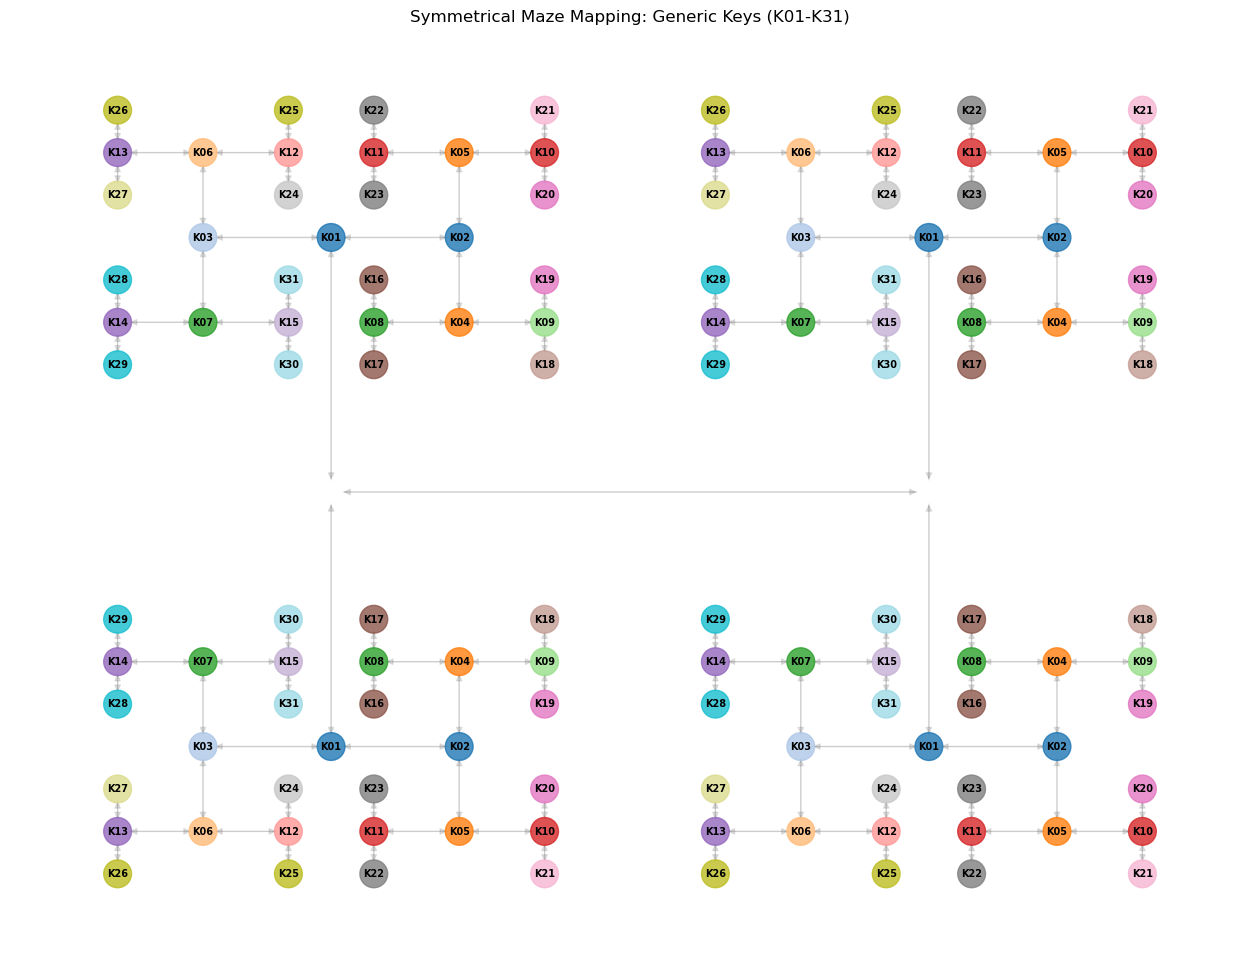

In [592]:
def plot_generic_mapping(G, node_positions, node_to_key):
    plt.figure(figsize=(16, 12))
    ax = plt.gca()
    
    # Draw faint maze skeleton
    nx.draw_networkx_edges(G, node_positions, alpha=0.1, edge_color='black')
    
    # Filter for nodes that are part of the mapping (the 124 patch nodes)
    mapped_nodes = [n for n in G.nodes() if n in node_to_key]
    
    # Color nodes by their Key index to show the "Tree" progression
    key_indices = [int(node_to_key[n][1:]) for n in mapped_nodes]
    
    scatter = nx.draw_networkx_nodes(G, node_positions, nodelist=mapped_nodes, 
                                     node_color=key_indices, cmap='tab20', 
                                     node_size=400, alpha=0.8)
    
    # Label nodes with their Generic Key (e.g., K05)
    labels = {n: node_to_key[n] for n in mapped_nodes}
    nx.draw_networkx_labels(G, node_positions, labels=labels, font_size=7, font_weight='bold')
    
    plt.title("Symmetrical Maze Mapping: Generic Keys (K01-K31)")
    plt.axis('off')
    plt.show()

plot_generic_mapping(G, node_positions, node_to_key)

In [593]:
def create_valid_global_reflection_maps(key_to_nodes):
    # Perspectives: 0:Red(L10), 1:Blue(L11), 2:Green(R10), 3:Orange(R11)
    reflection_maps = []
    
    # Define how the "Roots" of the maze swap globally for each perspective
    # We must ensure L0 and R0 swap when we move from L-side to R-side
    for i in range(4):
        # Initial patch-to-patch relationship logic
        if i == 0:   # Red (L10) -> Identity
            rel = {0:0, 1:1, 2:2, 3:3}; center_map = {'L0': 'L0', 'R0': 'R0'}
        elif i == 1: # Blue (L11) -> Vertical Flip
            rel = {1:0, 0:1, 3:2, 2:3}; center_map = {'L0': 'L0', 'R0': 'R0'}
        elif i == 2: # Green (R10) -> Horizontal Flip
            rel = {2:0, 3:1, 0:2, 1:3}; center_map = {'L0': 'R0', 'R0': 'L0'}
        elif i == 3: # Orange (R11) -> Both Flips
            rel = {3:0, 2:1, 1:2, 0:3}; center_map = {'L0': 'R0', 'R0': 'L0'}
            
        full_mapping = center_map.copy()
        
        # Map the 124 patch nodes using the functional 'rel' indices
        for key, nodes in key_to_nodes.items():
            for orig_idx, target_idx in rel.items():
                full_mapping[nodes[orig_idx]] = nodes[target_idx]
                
        reflection_maps.append(full_mapping)
        
    return reflection_maps

# Regenerate maps
valid_reflection_maps = create_valid_global_reflection_maps(key_to_nodes)

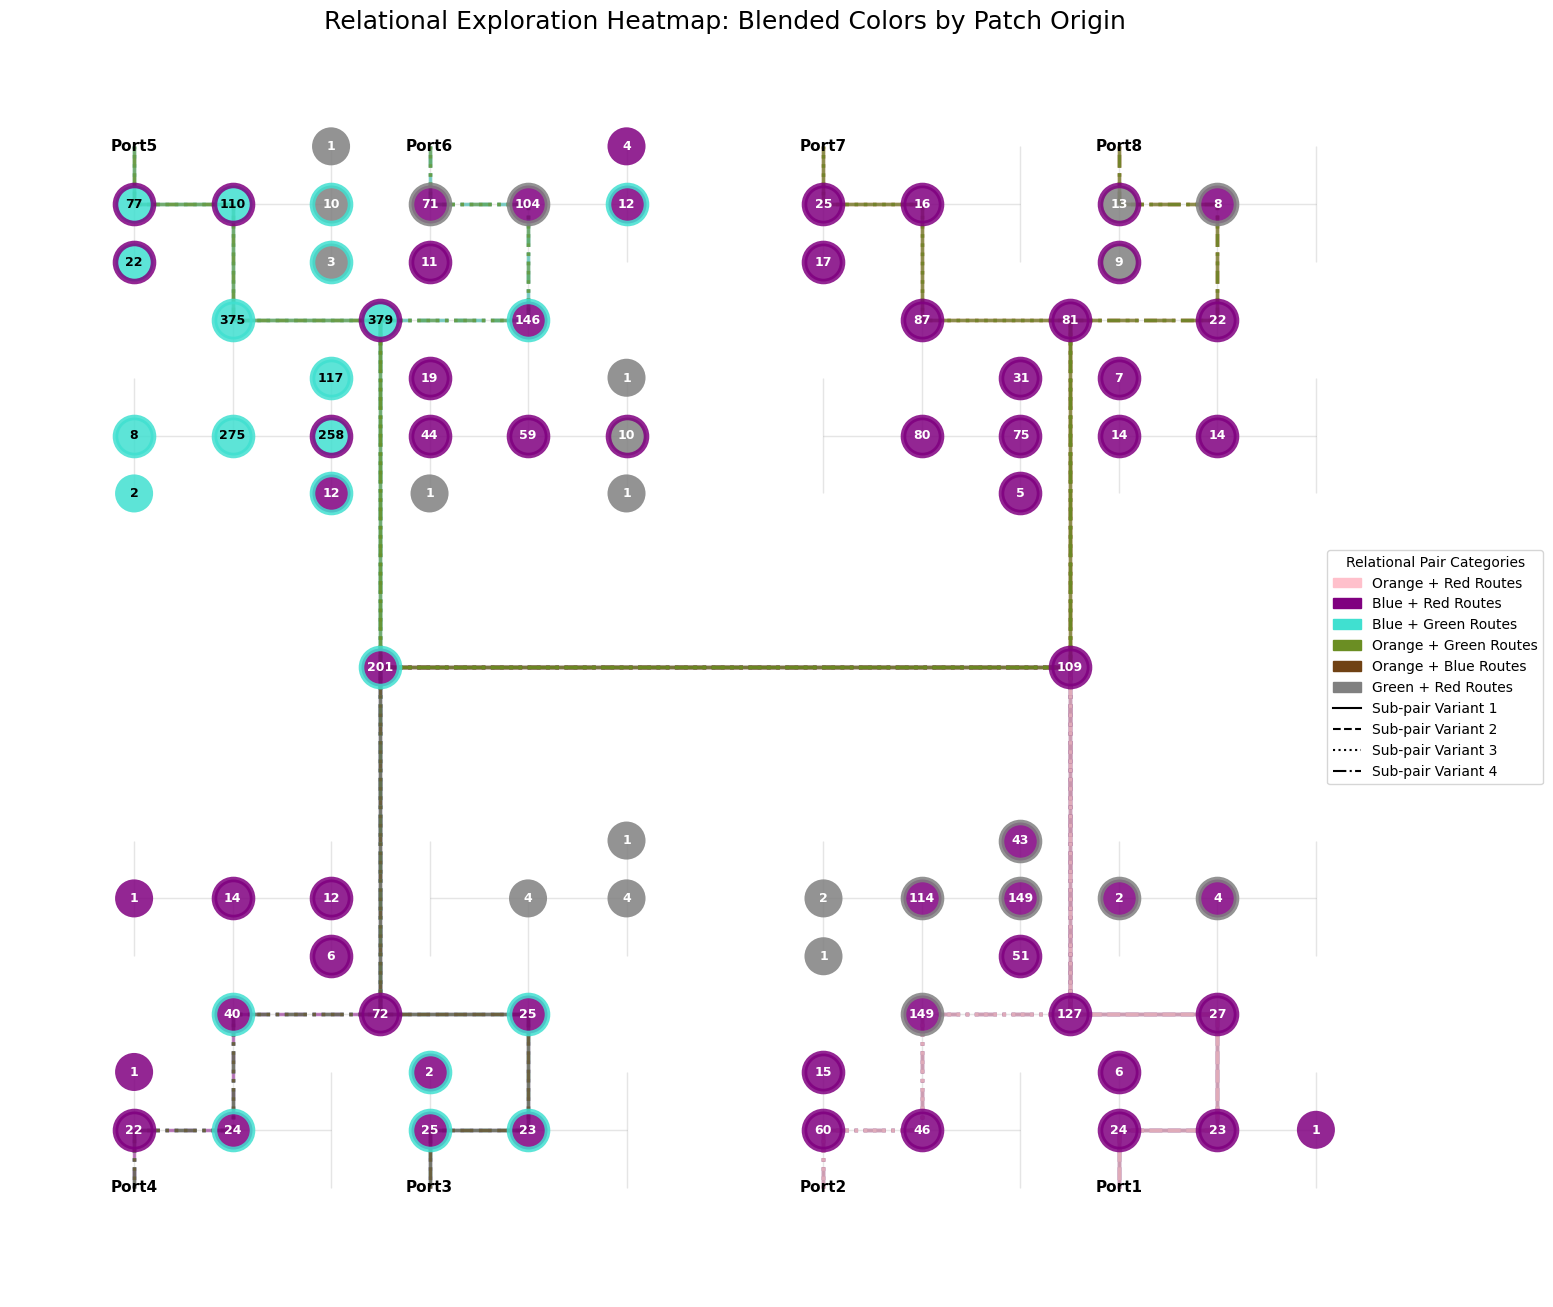

In [594]:
import networkx as nx
import matplotlib.pyplot as plt
from collections import Counter
import matplotlib.patches as mpatches

def plot_relational_heatmap(G, node_positions, df_clean, remaining_pairs, port_map):
    # 1. Define Group Mapping
    group_map = {
        'Port1': 'Red', 'Port2': 'Red',
        'Port3': 'Blue', 'Port4': 'Blue',
        'Port5': 'Green', 'Port6': 'Green',
        'Port7': 'Orange', 'Port8': 'Orange'
    }

    # Define the Blend Logic
    blend_colors = {
        frozenset(['Red', 'Orange']): 'pink',
        frozenset(['Blue', 'Red']): 'purple',
        frozenset(['Blue', 'Green']): 'turquoise',
        frozenset(['Green', 'Orange']): '#6b8e23', # Greenish brown (OliveDrab)
        frozenset(['Orange', 'Blue']): '#704214', # Mud brown (Sepia)
        frozenset(['Green', 'Red']): 'gray'
    }

    # 2. Assign Color and Linestyle to each remaining pair
    pair_styles = {}
    category_counts = Counter()
    linestyles = ['-', '--', ':', '-.']

    for a, b in remaining_pairs:
        p_a, p_b = port_map[a], port_map[b]
        g_a, g_b = group_map[p_a], group_map[p_b]
        
        pair_key = f"{p_a}-{p_b}"
        category = frozenset([g_a, g_b])
        color = blend_colors.get(category, 'lightgray')
        
        # Assign linestyle based on how many pairs are already in this color category
        style_idx = category_counts[category] % len(linestyles)
        pair_styles[pair_key] = {'color': color, 'linestyle': linestyles[style_idx]}
        category_counts[category] += 1

    # 3. Calculate Paths and Errors (Same logic as before)
    pair_direct_edges = {}
    pair_error_counts = {f"{port_map[a]}-{port_map[b]}": Counter() for a, b in remaining_pairs}
    port_visits = df_clean[df_clean['is_port_node'] == True].copy()
    indices = port_visits.index.tolist()

    for a, b in remaining_pairs:
        p_key = f"{port_map[a]}-{port_map[b]}"
        try:
            path = nx.shortest_path(G, a, b)
            pair_direct_edges[p_key] = [tuple(sorted((path[i], path[i+1]))) for i in range(len(path)-1)]
        except: pair_direct_edges[p_key] = []

    for i in range(1, len(indices)):
        p1, p2 = port_visits.iloc[i-1]['node_name'], port_visits.iloc[i]['node_name']
        for a, b in remaining_pairs:
            if {p1, p2} == {a, b}:
                p_key = f"{port_map[a]}-{port_map[b]}"
                path_nodes = df_clean.loc[indices[i-1]:indices[i], 'node_name'].tolist()
                if len(path_nodes) > 8:
                    pair_error_counts[p_key].update(path_nodes[1:-1])

    # 4. Plotting
    fig = plt.figure(figsize=(22, 14))
    ax = fig.add_axes([0.05, 0.05, 0.65, 0.9])
    nx.draw_networkx_edges(G, node_positions, ax=ax, alpha=0.05, edge_color='black', arrows=False)

    # Draw Backbones with Relational Colors and Line Styles
    for p_key, edges in pair_direct_edges.items():
        style = pair_styles[p_key]
        nx.draw_networkx_edges(G, node_positions, edgelist=edges, 
                               edge_color=style['color'], width=2.5, 
                               style=style['linestyle'], alpha=0.5, ax=ax, arrows=False)

    # Draw Nodes (Multi-pair logic using the new relational colors)
    all_error_nodes = set().union(*(c.keys() for c in pair_error_counts.values()))
    for node in all_error_nodes:
        node_stats = {pk: pair_error_counts[pk][node] for pk in pair_error_counts if node in pair_error_counts[pk]}
        top_pairs = sorted(node_stats.keys(), key=lambda x: node_stats[x], reverse=True)
        total = sum(node_stats.values())
        
        f_color = pair_styles[top_pairs[0]]['color']
        e_color = pair_styles[top_pairs[1]]['color'] if len(top_pairs) > 1 else 'none'
        t_color = 'white' if f_color not in ['pink', 'turquoise'] else 'black'

        nx.draw_networkx_nodes(G, node_positions, nodelist=[node], node_color=f_color,
                               edgecolors=e_color, linewidths=4 if e_color != 'none' else 0,
                               node_size=750, alpha=0.85, ax=ax)
        nx.draw_networkx_labels(G, node_positions, labels={node: str(total)}, 
                                font_size=9, font_color=t_color, font_weight='bold', ax=ax)

    # 5. Legend Construction
    legend_elements = []
    for cat, color in blend_colors.items():
        names = list(cat)
        legend_elements.append(mpatches.Patch(color=color, label=f"{names[0]} + {names[1]} Routes"))

    # Port Labels
    port_labels = {k: v for k, v in port_map.items()}
    nx.draw_networkx_labels(G, node_positions, labels=port_labels, font_size=11, font_weight='bold', ax=ax)
    
    # Add linestyle guide
    from matplotlib.lines import Line2D
    for i, style in enumerate(linestyles):
        legend_elements.append(Line2D([0], [0], color='black', linestyle=style, label=f"Sub-pair Variant {i+1}"))

    fig.legend(handles=legend_elements, loc='center right', title="Relational Pair Categories", 
               ncol=1, fontsize=10, bbox_to_anchor=(0.75, 0.5))

    ax.set_title("Relational Exploration Heatmap: Blended Colors by Patch Origin", fontsize=18)
    ax.axis('off')
    plt.show()

# Run
plot_relational_heatmap(G, node_positions, node_summary_df, remaining_pairs, port_map)

In [595]:
# Patch Definitions (0: Red, 1: Blue, 2: Green, 3: Orange)
patch_ports = {
    0: {'Easy': 'Port4', 'Hard': 'Port3'}, # Red
    1: {'Easy': 'Port2', 'Hard': 'Port1'}, # Blue (Across from Red)
    2: {'Easy': 'Port7', 'Hard': 'Port8'}, # Green (Diagonal from Red)
    3: {'Easy': 'Port5', 'Hard': 'Port6'}  # Orange (Nearest to Red)
}

# Relationship Look-up (Source_Patch_Index -> Target_Patch_Index)
# Based on your definition: Across is Blue(1), Diagonal is Green(2), Nearest is Orange(3)
rel_matrix = {
    (0,0): 'Self', (1,1): 'Self', (2,2): 'Self', (3,3): 'Self',
    (0,1): 'Across', (1,0): 'Across', (2,3): 'Across', (3,2): 'Across',
    (0,2): 'Diagonal', (2,0): 'Diagonal', (1,3): 'Diagonal', (3,1): 'Diagonal',
    (0,3): 'Nearest', (3,0): 'Nearest', (1,2): 'Nearest', (2,1): 'Nearest'
}

# Helper to find Port Metadata
port_meta = {}
for p_idx, roles in patch_ports.items():
    for role, p_name in roles.items():
        port_meta[p_name] = {'patch': p_idx, 'role': role}

In [596]:
from itertools import groupby
import pandas as pd

def analyze_functional_paths(G, df_clean, port_meta, rel_matrix):
    port_visits = df_clean[df_clean['is_port_node'] == True].copy()
    indices = port_visits.index.tolist()
    
    # Storage for the full list of transitions
    all_transitions_list = []

    for i in range(1, len(indices)):
        src_node = port_visits.iloc[i-1]['node_name']
        dest_node = port_visits.iloc[i]['node_name']
        
        src_label = port_map.get(src_node)
        dest_label = port_map.get(dest_node)
        
        if src_label in port_meta and dest_label in port_meta:
            # Get Metadata
            src_info = port_meta[src_label]
            dest_info = port_meta[dest_label]
            
            # Determine Relationship and Roles
            relationship = rel_matrix[(src_info['patch'], dest_info['patch'])]
            group_label = f"{src_info['role']} to {relationship} {dest_info['role']}"
            
            # Path Analysis (Deduping + Efficiency)
            raw_path = df_clean.loc[indices[i-1]:indices[i], 'node_name'].tolist()
            deduped_path = [k for k, g in groupby(raw_path)]
            
            # Distance Logic
            # Add tolerance of 2 and 4 nodes to count as direct
            shortest_dist = len(nx.shortest_path(G, src_node, dest_node))
            is_direct = len(deduped_path) <= (shortest_dist)
            is_direct_tol2 = len(deduped_path) <= (shortest_dist) + 2
            is_direct_tol4 = len(deduped_path) <= (shortest_dist) + 4
            
            # Store full data
            all_transitions_list.append({
                'source_port': src_label,
                'dest_port': dest_label,
                'relationship': relationship,
                'group': group_label,
                'is_direct': is_direct,
                'is_direct_tol2': is_direct_tol2,
                'is_direct_tol4': is_direct_tol4,
                'path_nodes': deduped_path
            })

    # Create the Master DataFrame
    df_results = pd.DataFrame(all_transitions_list)
    
    # Generate Summary Statistics
    summary = df_results.groupby('group').agg(
        Total_Paths=('group', 'count'),
        Direct_Paths=('is_direct', lambda x: x.sum()),
        Indirect_Paths=('is_direct', lambda x: (~x).sum()),
        Direct_Paths_Tol2=('is_direct_tol2', lambda x: x.sum()),
        Indirect_Paths_Tol2=('is_direct_tol2', lambda x: (~x).sum()),
        Direct_Paths_Tol4=('is_direct_tol4', lambda x: x.sum()),
        Indirect_Paths_Tol4=('is_direct_tol4', lambda x: (~x).sum())
    ).reset_index()
    
    return df_results, summary

# Run the analysis
df_all_paths, df_summary = analyze_functional_paths(G, node_summary_df, port_meta, rel_matrix)

In [597]:
((node_summary_df['is_port_node'] == True) & (node_summary_df['reward_during_node'] == True)).sum()

np.int64(203)

In [598]:
node_summary_df['reward_during_node'].sum()

np.int64(471)

In [599]:
from itertools import groupby
import pandas as pd
import networkx as nx

def analyze_functional_paths(G, df_clean, port_meta, rel_matrix, only_reward_paths=False):
    port_visits = df_clean[df_clean['is_port_node'] == True].copy()
    if only_reward_paths:
        port_visits = port_visits[port_visits['reward_during_node'] == True]
    indices = port_visits.index.tolist()
    
    # Define levels to be skipped: L4, L5, R4, R5
    leaf_prefixes = ('L4', 'L5', 'R4', 'R5')
    
    all_transitions_list = []

    for i in range(1, len(indices)):
        src_node = port_visits.iloc[i-1]['node_name']
        dest_node = port_visits.iloc[i]['node_name']
        
        src_label = port_map.get(src_node)
        dest_label = port_map.get(dest_node)
        
        if src_label in port_meta and dest_label in port_meta:
            src_info = port_meta[src_label]
            dest_info = port_meta[dest_label]
            
            relationship = rel_matrix[(src_info['patch'], dest_info['patch'])]
            group_label = f"{src_info['role']} to {relationship} {dest_info['role']}"
            
            raw_path = df_clean.loc[indices[i-1]:indices[i], 'node_name'].tolist()
            deduped_path = [k for k, g in groupby(raw_path)]
            
            # 1. Isolate the internal path (exclude start/end port nodes)
            # Internal path starts at node index 1 and ends at -2
            internal_path = deduped_path[1:-1]
            
            if len(internal_path) >= 1:
                # The anchors are the first and last L4/R4 nodes visited
                core_start_node = internal_path[0]
                core_end_node = internal_path[-1]
                
                # Calculate Shortest Path between these two specific L4/R4 nodes
                shortest_core_dist = len(nx.shortest_path(G, core_start_node, core_end_node))
                
                # Count actual core length, skipping L4/R4 <-> L5/R5 transitions
                filtered_core_len = 1 # Starting node
                for j in range(len(internal_path) - 1):
                    n1, n2 = internal_path[j], internal_path[j+1]
                    
                    n1_is_leaf = n1.startswith(leaf_prefixes)
                    n2_is_leaf = n2.startswith(leaf_prefixes)
                    
                    # Transition counts UNLESS it is between two leaf nodes
                    if not (n1_is_leaf and n2_is_leaf):
                        filtered_core_len += 1
                
                is_direct_skip_leaves = filtered_core_len <= shortest_core_dist
            else:
                # This covers paths where ports are adjacent (Port1 to Port2 in same patch)
                filtered_core_len = 0
                shortest_core_dist = 0
                is_direct_skip_leaves = True
            
            # Distance Logic
            shortest_path = nx.shortest_path(G, src_node, dest_node)
            shortest_dist = len(shortest_path)
            actual_len = len(deduped_path)
            
            # Store results
            all_transitions_list.append({
                'source_port': src_label,
                'dest_port': dest_label,
                'relationship': relationship,
                'group': group_label,
                'actual_length': actual_len,
                'filtered_length': filtered_core_len + 2,
                'shortest_dist': shortest_dist,
                'is_direct': actual_len <= shortest_dist,
                'is_direct_tol2': actual_len <= (shortest_dist + 2),
                'is_direct_tol4': actual_len <= (shortest_dist + 4),
                'is_direct_skip_leaves': is_direct_skip_leaves,
                'path_nodes': deduped_path
            })

    df_results = pd.DataFrame(all_transitions_list)
    
    # Updated Summary Statistics
    summary = df_results.groupby('group').agg(
        Total_Paths=('group', 'count'),
        Direct_Strict=('is_direct', 'sum'),
        Direct_Tol2=('is_direct_tol2', 'sum'),
        Direct_Tol4=('is_direct_tol4', 'sum'),
        Direct_Skip_Leaves=('is_direct_skip_leaves', 'sum'),
        Avg_Actual_Len=('actual_length', 'mean'),
        Avg_Filtered_Len=('filtered_length', 'mean'),
        Avg_Shortest_Dist=('shortest_dist', 'mean')
    ).reset_index()
    
    return df_results, summary

# Run the analysis
df_all_paths, df_summary = analyze_functional_paths(G, node_summary_df, port_meta, rel_matrix)

In [600]:
# all paths in df_all_paths that are not port to same port
all_paths_without_repeat = df_all_paths[df_all_paths['source_port'] != df_all_paths['dest_port']]
# all_paths_without_repeat.groupby('is_direct').count()
all_paths_without_repeat

,source_port,dest_port,relationship,group,actual_length,filtered_length,shortest_dist,is_direct,is_direct_tol2,is_direct_tol4,is_direct_skip_leaves,path_nodes
0,Port6,Port2,Diagonal,Hard to Diagonal Easy,34,30,12,False,False,False,False,"[L525, L412, L36, L412, L36, L412, L36, L412, ..."
1,Port2,Port4,Across,Easy to Across Easy,122,92,12,False,False,False,False,"[R526, R413, R36, R413, R527, R413, R36, R23, ..."
2,Port4,Port2,Across,Easy to Across Easy,22,18,12,False,False,False,False,"[L510, L45, L32, L21, L10, L0, R0, R11, R23, R..."
3,Port2,Port1,Self,Easy to Self Hard,99,79,9,False,False,False,False,"[R526, R413, R527, R413, R36, R23, R11, R23, R..."
4,Port1,Port2,Self,Hard to Self Easy,31,31,9,False,False,False,False,"[R522, R411, R35, R22, R35, R22, R11, R22, R34..."
...,...,...,...,...,...,...,...,...,...,...,...,...
341,Port4,Port6,Nearest,Easy to Nearest Hard,61,57,11,False,False,False,False,"[L510, L45, L32, L21, L10, L0, L11, L22, L34, ..."
344,Port6,Port5,Self,Hard to Self Easy,49,41,9,False,False,False,False,"[L525, L412, L36, L23, L11, L23, L11, L0, L11,..."
345,Port5,Port2,Diagonal,Easy to Diagonal Easy,48,40,12,False,False,False,False,"[L521, L410, L35, L22, L11, L0, L11, L23, L36,..."
347,Port2,Port1,Self,Easy to Self Hard,11,9,9,False,True,True,True,"[R526, R413, R527, R413, R36, R23, R11, R22, R..."


In [601]:
df_summary

,group,Total_Paths,Direct_Strict,Direct_Tol2,Direct_Tol4,Direct_Skip_Leaves,Avg_Actual_Len,Avg_Filtered_Len,Avg_Shortest_Dist
0,Easy to Across Easy,12,0,0,0,0,87.833333,70.000000,12.0
1,Easy to Across Hard,8,0,0,0,0,65.000000,52.750000,12.0
2,Easy to Diagonal Easy,4,0,0,0,0,72.500000,56.000000,12.0
3,Easy to Diagonal Hard,5,0,0,0,0,75.800000,61.600000,12.0
4,Easy to Nearest Hard,3,0,0,0,0,66.333333,58.333333,11.0
5,Easy to Self Easy,50,0,21,22,22,57.080000,43.800000,1.0
6,Easy to Self Hard,88,47,62,77,53,17.363636,15.250000,9.0
7,Hard to Across Easy,5,0,0,0,0,56.400000,46.800000,12.0
8,Hard to Across Hard,5,0,0,0,0,75.000000,59.600000,12.0
9,Hard to Diagonal Easy,3,0,0,0,0,31.333333,26.666667,12.0


In [602]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Use the cleaned data without repeats
df = all_paths_without_repeat.copy()
df['src_role'] = df['group'].apply(lambda x: x.split(' to ')[0])
df['dest_role'] = df['group'].apply(lambda x: x.split(' ')[-1])
df['role_trans'] = df['src_role'] + " to " + df['dest_role']

# Filter out the Identical-Role Self-Moves
plot_df = df[~df['group'].isin(['Easy to Self Easy', 'Hard to Self Hard'])].copy()

def get_tol_stats(data, column):
    stats = data.groupby(column).agg(
        total=('is_direct', 'count'),
        direct=('is_direct', 'sum'),
        tol2=('is_direct_tol2', 'sum'),
        tol4=('is_direct_tol4', 'sum')
    ).reset_index()
    print(f"\n--- Statistics by {column} ---")
    print(stats)
    # Calculate percentages for layering
    stats['strict_pct'] = (stats['direct'] / stats['total']) * 100
    stats['tol2_extra_pct'] = ((stats['tol2'] - stats['direct']) / stats['total']) * 100
    stats['tol4_extra_pct'] = ((stats['tol4'] - stats['tol2']) / stats['total']) * 100
    stats['indirect_pct'] = 100 - (stats['tol4'] / stats['total']) * 100
    return stats

detailed_stats = get_tol_stats(plot_df, 'group')
role_stats = get_tol_stats(plot_df, 'role_trans')
spatial_stats = get_tol_stats(plot_df, 'relationship')


--- Statistics by group ---
                    group  total  direct  tol2  tol4
0     Easy to Across Easy     12       0     0     0
1     Easy to Across Hard      8       0     0     0
2   Easy to Diagonal Easy      4       0     0     0
3   Easy to Diagonal Hard      5       0     0     0
4    Easy to Nearest Hard      3       0     0     0
5       Easy to Self Hard     88      47    62    77
6     Hard to Across Easy      5       0     0     0
7     Hard to Across Hard      5       0     0     0
8   Hard to Diagonal Easy      3       0     0     0
9   Hard to Diagonal Hard      3       0     0     0
10   Hard to Nearest Easy      3       0     0     0
11   Hard to Nearest Hard      6       0     0     0
12      Hard to Self Easy     94      54    72    82

--- Statistics by role_trans ---
     role_trans  total  direct  tol2  tol4
0  Easy to Easy     16       0     0     0
1  Easy to Hard    104      47    62    77
2  Hard to Easy    105      54    72    82
3  Hard to Hard     14 

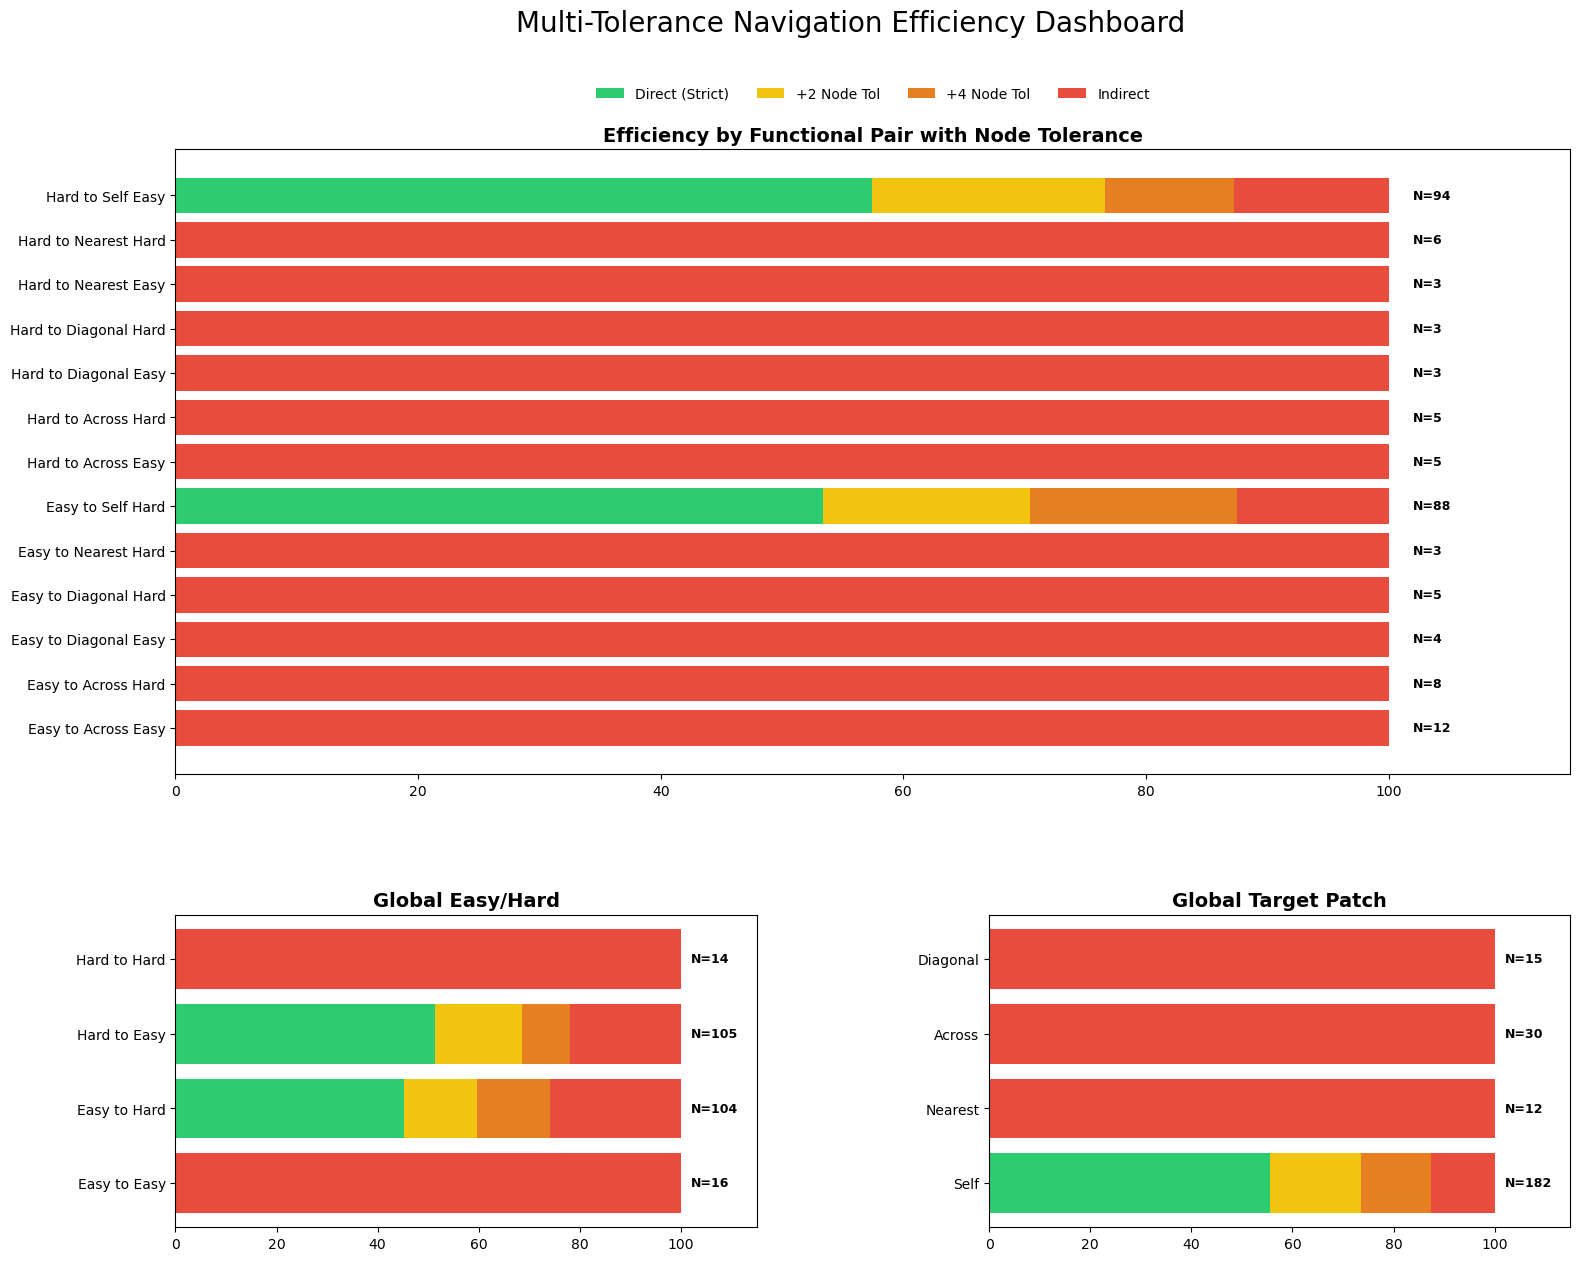

In [603]:
fig = plt.figure(figsize=(18, 14))
gs = fig.add_gridspec(2, 2, height_ratios=[2, 1], hspace=0.3, wspace=0.4)

def draw_layered_bars(ax, stats, label_col, title):
    y_pos = np.arange(len(stats))
    
    # Layer 1: Strict Direct (Green)
    ax.barh(y_pos, stats['strict_pct'], color='#2ecc71', label='Direct (Strict)')
    
    # Layer 2: Tol 2 Extra (Yellow)
    ax.barh(y_pos, stats['tol2_extra_pct'], left=stats['strict_pct'], 
            color='#f1c40f', label='+2 Node Tol')
    
    # Layer 3: Tol 4 Extra (Orange)
    ax.barh(y_pos, stats['tol4_extra_pct'], left=stats['strict_pct'] + stats['tol2_extra_pct'], 
            color='#e67e22', label='+4 Node Tol')
    
    # Layer 4: Remaining Indirect (Red)
    ax.barh(y_pos, stats['indirect_pct'], left=stats['strict_pct'] + stats['tol2_extra_pct'] + stats['tol4_extra_pct'], 
            color='#e74c3c', label='Indirect')

    # N counts
    for i, total in enumerate(stats['total']):
        ax.text(102, i, f"N={total}", va='center', fontsize=9, fontweight='bold')

    ax.set_yticks(y_pos)
    ax.set_yticklabels(stats[label_col])
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlim(0, 115)

# Panel 1: Detailed
ax1 = fig.add_subplot(gs[0, :])
draw_layered_bars(ax1, detailed_stats, 'group', 'Efficiency by Functional Pair with Node Tolerance')
ax1.legend(loc='upper center', bbox_to_anchor=(0.5, 1.12), ncol=4, frameon=False)

# Panel 2: Role Switch
ax2 = fig.add_subplot(gs[1, 0])
draw_layered_bars(ax2, role_stats, 'role_trans', 'Global Easy/Hard')

# Panel 3: Spatial
ax3 = fig.add_subplot(gs[1, 1])
spatial_stats['rel_order'] = spatial_stats['relationship'].map({'Self':0, 'Nearest':1, 'Across':2, 'Diagonal':3})
spatial_stats = spatial_stats.sort_values('rel_order')
draw_layered_bars(ax3, spatial_stats, 'relationship', 'Global Target Patch')

plt.suptitle("Multi-Tolerance Navigation Efficiency Dashboard", fontsize=20, y=0.98)
plt.show()

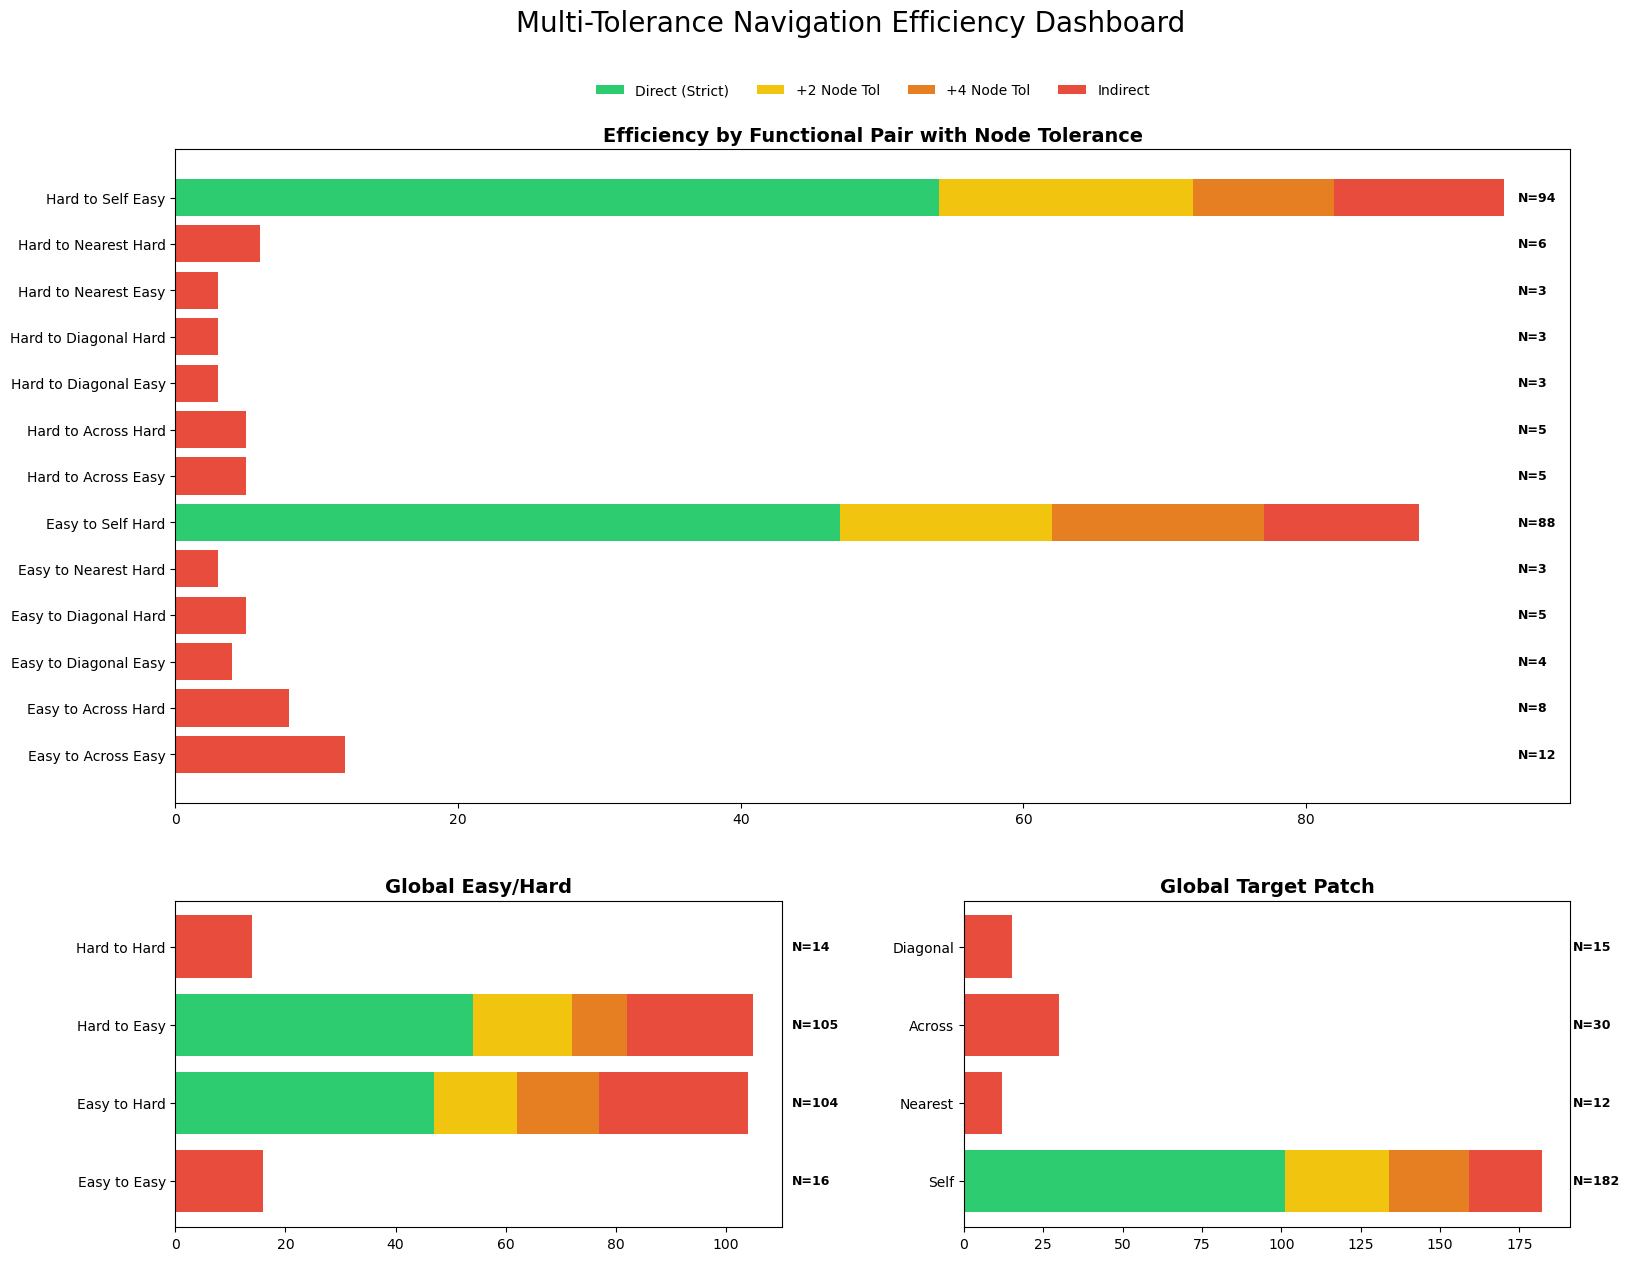

In [604]:
fig = plt.figure(figsize=(18, 14))
gs = fig.add_gridspec(2, 2, height_ratios=[2, 1], hspace=0.2, wspace=0.3)

def draw_layered_bars(ax, stats, label_col, title, N_offset=1):
    y_pos = np.arange(len(stats))
    
    # Layer 1: Strict Direct (Green)
    ax.barh(y_pos, stats['direct'], color='#2ecc71', label='Direct (Strict)')
    
    # Layer 2: Tol 2 Extra (Yellow)
    ax.barh(y_pos, (stats['tol2'] - stats['direct']), left=stats['direct'], 
            color='#f1c40f', label='+2 Node Tol')
    
    # Layer 3: Tol 4 Extra (Orange)
    ax.barh(y_pos, (stats['tol4'] - stats['tol2']), left=stats['tol2'], 
            color='#e67e22', label='+4 Node Tol')
    
    # Layer 4: Remaining Indirect (Red)
    ax.barh(y_pos, (stats['total'] - stats['tol4']), left=stats['tol4'], 
            color='#e74c3c', label='Indirect')

    # N counts
    for i, total in enumerate(stats['total']):
        ax.text(stats['total'].max() + N_offset, i, f"N={total}", va='center', fontsize=9, fontweight='bold')

    ax.set_yticks(y_pos)
    ax.set_yticklabels(stats[label_col])
    ax.set_title(title, fontsize=14, fontweight='bold')

# Panel 1: Detailed
ax1 = fig.add_subplot(gs[0, :])
draw_layered_bars(ax1, detailed_stats, 'group', 'Efficiency by Functional Pair with Node Tolerance')
ax1.legend(loc='upper center', bbox_to_anchor=(0.5, 1.12), ncol=4, frameon=False)

# Panel 2: Role Switch
ax2 = fig.add_subplot(gs[1, 0])
draw_layered_bars(ax2, role_stats, 'role_trans', 'Global Easy/Hard', N_offset = 7)

# Panel 3: Spatial
ax3 = fig.add_subplot(gs[1, 1])
spatial_stats['rel_order'] = spatial_stats['relationship'].map({'Self':0, 'Nearest':1, 'Across':2, 'Diagonal':3})
spatial_stats = spatial_stats.sort_values('rel_order')
draw_layered_bars(ax3, spatial_stats, 'relationship', 'Global Target Patch', N_offset = 10)

plt.suptitle("Multi-Tolerance Navigation Efficiency Dashboard", fontsize=20, y=0.98)
plt.show()

In [605]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# --- Data Preparation ---
# Use the cleaned data without repeats
df = all_paths_without_repeat.copy()
df['src_role'] = df['group'].apply(lambda x: x.split(' to ')[0])
df['dest_role'] = df['group'].apply(lambda x: x.split(' ')[-1])
df['role_trans'] = df['src_role'] + " to " + df['dest_role']

# Filter out the Identical-Role Self-Moves (Easy->Easy Self, Hard->Hard Self)
plot_df = df[~df['group'].isin(['Easy to Self Easy', 'Hard to Self Hard'])].copy()

def get_skip_leaves_stats(data, column):
    # Aggregate raw counts
    stats = data.groupby(column).agg(
        total=('is_direct', 'count'),
        direct=('is_direct', 'sum'),
        skip_leaves=('is_direct_skip_leaves', 'sum')
    ).reset_index()
    
    # Calculate percentages for non-overlapping layers
    # Segment 1: Physical perfection
    stats['strict_pct'] = (stats['direct'] / stats['total']) * 100
    
    # Segment 2: The 'Extra' paths caught only by skip_leaves logic
    stats['skip_extra_pct'] = ((stats['skip_leaves'] - stats['direct']) / stats['total'] * 100).clip(lower=0)
    
    # Segment 3: Paths that are still indirect (The failure rate)
    stats['indirect_pct'] = (100 - (stats['skip_leaves'] / stats['total'] * 100)).clip(lower=0)
    
    return stats

# Generate the three data levels
detailed_stats_leaves = get_skip_leaves_stats(plot_df, 'group')
role_stats_leaves = get_skip_leaves_stats(plot_df, 'role_trans')
spatial_stats_leaves = get_skip_leaves_stats(plot_df, 'relationship')

/tmp/ipykernel_28444/2197726057.py:50: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])


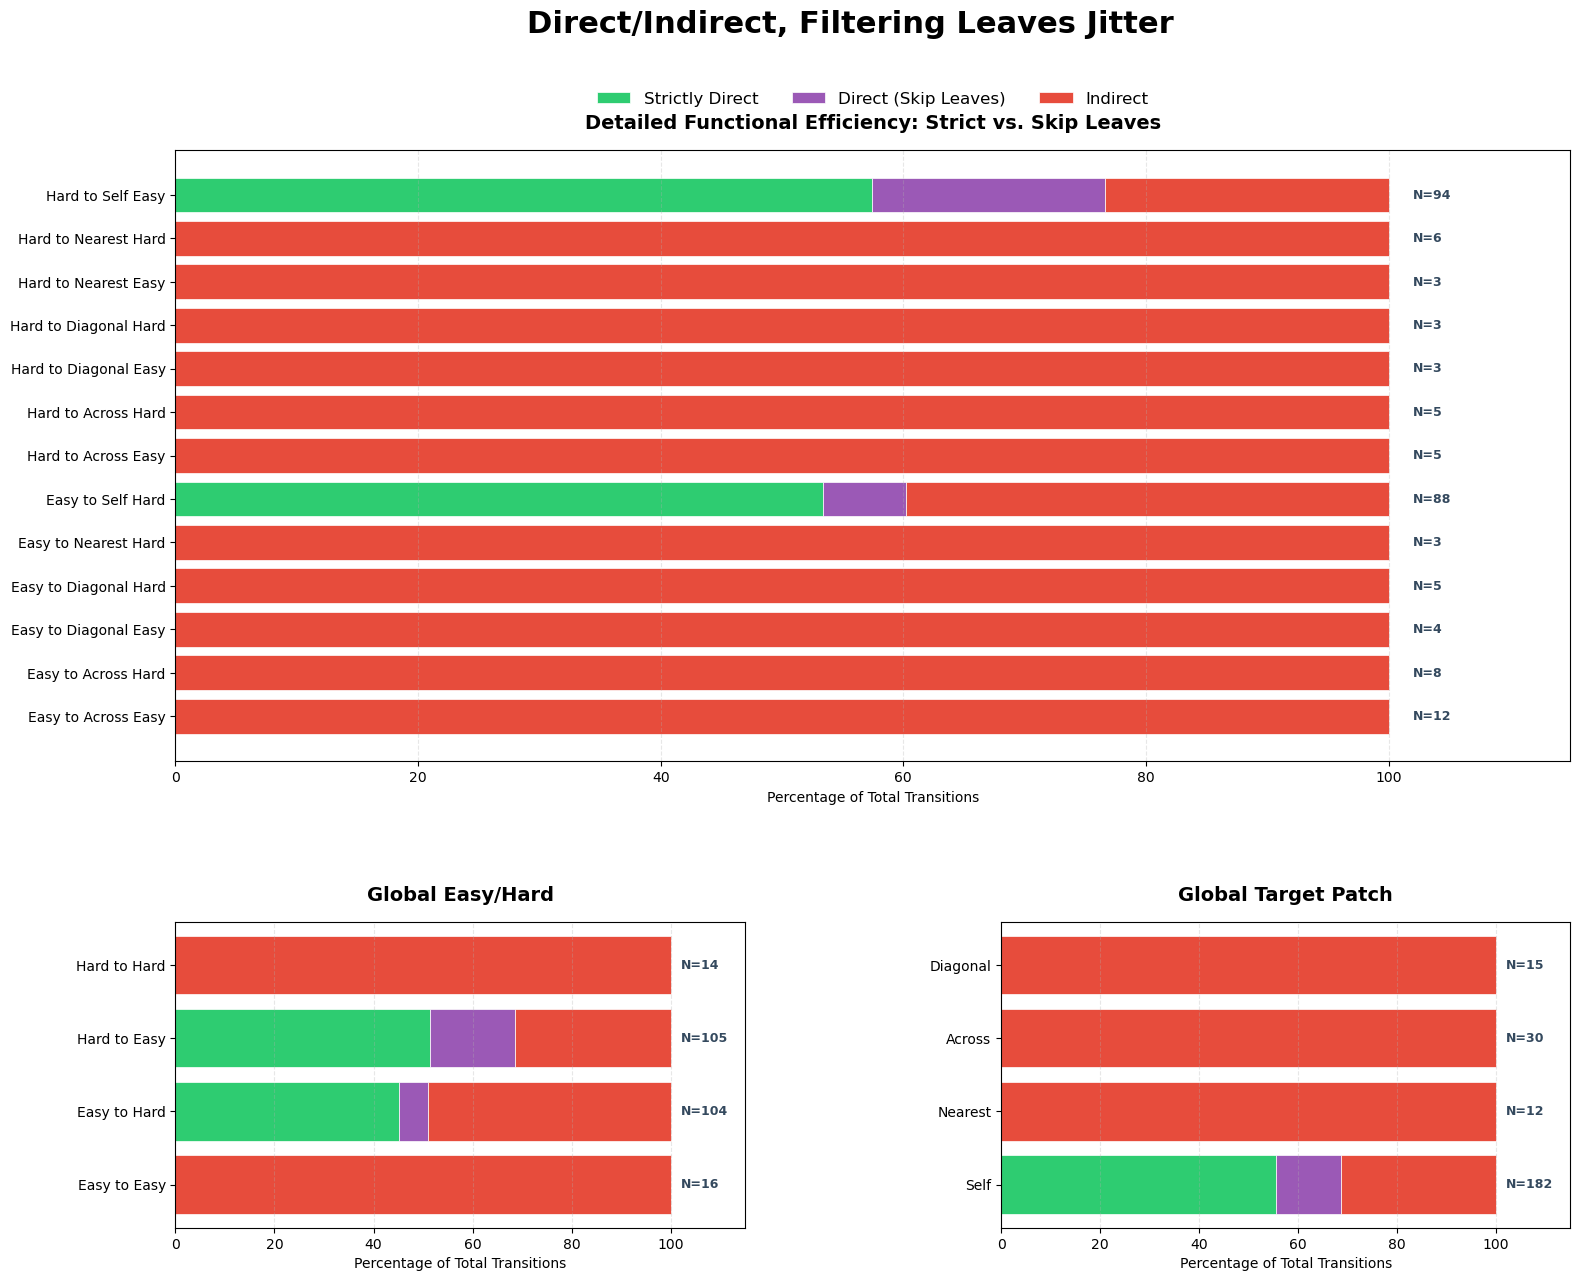

In [606]:
def draw_skip_leaves_bars(ax, stats, label_col, title):
    y_pos = np.arange(len(stats))
    
    # Layer 1: Strict Direct (Green)
    ax.barh(y_pos, stats['strict_pct'], color='#2ecc71', 
            label='Strictly Direct', edgecolor='white', linewidth=0.5)
    
    # Layer 2: Skip Leaves Gain (Purple/Amethyst)
    # Represents paths that are globally direct but locally noisy at leaves
    ax.barh(y_pos, stats['skip_extra_pct'], left=stats['strict_pct'], 
            color='#9b59b6', label='Direct (Skip Leaves)', edgecolor='white', linewidth=0.5)
    
    # Layer 3: True Indirect (Red/Alizarin)
    # Represents actual navigational errors in the maze core (Levels 1, 2, 3)
    ax.barh(y_pos, stats['indirect_pct'], left=stats['strict_pct'] + stats['skip_extra_pct'], 
            color='#e74c3c', label='Indirect', edgecolor='white', linewidth=0.5)

    # N counts on the right side
    for i, total in enumerate(stats['total']):
        ax.text(102, i, f"N={total}", va='center', fontsize=9, fontweight='bold', color='#34495e')

    ax.set_yticks(y_pos)
    ax.set_yticklabels(stats[label_col], fontsize=10)
    ax.set_title(title, fontsize=14, fontweight='bold', pad=15)
    ax.set_xlim(0, 115)
    ax.set_xlabel('Percentage of Total Transitions')
    ax.grid(axis='x', linestyle='--', alpha=0.3)

# --- Execute Plotting ---
fig = plt.figure(figsize=(18, 14))
gs = fig.add_gridspec(2, 2, height_ratios=[2, 1], hspace=0.35, wspace=0.45)

# Panel 1: Detailed (Full Width Top)
ax1 = fig.add_subplot(gs[0, :])
draw_skip_leaves_bars(ax1, detailed_stats_leaves, 'group', 'Detailed Functional Efficiency: Strict vs. Skip Leaves')
ax1.legend(loc='upper center', bbox_to_anchor=(0.5, 1.12), ncol=3, frameon=False, fontsize=12)

# Panel 2: Role Switch (Bottom Left)
ax2 = fig.add_subplot(gs[1, 0])
draw_skip_leaves_bars(ax2, role_stats_leaves, 'role_trans', 'Global Easy/Hard')

# Panel 3: Spatial (Bottom Right)
ax3 = fig.add_subplot(gs[1, 1])
# Sort spatially: Self -> Near -> Across -> Diag
spatial_stats_leaves['rel_order'] = spatial_stats_leaves['relationship'].map({'Self':0, 'Nearest':1, 'Across':2, 'Diagonal':3})
spatial_stats_leaves = spatial_stats_leaves.sort_values('rel_order')
draw_skip_leaves_bars(ax3, spatial_stats_leaves, 'relationship', 'Global Target Patch')

plt.suptitle("Direct/Indirect, Filtering Leaves Jitter", fontsize=22, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

/tmp/ipykernel_28444/2289670780.py:48: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])


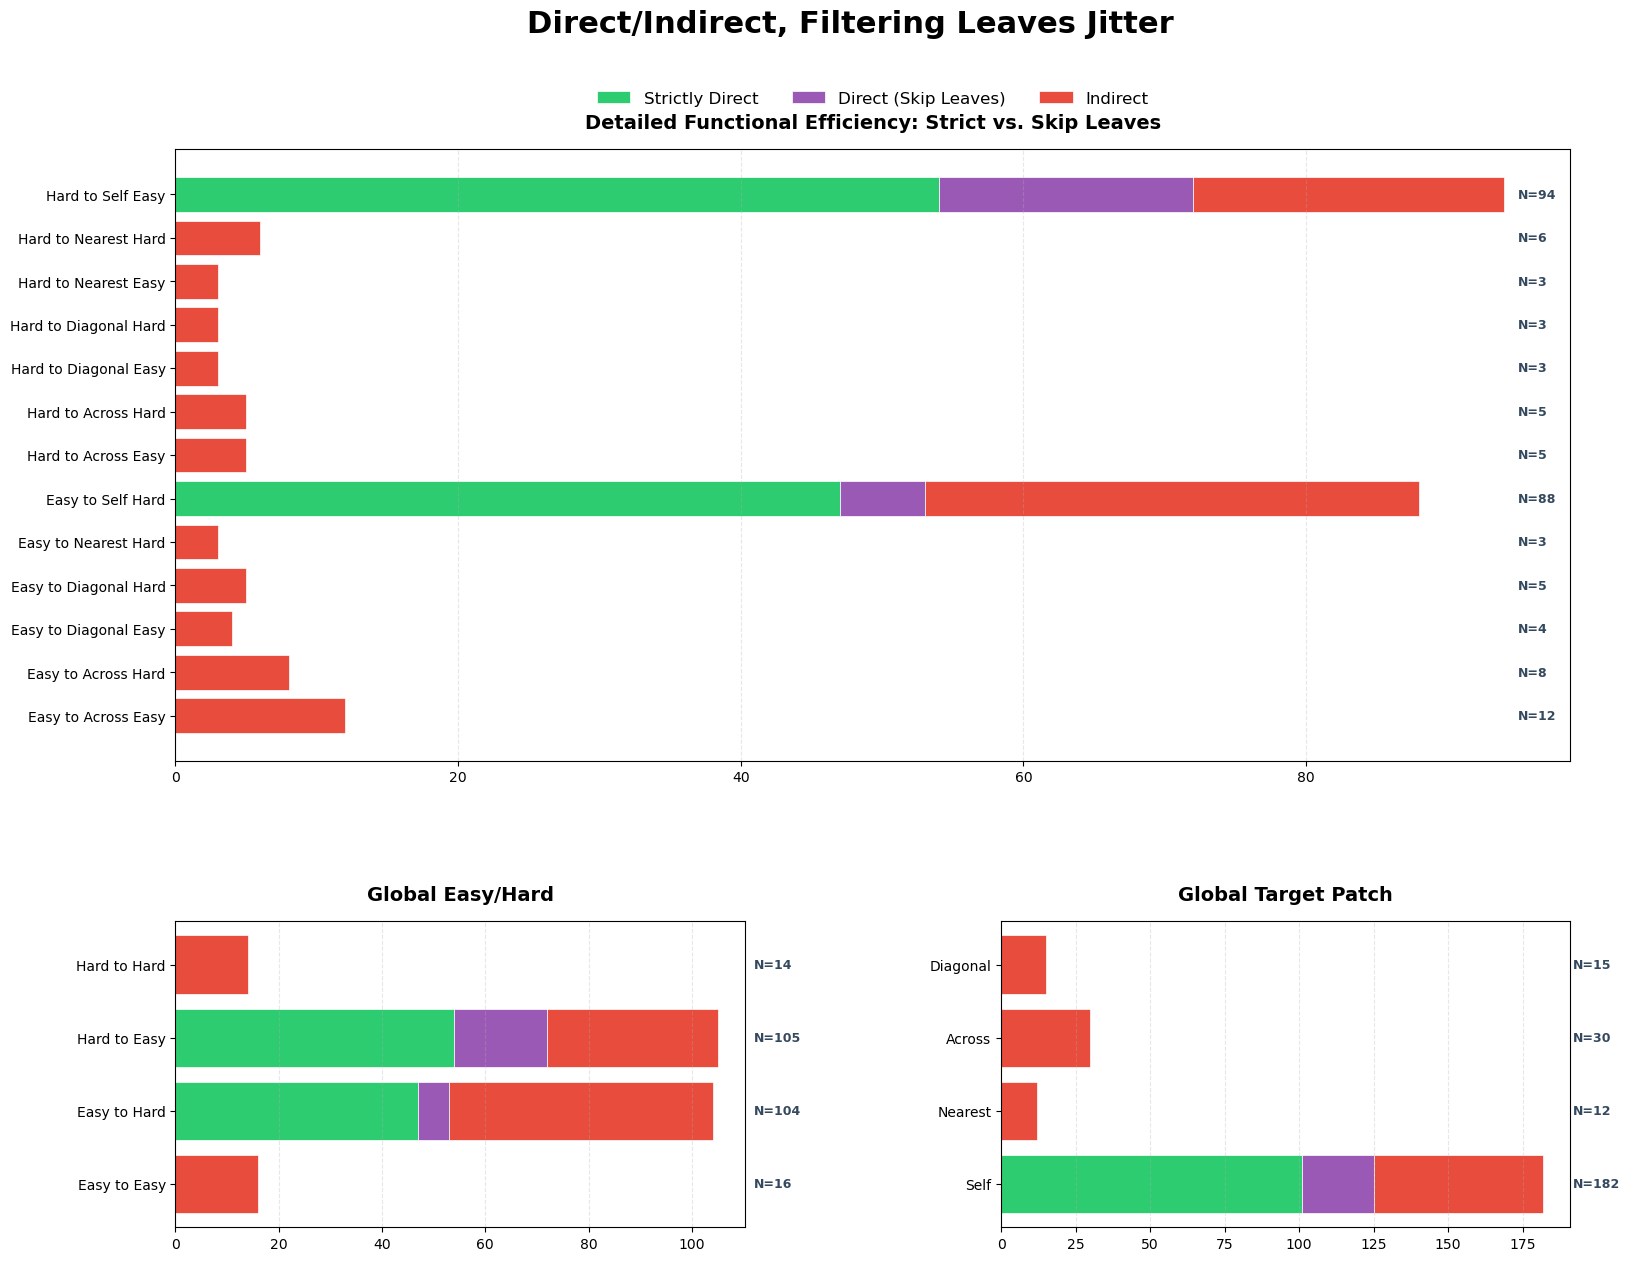

In [607]:
def draw_skip_leaves_bars_abs(ax, stats, label_col, title, N_offset=1):
    y_pos = np.arange(len(stats))
    
    # Layer 1: Strict Direct (Green)
    ax.barh(y_pos, stats['direct'], color='#2ecc71', 
            label='Strictly Direct', edgecolor='white', linewidth=0.5)
    
    # Layer 2: Skip Leaves Gain (Purple/Amethyst)
    # Represents paths that are globally direct but locally noisy at leaves
    ax.barh(y_pos, stats['skip_leaves'] - stats['direct'], left=stats['direct'], 
            color='#9b59b6', label='Direct (Skip Leaves)', edgecolor='white', linewidth=0.5)
    
    # Layer 3: True Indirect (Red/Alizarin)
    # Represents actual navigational errors in the maze core (Levels 1, 2, 3)
    ax.barh(y_pos, stats['total'] - stats['skip_leaves'], left=stats['skip_leaves'], 
            color='#e74c3c', label='Indirect', edgecolor='white', linewidth=0.5)

    # N counts on the right side
    for i, total in enumerate(stats['total']):
        ax.text(stats['total'].max() + N_offset, i, f"N={total}", va='center', fontsize=9, fontweight='bold', color='#34495e')

    ax.set_yticks(y_pos)
    ax.set_yticklabels(stats[label_col], fontsize=10)
    ax.set_title(title, fontsize=14, fontweight='bold', pad=15)
    ax.grid(axis='x', linestyle='--', alpha=0.3)

# --- Execute Plotting ---
fig = plt.figure(figsize=(18, 14))
gs = fig.add_gridspec(2, 2, height_ratios=[2, 1], hspace=0.35, wspace=0.45)

# Panel 1: Detailed (Full Width Top)
ax1 = fig.add_subplot(gs[0, :])
draw_skip_leaves_bars_abs(ax1, detailed_stats_leaves, 'group', 'Detailed Functional Efficiency: Strict vs. Skip Leaves')
ax1.legend(loc='upper center', bbox_to_anchor=(0.5, 1.12), ncol=3, frameon=False, fontsize=12)

# Panel 2: Role Switch (Bottom Left)
ax2 = fig.add_subplot(gs[1, 0])
draw_skip_leaves_bars_abs(ax2, role_stats_leaves, 'role_trans', 'Global Easy/Hard', N_offset=7)

# Panel 3: Spatial (Bottom Right)
ax3 = fig.add_subplot(gs[1, 1])
# Sort spatially: Self -> Near -> Across -> Diag
spatial_stats_leaves['rel_order'] = spatial_stats_leaves['relationship'].map({'Self':0, 'Nearest':1, 'Across':2, 'Diagonal':3})
spatial_stats_leaves = spatial_stats_leaves.sort_values('rel_order')
draw_skip_leaves_bars_abs(ax3, spatial_stats_leaves, 'relationship', 'Global Target Patch', N_offset=10)

plt.suptitle("Direct/Indirect, Filtering Leaves Jitter", fontsize=22, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

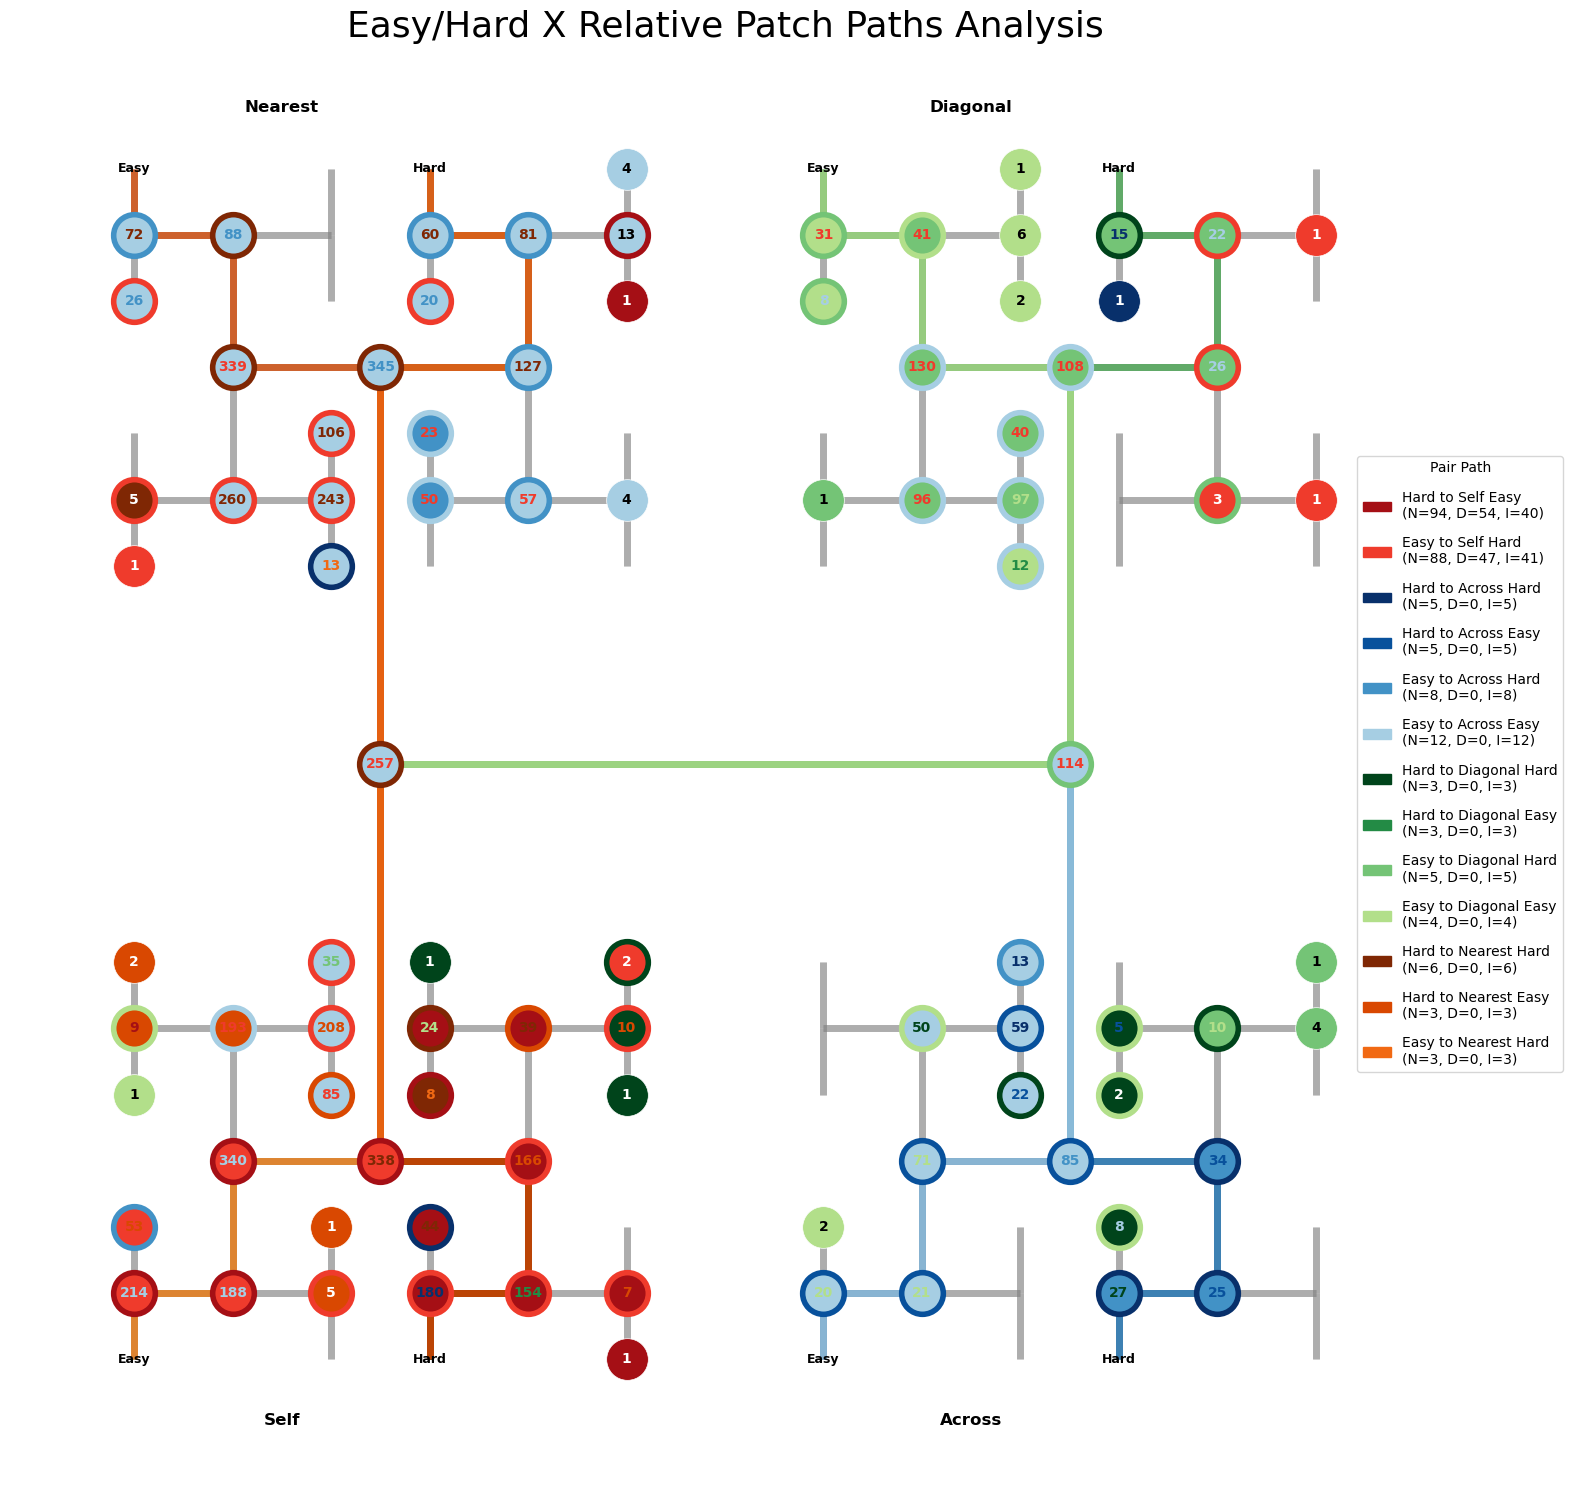

In [608]:
import networkx as nx
import matplotlib.pyplot as plt
from collections import Counter
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import numpy as np
from itertools import groupby

# 1. High Contrast 16-Color Map
color_map_16 = {
    # SELF (RED SPECTRUM)
    'Hard to Self Hard':   '#67000d', # Deep Burgundy (Darkest)
    'Hard to Self Easy':   '#a50f15', # Blood Red
    'Easy to Self Hard':   '#ef3b2c', # Bright Red
    'Easy to Self Easy':   '#fb9a99', # Soft Coral

    # ACROSS (BLUE SPECTRUM)
    'Hard to Across Hard': '#08306b', # Navy (Darkest)
    'Hard to Across Easy': '#08519c', # Royal Blue
    'Easy to Across Hard': '#4292c6', # Sky Blue
    'Easy to Across Easy': '#a6cee3', # Pale Azure

    # DIAGONAL (GREEN SPECTRUM)
    'Hard to Diagonal Hard':'#00441b', # Forest Green (Darkest)
    'Hard to Diagonal Easy':'#238b45', # Kelly Green
    'Easy to Diagonal Hard':'#74c476', # Sage Green
    'Easy to Diagonal Easy':'#b2df8a', # Mint Green

    # NEAREST (GOLD/ORANGE SPECTRUM)
    'Hard to Nearest Hard': '#7f2704', # Burnt Umber (Darkest)
    'Hard to Nearest Easy': '#d94801', # Deep Orange
    'Easy to Nearest Hard': '#f16913', # Vivid Orange (Fixing naming consistency)
    'Easy to Nearest Easy': '#fdbf6f'  # Apricot Gold
}

def plot_universal_16_path_projector_complete(G, node_positions, df_all_paths, key_to_nodes, node_to_key, port_meta, colormap=color_map_16):
    
    rel_to_template_idx = {'Self': 0, 'Across': 1, 'Diagonal': 2, 'Nearest': 3}
    universal_detours = Counter()

    # 2. Process Detours and Backbones
    for _, row in df_all_paths.iterrows():
        path = row['path_nodes']
        group = row['group']
        relationship = row['relationship']
        src_patch_idx = port_meta[row['source_port']]['patch']
        
        # Bridge-Flip logic for Patches 1 and 2
        needs_bridge_flip = src_patch_idx in [1, 2]

        if not row['is_direct']:
            for node in path[1:-1]:
                if node in node_to_key:
                    key = node_to_key[node]
                    curr_phys_patch = next((i for i in range(4) if node in [nodes[i] for nodes in key_to_nodes.values()]), None)
                    if curr_phys_patch is not None:
                        rel_to_source = rel_matrix[(src_patch_idx, curr_phys_patch)]
                        proj_idx = rel_to_template_idx[rel_to_source]
                        universal_detours[(group, key_to_nodes[key][proj_idx])] += 1
                elif node in ['L0', 'R0']:
                    target_node = ('R0' if node == 'L0' else 'L0') if needs_bridge_flip else node
                    universal_detours[(group, target_node)] += 1
        # for node in path[1:-1]:
        #     if node in node_to_key:
        #         key = node_to_key[node]
        #         curr_phys_patch = next((i for i in range(4) if node in [nodes[i] for nodes in key_to_nodes.values()]), None)
        #         if curr_phys_patch is not None:
        #             rel_to_source = rel_matrix[(src_patch_idx, curr_phys_patch)]
        #             proj_idx = rel_to_template_idx[rel_to_source]
        #             universal_detours[(group, key_to_nodes[key][proj_idx])] += 1
        #     elif node in ['L0', 'R0']:
        #         target_node = ('R0' if node == 'L0' else 'L0') if needs_bridge_flip else node
        #         universal_detours[(group, target_node)] += 1

    # 3. Setup Plot
    fig = plt.figure(figsize=(26, 16))
    ax = fig.add_axes([0.05, 0.05, 0.55, 0.9])
    nx.draw_networkx_edges(G, node_positions, alpha=0.4, edge_color='gray', arrows=False, width=5)

    # 4. Draw Direct Path "Flow" Edges
    for group_name, color in color_map_16.items():
        if group_name in df_all_paths['group'].values:
            parts = group_name.split(' to ')
            src_role = parts[0]
            rel_parts = parts[1].split(' ')
            rel, dest_role = rel_parts[0], rel_parts[1]
            
            src_key = 'K26' if src_role == 'Easy' else 'K22'
            dest_key = 'K26' if dest_role == 'Easy' else 'K22'
            
            u_src = key_to_nodes[src_key][0] 
            u_dest = key_to_nodes[dest_key][rel_to_template_idx[rel]]
            
            try:
                backbone = nx.shortest_path(G, u_src, u_dest)
                edge_list = [(backbone[i], backbone[i+1]) for i in range(len(backbone)-1)]
                nx.draw_networkx_edges(G, node_positions, edgelist=edge_list, 
                                       edge_color=color, width=5, alpha=0.75, arrows=False)
            except: pass

    # 5. Draw Detour Nodes with Triple-Color Logic
    all_detour_nodes = sorted(list(set([n for (g, n) in universal_detours.keys()])))
    for phys_node in all_detour_nodes:
        # Get counts for all groups at this node, sorted descending
        node_stats = {g: universal_detours[(g, phys_node)] for g, n in universal_detours.keys() if n == phys_node}
        sorted_groups = sorted(node_stats.keys(), key=lambda x: node_stats[x], reverse=True)
        total_count = sum(node_stats.values())
        
        # Assign colors for Top 1, 2, and 3
        fill_color = color_map_16.get(sorted_groups[0], 'gray')
        border_color = color_map_16.get(sorted_groups[1], 'white') if len(sorted_groups) > 1 else 'white'
        text_color = color_map_16.get(sorted_groups[2], None) if len(sorted_groups) > 2 else None
        
        # If no 3rd color, use contrast logic for text
        if text_color is None:
            lum = np.mean(mcolors.to_rgb(fill_color))
            text_color = 'white' if lum < 0.5 else 'black'
            
        # Draw the node (Top 1 = Fill, Top 2 = Border)
        nx.draw_networkx_nodes(G, node_positions, nodelist=[phys_node], 
                               node_color=[fill_color], 
                               edgecolors=border_color,
                               linewidths=4 if len(sorted_groups) > 1 else 0.5,
                               node_size=900, alpha=1, ax=ax)
        
        # Draw the label (Top 3 = Text Color)
        nx.draw_networkx_labels(G, node_positions, labels={phys_node: str(total_count)}, 
                                font_size=10, font_weight='bold', font_color=text_color)

    # 6. EXTERNAL PATCH LABELS & ROLE LABELS
    for rel, idx in rel_to_template_idx.items():      
        nx.draw_networkx_labels(G, node_positions, 
                                labels={key_to_nodes['K26'][idx]: 'Easy', key_to_nodes['K22'][idx]: 'Hard'}, 
                                font_size=9, font_weight='bold')
        pos_a = node_positions[key_to_nodes['K26'][idx]]
        pos_b = node_positions[key_to_nodes['K22'][idx]]
        mid_x, mid_y = (pos_a[0] + pos_b[0]) / 2, (pos_a[1] + pos_b[1]) / 2
        if rel == 'Nearest' or rel == 'Diagonal':
            mid_y += 30
        else:
            mid_y -= 30
        ax.text(mid_x, mid_y, rel, color='black', 
                fontweight='bold', fontsize=12, ha='center', va='center',
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.3'))

    # 8. Legend and Titles

    legend_entries = []
    for group_name, color in color_map_16.items():
        rel_df = df_all_paths[df_all_paths['group'] == group_name]
        if len(rel_df) > 0:
            n_tot, n_dir = len(rel_df), rel_df['is_direct'].sum()
            patch = mpatches.Patch(color=color, label=f"{group_name}\n(N={n_tot}, D={n_dir}, I={n_tot-n_dir})")
            legend_entries.append(patch)

    fig.legend(handles=legend_entries, loc='center right', title="Pair Path", 
               bbox_to_anchor=(0.65, 0.5), fontsize=10, labelspacing=1.1, frameon=True)

    ax.set_title("Easy/Hard X Relative Patch Paths Analysis", fontsize=26, pad=0)
    ax.axis('off')
    plt.show()

plot_universal_16_path_projector_complete(G, node_positions, all_paths_without_repeat, key_to_nodes, node_to_key, port_meta)

In [609]:
# df_all_paths[df_all_paths['group'] == 'Easy to Nearest Easy']
# df_all_paths
# port_meta['Port5']['patch']
len(df_all_paths.groupby('group'))

15

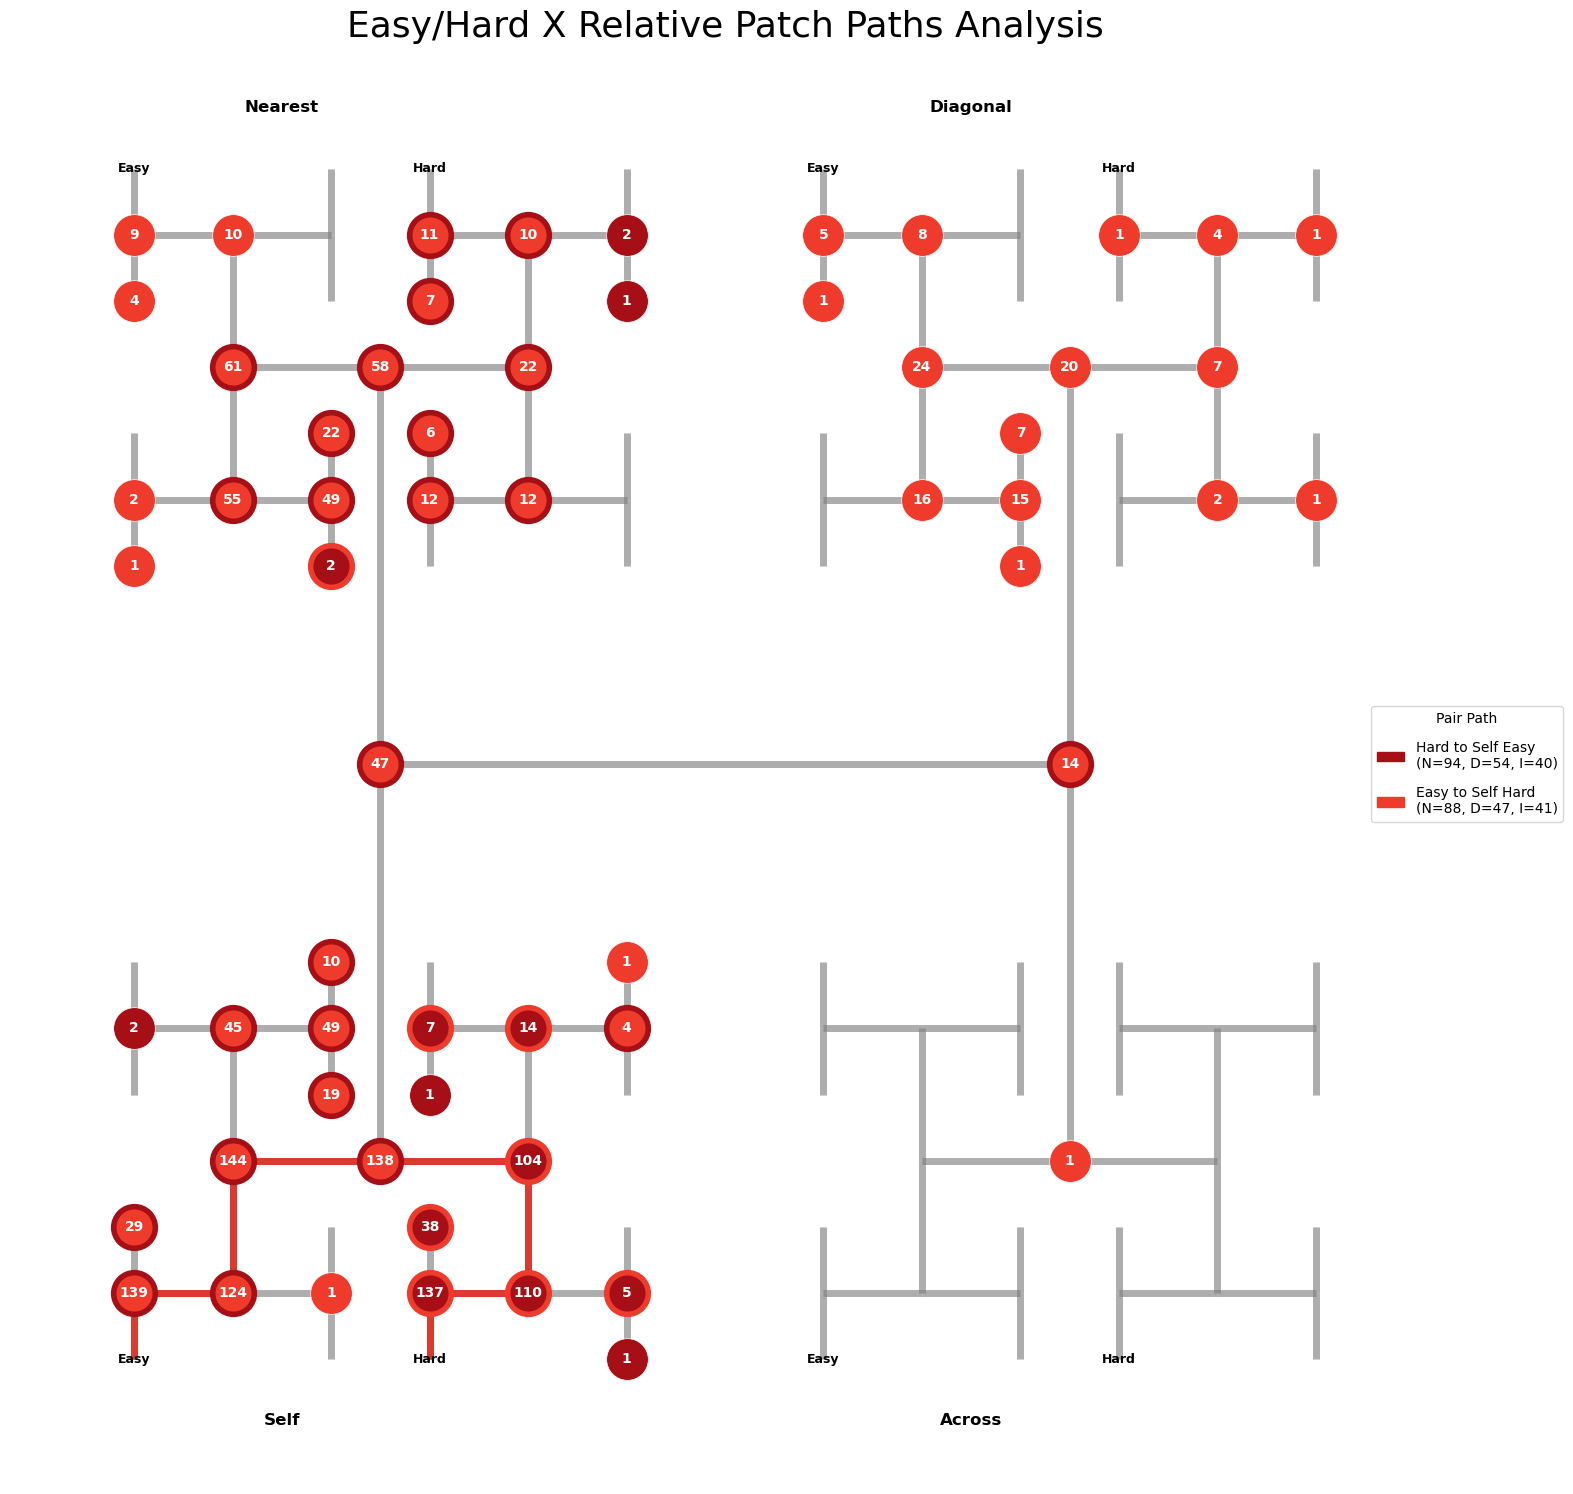

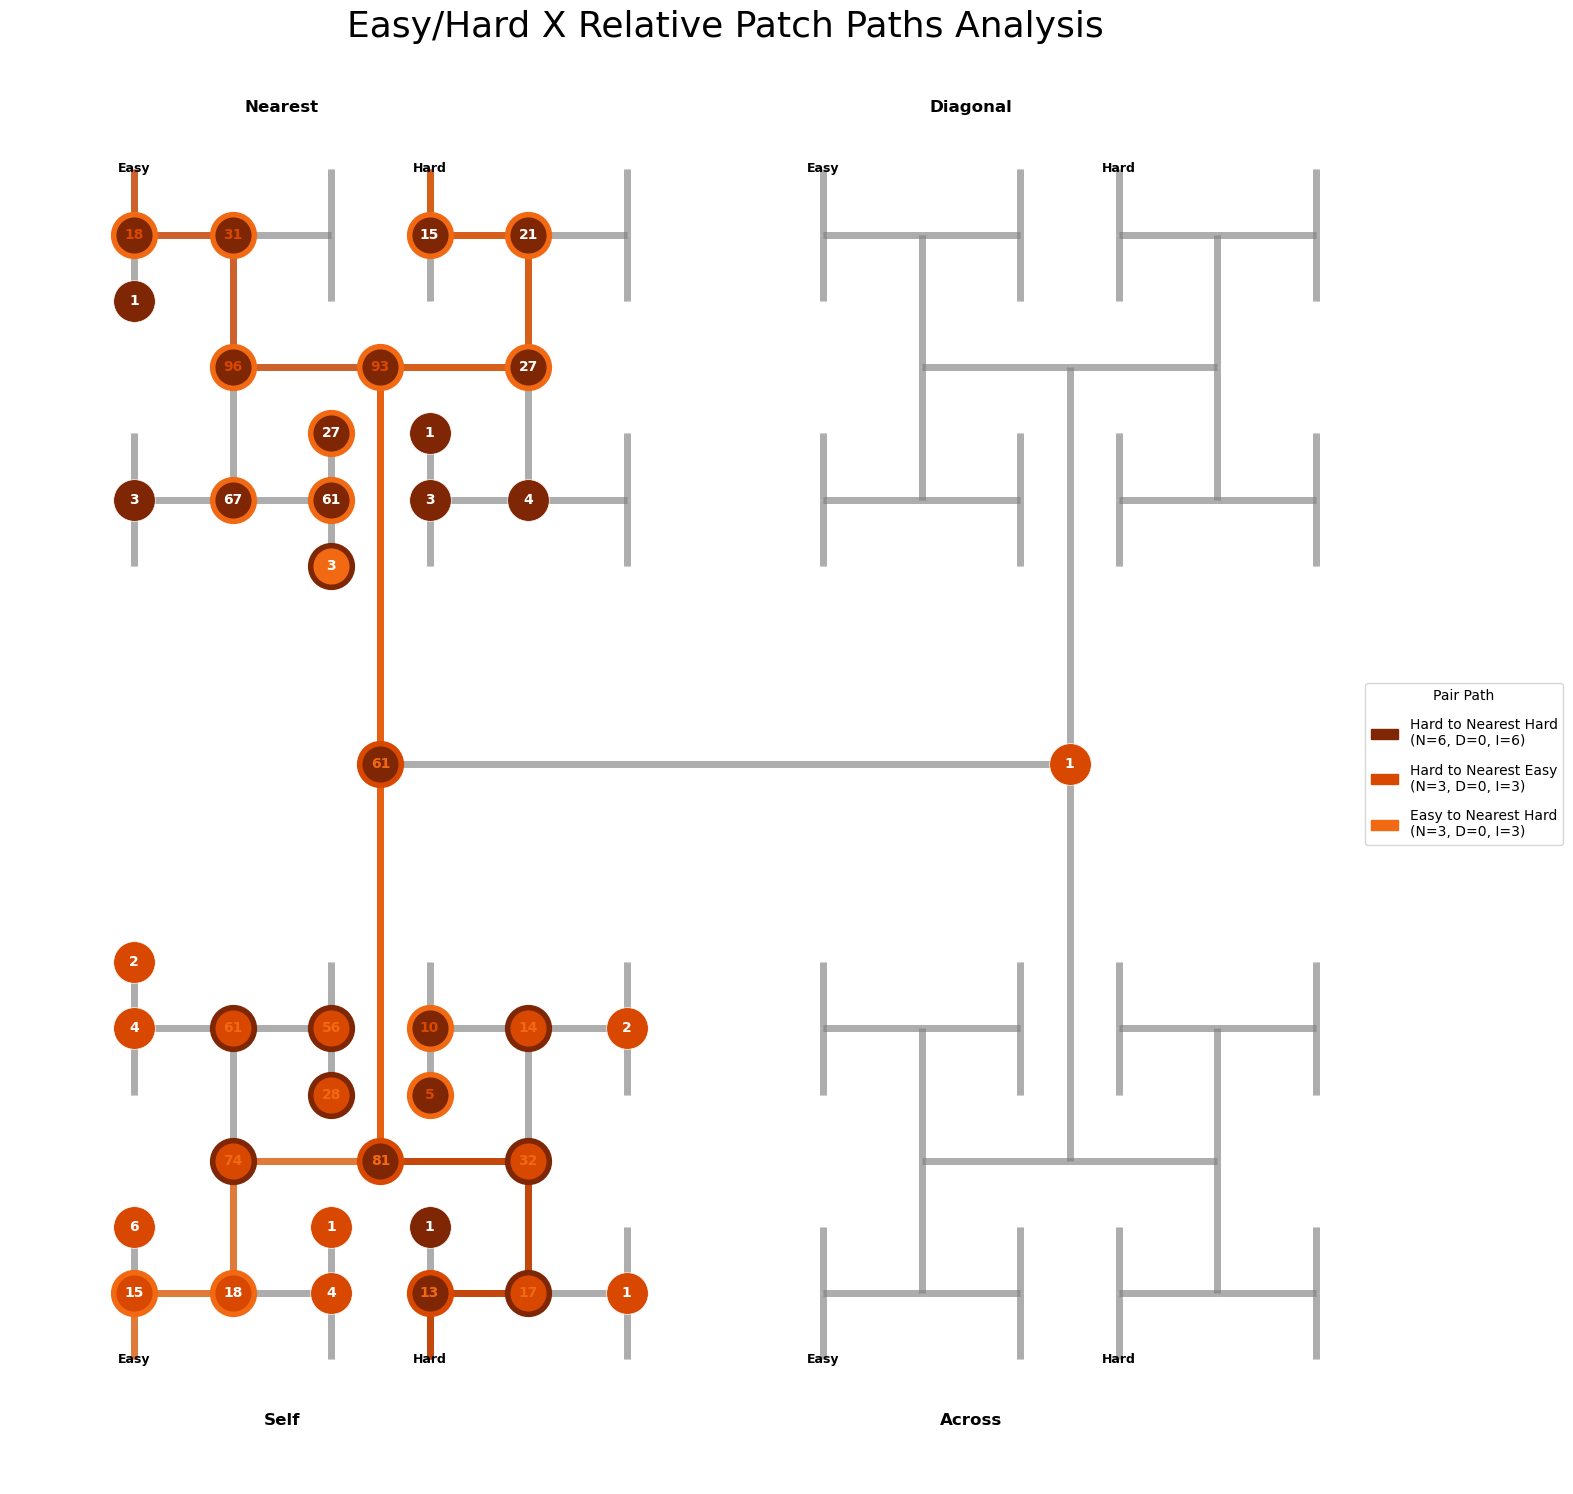

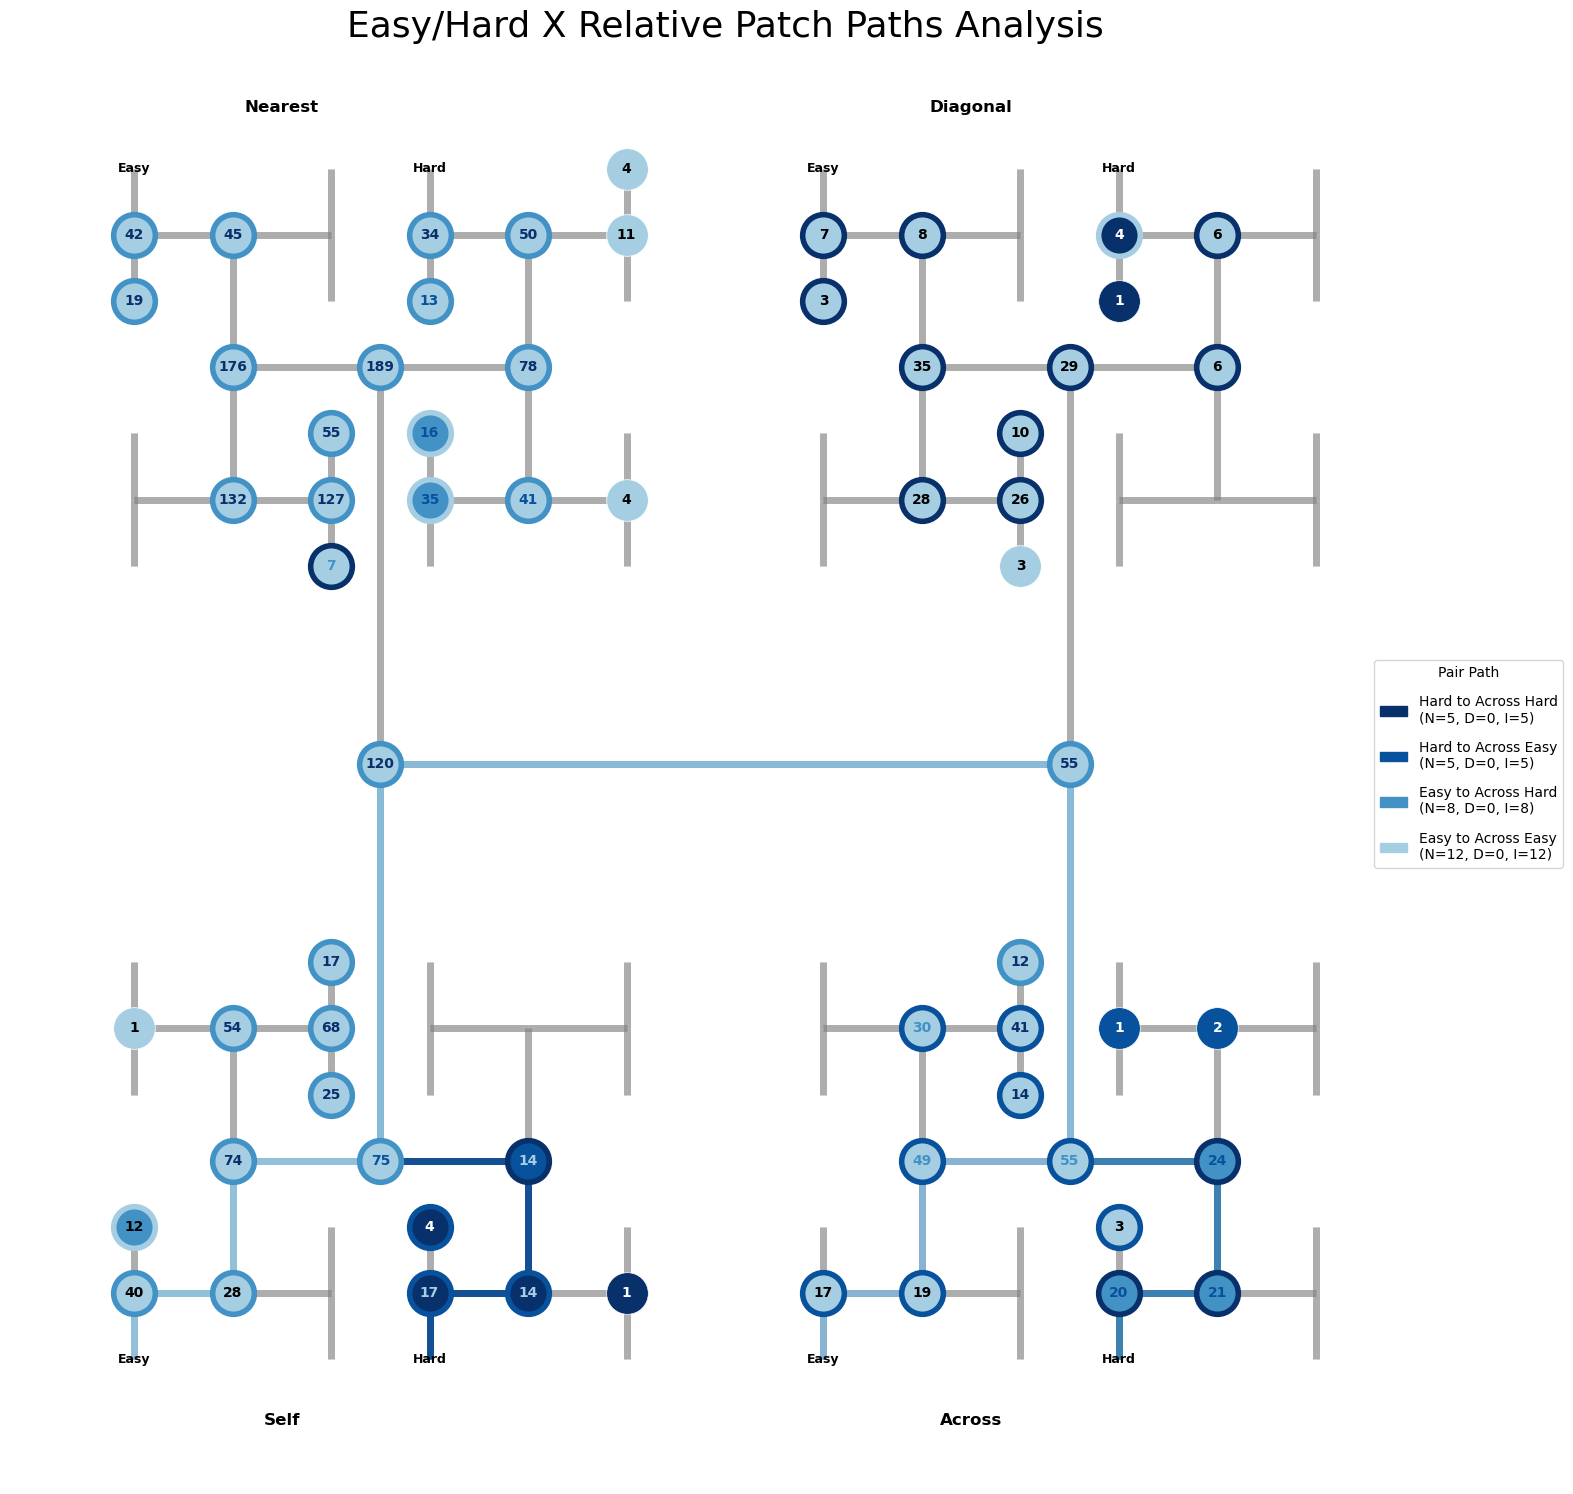

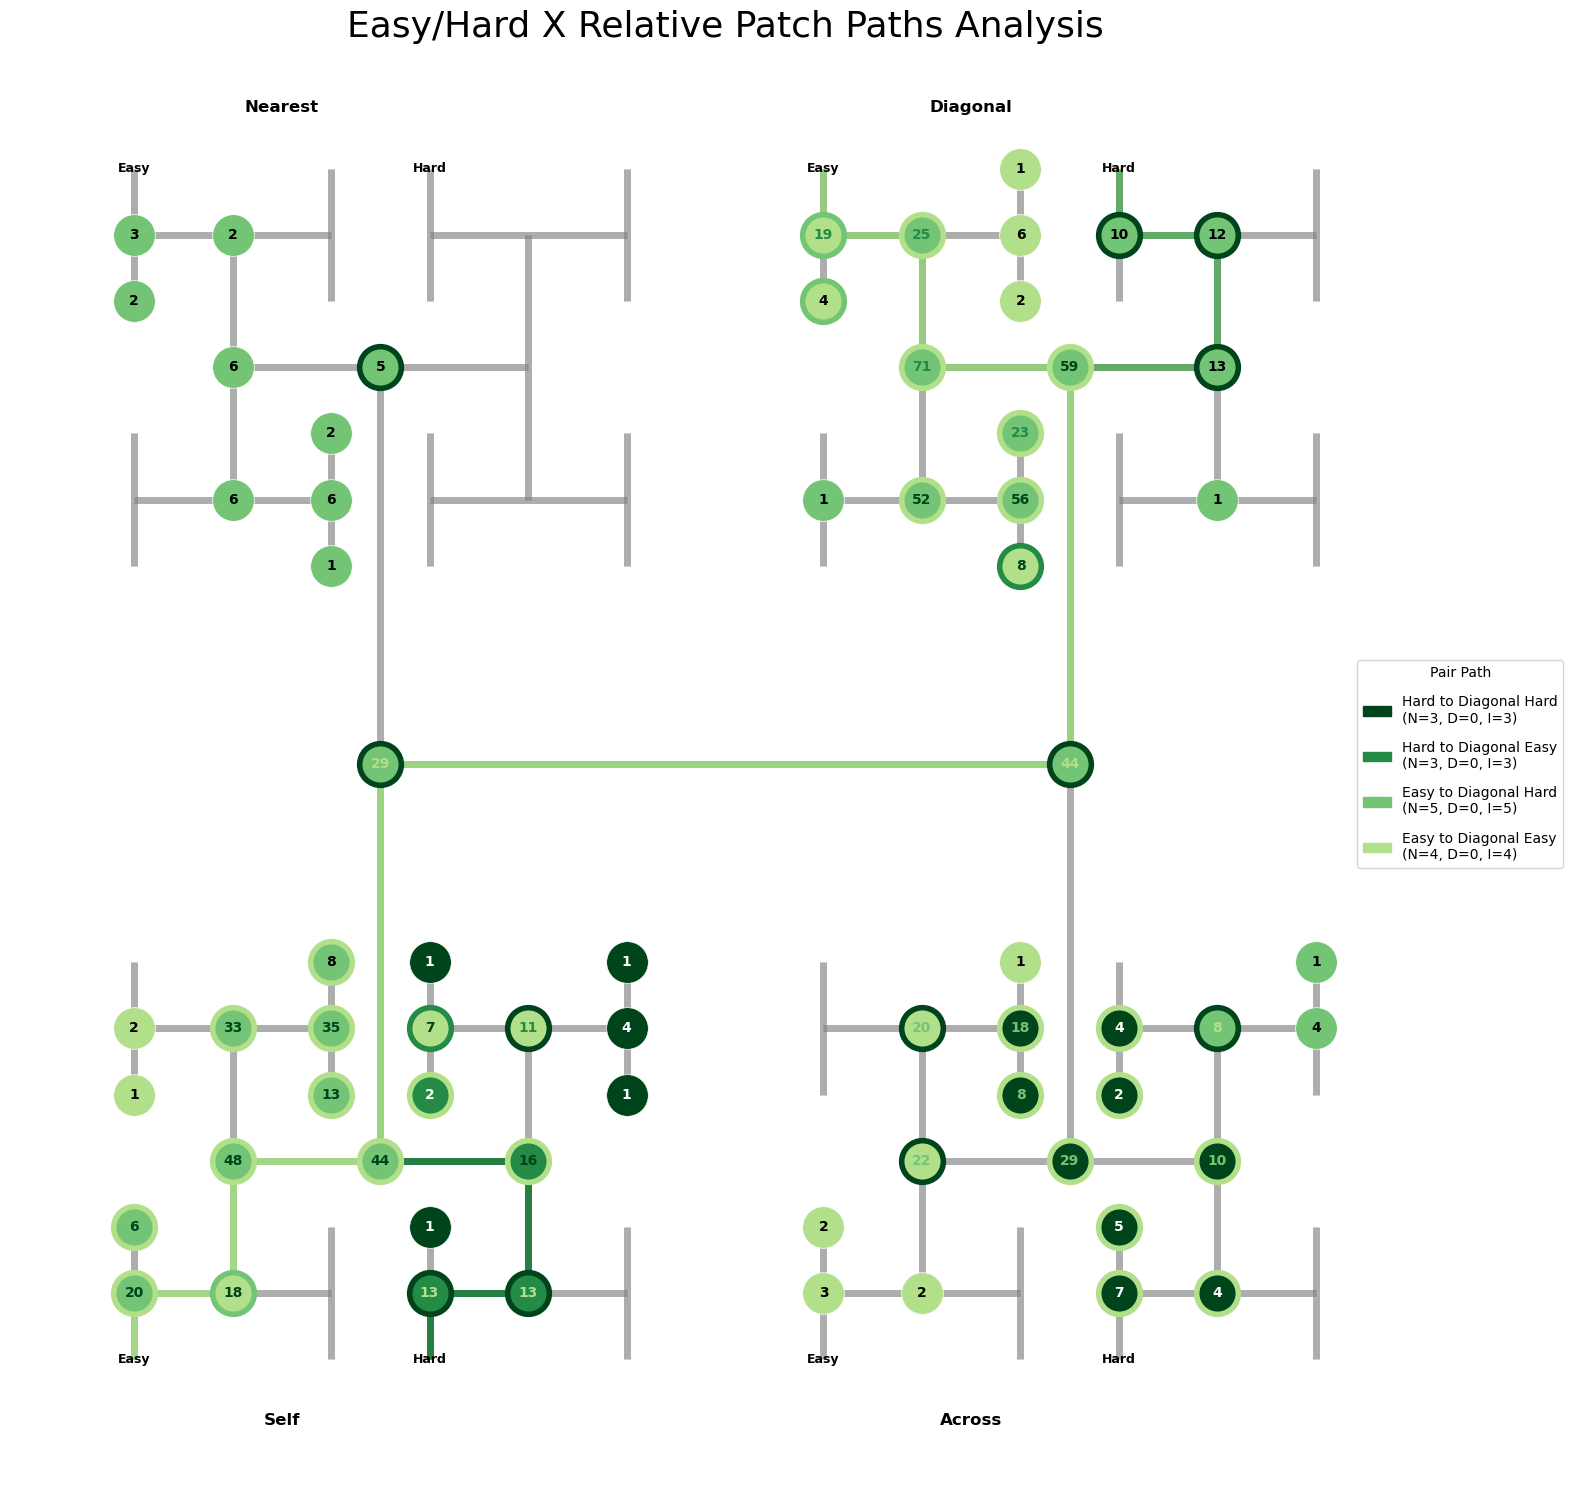

In [610]:
plot_universal_16_path_projector_complete(G, node_positions, all_paths_without_repeat[all_paths_without_repeat['relationship'] == 'Self'], key_to_nodes, node_to_key, port_meta)
plot_universal_16_path_projector_complete(G, node_positions, all_paths_without_repeat[all_paths_without_repeat['relationship'] == 'Nearest'], key_to_nodes, node_to_key, port_meta)
plot_universal_16_path_projector_complete(G, node_positions, all_paths_without_repeat[all_paths_without_repeat['relationship'] == 'Across'], key_to_nodes, node_to_key, port_meta)
plot_universal_16_path_projector_complete(G, node_positions, all_paths_without_repeat[all_paths_without_repeat['relationship'] == 'Diagonal'], key_to_nodes, node_to_key, port_meta)

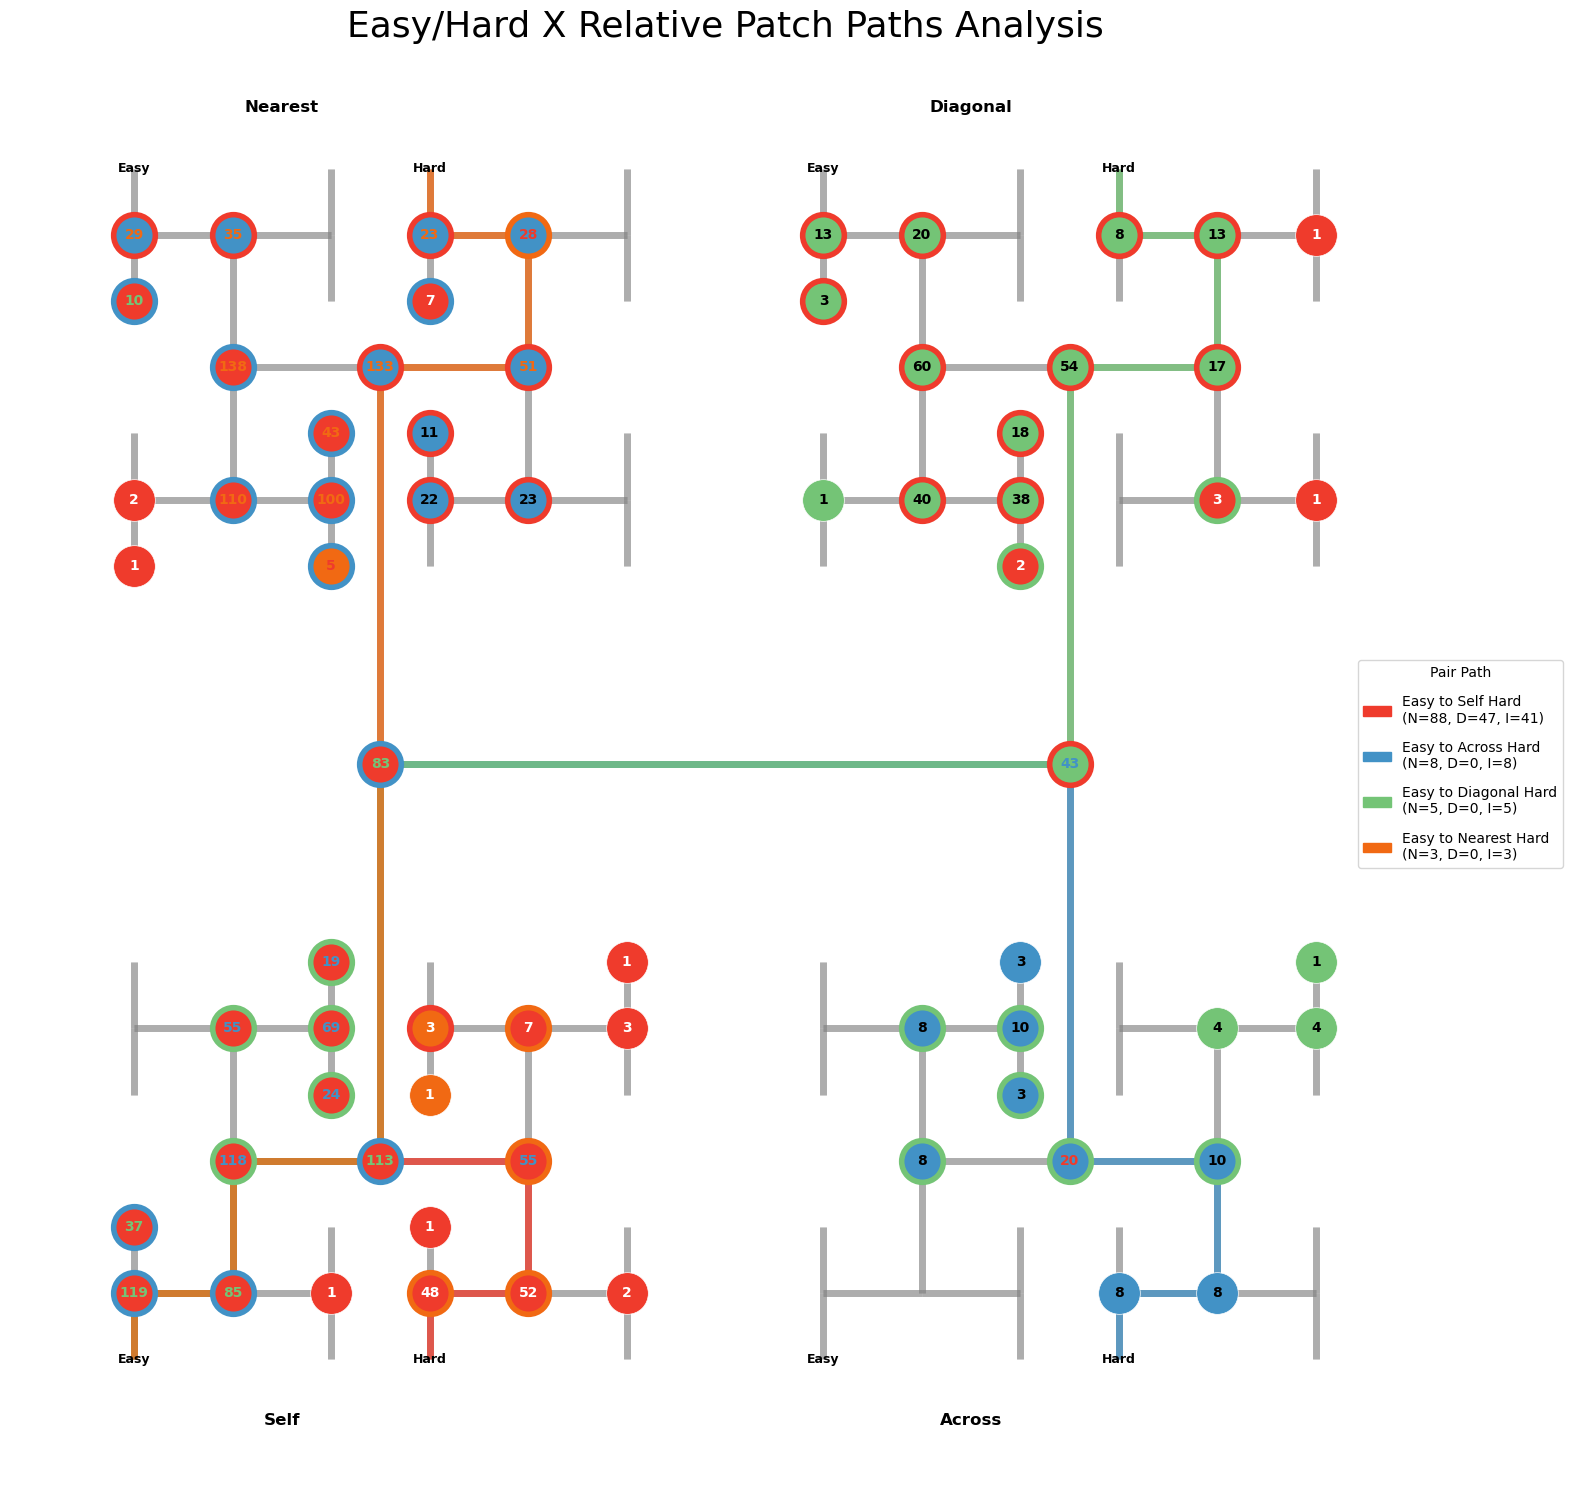

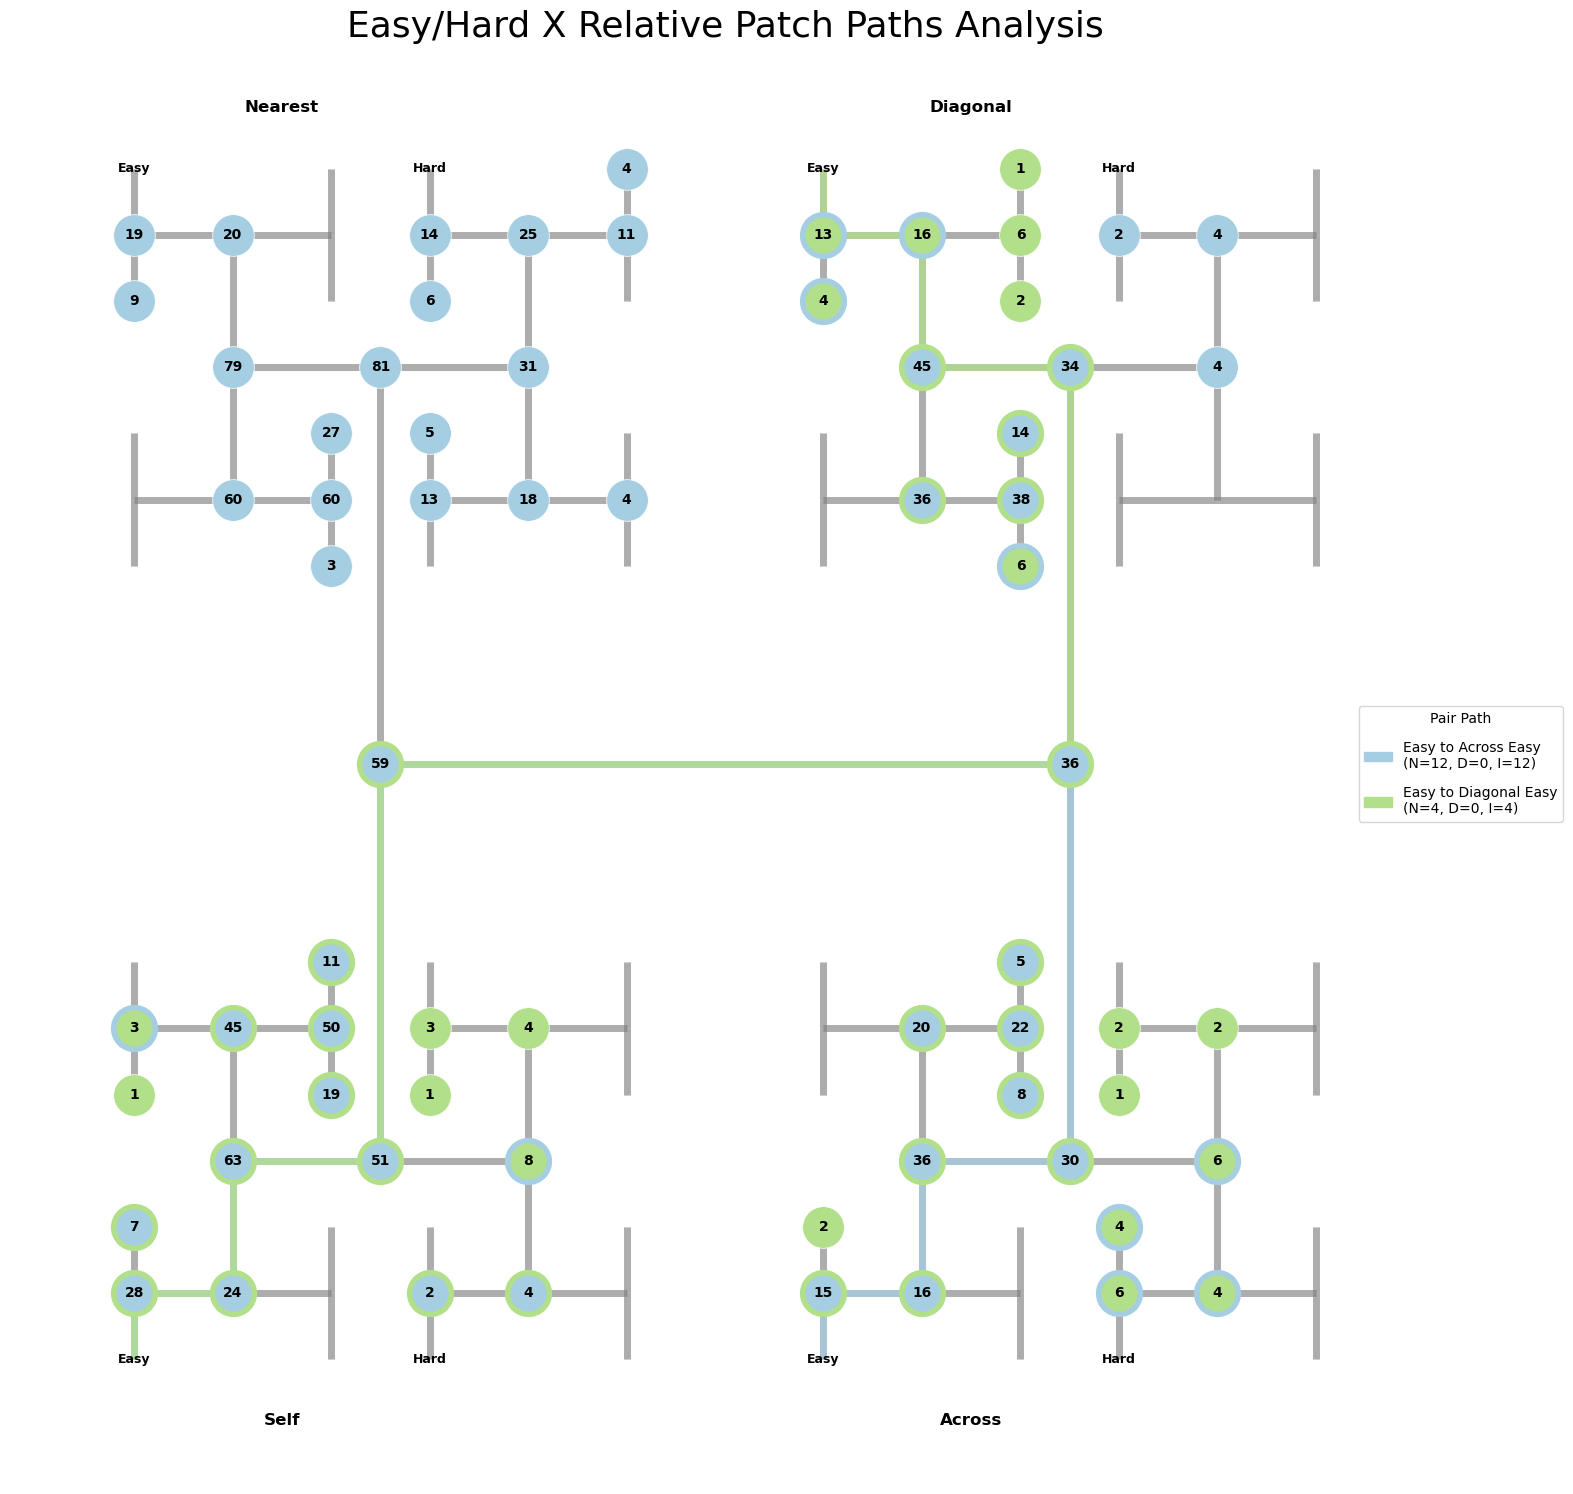

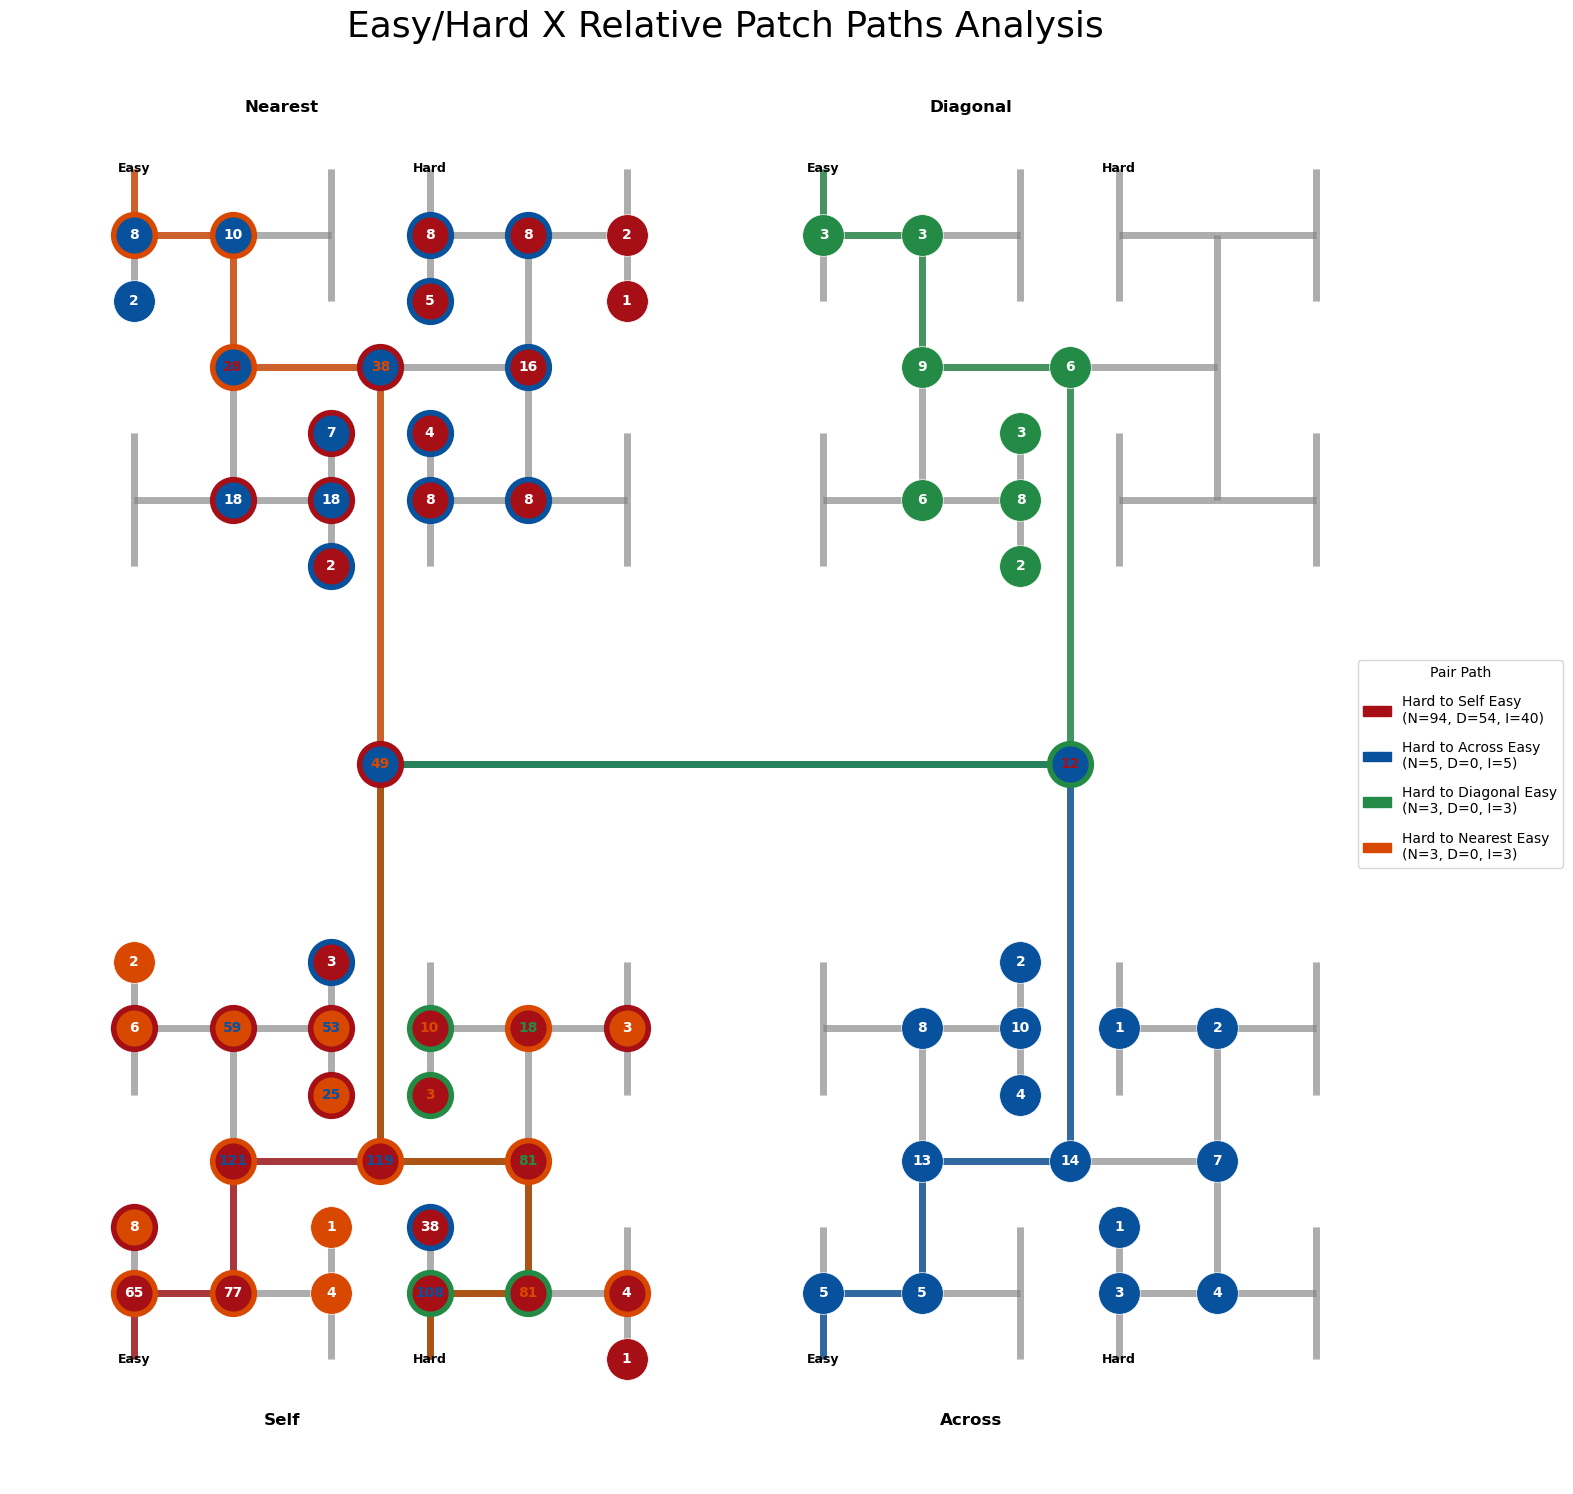

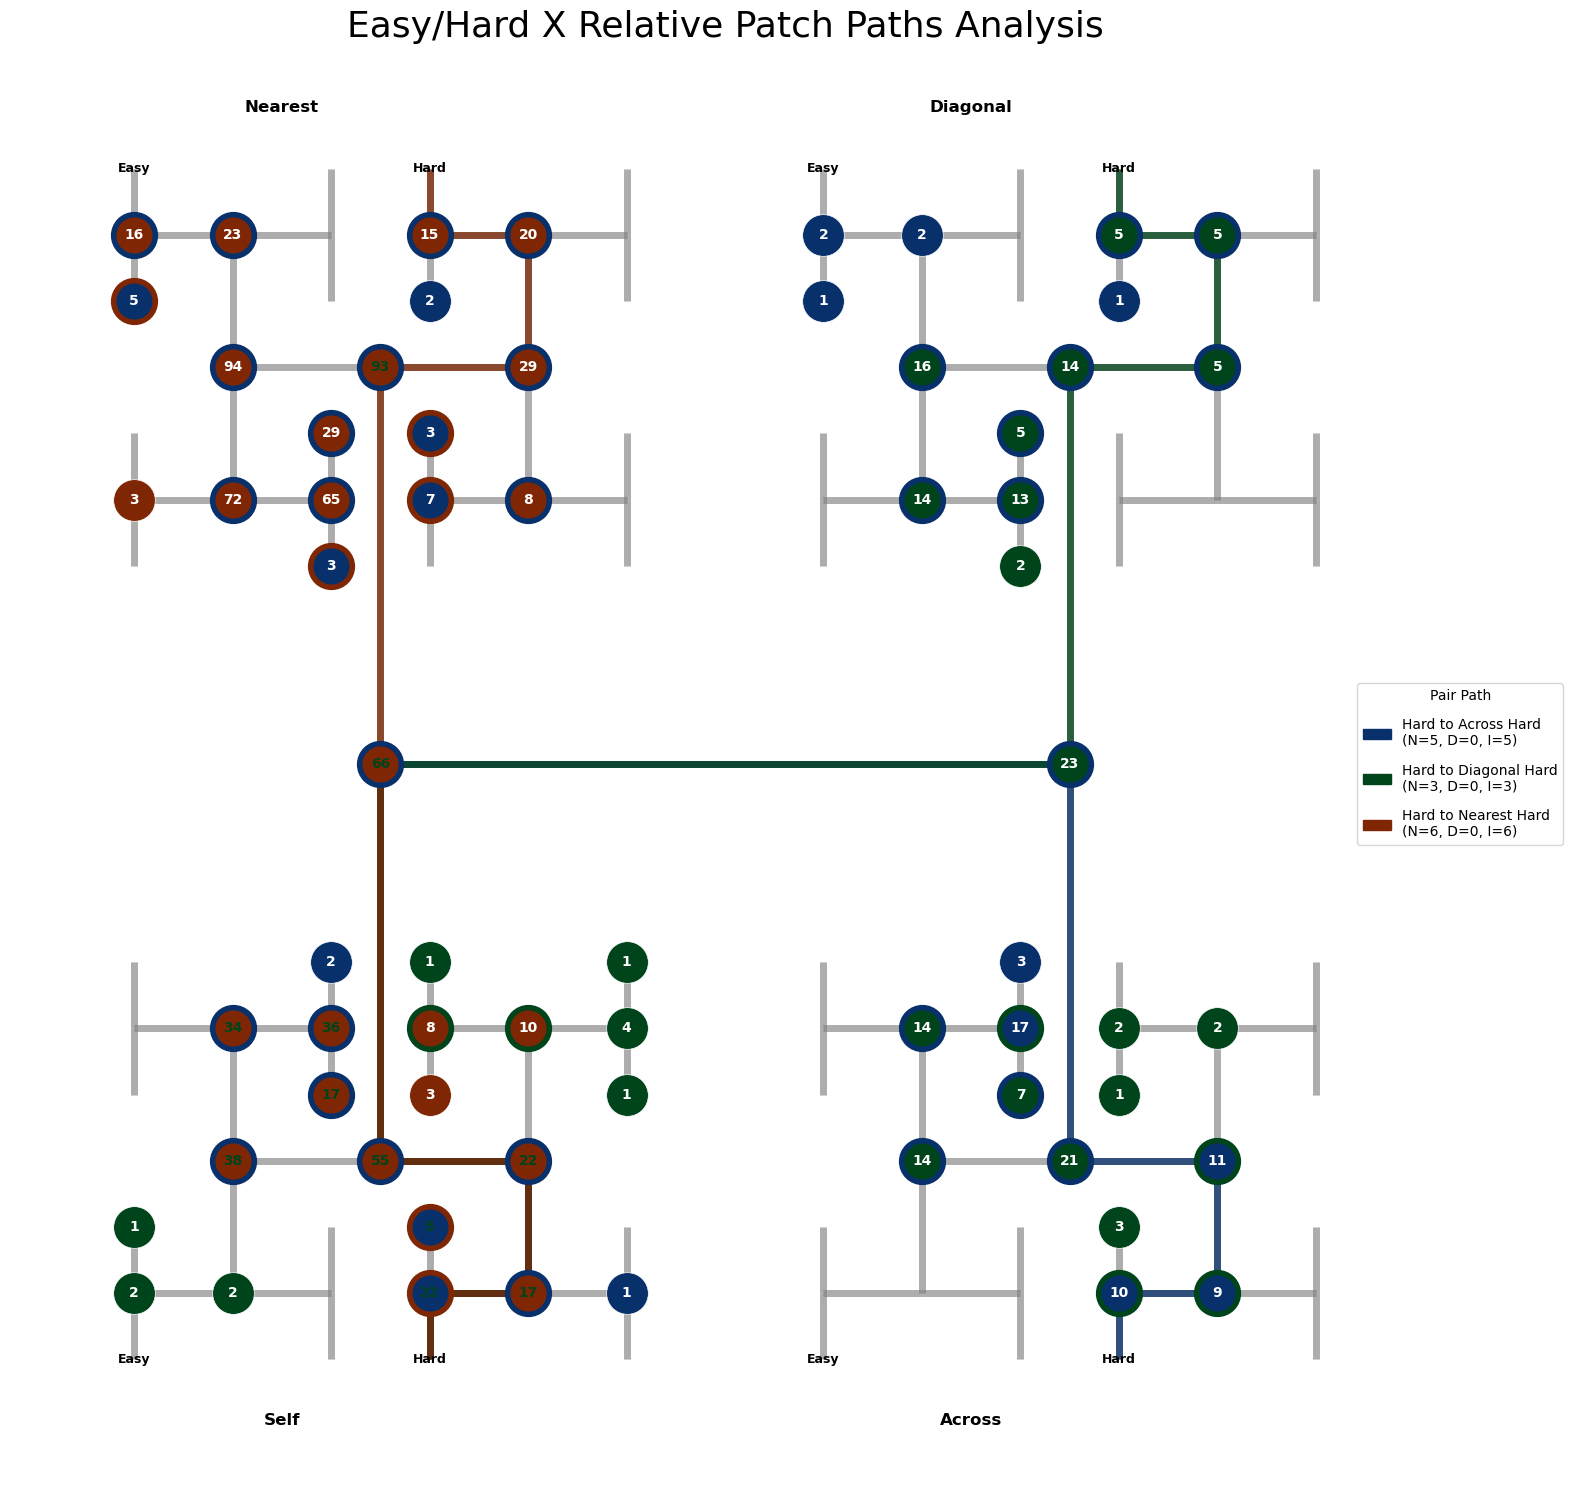

In [611]:
# all_easy_to_easy = all_paths_without_repeat[(all_paths_without_repeat['group'] == 'Easy to Diagonal Easy') | (all_paths_without_repeat['group'] == 'Easy to Nearest Easy') | (all_paths_without_repeat['group'] == 'Easy to Across Easy')]
# all_easy_to_hard = all_paths_without_repeat[(all_paths_without_repeat['group'] == 'Easy to Diagonal Hard') | (all_paths_without_repeat['group'] == 'Easy to Nearest Hard') | (all_paths_without_repeat['group'] == 'Easy to Across Hard')]

# plot_universal_16_path_projector_complete(G, node_positions, all_easy_to_easy, key_to_nodes, node_to_key, port_meta)
# plot_universal_16_path_projector_complete(G, node_positions, all_easy_to_hard, key_to_nodes, node_to_key, port_meta)

    # 'Hard to Self Hard':   '#67000d', # Deep Burgundy (Darkest)
    # 'Hard to Self Easy':   '#a50f15', # Blood Red
    # 'Easy to Self Hard':   '#ef3b2c', # Bright Red
    # 'Easy to Self Easy':   '#fb9a99', # Soft Coral
color_map_easy_hard = {
    # Hard To Easy (RED)
    'Hard to Self Easy':   '#a50f15', # Blood Red
    'Hard to Across Easy': '#a50f15', # Blood Red
    'Hard to Diagonal Easy':'#a50f15', # Blood Red
    'Hard to Nearest Easy': '#a50f15', # Blood Red
    # Easy To Hard (GREEN)
    'Easy to Self Hard':   '#74c476', # Sage Green
    'Easy to Across Hard': '#74c476', # Sage Green
    'Easy to Diagonal Hard':'#74c476', # Sage Green
    'Easy to Nearest Hard': '#74c476', # Sage Green
    # Easy To Easy (BLUE)
    'Easy to Self Easy': '#a6cee3', # Pale Azure
    'Easy to Across Easy': '#a6cee3', # Pale Azure
    'Easy to Diagonal Easy':'#a6cee3', # Pale Azure
    'Easy to Nearest Easy': '#a6cee3', # Pale Azure
    # Hard To Hard (ORANGE)
    'Hard to Self Hard':   '#ff7f00', # Orange
    'Hard to Across Hard': '#ff7f00', # Orange
    'Hard to Diagonal Hard':'#ff7f00', # Orange
    'Hard to Nearest Hard': '#ff7f00'  # Orange
}


df = all_paths_without_repeat.copy()
df['src_role'] = df['group'].apply(lambda x: x.split(' to ')[0])
df['dest_role'] = df['group'].apply(lambda x: x.split(' ')[-1])
df['role_transition'] = df['src_role'] + " to " + df['dest_role']

# Example: Filter for Easy to Hard transitions
easy_to_hard_df = df[df['role_transition'] == 'Easy to Hard']
easy_to_easy_df = df[df['role_transition'] == 'Easy to Easy']
hard_to_easy_df = df[df['role_transition'] == 'Hard to Easy']
hard_to_hard_df = df[df['role_transition'] == 'Hard to Hard']
plot_universal_16_path_projector_complete(G, node_positions, easy_to_hard_df, key_to_nodes, node_to_key, port_meta, colormap=color_map_easy_hard)
plot_universal_16_path_projector_complete(G, node_positions, easy_to_easy_df, key_to_nodes, node_to_key, port_meta, colormap=color_map_easy_hard)
plot_universal_16_path_projector_complete(G, node_positions, hard_to_easy_df, key_to_nodes, node_to_key, port_meta, colormap=color_map_easy_hard)
plot_universal_16_path_projector_complete(G, node_positions, hard_to_hard_df, key_to_nodes, node_to_key, port_meta, colormap=color_map_easy_hard)

In [612]:
all_paths_without_repeat

,source_port,dest_port,relationship,group,actual_length,filtered_length,shortest_dist,is_direct,is_direct_tol2,is_direct_tol4,is_direct_skip_leaves,path_nodes
0,Port6,Port2,Diagonal,Hard to Diagonal Easy,34,30,12,False,False,False,False,"[L525, L412, L36, L412, L36, L412, L36, L412, ..."
1,Port2,Port4,Across,Easy to Across Easy,122,92,12,False,False,False,False,"[R526, R413, R36, R413, R527, R413, R36, R23, ..."
2,Port4,Port2,Across,Easy to Across Easy,22,18,12,False,False,False,False,"[L510, L45, L32, L21, L10, L0, R0, R11, R23, R..."
3,Port2,Port1,Self,Easy to Self Hard,99,79,9,False,False,False,False,"[R526, R413, R527, R413, R36, R23, R11, R23, R..."
4,Port1,Port2,Self,Hard to Self Easy,31,31,9,False,False,False,False,"[R522, R411, R35, R22, R35, R22, R11, R22, R34..."
...,...,...,...,...,...,...,...,...,...,...,...,...
341,Port4,Port6,Nearest,Easy to Nearest Hard,61,57,11,False,False,False,False,"[L510, L45, L32, L21, L10, L0, L11, L22, L34, ..."
344,Port6,Port5,Self,Hard to Self Easy,49,41,9,False,False,False,False,"[L525, L412, L36, L23, L11, L23, L11, L0, L11,..."
345,Port5,Port2,Diagonal,Easy to Diagonal Easy,48,40,12,False,False,False,False,"[L521, L410, L35, L22, L11, L0, L11, L23, L36,..."
347,Port2,Port1,Self,Easy to Self Hard,11,9,9,False,True,True,True,"[R526, R413, R527, R413, R36, R23, R11, R22, R..."


In [613]:
# direct_skip = all_paths_without_repeat[all_paths_without_repeat['is_direct_skip_leaves'] == True]
# Get all unique paths in direct_self['path_nodes']
# unique_paths = direct_self['path_nodes'].apply(tuple).unique()
# print(f"Total unique direct self paths: {len(unique_paths)}")
# for path in unique_paths:
#     print(path)
for path in all_paths_without_repeat[all_paths_without_repeat['group'] == 'Easy to Diagonal Hard']['path_nodes']:

    print(path)
all_paths_without_repeat[all_paths_without_repeat['group'] == 'Easy to Diagonal Hard']

['R526', 'R413', 'R36', 'R23', 'R11', 'R23', 'R37', 'R415', 'R531', 'R415', 'R530', 'R415', 'R37', 'R23', 'R11', 'R0', 'L0', 'L11', 'L0', 'L10', 'L0', 'L11', 'L22', 'L35', 'L410', 'L520', 'L410', 'L35', 'L22', 'L11', 'L22', 'L34', 'L48', 'L516', 'L48', 'L34', 'L22', 'L11', 'L0', 'L11', 'L23', 'L36', 'L412', 'L36', 'L23', 'L37', 'L23', 'L11', 'L0', 'L10', 'L0', 'L10', 'L0', 'L10', 'L20', 'L30', 'L41', 'L52', 'L41', 'L30', 'L41', 'L30', 'L41', 'L30', 'L20', 'L10', 'L21', 'L33', 'L47', 'L515', 'L47', 'L33', 'L21', 'L10', 'L0', 'L11', 'L23', 'L36', 'L412', 'L525']
['R526', 'R413', 'R36', 'R413', 'R527', 'R413', 'R36', 'R23', 'R11', 'R23', 'R37', 'R415', 'R531', 'R415', 'R37', 'R23', 'R11', 'R0', 'R11', 'R23', 'R37', 'R415', 'R531', 'R415', 'R37', 'R23', 'R11', 'R0', 'R11', 'R23', 'R37', 'R415', 'R530', 'R415', 'R37', 'R23', 'R11', 'R0', 'R11', 'R23', 'R37', 'R415', 'R530', 'R415', 'R37', 'R23', 'R11', 'R0', 'L0', 'L11', 'L22', 'L34', 'L48', 'L516', 'L48', 'L34', 'L22', 'L11', 'L22', 'L35',

,source_port,dest_port,relationship,group,actual_length,filtered_length,shortest_dist,is_direct,is_direct_tol2,is_direct_tol4,is_direct_skip_leaves,path_nodes
41,Port2,Port6,Diagonal,Easy to Diagonal Hard,80,68,12,False,False,False,False,"[R526, R413, R36, R23, R11, R23, R37, R415, R5..."
81,Port2,Port6,Diagonal,Easy to Diagonal Hard,80,64,12,False,False,False,False,"[R526, R413, R36, R413, R527, R413, R36, R23, ..."
206,Port2,Port6,Diagonal,Easy to Diagonal Hard,77,64,12,False,False,False,False,"[R526, R413, R527, R413, R36, R23, R11, R23, R..."
291,Port2,Port6,Diagonal,Easy to Diagonal Hard,90,72,12,False,False,False,False,"[R526, R413, R36, R23, R11, R23, R37, R415, R5..."
336,Port2,Port6,Diagonal,Easy to Diagonal Hard,52,40,12,False,False,False,False,"[R526, R413, R36, R413, R527, R413, R36, R23, ..."


In [614]:
all_paths_without_repeat[(all_paths_without_repeat['relationship'] == 'Nearest') & (all_paths_without_repeat['group'] == 'Easy to Nearest Hard')]

,source_port,dest_port,relationship,group,actual_length,filtered_length,shortest_dist,is_direct,is_direct_tol2,is_direct_tol4,is_direct_skip_leaves,path_nodes
112,Port5,Port3,Nearest,Easy to Nearest Hard,35,31,11,False,False,False,False,"[L521, L410, L35, L22, L11, L22, L34, L48, L51..."
317,Port4,Port6,Nearest,Easy to Nearest Hard,103,87,11,False,False,False,False,"[L510, L45, L32, L21, L10, L0, L11, L22, L34, ..."
341,Port4,Port6,Nearest,Easy to Nearest Hard,61,57,11,False,False,False,False,"[L510, L45, L32, L21, L10, L0, L11, L22, L34, ..."


In [615]:
df_all_paths[158:159]['path_nodes']

158    [L56, L43, L31, L20, L10, L0, L11, L22, L34, L...
Name: path_nodes, dtype: object

In [616]:
def analyze_reward_by_group_comprehensive(df_clean, primary_pairs, remaining_pairs, port_map):
    # 1. Label Transitions by Group (same logic as before)
    primary_labels = [f"{port_map[a]} <-> {port_map[b]}" for a, b in primary_pairs]
    remaining_labels = [f"{port_map[a]} <-> {port_map[b]}" for a, b in remaining_pairs]
    
    port_visits = df_clean[df_clean['is_port_node'] == True].copy()
    port_visits['current_port_label'] = port_visits['node_name'].map(port_map)
    port_visits['prev_port_label'] = port_visits['current_port_label'].shift(1)
    
    def get_group(row):
        pair = f"{row['prev_port_label']} <-> {row['current_port_label']}"
        rev_pair = f"{row['current_port_label']} <-> {row['prev_port_label']}"
        if pair in primary_labels or rev_pair in primary_labels:
            return 'Primary Patches'
        if pair in remaining_labels or rev_pair in remaining_labels:
            return 'Remaining Pairs'
        return 'Other'

    port_visits['group'] = port_visits.apply(get_group, axis=1)
    
    # Define "Size Reward" based on the float column
    port_visits['has_size_reward'] = port_visits['reward_size_during_node'] > 0
    
    # 2. Multi-column Aggregation
    # We group by the Pair Group and then pivot both the Boolean and the Size columns
    summary = port_visits[port_visits['group'] != 'Other'].groupby('group').agg(
        Boolean_Rewarded=('reward_during_node', 'sum'),
        Boolean_Not_Rewarded=('reward_during_node', lambda x: (x == False).sum()),
        Size_Rewarded=('has_size_reward', 'sum'),
        Size_Not_Rewarded=('has_size_reward', lambda x: (x == False).sum()),
        Total_Visits=('group', 'count')
    )

    # 3. Calculate "Ghost Rewards" (Boolean is True, but Size is 0)
    summary['Ghost_Rewards'] = summary['Boolean_Rewarded'] - summary['Size_Rewarded']
    summary['Ghost_Reward_%'] = (summary['Ghost_Rewards'] / summary['Total_Visits']) * 100

    return summary

# Execute
reward_summary_complex = analyze_reward_by_group_comprehensive(
    node_summary_df, pairs_to_check, remaining_pairs, port_map
)
print(reward_summary_complex)

                 Boolean_Rewarded  Boolean_Not_Rewarded  Size_Rewarded  \
group                                                                    
Primary Patches               129                    53             65   
Remaining Pairs                33                    24              8   

                 Size_Not_Rewarded  Total_Visits  Ghost_Rewards  \
group                                                             
Primary Patches                117           182             64   
Remaining Pairs                 49            57             25   

                 Ghost_Reward_%  
group                            
Primary Patches       35.164835  
Remaining Pairs       43.859649  


/tmp/ipykernel_28444/1818114807.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=summary.index, y=summary['Ghost_Reward_%'], palette='Reds', ax=axes[1, 1])


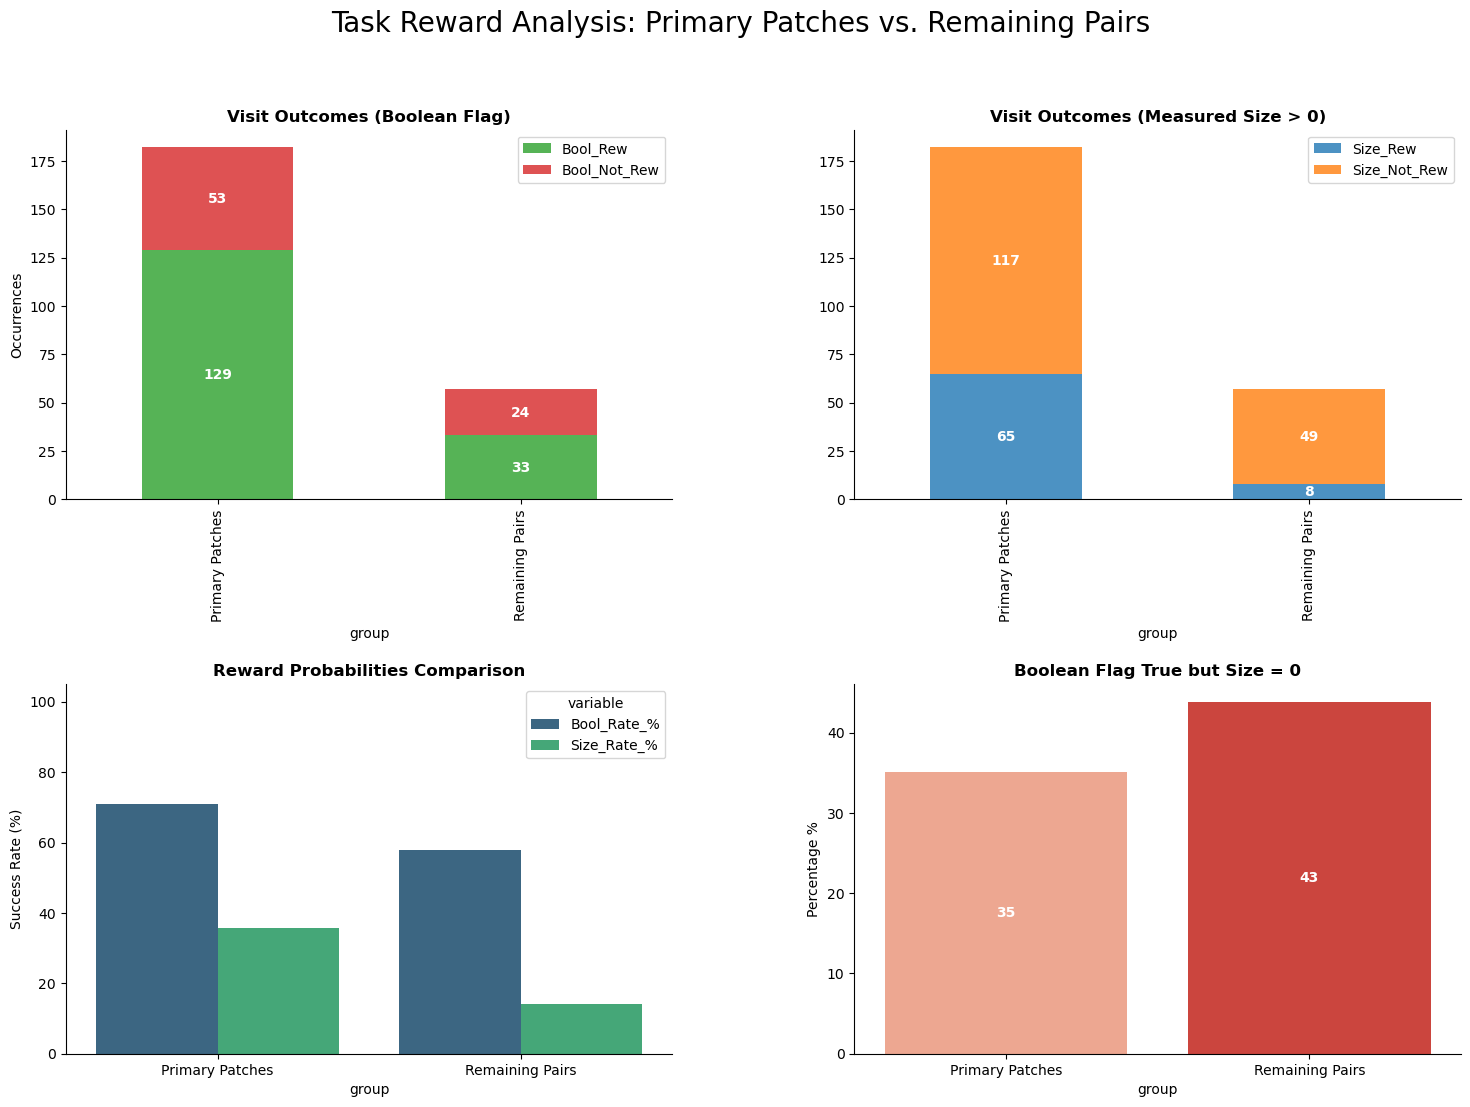

In [617]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def analyze_and_plot_reward_groups(df_clean, primary_pairs, remaining_pairs, port_map):
    # 1. Group Transitions
    primary_labels = {tuple(sorted((p1, p2))) for p1, p2 in primary_pairs}
    remaining_labels = {tuple(sorted((p1, p2))) for p1, p2 in remaining_pairs}
    
    port_visits = df_clean[df_clean['is_port_node'] == True].copy()
    port_visits['prev_port_node'] = port_visits['node_name'].shift(1)
    
    def get_group(row):
        if pd.isna(row['prev_port_node']): return None
        pair = tuple(sorted((row['prev_port_node'], row['node_name'])))
        if pair in primary_labels: return 'Primary Patches'
        if pair in remaining_labels: return 'Remaining Pairs'
        return 'Other'

    port_visits['group'] = port_visits.apply(get_group, axis=1)
    port_visits['has_size_reward'] = port_visits['reward_size_during_node'] > 0
    
    # Filter for target groups
    valid_df = port_visits[port_visits['group'].isin(['Primary Patches', 'Remaining Pairs'])].copy()
    
    # 2. Comprehensive Aggregation
    summary = valid_df.groupby('group').agg(
        Total_Visits=('group', 'count'),
        Bool_Rew=('reward_during_node', 'sum'),
        Size_Rew=('has_size_reward', 'sum')
    )
    
    # Calculate Ratios and Percentages
    summary['Bool_Not_Rew'] = summary['Total_Visits'] - summary['Bool_Rew']
    summary['Size_Not_Rew'] = summary['Total_Visits'] - summary['Size_Rew']
    summary['Bool_Rate_%'] = (summary['Bool_Rew'] / summary['Total_Visits']) * 100
    summary['Size_Rate_%'] = (summary['Size_Rew'] / summary['Total_Visits']) * 100
    
    # Quantify Inconsistencies (Flag is True, but Size is 0)
    ghost_mask = (valid_df['reward_during_node'] == True) & (valid_df['has_size_reward'] == False)
    summary['Ghost_Rewards'] = valid_df[ghost_mask].groupby('group').size().reindex(summary.index, fill_value=0)
    summary['Ghost_Reward_%'] = (summary['Ghost_Rewards'] / summary['Total_Visits']) * 100

    # 3. Multi-Panel Visualization
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    plt.subplots_adjust(hspace=0.5, wspace=0.3)
    
    # Panel 1: Counts (Boolean Metric)
    summary[['Bool_Rew', 'Bool_Not_Rew']].plot(
        kind='bar', stacked=True, color=['#2ca02c', '#d62728'], alpha=0.8, ax=axes[0, 0]
    )
    axes[0, 0].set_title("Visit Outcomes (Boolean Flag)", fontweight='bold')
    axes[0, 0].set_ylabel("Occurrences")
    
    # Panel 2: Counts (Size Metric)
    summary[['Size_Rew', 'Size_Not_Rew']].plot(
        kind='bar', stacked=True, color=['#1f77b4', '#ff7f0e'], alpha=0.8, ax=axes[0, 1]
    )
    axes[0, 1].set_title("Visit Outcomes (Measured Size > 0)", fontweight='bold')
    
    # Panel 3: Reward Rate Comparison (%)
    rates_melted = summary[['Bool_Rate_%', 'Size_Rate_%']].reset_index().melt(id_vars='group')
    sns.barplot(data=rates_melted, x='group', y='value', hue='variable', palette='viridis', ax=axes[1, 0])
    axes[1, 0].set_title("Reward Probabilities Comparison", fontweight='bold')
    axes[1, 0].set_ylabel("Success Rate (%)")
    axes[1, 0].set_ylim(0, 105)
    
    # Panel 4: System Discrepancies (The "Ghost" Rewards)
    sns.barplot(x=summary.index, y=summary['Ghost_Reward_%'], palette='Reds', ax=axes[1, 1])
    axes[1, 1].set_title("Boolean Flag True but Size = 0", fontweight='bold')
    axes[1, 1].set_ylabel("Percentage %")

    # Annotate absolute values on the bars
    for ax in [axes[0, 0], axes[0, 1], axes[1, 1]]:
        for p in ax.patches:
            if p.get_height() > 0:
                ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2, p.get_y() + p.get_height()/2), 
                            ha='center', va='center', color='white', fontweight='bold')

    plt.suptitle("Task Reward Analysis: Primary Patches vs. Remaining Pairs", fontsize=20, y=0.98)
    sns.despine()
    plt.show()
    
    return summary

summary_stats = analyze_and_plot_reward_groups(node_summary_df, pairs_to_check, remaining_pairs, port_map)

/tmp/ipykernel_28444/891637025.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=summary.index, y=summary['Water_Yield_Rate_%'], palette='viridis', ax=axes[1])


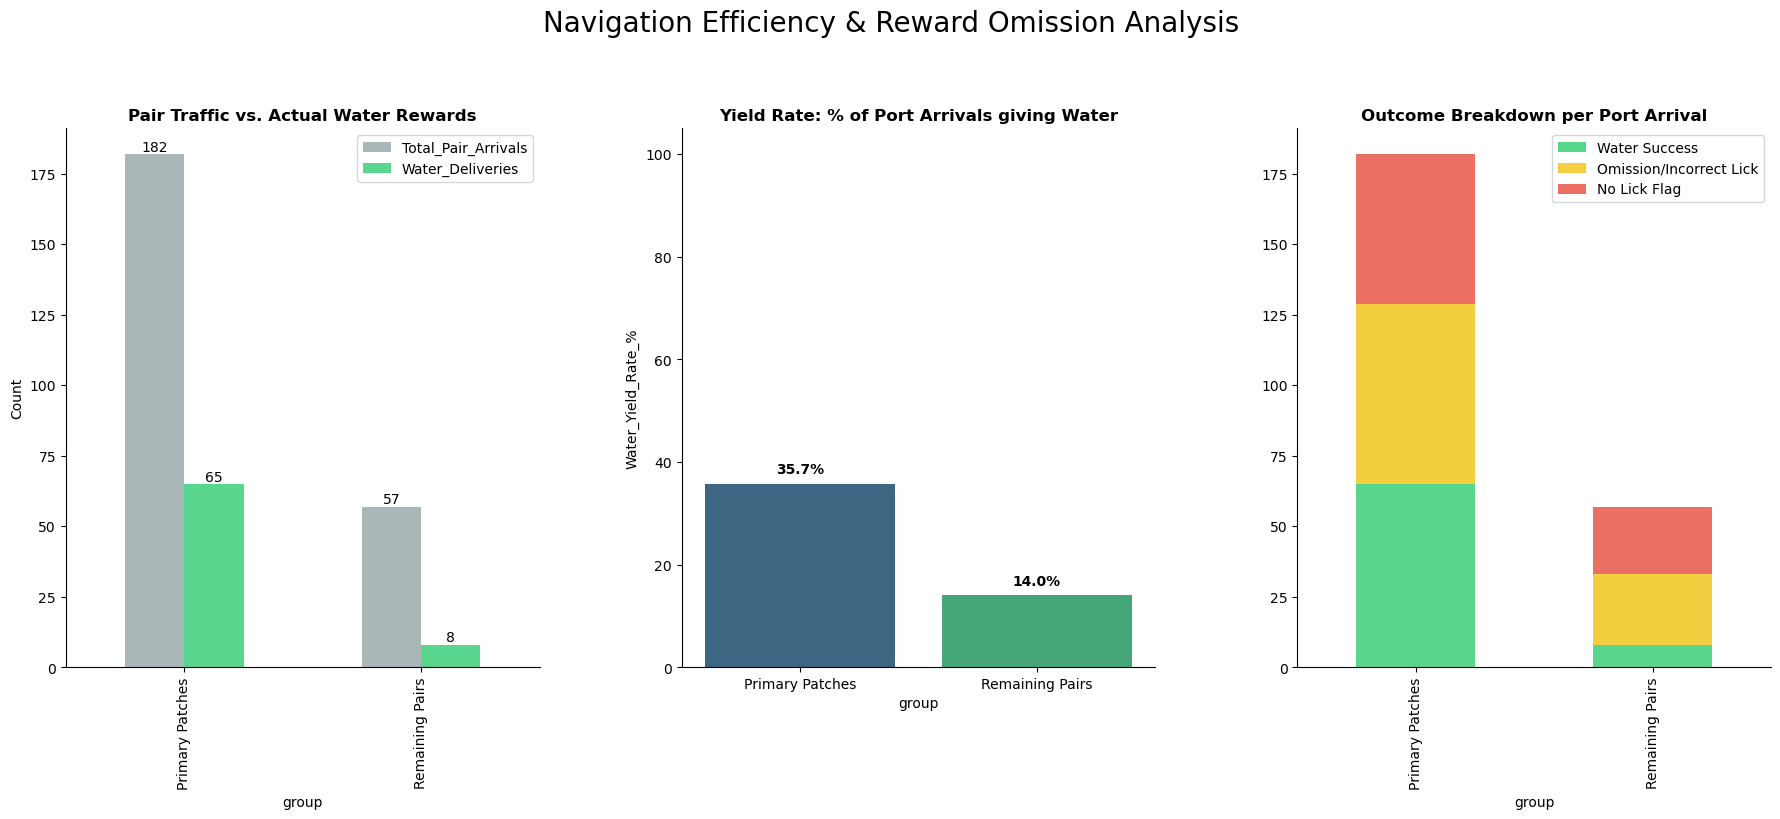

In [618]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_reward_efficiency_analysis(df_clean, primary_pairs, remaining_pairs, port_map):
    # 1. Label Groups
    primary_labels = {tuple(sorted((p1, p2))) for p1, p2 in primary_pairs}
    remaining_labels = {tuple(sorted((p1, p2))) for p1, p2 in remaining_pairs}
    
    port_visits = df_clean[df_clean['is_port_node'] == True].copy()
    port_visits['prev_port_node'] = port_visits['node_name'].shift(1)
    
    def get_group(row):
        if pd.isna(row['prev_port_node']): return None
        pair = tuple(sorted((row['prev_port_node'], row['node_name'])))
        if pair in primary_labels: return 'Primary Patches'
        if pair in remaining_labels: return 'Remaining Pairs'
        return 'Other'

    port_visits['group'] = port_visits.apply(get_group, axis=1)
    port_visits['has_size_reward'] = port_visits['reward_size_during_node'] > 0
    
    # 2. Grouped Aggregation
    # Total_Visits = Every time a port was entered as part of a pair sequence
    # Bool_Rew = Every time a lick/flag was recorded (even if no water)
    # Size_Rew = Every time water was actually delivered
    summary = port_visits[port_visits['group'].isin(['Primary Patches', 'Remaining Pairs'])].groupby('group').agg(
        Total_Pair_Arrivals=('group', 'count'),
        Lick_Flags=('reward_during_node', 'sum'),
        Water_Deliveries=('has_size_reward', 'sum')
    )
    
    # 3. Calculation of "Failed" visits
    # Omissions = System flagged True (lick/rule start) but no water (probability/rule end)
    summary['Omission_or_Error'] = summary['Lick_Flags'] - summary['Water_Deliveries']
    
    # Efficiency: Water delivered / Total times a port was entered in this group
    summary['Water_Yield_Rate_%'] = (summary['Water_Deliveries'] / summary['Total_Pair_Arrivals']) * 100
    
    # Lick Success Rate: If they licked, how often did they actually get water?
    summary['Lick_Success_Rate_%'] = (summary['Water_Deliveries'] / summary['Lick_Flags']) * 100

    # 4. Visualization
    fig, axes = plt.subplots(1, 3, figsize=(22, 7))
    plt.subplots_adjust(wspace=0.3)
    
    # Plot 1: Total Traffic vs Water Success
    # Shows the raw "denominator" of how many times they visited these ports
    summary[['Total_Pair_Arrivals', 'Water_Deliveries']].plot(kind='bar', ax=axes[0], color=['#95a5a6', '#2ecc71'], alpha=0.8)
    axes[0].set_title("Pair Traffic vs. Actual Water Rewards", fontweight='bold')
    axes[0].set_ylabel("Count")
    for p in axes[0].patches:
        axes[0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2, p.get_height()), ha='center', va='bottom')

    # Plot 2: Yield Rate (Water / Total Visits)
    # This is your "Efficiency" metric
    sns.barplot(x=summary.index, y=summary['Water_Yield_Rate_%'], palette='viridis', ax=axes[1])
    axes[1].set_title("Yield Rate: % of Port Arrivals giving Water", fontweight='bold')
    axes[1].set_ylim(0, 105)
    for i, v in enumerate(summary['Water_Yield_Rate_%']):
        axes[1].text(i, v + 2, f'{v:.1f}%', ha='center', fontweight='bold')

    # Plot 3: Why visits failed (The "Ghost" logic redefined)
    # Breakdown of visits into: Water, Omission/Error, and Pure Dry Visits
    failure_data = summary.copy()
    failure_data['Dry_Visits'] = failure_data['Total_Pair_Arrivals'] - failure_data['Lick_Flags']
    failure_data[['Water_Deliveries', 'Omission_or_Error', 'Dry_Visits']].plot(
        kind='bar', stacked=True, ax=axes[2], color=['#2ecc71', '#f1c40f', '#e74c3c'], alpha=0.8
    )
    axes[2].set_title("Outcome Breakdown per Port Arrival", fontweight='bold')
    axes[2].legend(['Water Success', 'Omission/Incorrect Lick', 'No Lick Flag'])

    plt.suptitle("Navigation Efficiency & Reward Omission Analysis", fontsize=20, y=1.05)
    sns.despine()
    plt.show()
    
    return summary

summary_stats = plot_reward_efficiency_analysis(node_summary_df, pairs_to_check, remaining_pairs, port_map)

/tmp/ipykernel_28444/1594069928.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=efficiency_stats.index, y=efficiency_stats['Success_Rate_%'], palette='viridis', ax=axes[1])


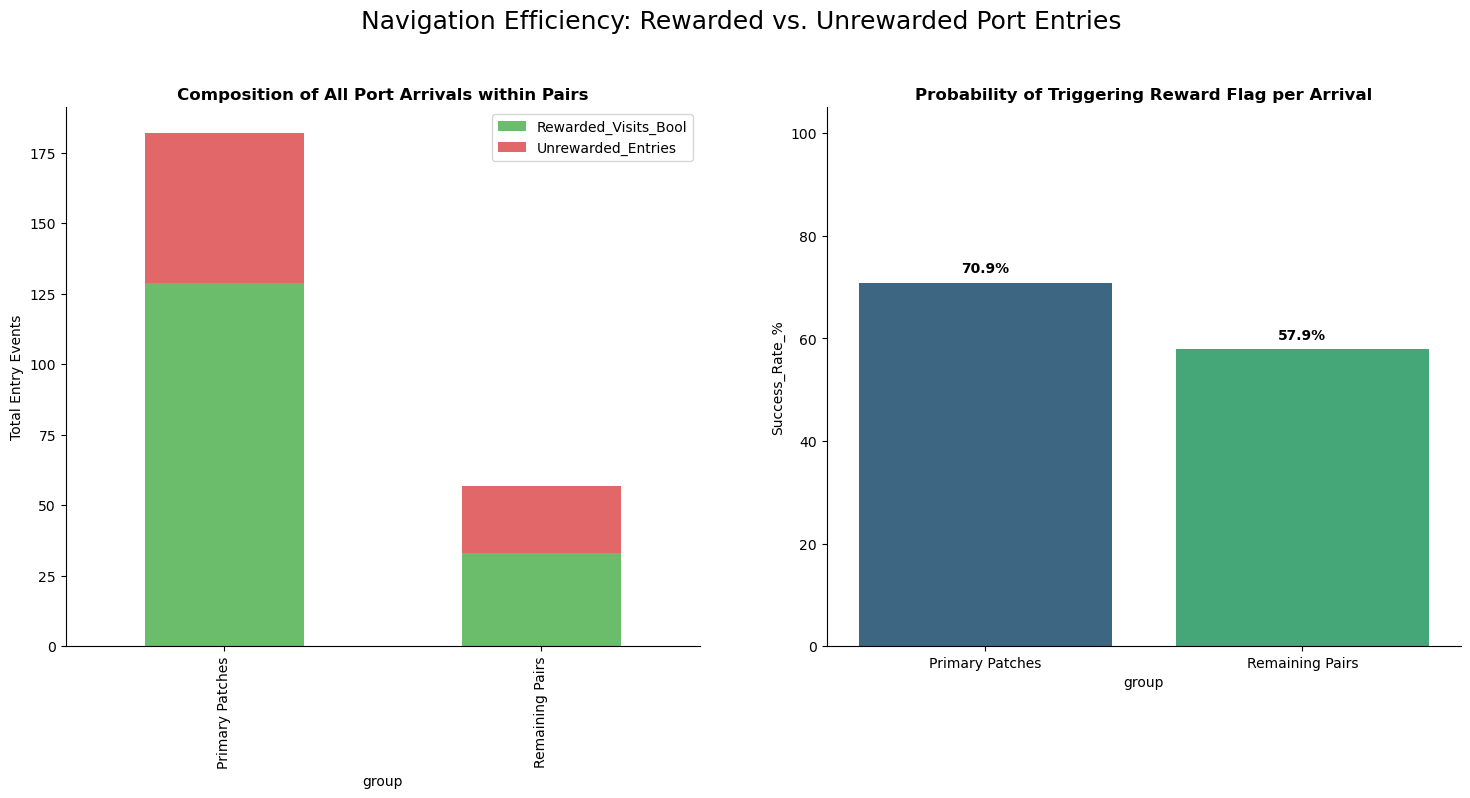

In [619]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def analyze_true_visit_efficiency(df_clean, primary_pairs, remaining_pairs, port_map):
    # 1. Map Pairs
    primary_labels = {tuple(sorted((p1, p2))) for p1, p2 in primary_pairs}
    remaining_labels = {tuple(sorted((p1, p2))) for p1, p2 in remaining_pairs}
    
    # 2. Extract ALL Port Activity
    # We look at every single row where is_port_node is True
    port_activity = df_clean[df_clean['is_port_node'] == True].copy()
    
    # Identify the sequence/pair context for every port arrival
    port_activity['prev_port_node'] = port_activity['node_name'].shift(1)
    
    def get_group(row):
        if pd.isna(row['prev_port_node']): return None
        pair = tuple(sorted((row['prev_port_node'], row['node_name'])))
        if pair in primary_labels: return 'Primary Patches'
        if pair in remaining_labels: return 'Remaining Pairs'
        return 'Other'

    port_activity['group'] = port_activity.apply(get_group, axis=1)
    
    # 3. Quantify Rewarded vs. Unrewarded
    # We group by the Pair Group and count the outcomes of the Boolean Flag
    # This captures the "Empty Visits" (False) that were previously ignored
    efficiency_stats = port_activity[port_activity['group'].isin(['Primary Patches', 'Remaining Pairs'])].groupby('group').agg(
        Total_Port_Entries=('reward_during_node', 'count'), # The true denominator
        Rewarded_Visits_Bool=('reward_during_node', 'sum'), # True cases
        Actual_Water_Delivered=('reward_size_during_node', lambda x: (x > 0).sum()) # Size > 0
    )
    
    # Calculate derived metrics
    efficiency_stats['Unrewarded_Entries'] = efficiency_stats['Total_Port_Entries'] - efficiency_stats['Rewarded_Visits_Bool']
    efficiency_stats['Success_Rate_%'] = (efficiency_stats['Rewarded_Visits_Bool'] / efficiency_stats['Total_Port_Entries']) * 100
    
    # Check for your "Ghost Rewards" (True flag, but 0 size) within this larger context
    efficiency_stats['Omissions_or_Errors'] = efficiency_stats['Rewarded_Visits_Bool'] - efficiency_stats['Actual_Water_Delivered']

    # 4. Visualization
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    
    # Plot 1: Stacked Composition of All Visits
    # This shows the "Dry" visits (False) vs "Flagged" visits (True)
    efficiency_stats[['Rewarded_Visits_Bool', 'Unrewarded_Entries']].plot(
        kind='bar', stacked=True, color=['#2ca02c', '#d62728'], alpha=0.7, ax=axes[0]
    )
    axes[0].set_title("Composition of All Port Arrivals within Pairs", fontweight='bold')
    axes[0].set_ylabel("Total Entry Events")
    
    # Plot 2: True Probability of Reward
    sns.barplot(x=efficiency_stats.index, y=efficiency_stats['Success_Rate_%'], palette='viridis', ax=axes[1])
    axes[1].set_title("Probability of Triggering Reward Flag per Arrival", fontweight='bold')
    axes[1].set_ylim(0, 105)
    
    for i, v in enumerate(efficiency_stats['Success_Rate_%']):
        axes[1].text(i, v + 2, f'{v:.1f}%', ha='center', fontweight='bold')

    plt.suptitle("Navigation Efficiency: Rewarded vs. Unrewarded Port Entries", fontsize=18, y=1.02)
    sns.despine()
    plt.show()
    
    return efficiency_stats

stats = analyze_true_visit_efficiency(node_summary_df, pairs_to_check, remaining_pairs, port_map)

In [620]:
# count how many rows in node_summary_df have is_port_node == True
num_port_nodes = node_summary_df[node_summary_df['is_port_node'] == True].shape[0]
# count haw many rows in node_summary_df have reward_during_node == True
num_rewarded_ports = node_summary_df[node_summary_df['reward_during_node'] == True].shape[0]
# count how many rows in node_summary_df have reward_size_during_node > 0
num_size_rewarded_ports = node_summary_df[node_summary_df['reward_size_during_node'] > 0].shape[0]

num_port_nodes, num_rewarded_ports, num_size_rewarded_ports

(352, 471, 234)

# Unsupervised IOHMM based on graph nodes

In [621]:
from sklearn.preprocessing import StandardScaler

# 1. Define your inputs
input_features = [
    'reward_during_node', 
    'is_port_node', 
    # 'duration_frames', 
    'path_entropy', 
    'nodes_since_last_reward', 
    'node_recency', 
    'sequence_repeat_count',
    'reward_size_during_node',
    'dist_to_closest_port'
]

# 2. Ensure booleans are floats (0.0 and 1.0)
# processed_df['is_port_node'] = processed_df['is_port_node'].astype(float)
# processed_df['reward_during_node'] = processed_df['reward_during_node'].astype(float)

# 3. Apply Scaling to the continuous portions
# Note: node_duration_zscore is already z-scored, but scaling again doesn't hurt.
scaler = StandardScaler()
processed_df[input_features] = scaler.fit_transform(processed_df[input_features])

# 4. Prepare for HMM (HMMs usually expect a 2D numpy array or a list of arrays)
# X = df[input_columns].values

ModuleNotFoundError: No module named 'sklearn'

In [ ]:
from IOHMM import UnSupervisedIOHMM, OLS, DiscreteMNL, CrossEntropyMNL

"""
# set two hidden states
SHMM = UnSupervisedIOHMM(num_states=2, max_EM_iter=200, EM_tol=1e-6)

# This model has only one output which is modeled by a linear regression model
SHMM.set_models(model_emissions = [OLS()], 
                model_transition=CrossEntropyMNL(solver='lbfgs'),
                model_initial=CrossEntropyMNL(solver='lbfgs'))

# We don't set any covariates to this OLS model
SHMM.set_inputs(covariates_initial = [], covariates_transition = [], covariates_emissions = [[]])

# This OLS has only one output target, which is 'rt' column in the dataframe
SHMM.set_outputs([['rt']])

# we only have a list of one sequence.
SHMM.set_data([speed])
"""
# Select relevant columns from node_summary_df for IOHMM input
# We'll use: is_reward_node, reward_size_during_node, duration_frames
# (Assume node_summary_df is already loaded in your notebook)

# Map node_name strings to unique numeric values for IOHMM input
# node_name_to_id = {name: idx for idx, name in enumerate(sorted(node_summary_df['node_name'].unique()))}
# node_summary_df['node_name_numeric'] = node_summary_df['node_name'].map(node_name_to_id)
# node_summary_df['reward_size_during_node'] = node_summary_df['reward_size_during_node'].fillna(-1)
# Prepare input features (now including node_name_numeric)

# Number of hidden states (modifiable)
num_states = 2

# Stickiness parameter (higher means more likely to stay in same state)
stickiness = 1.0  # Example value; tune as needed

# Custom CrossEntropyMNL with stickiness (adds bias to self-transition)
class StickyCrossEntropyMNL(CrossEntropyMNL):
    def fit(self, X, y, sample_weight=None):
        super().fit(X, y, sample_weight)
        # Add stickiness to self-transition
        if hasattr(self, 'coef_') and self.coef_.shape[0] == self.coef_.shape[1]:
            self.coef_ += np.eye(self.coef_.shape[0]) * stickiness

# Build the IOHMM model
SHMM = UnSupervisedIOHMM(
    num_states=num_states,
    max_EM_iter=200,
    EM_tol=1e-6
)

# Set emission models (customize as needed)
SHMM.set_models(
    model_emissions=[OLS()],
    model_transition=StickyCrossEntropyMNL(solver='lbfgs'),
    model_initial=CrossEntropyMNL(solver='lbfgs')
)

# Set covariates for transitions and emissions
SHMM.set_inputs(
    covariates_initial=input_features,
    covariates_transition=input_features,
    covariates_emissions=[input_features]
)

# Set output variable(s) (e.g., node_name)
SHMM.set_outputs([['node_name_numeric']])  # Use the numeric node identifier as output
# Set data (expects a list of sequences, each as a DataFrame)
# Here, we use the whole processed_df as a single sequence
# clean_df = node_summary_df[input_features].dropna()
SHMM.set_data([processed_df])

# Train the model
SHMM.train()

In [ ]:
import numpy as np

# After training, get the most likely state at each time point
# (Assuming you used a single sequence: [node_summary_df])
log_gamma = SHMM.log_gammas[0]  # shape: (n_samples, n_states)
gamma = np.exp(log_gamma)       # convert log-probabilities to probabilities
predicted_states = np.argmax(gamma, axis=1)  # most likely state at each row

# Add to your DataFrame
processed_df['predicted_state'] = predicted_states

# Now you can inspect the predicted state for each row
print(processed_df[['node_name', 'predicted_state']])

In [ ]:
SHMM.model_transition, SHMM.model_emissions, SHMM.log_gammas

In [ ]:
# Transition model coefficients
transition_model = SHMM.model_transition
if hasattr(transition_model, 'coef'):
    print(f"Transition model: coef = {transition_model.coef}, intercept = {transition_model.intercept}")
else:
    print("Transition model does not have coef_ attribute.")

# Emission model coefficients
for i, emission_list in enumerate(SHMM.model_emissions):
    emission_model = emission_list[0]
    if hasattr(emission_model, 'coef'):
        print(f"Emission model for state {i}: coef = {emission_model.coef}, dispersion = {emission_model.dispersion}")
    else:
        print(f"Emission model for state {i} does not have coef_ attribute.")

In [ ]:
# Transition model coefficients for each state
for i, model in enumerate(SHMM.model_transition):
    print(model)
    # print(f"Transition model for state {i}: coef_ = {model.coef}, intercept_ = {model.intercept}")

# Emission model coefficients for each state
for i, model in enumerate([em[0] for em in SHMM.model_emissions]):
    print(model)
    print(SHMM.model_emissions[0][0].coef)
    print(SHMM.model_emissions[1][0].coef)

    # print(f"Emission model for state {i}: coef_ = {model.coef}, intercept_ = {model.intercept}")

In [ ]:
# Statistics for predicted states: reward node %, mean/std duration

state_stats = (
    processed_df
    .groupby('predicted_state')
    .apply(lambda g: pd.Series({
        'n_nodes': len(g),
        '% reward_during_node': 100 * g['reward_during_node'].mean(),
        'mean_duration_frames': g['duration_frames'].mean(),
        'std_duration_frames': g['duration_frames'].std()
    }))
    .reset_index()
)

print("Predicted state statistics:")
print(state_stats)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_state_timeline(df, state_probs, n_states):
    """
    state_probs: The posterior probabilities from your HMM (n_visits x n_states)
    """
    plt.figure(figsize=(15, 5))
    for i in range(n_states):
        plt.plot(df['node_visit_idx'], state_probs[:, i], label=True if i==0 else None, alpha=0.7)
        plt.fill_between(df['node_visit_idx'], 0, state_probs[:, i], alpha=0.2, label=f'State {i}')
    
    # Overlay rewards as vertical lines
    reward_indices = df[df['reward_during_node'] > 0]['node_visit_idx']
    plt.vlines(reward_indices, 0, 1, colors='red', linestyles='dashed', label='Reward', alpha=0.5)
    
    plt.title("HMM State Probabilities over Session")
    plt.xlabel("Node Visit Index")
    plt.ylabel("Probability")
    plt.legend()
    plt.show()

In [ ]:
def plot_spatial_states(df, states):
    """
    states: the most likely state sequence (Viterbi path)
    """
    df['predicted_state'] = states
    
    # Check which nodes are associated with which state
    plt.figure(figsize=(12, 6))
    sns.countplot(data=df, x='node_name', hue='predicted_state')
    plt.title("State Distribution per Node")
    plt.xticks(rotation=45)
    plt.show()

    # If you have X,Y coordinates, a scatter plot is even better:
    # plt.scatter(df['x'], df['y'], c=df['predicted_state'], cmap='viridis', s=10)

plot_spatial_states(processed_df, predicted_states)

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

def plot_hmm_on_graph(G, node_positions, df, predicted_states):
    """
    G: Your networkx graph
    node_positions: Dictionary of {node_id: (x, y)}
    df: Your visit dataframe
    predicted_states: The output from HMM (array of state IDs per visit)
    """
    # Add predicted states to the dataframe
    df['predicted_state'] = predicted_states
    
    # Calculate the most frequent state for each node
    # (Alternatively, you could calculate the average probability)
    node_state_summary = df.groupby('node_name')['predicted_state'].agg(
        lambda x: x.mode()[0] if not x.empty else -1
    ).to_dict()

    # Assign colors based on states
    # State 0: Blue, State 1: Green, State 2: Red, -1: Gray (not visited)
    color_map_attr = {-1: 'lightgray', 0: '#1f77b4', 1: '#2ca02c', 2: '#d62728'}
    
    node_colors = [
        color_map_attr.get(node_state_summary.get(node, -1), 'lightgray') 
        for node in G.nodes()
    ]

    plt.figure(figsize=(12, 10))
    
    # Draw the edges first (background)
    nx.draw_networkx_edges(G, node_positions, alpha=0.3, edge_color='gray', arrows=True)
    
    # Draw the nodes
    nx.draw_networkx_nodes(
        G, 
        node_positions, 
        node_size=500, 
        node_color=node_colors,
        alpha=0.9
    )
    
    # Add labels for the nodes
    nx.draw_networkx_labels(G, node_positions, font_size=8, font_family='sans-serif')

    # Create a custom legend
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', label=f'State {i}', 
               markerfacecolor=color_map_attr[i], markersize=10) 
        for i in range(len(np.unique(predicted_states)))
    ]
    plt.legend(handles=legend_elements, loc='best')
    
    plt.title("Dominant HMM State per Maze Node")
    plt.axis('off')
    plt.show()
    
plot_hmm_on_graph(G, node_positions, processed_df, predicted_states)

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_hmm_distribution_fast(G, node_positions, df, predicted_states, n_states=3):
    # 1. Prepare data
    df = df.copy()
    df['predicted_state'] = predicted_states
    state_dist = pd.crosstab(df['node_name'], df['predicted_state'], normalize='index')
    
    # 2. Setup Figure
    fig, ax = plt.subplots(figsize=(12, 10))
    
    # Draw edges - keep alpha low to save rendering time
    nx.draw_networkx_edges(G, node_positions, ax=ax, alpha=0.1, edge_color='gray')
    
    state_colors = ['#1f77b4', '#2ca02c', '#d62728', '#ff7f0e', '#9467bd']
    
    # 3. Plot states using scatter (much faster than pie charts)
    # We will layer the states. Largest percentage gets a larger marker.
    for s in range(n_states):
        if s not in state_dist.columns: continue
        
        nodes = state_dist.index
        x = [node_positions[n][0] for n in nodes if n in node_positions]
        y = [node_positions[n][1] for n in nodes if n in node_positions]
        
        # Size is determined by the percentage of that state at that node
        # We multiply by a base size (e.g., 300)
        sizes = [state_dist.loc[n, s] * 400 for n in nodes if n in node_positions]
        
        ax.scatter(x, y, s=sizes, color=state_colors[s], alpha=0.6, label=f'State {s}', edgecolors='none')

    # 4. Cleanup
    ax.set_aspect('equal')
    ax.set_title("HMM State Occupancy (Marker Size = %) ", fontsize=14)
    ax.legend(scatterpoints=1, labelspacing=1)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

# Use your scaled_positions here
plot_hmm_distribution_fast(G, scaled_positions, processed_df, predicted_states, n_states=2)

In [ ]:
def plot_state_transitions_on_graph(G, node_positions, df):
    # Identify visits where the state changed from the previous visit
    df['state_change'] = df['predicted_state'] != df['predicted_state'].shift(1)
    
    # Count how many state changes happened at each node
    change_counts = df[df['state_change'] == True]['node_name'].value_counts()
    
    plt.figure(figsize=(10, 8))
    
    # Scale node size by how many times a state "switch" occurred there
    node_sizes = [50 + (change_counts.get(node, 0) * 100) for node in G.nodes()]
    
    nx.draw(G, node_positions, with_labels=True, node_size=node_sizes, 
            node_color="orange", edge_color="gray", alpha=0.6)
    
    plt.title("State Transition Hotspots (Decision Points)")
    plt.show()
    
plot_state_transitions_on_graph(G, node_positions, processed_df)

# Later

## Extract Trial Videos

Now let's extract individual trial videos and visualize the first and last frames of each trial.

## Re-run Zigzag Detection on Reward-Corrected Data

Now check if zigzag patterns are reduced after applying reward-based correction.

## Apply Zigzag Smoothing to Reward-Corrected Data

Apply the smoothing algorithm to the reward-corrected data to remove remaining single-frame artifacts.

## Final Comparison: Original vs Reward-Corrected vs Reward+Zigzag-Corrected

Evaluate reward location accuracy across all three versions to quantify total improvement.

In [ ]:
# Example: How to use the aligned data with spike times
# Since spike times are trial-based, you can now match them with frames

print("="*60)
print("USAGE EXAMPLE: Matching spike times with frames")
print("="*60)

# Example: Get all frames for a specific trial
example_trial = 0
trial_frames = aligned_data[aligned_data[('trial_idx', '')] == example_trial]

print(f"\nTrial {example_trial}:")
print(f"  Number of frames: {len(trial_frames)}")
print(f"  Duration: {trial_frames[('trial_length', '')].iloc[0]:.4f} seconds")
print(f"  Frame times (trial-relative): {trial_frames[('frame_time_in_trial', '')].min():.3f} to {trial_frames[('frame_time_in_trial', '')].max():.3f} seconds")
print(f"  Frame times (absolute): {trial_frames[('frame_time_absolute', '')].min():.3f} to {trial_frames[('frame_time_absolute', '')].max():.3f} seconds")

# Example: For a spike at time t in trial n, find the closest frame
def find_closest_frame(trial_idx, spike_time_in_trial):
    """
    Find the closest frame to a spike time within a trial.
    
    Parameters:
    - trial_idx: Index of the trial (0-indexed)
    - spike_time_in_trial: Spike time relative to trial start (seconds)
    
    Returns:
    - Row index in aligned_data of the closest frame
    """
    trial_frames = aligned_data[aligned_data[('trial_idx', '')] == trial_idx]
    time_diffs = np.abs(trial_frames[('frame_time_in_trial', '')].values - spike_time_in_trial)
    closest_idx = time_diffs.argmin()
    return trial_frames.index[closest_idx]

# Example usage
example_spike_time = 5.0  # 5 seconds into the trial
closest_frame_idx = find_closest_frame(example_trial, example_spike_time)
closest_frame = aligned_data.loc[closest_frame_idx]

print(f"\n\nExample spike matching:")
print(f"  Spike at trial {example_trial}, time {example_spike_time:.3f} seconds")
print(f"  Closest frame index in aligned_data: {closest_frame_idx}")
print(f"  Frame time in trial: {closest_frame[('frame_time_in_trial', '')]:.3f} seconds")
print(f"  Frame time absolute: {closest_frame[('frame_time_absolute', '')]:.3f} seconds")
print(f"  Time difference: {abs(closest_frame[('frame_time_in_trial', '')] - example_spike_time)*1000:.2f} ms")

print("\n" + "="*60)
print("The aligned_data DataFrame is ready to use!")
print("="*60)


In [ ]:
# Compare reward location accuracy across all three versions
print("="*80)
print("FINAL COMPARISON: Reward Location Accuracy")
print("="*80)
print("\nComparing three versions:")
print("  1. Original (nav_df)")
print("  2. Reward-Corrected (nav_df_reward_corrected)")
print("  3. Reward+Zigzag-Corrected (nav_df_reward_zigzag_corrected)")
print("\n" + "="*80)

# Extract graph locations for each version at reward times
versions = {
    'Original': nav_df,
    'Reward-Corrected': nav_df_reward_corrected,
    'Reward+Zigzag': nav_df_reward_zigzag_corrected
}

column_name = 'headstage_graph_node'

# Analyze each port
comparison_results = []
for port in sorted(reward_leaf_parents.keys()):
    expected_leaf = reward_leaf_parents[port][0]
    port_rewards = reward_frames[reward_frames['reward_port'] == port]
    
    accuracies = {}
    for version_name, df in versions.items():
        correct_count = 0
        for _, reward_row in port_rewards.iterrows():
            frame_idx = int(reward_row['frame_idx_global'])
            actual_node = df.iloc[frame_idx][column_name]
            if actual_node == expected_leaf:
                correct_count += 1
        
        accuracy = (correct_count / len(port_rewards) * 100) if len(port_rewards) > 0 else 0
        accuracies[version_name] = accuracy
    
    comparison_results.append({
        'port': port,
        'leaf': expected_leaf,
        'n_rewards': len(port_rewards),
        'original': accuracies['Original'],
        'reward_corrected': accuracies['Reward-Corrected'],
        'reward_zigzag': accuracies['Reward+Zigzag']
    })
    
    print(f"\nPort {port} ({expected_leaf}) - {len(port_rewards)} rewards:")
    print(f"  Original:          {accuracies['Original']:.1f}%")
    print(f"  Reward-Corrected:  {accuracies['Reward-Corrected']:.1f}% ({accuracies['Reward-Corrected'] - accuracies['Original']:+.1f}%)")
    print(f"  Reward+Zigzag:     {accuracies['Reward+Zigzag']:.1f}% ({accuracies['Reward+Zigzag'] - accuracies['Original']:+.1f}%)")

# Calculate overall statistics
print("\n" + "="*80)
print("OVERALL STATISTICS:")
print("="*80)

comparison_df = pd.DataFrame(comparison_results)
avg_original = comparison_df['original'].mean()
avg_reward = comparison_df['reward_corrected'].mean()
avg_reward_zigzag = comparison_df['reward_zigzag'].mean()

print(f"Average Accuracy Across All Ports:")
print(f"  Original:          {avg_original:.1f}%")
print(f"  Reward-Corrected:  {avg_reward:.1f}% ({avg_reward - avg_original:+.1f}%)")
print(f"  Reward+Zigzag:     {avg_reward_zigzag:.1f}% ({avg_reward_zigzag - avg_original:+.1f}%)")

ports_at_100_original = (comparison_df['original'] == 100).sum()
ports_at_100_reward = (comparison_df['reward_corrected'] == 100).sum()
ports_at_100_reward_zigzag = (comparison_df['reward_zigzag'] == 100).sum()

print(f"\nPorts at 100% Accuracy:")
print(f"  Original:          {ports_at_100_original}/8")
print(f"  Reward-Corrected:  {ports_at_100_reward}/8 ({ports_at_100_reward - ports_at_100_original:+d})")
print(f"  Reward+Zigzag:     {ports_at_100_reward_zigzag}/8 ({ports_at_100_reward_zigzag - ports_at_100_original:+d})")

print(f"\nTotal Corrections Applied:")
print(f"  Reward-based:      {reward_corrections_total} frames")
print(f"  Zigzag smoothing:  {zigzag_corrections_total} frames")
print(f"  Combined:          {reward_corrections_total + zigzag_corrections_total} frames")

In [ ]:
# Visualize the three-way comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Panel 1: Accuracy by port across all three versions
ax1 = axes[0, 0]
x = np.arange(len(comparison_df))
width = 0.25

bars1 = ax1.bar(x - width, comparison_df['original'], width, label='Original', color='#FF6B6B', alpha=0.8)
bars2 = ax1.bar(x, comparison_df['reward_corrected'], width, label='Reward-Corrected', color='#4ECDC4', alpha=0.8)
bars3 = ax1.bar(x + width, comparison_df['reward_zigzag'], width, label='Reward+Zigzag', color='#95E1D3', alpha=0.8)

ax1.set_xlabel('Port', fontsize=12, fontweight='bold')
ax1.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax1.set_title('Reward Location Accuracy by Port', fontsize=14, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels([f"P{int(p)}" for p in comparison_df['port']])
ax1.legend(loc='lower right')
ax1.set_ylim([0, 105])
ax1.grid(axis='y', alpha=0.3)
ax1.axhline(y=100, color='green', linestyle='--', alpha=0.5, linewidth=1)

# Panel 2: Improvement delta
ax2 = axes[0, 1]
reward_improvement = comparison_df['reward_corrected'] - comparison_df['original']
zigzag_improvement = comparison_df['reward_zigzag'] - comparison_df['reward_corrected']

x = np.arange(len(comparison_df))
bars1 = ax2.bar(x - width/2, reward_improvement, width, label='Reward Correction', color='#4ECDC4', alpha=0.8)
bars2 = ax2.bar(x + width/2, zigzag_improvement, width, label='Zigzag Smoothing', color='#95E1D3', alpha=0.8)

ax2.set_xlabel('Port', fontsize=12, fontweight='bold')
ax2.set_ylabel('Improvement (%)', fontsize=12, fontweight='bold')
ax2.set_title('Accuracy Improvement by Correction Type', fontsize=14, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels([f"P{int(p)}" for p in comparison_df['port']])
ax2.legend()
ax2.grid(axis='y', alpha=0.3)
ax2.axhline(y=0, color='black', linestyle='-', alpha=0.3, linewidth=0.5)

# Panel 3: Cumulative improvement
ax3 = axes[1, 0]
total_improvement = comparison_df['reward_zigzag'] - comparison_df['original']
colors = ['#4ECDC4' if x > 0 else '#FF6B6B' for x in total_improvement]
bars = ax3.barh(comparison_df['port'].astype(str), total_improvement, color=colors, alpha=0.8)

ax3.set_ylabel('Port', fontsize=12, fontweight='bold')
ax3.set_xlabel('Total Improvement (%)', fontsize=12, fontweight='bold')
ax3.set_title('Cumulative Accuracy Improvement', fontsize=14, fontweight='bold')
ax3.grid(axis='x', alpha=0.3)
ax3.axvline(x=0, color='black', linestyle='-', alpha=0.3, linewidth=0.5)

# Add value labels
for i, (bar, val) in enumerate(zip(bars, total_improvement)):
    if val != 0:
        ax3.text(val + (1 if val > 0 else -1), i, f'{val:+.1f}%', 
                va='center', ha='left' if val > 0 else 'right', fontweight='bold')

# Panel 4: Summary table
ax4 = axes[1, 1]
ax4.axis('off')

summary_data = [
    ['Metric', 'Original', 'Reward-Cor.', 'Reward+Zig.', 'Change'],
    ['Avg Accuracy', f'{avg_original:.1f}%', f'{avg_reward:.1f}%', f'{avg_reward_zigzag:.1f}%', f'{avg_reward_zigzag - avg_original:+.1f}%'],
    ['Ports at 100%', f'{ports_at_100_original}/8', f'{ports_at_100_reward}/8', f'{ports_at_100_reward_zigzag}/8', f'{ports_at_100_reward_zigzag - ports_at_100_original:+d}'],
    ['', '', '', '', ''],
    ['Correction Type', 'Frames', 'Events', '', ''],
    ['Reward-based', f'{reward_corrections_total}', f'{len(reward_frames)}', '', ''],
    ['Zigzag smoothing', f'{zigzag_corrections_total}', f'{len(zigzag_correction_df)}', '', ''],
    ['Combined', f'{reward_corrections_total + zigzag_corrections_total}', '', '', '']
]

table = ax4.table(cellText=summary_data, cellLoc='center', loc='center',
                  colWidths=[0.25, 0.15, 0.15, 0.15, 0.15])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2.5)

# Style header row
for i in range(5):
    table[(0, i)].set_facecolor('#4ECDC4')
    table[(0, i)].set_text_props(weight='bold', color='white')
    table[(4, i)].set_facecolor('#E8F8F5')
    table[(4, i)].set_text_props(weight='bold')

ax4.set_title('Summary Statistics', fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

print("\n✓ Visualization complete!")

In [ ]:
# Apply zigzag smoothing to reward-corrected data
print("Applying zigzag smoothing to reward-corrected data...")
nav_df_reward_zigzag_corrected, zigzag_corrections_total, zigzag_correction_df = smooth_leaf_parent_zigzags(
    nav_df_reward_corrected, reward_leaf_parents, max_gap_frames=1, bodypart='headstage'
)

print(f"\nZigzag correction complete!")
print(f"Total frames corrected by zigzag smoothing: {zigzag_corrections_total}")
print(f"Total correction events: {len(zigzag_correction_df)}")

if len(zigzag_correction_df) > 0:
    print(f"\nCorrection breakdown by leaf node:")
    for port, (leaf_node, _) in reward_leaf_parents.items():
        leaf_corrections = zigzag_correction_df[zigzag_correction_df['leaf_node'] == leaf_node]
        if len(leaf_corrections) > 0:
            print(f"  Port {port} ({leaf_node}): {len(leaf_corrections)} events, {leaf_corrections['frames_corrected'].sum()} frames")

In [ ]:
# Re-run zigzag detection on reward-corrected data
print("Re-running zigzag detection on reward-corrected data...\n")

all_zigzags_after_reward = {}
for port, (leaf_node, parent_nodes) in reward_leaf_parents.items():
    zigzags = detect_zigzags(nav_df_reward_corrected, leaf_node, parent_nodes, max_gap_frames=1, bodypart='headstage')
    all_zigzags_after_reward[port] = zigzags
    print(f"Port {port} ({leaf_node}): {len(zigzags)} zigzag events detected")

# Compare before and after reward correction
print("\n" + "="*60)
print("COMPARISON: Zigzags Before vs After Reward Correction")
print("="*60)
for port in sorted(reward_leaf_parents.keys()):
    before = len(all_zigzags.get(port, pd.DataFrame()))
    after = len(all_zigzags_after_reward.get(port, pd.DataFrame()))
    change = after - before
    print(f"Port {port}: {before} → {after} ({change:+d} events)")

In [ ]:
import cv2
import matplotlib.pyplot as plt
from pathlib import Path

# Create output directory for trial videos
output_dir = Path(r"C:\Maze\Video Data\NPC2\trial_videos")
output_dir.mkdir(exist_ok=True)

print(f"Output directory: {output_dir}")
print(f"Original video: {maze_video_path}")

# Open the original video
cap = cv2.VideoCapture(maze_video_path)
fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total_frames_in_video = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

print(f"\nVideo properties:")
print(f"  FPS: {fps}")
print(f"  Resolution: {width}x{height}")
print(f"  Total frames: {total_frames_in_video}")

cap.release()

In [ ]:
def extract_trial_video(trial_idx, aligned_data, video_path, output_dir, fps=40):
    """
    Extract frames for a specific trial and save as a video.
    
    Parameters:
    - trial_idx: Index of the trial to extract
    - aligned_data: The aligned DataFrame with frame information
    - video_path: Path to the original video file
    - output_dir: Directory to save the output video
    - fps: Frames per second for the output video
    
    Returns:
    - output_path: Path to the saved video
    - first_frame: First frame of the trial (as numpy array)
    - before_last_frame: Frame from 1 second (40 frames) before last frame (as numpy array)
    - last_frame: Last frame of the trial (as numpy array)
    """
    # Get frames for this trial
    trial_data = aligned_data[aligned_data[('trial_idx', '')] == trial_idx]
    frame_indices = trial_data[('frame_idx_global', '')].values
    
    print(f"\nTrial {trial_idx}:")
    print(f"  Number of frames: {len(frame_indices)}")
    print(f"  Frame range: {frame_indices[0]} to {frame_indices[-1]}")
    
    # Determine index for frame 2.1 seconds before last (84 frames before last)
    before_last_idx = max(0, len(frame_indices) - 85)  # 84 frames before last
    
    # Open video
    cap = cv2.VideoCapture(video_path)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    
    # Create output video writer
    output_path = output_dir / f"trial_{trial_idx:03d}.mp4"
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(str(output_path), fourcc, fps, (width, height))
    
    first_frame = None
    before_last_frame = None
    last_frame = None
    frames_written = 0
    
    # Read and write frames
    for i, frame_idx in enumerate(frame_indices):
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
        ret, frame = cap.read()
        
        if ret:
            out.write(frame)
            frames_written += 1
            
            # Save first frame
            if first_frame is None:
                first_frame = frame.copy()
            
            # Save frame 1 second before last
            if i == before_last_idx:
                before_last_frame = frame.copy()
            
            # Save last frame
            last_frame = frame.copy()
    
    cap.release()
    out.release()
    
    print(f"  Saved: {output_path}")
    print(f"  Frames written: {frames_written}")
    print(f"  Frame 1s before end at index: {before_last_idx}")
    
    return output_path, first_frame, before_last_frame, last_frame

# Extract last 10 trials
total_trials = aligned_data[('trial_idx', '')].max() + 1
start_trial = total_trials - 10

print(f"Total trials: {total_trials}")
print(f"Extracting trials {start_trial} to {total_trials - 1}\n")

trial_videos = {}
for trial_idx in range(start_trial, total_trials):
    output_path, first_frame, before_last_frame, last_frame = extract_trial_video(
        trial_idx, aligned_data, maze_video_path, output_dir, fps=40
    )
    trial_videos[trial_idx] = {
        'path': output_path,
        'first_frame': first_frame,
        'before_last_frame': before_last_frame,
        'last_frame': last_frame

    }

print("="*60)

print("\n" + "="*60)
print("Video extraction complete!")

In [ ]:
# Plot first, 2.1-second-before-last, and last frames for each trial
total_trials = aligned_data[('trial_idx', '')].max() + 1
start_trial = total_trials - 10

fig, axes = plt.subplots(10, 3, figsize=(18, 30))
fig.suptitle(f'First, 2.1-Second-Before-Last, and Last Frames of Trials {start_trial}-{total_trials-1}', fontsize=16, fontweight='bold')

for i, trial_idx in enumerate(range(start_trial, total_trials)):
    first_frame = trial_videos[trial_idx]['first_frame']
    before_last_frame = trial_videos[trial_idx]['before_last_frame']
    last_frame = trial_videos[trial_idx]['last_frame']
    
    # Convert BGR to RGB for display
    first_frame_rgb = cv2.cvtColor(first_frame, cv2.COLOR_BGR2RGB)
    before_last_frame_rgb = cv2.cvtColor(before_last_frame, cv2.COLOR_BGR2RGB)
    last_frame_rgb = cv2.cvtColor(last_frame, cv2.COLOR_BGR2RGB)
    
    # Plot first frame
    axes[i, 0].imshow(first_frame_rgb)
    axes[i, 0].set_title(f'Trial {trial_idx} - First Frame', fontsize=12, fontweight='bold')
    axes[i, 0].axis('off')
    
    # Plot frame 2.1 seconds before last
    axes[i, 1].imshow(before_last_frame_rgb)
    axes[i, 1].set_title(f'Trial {trial_idx} - 2.1s Before Last', fontsize=12, fontweight='bold')
    axes[i, 1].axis('off')
    
    # Plot last frame
    axes[i, 2].imshow(last_frame_rgb)
    axes[i, 2].set_title(f'Trial {trial_idx} - Last Frame', fontsize=12, fontweight='bold')
    axes[i, 2].axis('off')

plt.tight_layout()
plt.savefig(output_dir / 'trial_first_last_frames.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nSaved frame comparison plot to: {output_dir / 'trial_first_last_frames.png'}")


In [ ]:
# Display trial statistics
total_trials = aligned_data[('trial_idx', '')].max() + 1
start_trial = total_trials - 10

print("="*60)
print("TRIAL VIDEO STATISTICS")
print("="*60)

for trial_idx in range(start_trial, min(start_trial + 3, total_trials)):
    trial_data = aligned_data[aligned_data[('trial_idx', '')] == trial_idx]
    print(f"\nTrial {trial_idx}:")
    print(f"  Video file: {trial_videos[trial_idx]['path'].name}")
    print(f"  Number of frames: {len(trial_data)}")
    print(f"  Duration: {trial_data[('trial_length', '')].iloc[0]:.3f} seconds")
    print(f"  Frame time range: {trial_data[('frame_time_in_trial', '')].min():.3f} - {trial_data[('frame_time_in_trial', '')].max():.3f} seconds")
    print(f"  Absolute time range: {trial_data[('frame_time_absolute', '')].min():.3f} - {trial_data[('frame_time_absolute', '')].max():.3f} seconds")

    print(f"  Has extra frame: {trial_data[('has_extra_frame', '')].iloc[0]}")print("\n" + "="*60)
    